[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T01_B_hechos_estilizados_internacionales_es.ipynb)
> **Nota para Google Colab**: la celda siguiente instala `puremacro` y, si hace falta, descarga del repositorio público [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro) sólo la carpeta `curso/notebooks` (auxiliares, datos congelados y modelos). No pide acceso a Google Drive.


In [1]:
# Configuración del entorno: Google Colab, instalación local o Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """¿Existe la ruta? Sin lanzar OSError/PermissionError en el sandbox de Juno."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Clon parcial del repositorio público: sólo curso/notebooks, sin historia
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Carpeta con los auxiliares del curso (_nbstyle, _datos) en sys.path, sin salir del sandbox
_candidatos = [Path.cwd(), Path.cwd() / "curso/notebooks", Path.cwd() / "notebooks"]
try:
    _candidatos.insert(0, Path(__file__).resolve().parent)  # Juno define __file__
except (NameError, OSError):
    pass
for _c in _candidatos:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Gráficas en línea y estilo del curso
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Módulo 1 — Contabilidad Nacional y Hechos Estilizados Internacionales

**Curso complementario · puremacro**

### Objetivos de aprendizaje
Al terminar esta lección podrás:
1. **Construir las cuentas del gasto desde cero**, en diez pasos, para todos los países que la OCDE publica — descubriendo la lista con `qna_countries()` en vez de escribirla a mano, y terminando con los **tres productos** de una construcción de contabilidad nacional: niveles nominales, deflactores implícitos y medidas de volumen, ligados por $\text{nominal} = \text{real} \times \text{deflactor}/100$.
- Ésto puede hacer algo lenta la ejecución del cuaderno, pero muestra cómo podemos hacer análisis desde una tablet
2. **Saber qué producto responde a qué pregunta** — por qué la identidad $Y = C + I + G + NX$ cierra a precios corrientes, pero no en volúmenes encadenados, por qué el deflactor de cada país vale 100 en un año distinto y por qué el crecimiento real se descompone usando ponderaciones del período anterior en lugar de sumarse.
3. **Construir los otros dos enfoques del mismo PIB** — producción (valor añadido por rama) y renta (a qué se paga el PIB) —, evaluar las tres identidades y leer los residuales: las columnas informativas que duplican si se suman, los flujos que discrepan sobre el PIB mismo, y la **discrepancia estadística PIB–RIB** que llega a $\pm2\%$ en Estados Unidos.
4. **Entender los precios relativos** ($P_{eq}/P_{C^{*}}$, $P_{cd}/P_{C^{*}}$, $P_X/P_M$) que solo los deflactores permiten calcular — separando la FBCF en **equipo transable** y **construcción no transable**, cuyos precios llevan treinta años moviéndose en direcciones opuestas, y deflactando ambos por el consumo **neto de duraderos**, porque el precio de un coche no tiene por qué estar en el denominador del precio de una máquina.
5. Separar el consumo de los hogares por **durabilidad** y preguntar si los duraderos pertenecen a $C$ o a $I$ (Cooley y Prescott 1995; Gomme y Rupert 2007), contrastando y desestacionalizando las series que lo necesiten.
6. Distinguir los estadísticos **inmunes al tipo de cambio** (participaciones nominales en moneda local) de los que **contamina**, usando equipo vs. construcción como placebo dentro de cada país.
7. Analizar el comportamiento del **ratio capital-producto ($K/Y$)** y la **participación del trabajo** — y ver por qué la fórmula obvia, remuneración de asalariados sobre valor añadido, no mide el parámetro de la función de producción: corregirla por trabajo **por cuenta propia** (Gollin 2002) y, donde ILOSTAT publica la tasa **trimestral**, también por el margen de asalariados **informales**, que es la única corrección capaz de cambiar una tendencia porque es la única que se mueve.
8. Implementar el **contraste de Mankiw–Shapiro (1986)** de *news* vs. *noise* —sus dos regresiones, no solo la famosa— sobre vintages del PIB en tiempo real para **las 42 áreas de referencia** que cubre el archivo de revisiones de la OCDE — detectando primero las ediciones en las que ese archivo cambia en silencio lo que está midiendo, y desestacionalizándolas **todas** con un mismo filtro en vez de tirar las culpables, porque tirarlas asciende a «dato preliminar» estimaciones publicadas años después. Después, correr el mismo contraste sobre **las nueve medidas que trae el archivo** —las dos caras del PIB, el deflactor, cinco componentes del gasto y el empleo— y descubrir que el PIB es lo *más silencioso* de aquello de lo que está hecho, porque es un promedio de errores que apenas se mueven juntos.
9. Explorar en qué medida los hechos estilizados cambian junto con las metodologías de las contabilidades nacionales ante **vintages y cambios metodológicos del SCN**, y contrastar los determinantes estructurales de $\sigma(c)/\sigma(y)$ — apertura, profundidad financiera (Banco Mundial) y el **margen laboral desprotegido**, uniendo informalidad (ILOSTAT) y trabajo por cuenta propia en la unión en la que se solapan en lugar de sumarlos — con datos de cuatro bases y ningún número tecleado a mano.
10. Documentar hechos estilizados del **mercado laboral**, que no suelen tratarse en cursos de crecimiento económico: los dos márgenes del insumo de trabajo —cabezas y horas— que las propias cuentas miden, y la **curva de Beveridge**, con el $\alpha$ de la función de emparejamiento que su pendiente identifica y el desplazamiento hacia afuera que dejó la pandemia.
11. **Dejar los datos listos para lo que sigue**: cuatro archivos —gasto con sus deflactores, renta, producción y mercado laboral—, todos trimestrales y desestacionalizados, que son el insumo de los cuadernos siguientes.

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from puremacro.data import hp_filter

_cwd = __import__("pathlib").Path.cwd()

def _here(p):
    # A sandboxed filesystem (iOS) raises PermissionError from .exists()
    # instead of returning False; treat unreadable as absent.
    try:
        return p.exists()
    except OSError:
        return False


_nb = _cwd if _here(_cwd / "_nbstyle.py") else _cwd / "notebooks"
sys.path.insert(0, str(_nb))
import _nbstyle; _nbstyle.apply_style()
from _tutor import tutor

## 1. Construir las cuentas desde cero

Toda la lección se apoya en un solo objeto, así que lo construimos primero — y lo construimos despacio, porque casi todos los errores que se cometen con la contabilidad nacional se cometen en este paso y no se detectan nunca después.

La descomposición del PIB por el lado del gasto es
$$ Y = C + I + G + NX, \qquad NX = X - M, $$
y una oficina estadística publica cada uno de esos agregados en **tres productos** que no deben confundirse:

| | qué es | en el panel |
|---|---|---|
| **Nominal** | el valor efectivamente transado, en moneda nacional a precios corrientes | `gdp`, `cons_hh`, `inv`, … |
| **Deflactor** | el índice de precios implícito de ese mismo agregado | `gdp_defl`, `cons_hh_defl`, … |
| **Real (volumen)** | el mismo agregado con el movimiento de precios extraído | `gdp_real`, `cons_hh_real`, … |

No son tres bases de datos independientes. Componente a componente,
$$ \text{nominal} \;=\; \text{real} \times \frac{\text{deflactor}}{100}, $$
de modo que **dos cualesquiera de los tres determinan el tercero** — un hecho que verificaremos con precisión de máquina en vez de afirmarlo, y que conviene retener: un archivo congelado que solo lleva dos de ellos no ha perdido nada.

Ahora bien, cuáles dos considera primarios la fuente sí importa. La oficina *mide* el **nominal** (es lo que reportan las declaraciones fiscales y las encuestas) y el **volumen** (deflacta cada serie elemental por su propio índice de precios), y el deflactor sale como el cociente. Mantenemos ese mismo orden de primacía por una razón que se desarrolla en §1.6: la identidad de arriba se cumple *exactamente* a precios corrientes y **no** se cumple en volúmenes encadenados.

Vamos a descomponer nuestra primera consulta masiva a los datos de contabilidad nacional en 10 pasos:

### 1.1 Paso 1 — ¿Quién publica qué?

La primera pregunta no es «qué países quiero» sino «qué países hay». Codificar la lista a mano es la forma en que un panel queda obsoleto en silencio: la OCDE incorpora un área de referencia, tu lista no, y nada protesta.

`qna_countries()` le pregunta al *endpoint* de **disponibilidad** de SDMX qué valores de `REF_AREA` tienen efectivamente datos en el flujo, de modo que el panel cubra el conjunto más grande que la fuente admite. Descarta por defecto las *agrupaciones* de países — `OECD`, `EA20`, `G7`, `NAFTA` — porque un panel que mezcla `OECD` con `USA` cuenta dos veces cada agregado que toca; pasa `include_aggregates=True` si las quieres.

In [3]:
from pathlib import Path

# Para que entiendan si no ejecuta en una tablet usando jupyter
try:
    from puremacro.fetch import (qna_panel, qna_meta, qna_countries,
                                 qna_rebase, qna_identity, qna_contributions,
                                 QNA_COMPONENTS, QNA_AGGREGATES, QNA_ASSETS,
                                 QNA_DURABILITY, QNA_ACTIVITIES, QNA_INCOME,
                                 QNA_LABOR, QNA_LABOR_UNITS)
except ImportError as exc:
    import puremacro
    raise ImportError(
        f"Este cuaderno necesita puremacro >= 1.8.0 para la API de contabilidad "
        f"nacional trimestral; la versión instalada es {puremacro.__version__}, "
        f"en {Path(puremacro.__file__).parent}. Informa: {getattr(exc, 'msg', None) or exc}. "
        f"Ejecuta `pip install -U puremacro` (en un iPad, desde la consola de "
        f"Juno) y reinicia el kernel."
    ) from exc

# Control de consulta en vivo vs. instantánea congelada del curso (offline por omisión)
VIVO = os.environ.get("MAV_QNA_VIVO", "").strip().lower() not in ("", "0", "false", "no")

if VIVO:
    try:
        PAISES = qna_countries()
        TODAS_AREAS = qna_countries(include_aggregates=True)
    except Exception as exc:
        print(f"Aviso: consulta SDMX no disponible ({exc}). Usando metadatos en caché.")
        VIVO = False

if not VIVO:
    # Carga sin conexión desde la instantánea congelada / metadatos de bundle_2026A
    try:
        import _datos
        _meta_p = _datos.ruta_dato("oecd_qna_panel_meta.csv")
    except Exception:
        _meta_p = Path("data_curso") / "bundle_2026A" / "oecd_qna_panel_meta.csv"
        if not _meta_p.is_file():
            _meta_p = Path("data_curso") / "oecd_qna_panel_meta.csv"

    if _meta_p.is_file():
        PAISES = sorted(pd.read_csv(_meta_p)["code"].dropna().unique().tolist())
    else:
        from puremacro.fetch.oecd_qna_panel import _QNA_COUNTRIES_FALLBACK
        PAISES = sorted(_QNA_COUNTRIES_FALLBACK)

    TODAS_AREAS = sorted(set(PAISES) | set(QNA_AGGREGATES))

print(f"Áreas de referencia con cuentas trimestrales de gasto en la OCDE: "
      f"{len(TODAS_AREAS)}")
print(f"  de las cuales agrupaciones ({len(TODAS_AREAS) - len(PAISES)}): "
      f"{', '.join(sorted(set(TODAS_AREAS) - set(PAISES)))}")
print(f"  países individuales ({len(PAISES)}):\n  {', '.join(PAISES)}\n")

print("Los componentes del gasto que llevará el panel, y sus coordenadas SDMX:")
for name, (txn, sector, desc) in QNA_COMPONENTS.items():
    print(f"  {name:9s} {txn:5s} / {sector:4s}  {desc}")

# Las agrupaciones quedan fuera por construcción, no por suerte.
assert not (set(PAISES) & QNA_AGGREGATES)
assert len(PAISES) >= 45
assert {"USA", "MEX", "DEU", "CHN", "IND"}.issubset(PAISES)

Áreas de referencia con cuentas trimestrales de gasto en la OCDE: 61
  de las cuales agrupaciones (12): EA19, EA20, EU15, EU27_2020, EU28, G20, G7, NAFTA, OECD, OECD26, OECDE, W
  países individuales (49):
  ARG, AUS, AUT, BEL, BGR, BRA, CAN, CHE, CHL, CHN, COL, CRI, CZE, DEU, DNK, ESP, EST, FIN, FRA, GBR, GRC, HRV, HUN, IDN, IND, IRL, ISL, ISR, ITA, JPN, KOR, LTU, LUX, LVA, MEX, NLD, NOR, NZL, POL, PRT, ROU, RUS, SAU, SVK, SVN, SWE, TUR, USA, ZAF

Los componentes del gasto que llevará el panel, y sus coordenadas SDMX:
  gdp       B1GQ  / S1    Gross domestic product (expenditure approach)
  cons_hh   P3    / S1M   Household final consumption (households + NPISH)
  cons_gov  P3    / S13   General government final consumption
  inv       P51G  / S1    Gross fixed capital formation
  capform   P5    / S1    Gross capital formation (GFCF + inventories)
  exports   P6    / S1    Exports of goods and services
  imports   P7    / S1    Imports of goods and services


### 1.2 Paso 2 — Una llamada, tres productos

`qna_panel` descarga todas las contabilidades nacionales trimestrales. Le pasas los códigos y las convierte en un panel indexado por `(code, date)` con las tres familias de productos una al lado de la otra.

Tres argumentos importantes:
- `real=True` devuelve además las medidas de **volumen**. Sin él obtienes solo nominal y deflactores — lo que, por la identidad de arriba, no es en realidad menos información, pero sí implica escribir la división tú.
- `assets=True` desglosa la formación bruta de capital fijo por activo, y `durability=True` desglosa el consumo de los hogares por durabilidad. Ambos se usan desde §2.2.
- `sa="x13"` se ocupa del ajuste estacional; eso es el Paso 4.
- `output=True` e `income=True` traen los **otros dos enfoques del mismo PIB**— el valor añadido por rama, y la renta a la que se paga. Eso es el Paso 8; hasta entonces todo es el lado del gasto.
- `labor=True` trae el **insumo de trabajo** que miden estas mismas cuentas: ocupados y horas, partidos en asalariados y cuenta propia. No son precios ni cantidades de un bien, así que no llevan deflactor ni volumen — se cuentan en miles de personas y en millones de horas. Es el bloque de §5.

**Sobre tiempos de ejecución.** Una corrida en vivo son ~25 peticiones SDMX y el *endpoint* de la OCDE limita a unas 20 por hora, así que **por omisión el cuaderno lee la instantánea congelada de `data_curso/`** y no descarga nada: son los mismos números, y así iterar sobre el cuaderno no consume cuota. Para refrescar el vintage —que es la única razón para descargar— pon `MAV_QNA_VIVO=1` en el entorno antes de arrancar el kernel, o cambia `VIVO = True` en la celda de abajo. Por omisión (con VIVO desactivado), el Paso 1 lee la lista de países y metadatos desde la instantánea congelada de `data_curso/` (bundle_2026A) en lugar de consultar el endpoint SDMX, garantizando una ejecución inmediata y 100% desconectada.

In [4]:
def readable(p, kind="dir"):
    """`p.is_dir()` / `p.is_file()`, pero False en vez de excepción.

    pathlib solo absorbe ENOENT / ENOTDIR / EBADF / ELOOP, así que en un
    sistema de archivos con sandbox — iOS, donde todo lo que esté por encima
    de la carpeta del propio cuaderno queda fuera de alcance — probar una ruta
    candidata lanza PermissionError en lugar de responder False. Toda
    comprobación de archivos de este cuaderno pasa por aquí.
    """
    try:
        return p.is_dir() if kind == "dir" else p.is_file()
    except OSError:
        return False

from _datos import DATOS

# Primero las rutas dentro del sandbox, para que un iPad nunca tenga que subir a "..".
DATA = DATOS

# ¿Descargar, o leer del disco? Una corrida en vivo son ~25 peticiones SDMX y
# el endpoint de la OCDE limita a unas 20 por hora, así que iterar sobre el
# cuaderno descargando es la forma de quedarse sin cuota a media clase. Por
# omisión se lee la instantánea congelada, que son los mismos números; pon
# MAV_QNA_VIVO=1 en el entorno —o VIVO = True aquí mismo— para reconstruir el
# panel desde la fuente, que es lo que hay que hacer para refrescar el vintage.
VIVO = os.environ.get("MAV_QNA_VIVO", "").strip().lower() not in ("", "0", "false", "no")

panel = (qna_panel(PAISES, start="1995", real=True,
                   assets=True, durability=True,
                   output=True, income=True, labor=True, sa="x13")
         if VIVO else pd.DataFrame())
meta = qna_meta(panel) if VIVO else pd.DataFrame()

n_vivo = panel.index.get_level_values("code").nunique() if not panel.empty else 0
if n_vivo < len(PAISES) and readable(DATA / "oecd_qna_panel_nominal.csv", "file"):
    print("Instantánea congelada del curso (MAV_QNA_VIVO=1 para descargar)."
          if not VIVO else
          f"La OCDE devolvió {n_vivo}/{len(PAISES)} países — "
          f"usamos la instantánea congelada del curso.")
    panel = (pd.read_csv(DATA / "oecd_qna_panel_nominal.csv", parse_dates=["date"])
               .set_index(["code", "date"]).sort_index())
    meta = pd.read_csv(DATA / "oecd_qna_panel_meta.csv")
    # La instantánea trae dos de los tres productos. No es una carencia: el
    # tercero se recupera exactamente, y reconstruirlo aquí es usar la
    # identidad de §1 en lugar de describirla. Las ~30 columnas se pegan de
    # una sola vez con pd.concat: insertarlas una a una fragmenta el frame.
    recuperables = [c for c in panel.columns if f"{c}_defl" in panel.columns]
    panel = pd.concat(
        [panel, pd.DataFrame({f"{c}_real": 100.0 * panel[c] / panel[f"{c}_defl"]
                              for c in recuperables},
                             index=panel.index)],
        axis=1)

if panel.empty:
    raise RuntimeError(
        "Sin panel: la descarga de la OCDE no devolvió nada y no se encontró "
        f"ninguna instantánea congelada. Se buscó data_curso/oecd_qna_panel_nominal.csv "
        f"cerca de {DATA}. Copia la carpeta data_curso/ del curso junto a este "
        "cuaderno (en un iPad tiene que estar dentro de la carpeta del propio "
        "cuaderno — todo lo que esté por encima queda fuera del sandbox) o "
        "vuelve a correr con conexión.")

LABORALES = [c for c in QNA_LABOR if c in panel.columns]
NOMINALES = [c for c in panel.columns
             if not c.endswith(("_defl", "_real")) and c not in LABORALES]
DEFLACTORES = [f"{c}_defl" for c in NOMINALES if f"{c}_defl" in panel.columns]
VOLUMENES = [f"{c}_real" for c in NOMINALES if f"{c}_real" in panel.columns]
# Las series que llevan los tres productos. No todas lo hacen: la remuneración
# de asalariados no tiene medida de volumen — no existen "salarios a precios
# constantes" en las cuentas —, así que el bloque de renta del Paso 8 es solo
# a precios corrientes y las tres listas de abajo no tienen la misma longitud
# a propósito.
TRIPLE = [c for c in NOMINALES
          if f"{c}_defl" in panel.columns and f"{c}_real" in panel.columns]

dates = panel.index.get_level_values("date")
print(f"\nPanel: {panel.index.get_level_values('code').nunique()} países x "
      f"{dates.nunique()} trimestres "
      f"({dates.min().to_period('Q')}-{dates.max().to_period('Q')}), "
      f"{panel.shape[1]} columnas = {len(NOMINALES)} nominales + {len(DEFLACTORES)} deflactores "
      f"+ {len(VOLUMENES)} volúmenes + {len(LABORALES)} laborales")
print(f"Las {len(LABORALES)} laborales ({', '.join(LABORALES)}) son personas y "
      f"horas: no tienen precio, así que no tienen deflactor ni volumen.")
print(f"{len(TRIPLE)} series llevan los tres productos; las otras "
      f"{len(NOMINALES) - len(TRIPLE)} existen solo a precios corrientes "
      f"({', '.join(c for c in NOMINALES if c not in TRIPLE)}).\n")
print("Los tres productos para un país, último trimestre (España, millones de EUR):")
print(pd.DataFrame({
    "nominal":   panel.loc["ESP", TRIPLE].iloc[-1],
    "deflactor": panel.loc["ESP", [f"{c}_defl" for c in TRIPLE]].iloc[-1].set_axis(TRIPLE),
    "real":      panel.loc["ESP", [f"{c}_real" for c in TRIPLE]].iloc[-1].set_axis(TRIPLE),
}).head(7).round(1).to_string())

# nominal = real x deflactor / 100, con precisión de máquina, en todas partes.
rel_err = max(
    float(((panel[n] - panel[f"{n}_real"] * panel[f"{n}_defl"] / 100).abs()
           / panel[n].abs()).max())
    for n in TRIPLE)
print(f"\nPeor error relativo en  nominal = real x deflactor/100  en todo el "
      f"panel: {rel_err:.1e}")
assert rel_err < 1e-9
assert panel.index.get_level_values("code").nunique() >= 45
assert {"gdp", "cons_hh", "cons_gov", "inv", "exports", "imports"}.issubset(panel.columns)
assert {"gdp_defl", "cons_hh_defl", "inv_defl"}.issubset(panel.columns)
assert {"inv_equip_defl", "inv_struct_defl", "cons_dur_defl"}.issubset(panel.columns)

Instantánea congelada del curso (MAV_QNA_VIVO=1 para descargar).

Panel: 49 países x 126 trimestres (1995Q1-2026Q2), 105 columnas = 37 nominales + 31 deflactores + 31 volúmenes + 6 laborales
Las 6 laborales (emp, emp_employees, emp_selfemp, hours, hours_employees, hours_selfemp) son personas y horas: no tienen precio, así que no tienen deflactor ni volumen.
31 series llevan los tres productos; las otras 6 existen solo a precios corrientes (gdp_income, comp_emp, surplus_mixed, taxes_prod_imp_net, taxes_prod_imp, subsidies).

Los tres productos para un país, último trimestre (España, millones de EUR):
           nominal  deflactor      real
gdp       441437.0      123.5  357508.0
cons_hh   247775.0      125.0  198275.0
cons_gov   84379.0      117.2   71994.0
inv        91386.0      122.0   74889.0
capform    94780.0      123.8   76568.0
exports   159775.0      130.3  122601.0
imports   145272.0      129.1  112493.0

Peor error relativo en  nominal = real x deflactor/100  en todo el panel

### 1.3 Paso 3 — Lee el recibo antes de usar los datos

`qna_meta` devuelve lo que la fuente envió realmente, país por país. Tres de sus columnas deciden si una comparación entre países significa algo.

**`currency`.** Todos los niveles están en moneda nacional. Es deliberado, y es la razón principal para guardar el panel así: un *cociente* de dos agregados a precios corrientes en la misma moneda — $C/Y$, $I/Y$ — no necesita conversión alguna y es inmune al tipo de cambio (§2.3 mide qué no lo es). Si conviertes a una moneda común, importas el tipo bilateral de cada país a cada una de sus series.

**`price_base`.** `L` es un volumen **encadenado**, `Q` uno de **base fija**. La distinción no es cosmética: los volúmenes encadenados no son aditivos, que es todo el contenido de §1.6. Fíjate en qué países son `Q` — los descargadores que filtran duro `PRICE_BASE == "L"` devuelven un marco vacío exactamente para estos, y sin avisar.

**`price_ref_year`.** El año en que los deflactores de ese país valen 100. *No* es común entre países, y la dispersión es mucho mayor de lo que uno espera. Hasta que el Paso 5 lo arregla, un gráfico de niveles de `inv_defl` entre países es un gráfico de varias convenciones distintas.

In [5]:
print(meta[["code", "currency", "price_base", "price_ref_year", "sa", "sa_detail",
            "sa_labor", "n_obs", "first", "last"]].head(8).to_string(index=False))

base = meta["price_base"].value_counts()
print(f"\nMedida de volumen: {base.get('L', 0)} países encadenados (L), "
      f"{base.get('Q', 0)} de base fija (Q) — "
      f"{', '.join(sorted(meta.loc[meta['price_base'] == 'Q', 'code']))}.")
print("Un descargador que filtra duro PRICE_BASE == 'L' no devuelve nada para esos seis.")

ref = meta["price_ref_year"].dropna()
print(f"\nAño de referencia de precios: {ref.nunique()} valores distintos, de "
      f"{int(ref.min())} a {int(ref.max())}. Los más frecuentes:")
print("  " + ", ".join(f"{int(y)} ({n})" for y, n in
                       ref.value_counts().nlargest(4).items()))
print(f"Solo {int((ref == ref.mode().iloc[0]).sum())} de {len(ref)} países "
      f"comparten el año modal, así que los *niveles* de los deflactores todavía "
      f"no son comparables.")

assert meta["price_base"].isin(["L", "Q"]).all()
assert ref.nunique() > 5          # la heterogeneidad que el Paso 5 existe para quitar

code currency price_base  price_ref_year    sa sa_detail  sa_labor  n_obs      first       last
 ARG      ARS          Q          2004.0  oecd puremacro       NaN     89 2004-01-01 2026-01-01
 AUS      AUD          L          2024.0  oecd      oecd puremacro    125 1995-01-01 2026-01-01
 AUT      EUR          L          2015.0  oecd      oecd      oecd    126 1995-01-01 2026-04-01
 BEL      EUR          L          2020.0  oecd      oecd      oecd    125 1995-01-01 2026-01-01
 BGR      EUR          L          2020.0  oecd      oecd      oecd    126 1995-01-01 2026-04-01
 BRA      BRL          L          1995.0 mixed puremacro       NaN    121 1996-01-01 2026-01-01
 CAN      CAD          L          2017.0  oecd      oecd puremacro    125 1995-01-01 2026-01-01
 CHE      CHF          L          2020.0  oecd      oecd puremacro    126 1995-01-01 2026-04-01

Medida de volumen: 43 países encadenados (L), 6 de base fija (Q) — ARG, CHN, IDN, IND, MEX, ZAF.
Un descargador que filtra duro PRICE_B

### 1.4 Paso 4 — Ajuste estacional, y quién lo hizo

Las cuentas trimestrales en bruto no sirven: el cuarto trimestre del consumo minorista son las fiestas, no un auge. Por eso las cuentas se publican **ajustadas de estacionalidad y calendario** — salvo cuando no.

`sa="prefer"` (el valor por defecto) toma la serie ajustada que publica la fuente y recurre a la bruta solo donde no existe ninguna ajustada — lo que deja a esos países sin ajustar y contamina cualquier volatilidad que calcules con ellos. `sa="x13"` en cambio las ajusta aquí, con X-13ARIMA-SEATS si el binario está instalado y con el motor X-11/ARIMA en Python puro de puremacro si no, de modo que funciona también donde ningún binario pueda ejecutar.

Esto importa para tres bloques distintos: **China y Arabia Saudí** no publican nada ajustado; **México, Japón y Turquía** publican agregados principales ajustados pero dejan en bruto los desgloses detallados por activo y durabilidad; y **el bloque laboral** lo dejan en bruto otro grupo distinto de países — por eso `sa`, `sa_detail` y `sa_labor` son tres columnas y no una. Todo lo ajustado aquí se etiqueta `puremacro` en vez de `oecd`, así que la procedencia no se pierde nunca.

In [6]:
etiqueta = {"": "no publica", np.nan: "no publica"}
prov = pd.DataFrame({
    "agregados": meta["sa"].fillna("").replace(etiqueta).value_counts(),
    "desgloses detallados": meta["sa_detail"].fillna("").replace(etiqueta).value_counts(),
    "bloque laboral": meta["sa_labor"].fillna("").replace(etiqueta).value_counts(),
}).fillna(0).astype(int)
print("Quién ajustó estacionalmente cada bloque, en todo el panel:")
print(prov.to_string())

here = meta[meta["sa"].isin(["puremacro", "mixed"])]["code"].tolist()
here_detail = meta[meta["sa_detail"].isin(["puremacro", "mixed"])]["code"].tolist()
here_labor = meta[meta["sa_labor"].isin(["puremacro", "mixed"])]["code"].tolist()
print(f"\nAjustados aquí, agregados principales: {', '.join(here) or 'ninguno'}")
print(f"Ajustados aquí, desgloses detallados:  {', '.join(here_detail) or 'ninguno'}")
print(f"Ajustados aquí, bloque laboral:        {', '.join(here_labor) or 'ninguno'}")

engines = panel.attrs.get("sa_engines", {})
if engines:
    which = pd.Series(list(engines.values())).value_counts()
    print(f"{len(engines)} series ajustadas en esta sesión; motor "
          f"{which.idxmax()} ({which.max()} de ellas).")
else:
    print("(Instantánea congelada: el ajuste ya se aplicó cuando se construyó.)")

Quién ajustó estacionalmente cada bloque, en todo el panel:
            agregados  desgloses detallados  bloque laboral
mixed               1                     7               1
no publica          0                     0              10
oecd               46                    36              28
puremacro           2                     6              10

Ajustados aquí, agregados principales: BRA, CHN, SAU
Ajustados aquí, desgloses detallados:  ARG, BRA, CHN, COL, IDN, IND, ISR, JPN, MEX, RUS, SAU, TUR, ZAF
Ajustados aquí, bloque laboral:        AUS, CAN, CHE, CHL, CRI, ISL, KOR, MEX, NZL, RUS, ZAF
(Instantánea congelada: el ajuste ya se aplicó cuando se construyó.)


### 1.5 Paso 5 — Poner a todos los países en un mismo año de referencia

Teniendo en cuenta que en el paso 3 documentamos más de 10 años base distinos, es prudente llevar a todos los países al mismo año base y es lo que ejecuta `qna_rebase` los mueve todos a 2015.

Lo que hace es un **cambio de referencia**: un escalar por país y componente, que divide el deflactor y multiplica el volumen por el mismo número. Así
- el nivel queda expresado en precios de 2015 y se vuelve comparable entre países;
- `nominal = real × deflactor/100` sigue cumpliéndose exactamente;
- **ninguna tasa de crecimiento se toca**

Es importante tener en cuenta que ésto **no** es un cambio de **base**. Cambiar de base un volumen encadenado significaría recalcular los eslabones con las ponderaciones de precios de otro año, y no disponemos de esa información, al igual que tampoco disponemos de paridades de poder de compra como en las **Penn World Tables**.

In [7]:
qna15 = qna_rebase(panel, 2015)

in_2015 = qna15.index.get_level_values("date").year == 2015
check = qna15.loc[in_2015].groupby(level="code")["gdp_defl"].mean()
print(f"Deflactor del PIB promediado sobre 2015, en {check.notna().sum()} países: "
      f"mín {check.min():.9f}, máx {check.max():.9f}")

before = panel.groupby(level="code")["gdp_real"].pct_change(fill_method=None)
after = qna15.groupby(level="code")["gdp_real"].pct_change(fill_method=None)
print(f"Mayor cambio en cualquier tasa de crecimiento real trimestral: "
      f"{np.nanmax(np.abs(after - before)):.1e}")

SHOW = ["USA", "MEX", "CHL", "DEU", "JPN", "ESP"]
lvl = pd.DataFrame({
    lbl: {c: (fr.loc[c, "inv_defl"] / fr.loc[c, "cons_hh_defl"] * 100)
             .pipe(lambda s: s[s.index.year == 2024].mean()) for c in SHOW}
    for lbl, fr in (("como se publica", panel), ("referido a 2015", qna15))
})
print("\nPrecio relativo de la inversión $P_I/P_C$ en 2024, como nivel:")
print(lvl.round(1).to_string())
print("La columna izquierda son seis países medidos cada uno contra su propio año\n"
      "base; solo la derecha es una comparación. Difieren hasta en "
      f"{(lvl['como se publica'] - lvl['referido a 2015']).abs().max():.0f} puntos.")

# Cambiar la referencia cambia unidades, no dinámica, y no la identidad.
assert np.allclose(check.dropna(), 100.0, atol=1e-6)
assert np.nanmax(np.abs(after - before)) < 1e-12
assert float(((qna15["gdp"] - qna15["gdp_real"] * qna15["gdp_defl"] / 100).abs()
              / qna15["gdp"]).max()) < 1e-9
assert not qna15.attrs.get("rebase_missing", ())

Deflactor del PIB promediado sobre 2015, en 49 países: mín 100.000000000, máx 100.000000000
Mayor cambio en cualquier tasa de crecimiento real trimestral: 2.2e-16

Precio relativo de la inversión $P_I/P_C$ en 2024, como nivel:
     como se publica  referido a 2015
USA             99.2             98.0
MEX             97.9            104.6
CHL            108.0            107.5
DEU            104.9            109.1
JPN            103.2            102.7
ESP            100.2            101.4
La columna izquierda son seis países medidos cada uno contra su propio año
base; solo la derecha es una comparación. Difieren hasta en 7 puntos.


### 1.6 Paso 6 — ¿Cuadra? Dos identidades, dos respuestas

Ahora el paso que decide cómo se escribe el resto de la lección. Evalúa $Y = C_{hh} + C_{gov} + I + X - M$ en ambos lados del panel con `qna_identity`, y vuelven dos números muy distintos.

**A precios corrientes la identidad es un hecho contable.** Lo que no cuadra es la **discrepancia estadística** publicada, y para la mayoría de las oficinas es cero porque la fuerzan a cerrar. Dos cosas caen en esta columna, y la celda de abajo las separa porque se comportan de forma completamente distinta:
- una discrepancia genuina es un **nivel** — tiene signo y persiste;
- la no aditividad que introduce el **ajuste estacional** no. Cada serie se ajusta por separado, así que las partes ajustadas no tienen por qué sumar el total ajustado aunque las brutas sí lo hicieran. Promedia cero, no tiene persistencia y cambia de signo alrededor de la mitad de las veces. Brasil es el caso limpio: brecha media $-0{,}001\%$ del PIB, desviación estándar $0{,}74\%$.

**En volúmenes encadenados la identidad simplemente falla.** Cada componente se deflacta con sus propias ponderaciones de precios, así que los volúmenes no suman el PIB, y la brecha se ensancha cuanto más lejos está un trimestre del año de referencia. Esto no es un error de datos, no tiene arreglo y no desaparece con una fuente mejor. Es una propiedad del encadenamiento.

Dos consecuencias recorren todo lo que sigue, y son la razón por la que este cuaderno toma el **nominal** como primitivo:
1. **Las participaciones son nominales.** $C/Y$ calculado sobre volúmenes no es una participación de nada salvo en el año de referencia; el Ejercicio 7 de §6 desarrolla qué mide la brecha.
2. **El crecimiento se descompone, nunca se suma**, lo que tratamos en Paso 7.

In [8]:
score = qna_identity(panel)

# La brecha *media* es la discrepancia; su *dispersión* es lo que añade encima
# el ajuste estacional independiente. Separarlas es el objeto de esta celda,
# así que calculamos ambas en vez de leer una y adivinar la otra.
def nominal_gap(code):
    g = panel.loc[code]
    return (100 * (g["gdp"] - g["cons_hh"] - g["cons_gov"] - g["capform"]
                   - g["exports"] + g["imports"]) / g["gdp"]).dropna()


def cambios_de_signo(r):
    """Fracción de trimestres consecutivos en los que la brecha cambia de signo.
    NaN, no un aviso, cuando el país no llega ni a un par consecutivo."""
    s = np.sign(r.values[1:]) * np.sign(r.values[:-1])
    return (s < 0).mean() if s.size else np.nan


wobble = pd.DataFrame({c: {"media": (r := nominal_gap(c)).mean(), "sd": r.std(),
                           "cambios de signo": cambios_de_signo(r)}
                       for c in panel.index.get_level_values("code").unique()}).T

print("Identidad del gasto, brecha como % del PIB:")
print(score[["nominal_mean", "nominal_absmax", "real_mean", "real_absmax"]]
      .describe().loc[["mean", "50%", "max"]].round(3).to_string())

print(f"\nPrecios corrientes — la identidad es un hecho contable y el *nivel* lo "
      f"indica:\n  mediana de |brecha media| entre países "
      f"{score['nominal_mean'].abs().median():.3f}% del PIB, y "
      f"{int((score['nominal_mean'].abs() < 0.1).sum())} de {len(score)} países "
      f"están por debajo de 0,1%.")
print(f"  Lo que queda es un vaivén trimestral que promedia a nada: sd mediana "
      f"{wobble['sd'].median():.2f}%,\n  y la brecha cambia de signo en "
      f"{wobble['cambios de signo'].median():.0%} de los trimestres consecutivos. "
      f"Eso no es una discrepancia,\n  es que cada serie se ajustó estacionalmente "
      f"por separado.")
print(f"\nVolúmenes — la brecha es mayor que la nominal en "
      f"{(score['real_absmax'] > score['nominal_absmax']).sum()} de {len(score)} países, "
      f"y *no* se promedia a cero:\n  mediana de |brecha media| "
      f"{score['real_mean'].abs().median():.3f}% frente a "
      f"{score['nominal_mean'].abs().median():.3f}% a precios corrientes.")

print("\nMayores brechas de volumen — y fíjate en que en su mayoría *no* son los")
print("países cuyas cuentas a precios corrientes no cuadran:")
print(score.nlargest(5, "real_absmax")[["nominal_absmax", "real_absmax"]]
           .round(2).to_string())

# La brecha del encadenamiento crece al alejarse del año de referencia: lo
# comprobamos directamente en un país encadenado cuya base está en un extremo.
g = panel.loc["USA"]
vol_gap = (g["gdp_real"] - g["cons_hh_real"] - g["cons_gov_real"]
           - g["capform_real"] - g["exports_real"] + g["imports_real"]).abs()
usa_ref = int(meta.set_index("code").loc["USA", "price_ref_year"])
near = vol_gap[np.abs(vol_gap.index.year - usa_ref) <= 1].mean()
far = vol_gap[np.abs(vol_gap.index.year - usa_ref) >= 15].mean()
print(f"\nEstados Unidos (base {usa_ref}): la brecha absoluta media de volumen es "
      f"{near:,.0f} dentro de un año de la base y {far:,.0f} quince años después "
      f"— un factor de {far / near:.0f}.")

# A precios corrientes cierra en promedio; en volúmenes no; y el vaivén nominal
# que queda no tiene signo persistente, que es la firma del ajuste estacional.
assert score["nominal_mean"].abs().median() < 0.1
assert score["real_mean"].abs().median() > 5 * score["nominal_mean"].abs().median()
assert 0.35 < wobble["cambios de signo"].median() < 0.65
assert far > 5 * near

Identidad del gasto, brecha como % del PIB:
      nominal_mean  nominal_absmax  real_mean  real_absmax
mean         0.024           2.437     -0.065        5.051
50%         -0.000           1.235      0.041        3.482
max          0.843          14.452      3.280       36.684

Precios corrientes — la identidad es un hecho contable y el *nivel* lo indica:
  mediana de |brecha media| entre países 0.013% del PIB, y 40 de 49 países están por debajo de 0,1%.
  Lo que queda es un vaivén trimestral que promedia a nada: sd mediana 0.41%,
  y la brecha cambia de signo en 40% de los trimestres consecutivos. Eso no es una discrepancia,
  es que cada serie se ajustó estacionalmente por separado.

Volúmenes — la brecha es mayor que la nominal en 36 de 49 países, y *no* se promedia a cero:
  mediana de |brecha media| 0.492% frente a 0.013% a precios corrientes.

Mayores brechas de volumen — y fíjate en que en su mayoría *no* son los
países cuyas cuentas a precios corrientes no cuadran:
      nomi

### 1.7 Paso 7 — Usar los tres productos a la vez

Como los volúmenes no suman, la participación de un componente *en el PIB real* no es su ponderación en el crecimiento real, y el cálculo obvio está mal. La ponderación correcta es la **participación nominal del período anterior**, que es lo mismo que valorar el cambio de volumen de este período a los precios del anterior:

$$ \text{contrib}_{i,t} \;=\; \underbrace{\left(\frac{Q_{i,t}}{Q_{i,t-1}} - 1\right)}_{\text{de los volúmenes}} \times \underbrace{\frac{P_{i,t-1}Q_{i,t-1}}{P_{Y,t-1}Q_{Y,t-1}}}_{\text{de los precios corrientes}} $$

Este es el cálculo que necesita **los tres productos en la misma expresión** — los volúmenes para la tasa de crecimiento, los precios corrientes para la ponderación — y es la respuesta a «para qué eran los tres productos». Las importaciones entran en negativo. Lo que sobra se devuelve como un `residual` explícito en vez de repartirse entre los componentes, y leerlo es un diagnóstico: uno pequeño es encadenamiento, uno grande es algo de las cuentas del país que §1.6 ya te dijo, llegando aquí como consecuencia.

El 2020T2 es la prueba natural. El desplome no fue un encogimiento uniforme de la economía, y la descomposición lo dice.

In [9]:
contrib = qna_contributions(panel)
COMPS = ["cons_hh", "cons_gov", "capform", "exports", "imports"]

q = pd.Timestamp("2020-04-01")
covid = contrib.xs(q, level="date").dropna(subset=["gdp"]).nsmallest(8, "gdp")
print("Contribuciones al crecimiento real del PIB en 2020T2 (puntos porcentuales, t/t):")
print(covid[COMPS + ["gdp", "residual"]].round(2).to_string())
print("\nTodos son antes que nada un desplome del consumo. Lo que los separa es el")
print("lado externo: en las economías abiertas las exportaciones restan mucho")
print("mientras las importaciones *suman* — un derrumbe de importaciones es")
print("aritméticamente expansivo, y por eso la columna de importaciones es la que")
print("más a menudo se lee mal.")

print(f"\nResidual en todo el panel: mediana {contrib['residual'].abs().median():.3f} pp, "
      f"percentil 95 {contrib['residual'].abs().quantile(0.95):.2f} pp.")
worst = contrib["residual"].abs().groupby(level="code").mean().nlargest(3)
print("Mayor |residual| medio por país, frente a las dos cosas que podrían "
      "explicarlo:")
print(pd.DataFrame({
    "|residual| medio (pp)": worst.round(2),
    "brecha nominal: media (% PIB)": score.loc[worst.index, "nominal_mean"].round(2),
    "brecha nominal: sd (% PIB)": wobble.loc[worst.index, "sd"].round(2),
}).to_string())
print("Lee juntas las dos columnas de la derecha. La media es ~0, así que ninguno"
      "\nes un país cuyas cuentas no cuadren; la dispersión es grande, así que los"
      "\ntres heredan el vaivén trimestral del ajuste estacional de §1.6. El"
      "\nresidual viene del insumo, no lo fabrica la descomposición — que es"
      "\nexactamente por qué se reporta en vez de absorberse.")

# Las contribuciones reproducen el crecimiento medido salvo un residual un orden
# de magnitud menor que los movimientos que se están descomponiendo.
assert contrib["residual"].abs().median() < 0.5
assert covid.loc["ESP", "cons_hh"] < -5 and covid.loc["ESP", "imports"] > 0
assert (covid["gdp"] < 0).all()

Contribuciones al crecimiento real del PIB en 2020T2 (puntos porcentuales, t/t):
      cons_hh  cons_gov  capform  exports  imports    gdp  residual
code                                                               
IND    -13.21      2.13   -12.54    -3.82     7.09 -24.03     -3.68
GBR    -14.34     -3.49    -5.55    -4.18     7.59 -19.91      0.06
MEX    -13.15     -0.09    -5.27   -11.46     9.41 -18.90      1.65
ESP    -12.29      0.18    -4.23   -10.16     8.71 -17.79      0.00
ZAF    -12.90     -0.12    -0.36    -8.36     4.43 -16.84      0.46
COL    -13.90      0.27    -4.89    -3.65     6.35 -16.09     -0.27
PRT    -10.03     -0.55    -2.29   -15.26    13.21 -15.04     -0.12
HUN     -4.66      0.09    -4.07   -18.18    13.34 -14.52     -1.04

Todos son antes que nada un desplome del consumo. Lo que los separa es el
lado externo: en las economías abiertas las exportaciones restan mucho
mientras las importaciones *suman* — un derrumbe de importaciones es
aritméticamente expansiv

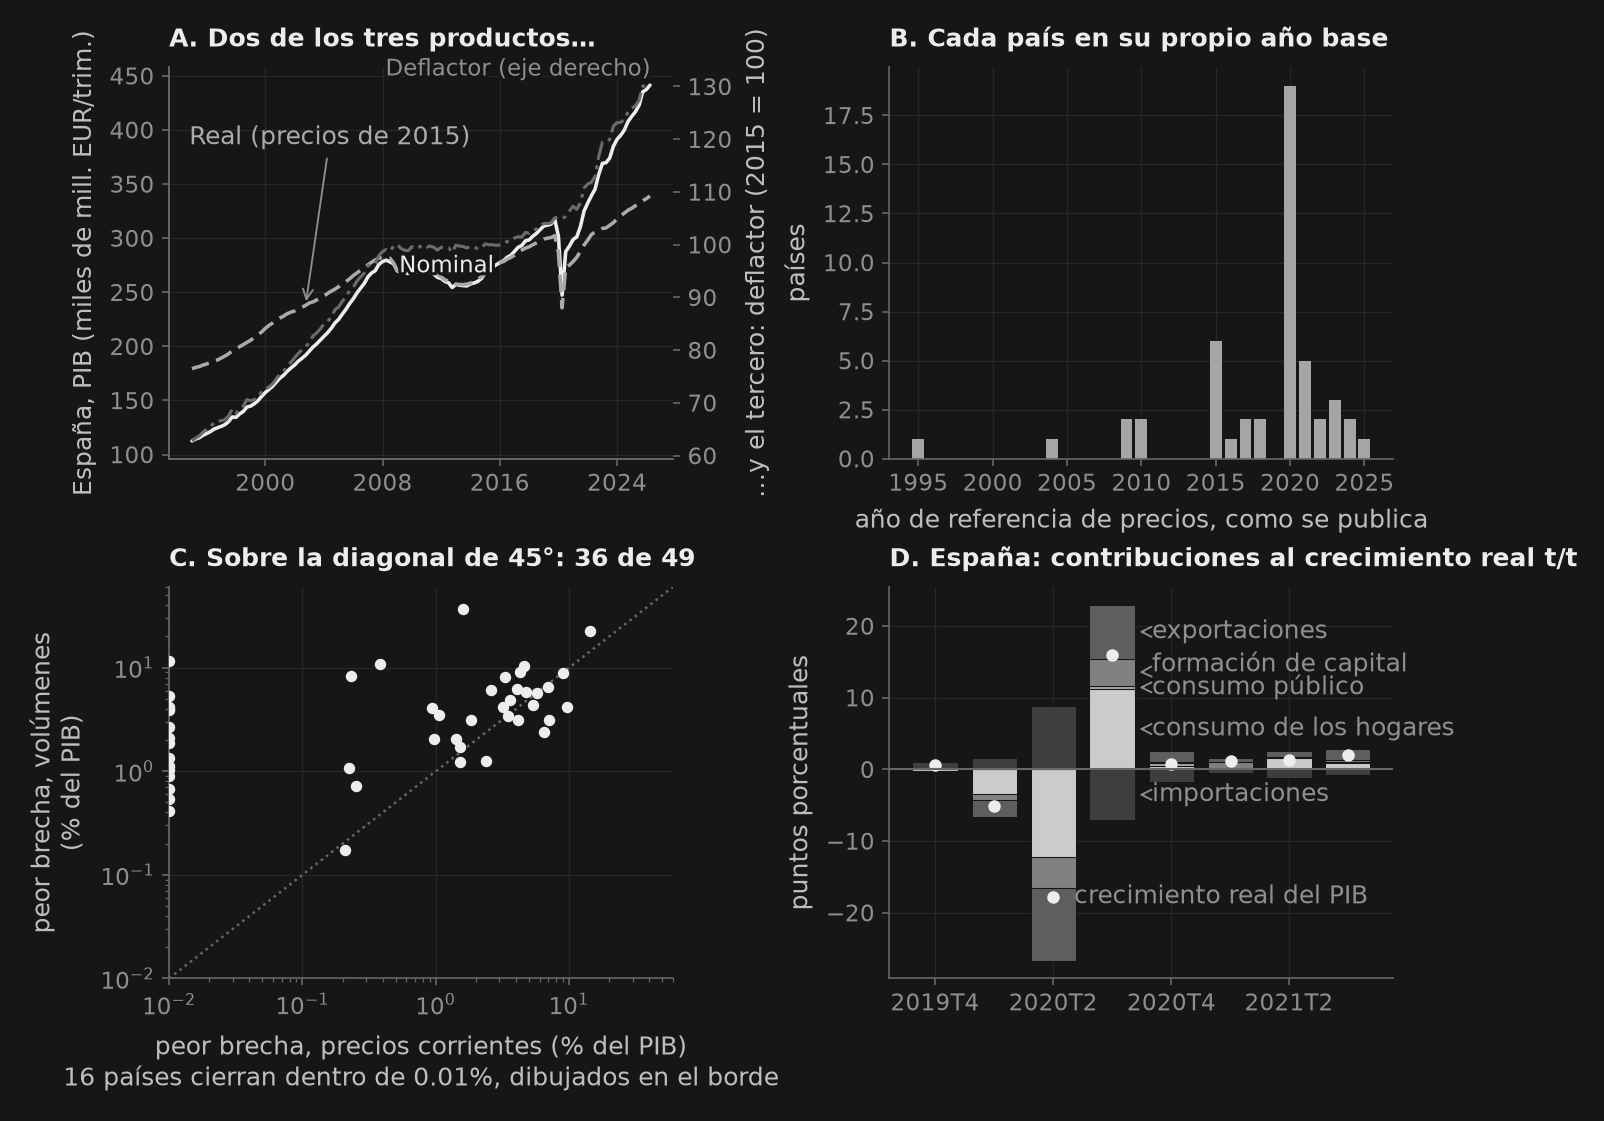

In [10]:
cols = _nbstyle.palette(5)                  # el más destacado primero
lss = _nbstyle.styles(5)

fig, axes = _nbstyle.figura(2, 2)
(axA, axB), (axC, axD) = axes

# A. Los tres productos para un país: un mismo objeto visto de tres maneras.
# El deflactor necesita su propio eje (es un índice, no un importe monetario);
# cada serie lleva su nombre al lado y el del deflactor dice en qué eje se lee.
g = qna15.loc["ESP"]
(ln_nom,) = axA.plot(g.index, g["gdp"] / 1e3, color=cols[0], lw=1.7, ls="-", label="Nominal")
axA.plot(g.index, g["gdp_real"] / 1e3, color=cols[2], lw=1.7, ls=lss[1],
         label="Real (precios de 2015)")
axA.set_ylabel("España, PIB (miles de mill. EUR/trim.)")
axA.set_title("A. Dos de los tres productos…")
# El panel es estrecho: una marca cada ocho años deja los años legibles.
marcas = [t for t in g.index if t.year % 8 == 0 and t.quarter == 1]
axA.set_xticks(marcas); axA.set_xticklabels([str(t.year) for t in marcas])
axA2 = axA.twinx()
axA2.plot(g.index, g["gdp_defl"], color=_nbstyle.S3["color"], lw=1.5, ls=lss[2],
          label="Deflactor (eje derecho)")
axA2.set_ylabel("…y el tercero: deflactor (2015 = 100)")
axA2.grid(False)

# B. Los años de referencia que la fuente realmente envía.
yrs = meta["price_ref_year"].dropna().astype(int).value_counts().sort_index()
axB.bar(yrs.index, yrs.values, color=_nbstyle.tono(0.7), width=0.8)
axB.set_title("B. Cada país en su propio año base")
axB.set_ylabel("países")
axB.set_xlabel("año de referencia de precios, como se publica")

# C. La identidad: exacta a precios corrientes, no en volúmenes. Ejes
# logarítmicos porque las brechas abarcan cuatro órdenes de magnitud; los
# países cuyas cuentas cierran en *exactamente* cero no caben en un eje
# logarítmico, así que se apoyan en el borde izquierdo y el pie lo dice en vez
# de esconderlos.
FLOOR = 0.01
gap_n = score["nominal_absmax"].clip(lower=FLOOR)
gap_r = score["real_absmax"].clip(lower=FLOOR)
# Todo lo que está en el suelo o por debajo cae en el borde izquierdo, no solo
# los ceros exactos — decimos cuántos, para que esa pila no se lea como nube.
n_floored = int((score["nominal_absmax"] <= FLOOR).sum())
axC.scatter(gap_n, gap_r, s=20, color=_nbstyle.TINTA, zorder=3)
edge = [FLOOR, 60]
axC.plot(edge, edge, color=_nbstyle.SPINE, ls=":", lw=1.2, zorder=1)
axC.set_xscale("log"); axC.set_yscale("log")
axC.set_xlim(*edge); axC.set_ylim(*edge)
axC.set_xlabel(f"peor brecha, precios corrientes (% del PIB)\n"
               f"{n_floored} países cierran dentro de {FLOOR}%, dibujados en el borde")
axC.set_ylabel("peor brecha, volúmenes\n(% del PIB)")
axC.set_title(f"C. Sobre la diagonal de 45°: "
              f"{(score['real_absmax'] > score['nominal_absmax']).sum()} de {len(score)}")

# D. El pago — contribuciones al desplome y rebote de 2020. Cada segmento se
# nombra con una guía desde la barra más alta; el punto, junto al del desplome.
NOMBRES = {"cons_hh": "consumo de los hogares", "cons_gov": "consumo público",
           "capform": "formación de capital", "exports": "exportaciones",
           "imports": "importaciones"}
sp = contrib.loc["ESP"]
win = sp[(sp.index >= "2019-10-01") & (sp.index <= "2021-07-01")]
bottom_pos = np.zeros(len(win)); bottom_neg = np.zeros(len(win))
shades = [_nbstyle.tono(t) for t in (0.86, 0.70, 0.54, 0.38, 0.22)]
centros = {}                                 # componente -> centro de su segmento, barra a barra
for k, name in enumerate(COMPS):
    v = win[name].to_numpy()
    base_ = np.where(v >= 0, bottom_pos, bottom_neg)
    axD.bar(win.index, v, bottom=base_, width=70, color=shades[k],
            edgecolor=_nbstyle.FONDO, linewidth=0.5)
    centros[name] = base_ + v / 2
    bottom_pos = bottom_pos + np.where(v >= 0, v, 0.0)
    bottom_neg = bottom_neg + np.where(v < 0, v, 0.0)
axD.plot(win.index, win["gdp"], color=_nbstyle.UNIVERSAL_COLORS[0], marker="o", ms=5, lw=0)
axD.axhline(0, color=_nbstyle.SPINE, lw=1.0)
axD.set_title("D. España: contribuciones al crecimiento real t/t")
axD.set_ylabel("puntos porcentuales")
axD.set_xticks(win.index[::2])
axD.set_xticklabels([d.to_period("Q").strftime("%YT%q") for d in win.index[::2]])
# La barra guía es la del rebote (la pila positiva más alta): a su derecha las
# barras son pequeñas y los nombres caben en columna, separados al menos 3 pp.
guia = int(np.argmax(bottom_pos))
x_guia = win.index[guia]
alturas = sorted((float(centros[n][guia]), n) for n in COMPS)
ys = [h for h, _ in alturas]
for i in range(1, len(ys)):
    ys[i] = max(ys[i], ys[i - 1] + 3.2)
for (h, name), yt in zip(alturas, ys):
    axD.annotate(NOMBRES[name], xy=(x_guia + pd.Timedelta(days=36), h),
                 xytext=(x_guia + pd.Timedelta(days=62), yt), textcoords="data",
                 ha="left", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
caida = int(np.argmin(win["gdp"].to_numpy()))
axD.annotate("crecimiento real del PIB", xy=(win.index[caida], float(win["gdp"].iloc[caida])),
             xytext=(10, 0), textcoords="offset points", ha="left", va="center",
             color=_nbstyle.NOTA)

# El nombre del real va a la banda vacía de arriba, con una guía hasta su
# curva: junto a la línea se salía del eje y se imprimía sobre el rótulo del
# eje derecho. El nominal sí cabe junto al suyo, a media anchura del panel.
axA.annotate("Real (precios de 2015)",
             xy=(g.index[len(g) // 4], float(g["gdp_real"].iloc[len(g) // 4]) / 1e3),
             xytext=(0.04, 0.82), textcoords="axes fraction", ha="left", va="center",
             color=cols[2], arrowprops=_nbstyle.FLECHA)
xA0, xA1 = axA.get_xlim()
_nbstyle.etiquetar(axA, artistas=[ln_nom], donde=xA0 + 0.55 * (xA1 - xA0))
_nbstyle.etiquetar(axA2)
plt.show()


### 1.8 Paso 8 — El mismo PIB, medido de otras dos maneras

Hasta el momento hemos estudiado la contabilidad nacional por el lado del **gasto**, pero la macroeconomía también está interesada en la distribución 

| enfoque | la pregunta que responde | la identidad |
|---|---|---|
| **Gasto** | quién compró el producto | $Y = C + G + I + X - M$ |
| **Producción** (oferta) | qué ramas lo produjeron | $Y = \sum_j \mathrm{VA}_j + (D21 - D31) + \mathrm{YA1}$ |
| **Renta** | a quién se le pagó | $Y = D1 + B2A3G + (D2 - D3)$ |

No son tres formas de ver los mismos datos. El gasto sale de encuestas de comercio y consumo, la producción de encuestas de producción y registros de IVA, la renta de nóminas y datos fiscales. Su relativa coincidencia es un logro, pero su esporádica discrepacia puede contener información de interés.

1. **La cobertura no es universal.** Argentina, Islandia y —sorprendentemente— **Estados Unidos** no publican nada en el flujo por rama de la OCDE; las cuentas industriales estadounidenses son una publicación aparte del BEA.  Otros cuatro países publican el valor añadido solo en volumen.
2. **Dos de las columnas de valor añadido son partidas informativas, no sumandos.** `va_mfg` (manufacturas) está *dentro* de `va_ind` (industria), y `va_services` es la suma de las siete columnas de servicios que ya aparecen por separado. Sumar todas las columnas `va_*` cuenta dos veces buena parte de la economía — la celda mide exactamente cuánto. `QNA_VA_ADDITIVE` nombra las diez que sí suman.
3. **Cada flujo publica su propio PIB, y los números no siempre coinciden.**

In [11]:
from puremacro.fetch import QNA_VA_ADDITIVE, QNA_VA_MEMO

published = pd.DataFrame({
    "gasto": panel["gdp"].groupby(level="code").count(),
    "produccion": panel["va_total"].groupby(level="code").count(),
    "renta": panel["comp_emp"].groupby(level="code").count(),
}).gt(0)
n = published.sum()
print(f"Países que publican cada enfoque, de {len(published)}:")
print(f"  gasto {n['gasto']}   producción {n['produccion']}   renta {n['renta']}"
      f"   los tres {int(published.all(axis=1).sum())}\n")

# «Sin producción» cubre dos situaciones distintas y no deben imprimirse como
# una sola lista: un país puede estar ausente del flujo, o publicar el valor
# añadido solo en volumen — en cuyo caso las series están aquí, pero no a
# precios corrientes, así que la identidad no se puede evaluar sin que el dato
# se haya perdido.
vol_only = sorted(c for c in published.index[~published["produccion"]]
                  if panel.loc[c, "va_total_real"].notna().any())
absent_out = sorted(set(published.index[~published["produccion"]]) - set(vol_only))
print(f"  ausentes del flujo por rama: {', '.join(absent_out)}")
print(f"    (las cuentas industriales de EE. UU. son una publicación del BEA, no de la OCDE)")
print(f"  valor añadido solo en volumen, sin identidad a precios corrientes: "
      f"{', '.join(vol_only)}")
print(f"  sin cuentas de renta: {', '.join(sorted(published.index[~published['renta']]))}")

# La trampa de las partidas informativas, medida en vez de advertida.
va_add = panel[list(QNA_VA_ADDITIVE)].sum(axis=1, min_count=len(QNA_VA_ADDITIVE))
va_all = panel[list(QNA_VA_ADDITIVE) + list(QNA_VA_MEMO)].sum(axis=1)
print(f"\nSuma de las {len(QNA_VA_ADDITIVE)} ramas aditivas / va_total: "
      f"{float((va_add / panel['va_total']).mean()):.4f}  <- cuadra")
print(f"Suma de TODAS las {len(QNA_VA_ADDITIVE) + len(QNA_VA_MEMO)} columnas va_* / va_total: "
      f"{float((va_all / panel['va_total']).mean()):.4f}  <- la trampa: las manufacturas "
      f"están dentro de la industria, y va_services agrega siete de las otras")

assert np.isclose(float((va_add / panel["va_total"]).mean()), 1.0, atol=2e-3)
assert float((va_all / panel["va_total"]).mean()) > 1.5

Países que publican cada enfoque, de 49:
  gasto 49   producción 42   renta 39   los tres 35

  ausentes del flujo por rama: ARG, AUS, CAN, ISL, ISR, NZL, USA
    (las cuentas industriales de EE. UU. son una publicación del BEA, no de la OCDE)
  valor añadido solo en volumen, sin identidad a precios corrientes: 
  sin cuentas de renta: ARG, BRA, CHL, CHN, CRI, IDN, IND, ISL, NZL, SAU

Suma de las 10 ramas aditivas / va_total: 1.0001  <- cuadra
Suma de TODAS las 12 columnas va_* / va_total: 1.8071  <- la trampa: las manufacturas están dentro de la industria, y va_services agrega siete de las otras


In [12]:
score = qna_identity(panel)

print("Cómo cierra cada identidad, a precios corrientes (% del PIB, |media| entre trimestres):")
summary = pd.DataFrame({
    stem: {"países": int(score[f"{stem}_mean"].notna().sum()),
           "mediana |media|": score[f"{stem}_mean"].abs().median(),
           "mediana absmax": score[f"{stem}_absmax"].median(),
           "peor": score[f"{stem}_absmax"].max()}
    for stem in ("nominal", "output", "income")}).T
summary.index = ["gasto", "producción", "renta"]
print(summary.round(3).to_string())
print("Las tres son identidades contables y las tres se comportan como tales. Los lados")
print("de producción y renta cierran *más* ajustadamente que el del gasto, y eso es sobre")
print("todo el vaivén del ajuste estacional de §1.6: menos componentes, menos ajustes")
print("independientes que puedan no sumar.")

print("\nDonde los flujos discrepan sobre el PIB mismo (máx |diferencia|, % del PIB):")
cross = score[["crossflow_output", "crossflow_income"]].dropna(how="all")
agree = (cross < 1e-6).sum()
print(f"  idénticos en {agree['crossflow_output']} de {cross['crossflow_output'].notna().sum()} "
      f"países (producción) y {agree['crossflow_income']} de "
      f"{cross['crossflow_income'].notna().sum()} (renta). El resto:")
print(cross[(cross > 1e-6).any(axis=1)].round(2).sort_values(
    "crossflow_income", ascending=False).head(6).to_string())
print("Vienen de tablas fuente distintas dentro de la misma publicación. Cargárselas a")
print("un componente sería una afirmación de medición sobre ese componente; se informan")
print("aparte precisamente para que nadie lo haga sin darse cuenta.")

# La famosa.
usa = score.loc["USA"]
print(f"\nEstados Unidos no tiene aquí cuentas por rama, pero su lado de la renta\n"
      f"es el caso interesante: la identidad falla hasta en "
      f"{usa['income_absmax']:.2f}% del PIB. Ese residual tiene nombre —\nla "
      f"**discrepancia estadística PIB-RIB (GDP-GDI)**— y una literatura (Nalewaik 2010): "
      f"dos mediciones\nindependientes de la misma magnitud que no coinciden, y cuya "
      f"brecha es en sí misma\ninformativa sobre el ciclo. La mayoría de las oficinas "
      f"europeas la fuerzan a cero, y eso\nes una decisión de presentación, no una "
      f"medición mejor.")

assert score["output_mean"].abs().median() < 0.05
assert score["income_mean"].abs().median() < 0.05
assert np.isnan(usa["output_mean"])          # no está en el flujo por rama de la OCDE
assert usa["income_absmax"] > 1.0            # la discrepancia PIB-RIB

Cómo cierra cada identidad, a precios corrientes (% del PIB, |media| entre trimestres):
            países  mediana |media|  mediana absmax    peor
gasto         48.0            0.013           1.235  14.452
producción    41.0            0.001           0.238   8.454
renta         37.0            0.003           0.629   4.593
Las tres son identidades contables y las tres se comportan como tales. Los lados
de producción y renta cierran *más* ajustadamente que el del gasto, y eso es sobre
todo el vaivén del ajuste estacional de §1.6: menos componentes, menos ajustes
independientes que puedan no sumar.

Donde los flujos discrepan sobre el PIB mismo (máx |diferencia|, % del PIB):
  idénticos en 33 de 43 países (producción) y 32 de 40 (renta). El resto:
      crossflow_output  crossflow_income
code                                    
MEX               1.57              2.04
DEU               0.00              1.77
RUS               1.71              1.71
FRA               0.00              

### 1.9 Paso 9 — Lo que cada enfoque ve y los otros no

Los tres enfoques coinciden sobre el PIB. Discrepan sobre *todo lo demás*, y ese es el sentido de tener los tres: cada uno lleva una descomposición que los otros sencillamente no contienen.

**El lado de la producción lleva la estructura industrial.** Nada del lado del gasto te dice qué fracción de una economía son manufacturas, y la respuesta se mueve: abajo, la participación de las manufacturas en el valor añadido ha caído en casi todos los países desde finales de los noventa. Las excepciones informan tanto como la regla — **la de Irlanda subió nueve puntos**, que es la misma contabilidad multinacional que §2.1 señala cuando la participación del consumo irlandés parece inverosímilmente baja.

**El lado de la renta lleva la participación del trabajo**, $D1 / Y$ — uno de los hechos estilizados de Kaldor, el $1-\alpha$ de la tecnología Cobb–Douglas del curso, y el objeto que §3 va a buscar a EU-KLEMS. Leída directamente de las cuentas va del 27% al 57%, lo cual *no* es un hecho sobre tecnología.

**Ese rango es el problema de medición, no la economía.** La remuneración de asalariados `D1` cubre **solo a los asalariados**. La renta laboral de los trabajadores por cuenta propia no está en `D1` en absoluto — está dentro de `surplus_mixed`, porque `B2A3G` es excedente bruto de explotación *y renta mixta* juntos, y las cuentas no los separan. Así que una economía con mucho trabajo por cuenta propia contabiliza su renta laboral como renta del capital por construcción. Eso es exactamente Gollin (2002), y por eso México lee 27%, Turquía 30% e Italia 40% mientras Alemania lee 53%. El cociente crudo ordena a los países por trabajo autónomo tanto como por participaciones factoriales, y por eso §3 recurre a `puremacro.labor_share.gollin_adjusted_ls` en vez de leer este cociente de las cuentas, y por eso el ranking de abajo no debe citarse nunca como un ranking de participaciones factoriales.

In [13]:
YEARS_EARLY, YEARS_LATE = range(1995, 2000), range(2021, 2026)


def va_share(col, years):
    s = 100 * panel[col] / panel["va_total"]
    return s[s.index.get_level_values("date").year.isin(years)].groupby(level="code").mean()


struct = pd.DataFrame({
    "manuf 95-99": va_share("va_mfg", YEARS_EARLY),
    "manuf 21-25": va_share("va_mfg", YEARS_LATE),
    "finanzas": va_share("va_fin", YEARS_LATE),
    "público": va_share("va_public", YEARS_LATE),
    "TIC": va_share("va_ict", YEARS_LATE),
}).dropna(subset=["manuf 21-25"])
struct["cambio"] = struct["manuf 21-25"] - struct["manuf 95-99"]
moved = struct.dropna(subset=["cambio"]).sort_values("cambio")

print(f"Participación de las manufacturas en el valor añadido: cayó en "
      f"{(moved['cambio'] < 0).sum()} de {len(moved)} países, mediana "
      f"{moved['cambio'].median():+.1f} pp")
print(f"Nivel hoy: mediana {struct['manuf 21-25'].median():.1f}%, de "
      f"{struct['manuf 21-25'].idxmin()} con {struct['manuf 21-25'].min():.1f}% a "
      f"{struct['manuf 21-25'].idxmax()} con {struct['manuf 21-25'].max():.1f}%.\n")
print("Desindustrialización más rápida, y los cuatro que fueron al revés:")
print(pd.concat([moved.head(5), moved.tail(4)]).round(1).to_string())
print(f"\nLuxemburgo es la especialización más nítida del panel: las finanzas son el "
      f"{struct.loc['LUX', 'finanzas']:.1f}% de su valor añadido frente a una mediana de "
      f"{struct['finanzas'].median():.1f}%,\ny las manufacturas solo el "
      f"{struct.loc['LUX', 'manuf 21-25']:.1f}%. Irlanda es el otro polo — y sus "
      f"+{struct.loc['IRL', 'cambio']:.0f} pp de manufacturas son\npropiedad intelectual "
      f"contabilizada en el país, el mismo artefacto que distorsiona sus\nparticipaciones "
      f"del gasto.")

assert (moved["cambio"] < 0).sum() > 0.75 * len(moved)
assert struct.loc["IRL", "cambio"] > 0
assert struct.loc["LUX", "finanzas"] > 3 * struct["finanzas"].median()

Participación de las manufacturas en el valor añadido: cayó en 31 de 36 países, mediana -3.7 pp
Nivel hoy: mediana 15.4%, de LUX con 4.5% a IRL con 33.6%.

Desindustrialización más rápida, y los cuatro que fueron al revés:
      manuf 95-99  manuf 21-25  finanzas  público   TIC  cambio
code                                                           
ROU          24.6         15.1       3.5     13.8   7.6    -9.5
FIN          25.5         16.9       3.7     21.2   6.5    -8.6
LUX          12.2          4.5      26.5     18.2   5.5    -7.7
ZAF          21.5         13.9      23.4      8.5   7.7    -7.6
SWE          22.0         14.5       4.4     20.7   8.0    -7.5
KOR          28.1         28.7       6.0     17.4   4.9     0.6
CHE          19.3         20.1       8.7     18.1   4.8     0.8
BGR          12.2         14.0       6.5     16.5   8.1     1.8
IRL          24.6         33.6       4.3      9.4  19.9     9.0

Luxemburgo es la especialización más nítida del panel: las finanzas son 

In [14]:
labour = (100 * panel["comp_emp"] / panel["gdp_income"])
labour = (labour[labour.index.get_level_values("date").year >= 2015]
          .groupby(level="code").mean().dropna().sort_values())

print(f"Participación del trabajo D1/Y en las cuentas de renta, {len(labour)} países, 2015+:")
print(f"  mediana {labour.median():.1f}%, de {labour.index[0]} con {labour.iloc[0]:.1f}% "
      f"a {labour.index[-1]} con {labour.iloc[-1]:.1f}%")
print("\nLos cinco de abajo y los cinco de arriba:")
print(pd.concat([labour.head(5), labour.tail(5)]).round(1).to_string())

low = [c for c in labour.head(6).index if c != "IRL"]
print(f"\nLee el fondo de esa lista como una advertencia, no como un hallazgo. "
      f"{', '.join(low[:-1])} y {low[-1]}\nestán entre las economías con más trabajo por "
      f"cuenta propia del panel, y la renta laboral\nde un autónomo se contabiliza en "
      f"surplus_mixed, nunca en comp_emp. Irlanda está ahí por\nla razón contraria — el "
      f"denominador, no el numerador: los beneficios multinacionales\ninflan el PIB sin "
      f"pasar por ninguna nómina residente. El margen laboral desprotegido\nde §4.3 y el "
      f"ajuste de Gollin de §3.2 tratan exactamente de esto — y §3.2 lo hace\n"
      f"además con la tasa de informalidad TRIMESTRAL, que es la única que "
      f"puede corregir una tendencia.")

# La participación del trabajo sin ajustar no es un parámetro tecnológico: su
# dispersión es mucho mayor que cualquier dispersión plausible de alpha.
assert 40.0 < labour.median() < 55.0
assert labour.max() - labour.min() > 20.0
assert labour["MEX"] < labour["DEU"]

Participación del trabajo D1/Y en las cuentas de renta, 39 países, 2015+:
  mediana 47.2%, de MEX con 26.8% a CHE con 57.3%

Los cinco de abajo y los cinco de arriba:
code
MEX    26.8
IRL    28.5
TUR    29.6
COL    34.0
GRC    36.6
SVN    51.1
FRA    51.7
USA    52.5
DEU    53.2
CHE    57.3

Lee el fondo de esa lista como una advertencia, no como un hallazgo. MEX, TUR, COL, GRC y ROU
están entre las economías con más trabajo por cuenta propia del panel, y la renta laboral
de un autónomo se contabiliza en surplus_mixed, nunca en comp_emp. Irlanda está ahí por
la razón contraria — el denominador, no el numerador: los beneficios multinacionales
inflan el PIB sin pasar por ninguna nómina residente. El margen laboral desprotegido
de §4.3 y el ajuste de Gollin de §3.2 tratan exactamente de esto — y §3.2 lo hace
además con la tasa de informalidad TRIMESTRAL, que es la única que puede corregir una tendencia.


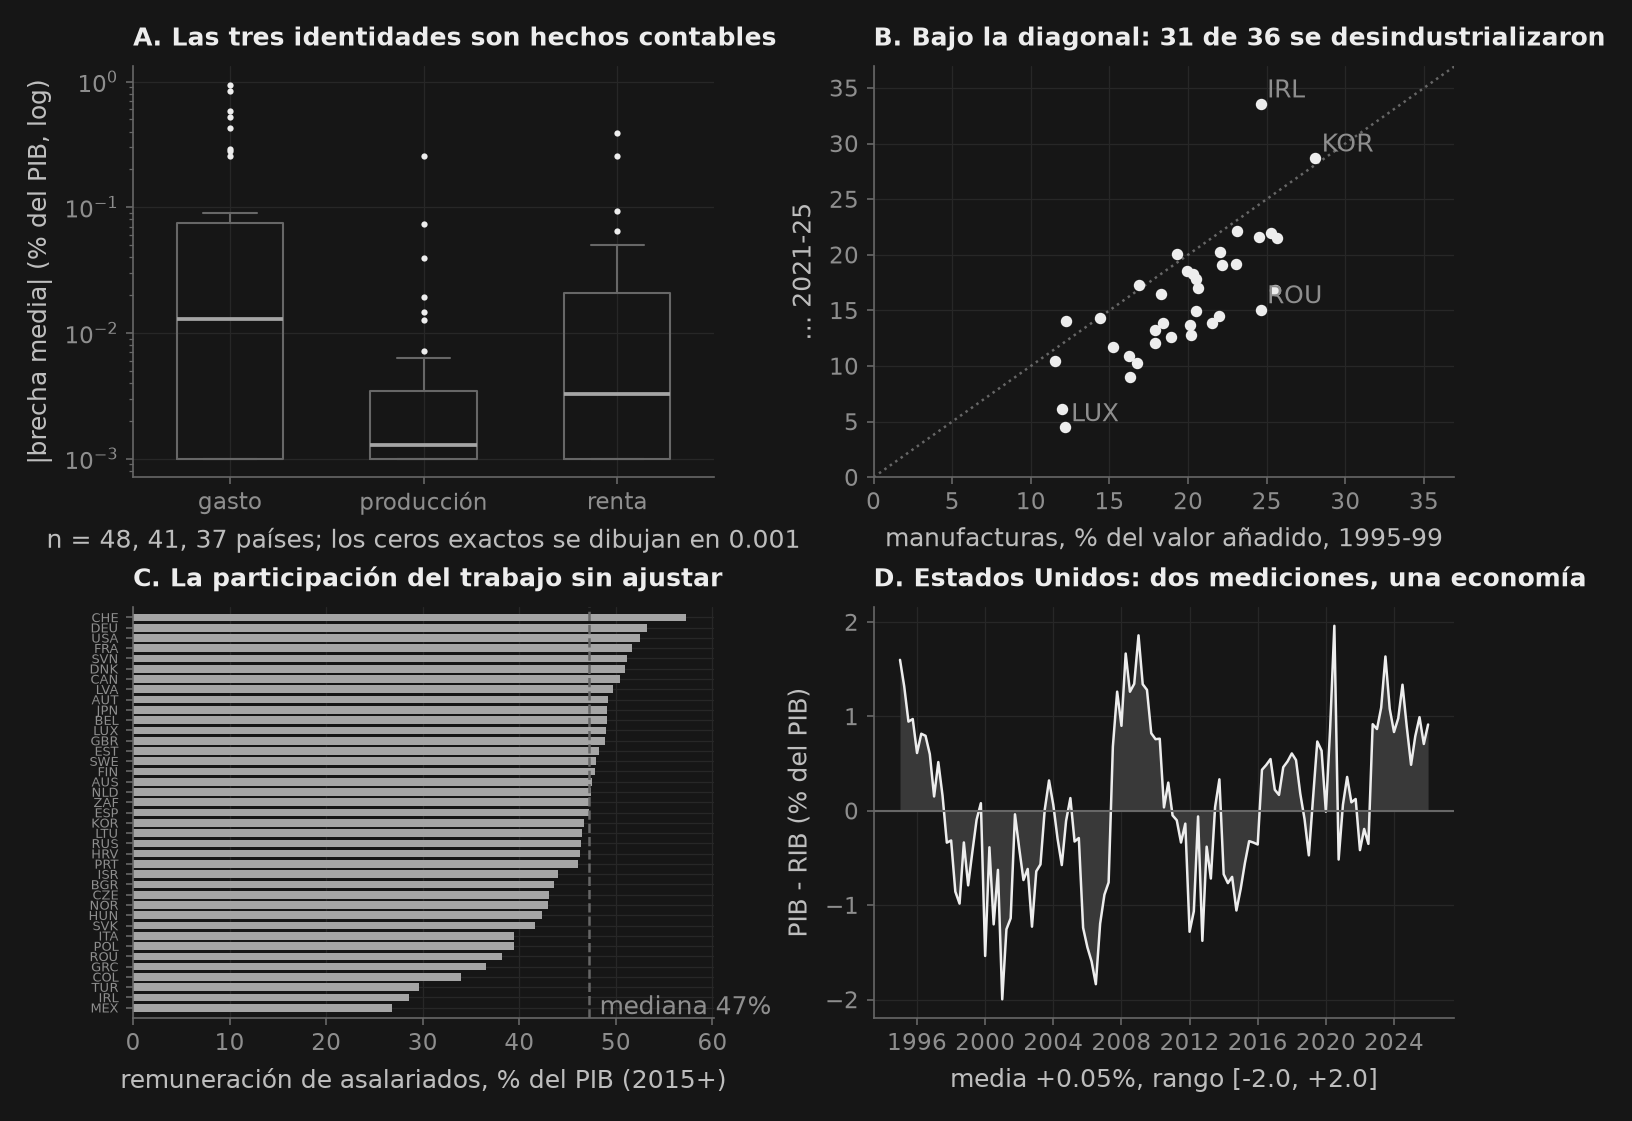

In [15]:
fig, axes = _nbstyle.figura(2, 2)
(axA, axB), (axC, axD) = axes

# A. Con qué precisión cierra cada identidad. Eje logarítmico: la distribución
# abarca cuatro órdenes de magnitud y uno lineal mostraría solo un pico en cero.
FLOOR_A = 1e-3
box = [score[f"{k}_mean"].abs().clip(lower=FLOOR_A).dropna()
       for k in ("nominal", "output", "income")]
axA.boxplot(box, tick_labels=["gasto", "producción", "renta"],
            widths=0.55,
            boxprops=dict(color=_nbstyle.SPINE),
            whiskerprops=dict(color=_nbstyle.SPINE),
            capprops=dict(color=_nbstyle.SPINE),
            medianprops=dict(color=_nbstyle.UNIVERSAL_COLORS[1], lw=1.8),
            flierprops=dict(marker="o", ms=3, color=_nbstyle.TINTA, mfc=_nbstyle.TINTA, mec="none"))
axA.set_yscale("log")
axA.set_ylabel("|brecha media| (% del PIB, log)")
axA.set_title("A. Las tres identidades son hechos contables")
axA.set_xlabel(f"n = {', '.join(str(len(b)) for b in box)} países; "
               f"los ceros exactos se dibujan en {FLOOR_A:g}")

# B. Desindustrialización: todo país bajo la diagonal perdió peso manufacturero.
axB.scatter(struct["manuf 95-99"], struct["manuf 21-25"], s=20, color=_nbstyle.TINTA, zorder=3)
lim = (0, max(struct[["manuf 95-99", "manuf 21-25"]].max()) * 1.1)
axB.plot(lim, lim, color=_nbstyle.SPINE, ls=":", lw=1.2)
axB.set_xlim(*lim); axB.set_ylim(*lim)
for c in ("IRL", "LUX", "KOR", "ROU"):
    if c in struct.index:
        axB.annotate(c, (struct.loc[c, "manuf 95-99"], struct.loc[c, "manuf 21-25"]),
                     xytext=(3, 3), textcoords="offset points", color=_nbstyle.NOTA)
axB.set_xlabel("manufacturas, % del valor añadido, 1995-99")
axB.set_ylabel("… 2021-25")
axB.set_title(f"B. Bajo la diagonal: {(struct['cambio'] < 0).sum()} de "
              f"{struct['cambio'].notna().sum()} se desindustrializaron")

# C. La participación del trabajo, y por qué su dispersión es una advertencia.
order = labour.sort_values()
axC.barh(np.arange(len(order)), order.to_numpy(), color=_nbstyle.tono(0.7), height=0.75)
axC.set_yticks(np.arange(len(order)))
axC.set_yticklabels(order.index, fontsize=6.0)
axC.axvline(order.median(), color=_nbstyle.SPINE, ls="--", lw=1.2)
axC.annotate(f"mediana {order.median():.0f}%", xy=(order.median(), 0), xytext=(5, 0),
             textcoords="offset points", ha="left", va="center", color=_nbstyle.NOTA)
axC.set_xlabel("remuneración de asalariados, % del PIB (2015+)")
axC.set_title("C. La participación del trabajo sin ajustar")
axC.set_ylim(-1, len(order))

# D. El único residual con nombre propio: el PIB de EE. UU. medido por el gasto
# frente al mismo PIB medido por la renta.
us = panel.loc["USA"]
gdi_gap = (100 * (us["gdp_income"] - us["comp_emp"] - us["surplus_mixed"]
                  - us["taxes_prod_imp_net"]) / us["gdp_income"]).dropna()
axD.fill_between(gdi_gap.index, gdi_gap.to_numpy(), 0, color=_nbstyle.gris("0.75"), lw=0)
axD.plot(gdi_gap.index, gdi_gap.to_numpy(), color=_nbstyle.TINTA, lw=1.2, ls="-")
axD.axhline(0, color=_nbstyle.SPINE, lw=1.0)
axD.set_ylabel("PIB - RIB (% del PIB)")
axD.set_title("D. Estados Unidos: dos mediciones, una economía")
axD.set_xlabel(f"media {gdi_gap.mean():+.2f}%, rango "
               f"[{gdi_gap.min():+.1f}, {gdi_gap.max():+.1f}]")

plt.show()


### 1.10 Paso 10 — Comprobar los tres productos

La construcción está terminada. Antes de usarla, un último control: separar las tres familias de productos y verificar que la tercera se rehace exactamente desde las otras dos. No es orden — es una afirmación sobre qué es primario. El archivo nominal y el de deflactores son los dos que necesitas; el de volúmenes es una comodidad, y por eso la instantánea del curso viaja sin él y §1.2 lo rehace en una línea.

**Los archivos se escriben al final, en §6**, y no aquí, por dos razones. Una es que el bloque laboral que §5 usa todavía no está exprimido, y congelar la mitad de los datos a mitad de camino es cómo se acaba con dos versiones del mismo panel. La otra es que lo que necesitan los cuadernos siguientes no son los tres *productos* —nominal, deflactores, volúmenes— sino los cuatro *bloques*: gasto, renta, producción y mercado laboral. §6 escribe esos cuatro.

In [16]:
products = {"nominales": panel[NOMINALES],
            "deflactores": panel[DEFLACTORES],
            "volúmenes": panel[VOLUMENES]}

print(f"Los tres productos, {panel.index.get_level_values('code').nunique()} países "
      f"x {dates.nunique()} trimestres:")
for name, frame in products.items():
    obs = int(frame.notna().to_numpy().sum())
    print(f"  {name:15s} {frame.shape[1]:2d} series, {obs:>7,} observaciones")

# El marco de volúmenes se deriva de los otros dos — todo el punto de §1. El
# deflactor solo está definido donde ambas patas son estrictamente positivas,
# así que comparamos sobre la muestra donde existen los tres productos, y no
# sobre tres dropna() separados, que alinearían trimestres distintos en silencio.
recovered = 100.0 * products["nominales"]["gdp"] / products["deflactores"]["gdp_defl"]
both = pd.concat([recovered.rename("desde_los_otros_dos"),
                  products["volúmenes"]["gdp_real"].rename("publicado")],
                 axis=1).dropna()
print(f"\nVolumen del PIB rehecho desde nominal / deflactor, verificado en "
      f"{len(both):,} trimestres: peor error relativo "
      f"{float(((both['desde_los_otros_dos'] - both['publicado']).abs() / both['publicado']).max()):.1e}")
assert np.allclose(both["desde_los_otros_dos"], both["publicado"], rtol=1e-9)

Los tres productos, 49 países x 126 trimestres:
  nominales       37 series, 180,417 observaciones
  deflactores     31 series, 146,371 observaciones
  volúmenes       31 series, 146,371 observaciones

Volumen del PIB rehecho desde nominal / deflactor, verificado en 5,812 trimestres: peor error relativo 0.0e+00


### 1.11 Paso 11 — ¿Hasta dónde hacia atrás?
El panel construido empieza en 1995 porque ahí es donde empiezan los cuadros vigentes de la OCDE, por el mayor reporte de economías Europeas desde esa fecha, aunque no es donde empiezan las contabilidades nacionales trimestrales de cada economía, ni donde empieza la captación de información estadística nacional. España publica cuentas nacionales trimestrales desde 1970, Japón desde 1955, Estados Unidos desde 1947... — aunque con metodologías distintas al SCN 2023.

Llegar hasta ellas obliga a enfrentarse a algo que la lección ha podido esquivar hasta el moment. Todos los números de §1.1–§1.10 vienen de una **única añada** o ***vintage***: una metodología, una base de precios, un conjunto de cuadros fuente, aplicados de manera uniforme a toda la muestra. La construcción de una contabilidad trimestral más larga implica empalmar añadas. 

**El empalme como un cociente.** Dos añadas de las mismas cuentas se solapan durante un tramo de trimestres. Sobre ese tramo la serie antigua y la nueva son dos mediciones de la misma economía, así que su cociente debería ser una constante — la antigua está expresada en un año base ya abandonado, en unidades ya redefinidas, sobre una metodología ya revisada, y todo eso es *nivel*. Un **empalme por cocientes** estima esa constante sobre el solape, la aplica a todo el segmento antiguo y conserva exactamente los niveles nuevos tal como se publicaron. Lo que sobrevive de la añada antigua son sus **tasas de crecimiento**; lo que se descarta son sus niveles, que nunca fueron comparables.

Esa es la operación correcta, y viene con su propia prueba. Si el cociente es realmente constante, las dos añadas coinciden sobre el crecimiento y el empalme es inocuo. Si el cociente **deriva** a lo largo del solape, no coinciden, y entonces el nivel empalmado depende de a qué trimestre uno se haya anclado — que es otra manera de decir que la respuesta no está determinada por los datos. Así que la estabilidad del cociente no es un diagnóstico impreso al lado del resultado. *Es* la garantía del resultado, y `qna_long_panel` la informa costura a costura en lugar de presentar una serie empalmada como si fuera una sola medición.

In [17]:
from puremacro.fetch import qna_long_panel
from puremacro.fetch.longpanel import KNOWN_GAPS, long_panel_residual

LARGO = DATA / "oecd_qna_largo.csv"
LARGO_COSTURAS = DATA / "oecd_qna_largo_seams.csv"

if VIVO:
    largo, costuras = qna_long_panel(["ESP", "JPN"], spine=panel, return_seams=True)
else:
    largo = (pd.read_csv(LARGO, parse_dates=["date"])
               .set_index(["code", "date"]).sort_index())
    costuras = pd.read_csv(LARGO_COSTURAS, parse_dates=["date"])

_val = [c for c in largo.columns if not c.startswith("src_")]
print("Las dos economías con una historia archivada que los cuadros vigentes no arrastran:")
for code in largo.index.get_level_values("code").unique():
    s = largo.loc[code]
    add = int((s.index < pd.Timestamp("1995-01-01")).sum())
    print(f"  {code}: {s.index.min().to_period('Q')}-{s.index.max().to_period('Q')}, "
          f"{len(s)} trimestres — {add} de ellos antes de que empiecen los cuadros de la OCDE")
    for src, n in s["src_gdp"].value_counts().items():
        span = s.index[s["src_gdp"] == src]
        print(f"       {n:>3d} de {src:<13s} {span.min().to_period('Q')}"
              f"-{span.max().to_period('Q')}")

print(f"\nTodo lo demás que se comprobó y se rechazó, con el motivo "
      f"({len(KNOWN_GAPS)} países):")
for code, why in KNOWN_GAPS.items():
    print(f"  {code}: {why.split('.')[0]}.")

Las dos economías con una historia archivada que los cuadros vigentes no arrastran:
  ESP: 1970Q1-2026Q2, 226 trimestres — 100 de ellos antes de que empiecen los cuadros de la OCDE
       126 de oecd          1995Q1-2026Q2
        60 de ine_base1995  1980Q1-1994Q4
        40 de ine_base1986  1970Q1-1979Q4
  JPN: 1955Q2-2026Q2, 285 trimestres — 159 de ellos antes de que empiecen los cuadros de la OCDE
       126 de oecd          1995Q1-2026Q2
        99 de jp_sna68      1955Q2-1979Q4
        60 de jp_sna93      1980Q1-1994Q4

Todo lo demás que se comprobó y se rechazó, con el motivo (7 países):
  DEU: Pre-1991 German nominal accounts cover West Germany only.
  MEX: INEGI serves nothing before 1993 and is identical to the OECD after dividing by four.
  BRA: IBGE's quarterly accounts start 1996Q1, the same quarter as the OECD, across all seven candidate tables.
  CHL: Banco Central reaches 1990Q1, 24 quarters before the OECD, but only for gdp/inv/exports/imports and only NSA, via ~1 MB HT

#### La costura es el hallazgo

Veintiocho empalmes: dos países, siete columnas de gasto, dos costuras cada una. La tabla siguiente es la garantía entera, y no sale limpia — **nueve de los veintiocho derivan más del dos por ciento que el empalme está dispuesto a certificar.**

No están repartidos al azar. La formación bruta de capital es inestable en todas las costuras de los dos países, que es lo que cabe esperar del agregado que carga con la variación de existencias: un componente pequeño, de movimientos violentos, medido de manera distinta por cada añada que lo toca. Y el peor empalme de la tabla es el **consumo público japonés en la costura del SCN de 1968** — un cociente de 396 que recorre de 362 a 453 a lo largo del solape. Eso no es un error de medición. El Sistema de Cuentas Nacionales de 1968 trazaba la frontera del sector público en otro sitio, así que las dos series no son dos estimaciones de una cantidad; son estimaciones de dos cantidades. Un empalme por cocientes no puede reparar un cambio de definición, y el estadístico de deriva es su manera de decirlo.

In [18]:
costuras["deriva %"] = 100.0 * costuras["ratio_drift"]
tabla = costuras[["code", "column", "older", "date", "overlap_n", "ratio",
                  "deriva %", "stable"]].copy()
tabla["date"] = tabla["date"].dt.to_period("Q")
print(f"Cada empalme, y si está determinado ({len(costuras)} costuras):\n")
print(tabla.sort_values(["code", "column"]).to_string(index=False,
                                                      float_format=lambda v: f"{v:.3f}"))

malas = costuras[~costuras["stable"]]
print(f"\n{len(malas)} de {len(costuras)} costuras derivan más del "
      f"{100 * 0.02:.0f}% y se informan como inestables:")
for _, r in malas.sort_values("ratio_drift", ascending=False).iterrows():
    print(f"  {r['code']} {r['column']:<9s} {r['older']:<13s} "
          f"deriva {100*r['ratio_drift']:5.2f}%  "
          f"el cociente recorre {r['ratio_min']:.3f}-{r['ratio_max']:.3f} "
          f"en {int(r['overlap_n'])} trimestres")
print("\nInestable no quiere decir descartado — `drop_unstable=True` dejaría en blanco\n"
      "esos trimestres, y viene desactivado por defecto, porque borrar datos en\n"
      "silencio es su propio modo de fallo. Quiere decir que el nivel de esa columna,\n"
      "tan atrás, no está fijado por el solape, y quien la use debería saberlo.")

assert len(malas) > 0
assert set(malas["column"]) >= {"capform"}

Cada empalme, y si está determinado (28 costuras):

code   column        older   date  overlap_n   ratio  deriva %  stable
 ESP  capform ine_base1995 1995Q1         40   1.096     3.314   False
 ESP  capform ine_base1986 1980Q1         76   1.196     5.125   False
 ESP cons_gov ine_base1995 1995Q1         40   1.010     0.942    True
 ESP cons_gov ine_base1986 1980Q1         76   1.128     2.607   False
 ESP  cons_hh ine_base1995 1995Q1         40   1.075     1.318    True
 ESP  cons_hh ine_base1986 1980Q1         76   1.081     0.995    True
 ESP  exports ine_base1995 1995Q1         40   1.007     1.617    True
 ESP  exports ine_base1986 1980Q1         76   0.995     2.555   False
 ESP      gdp ine_base1995 1995Q1         40   1.062     1.139    True
 ESP      gdp ine_base1986 1980Q1         76   1.103     0.865    True
 ESP  imports ine_base1995 1995Q1         40   1.033     1.471    True
 ESP  imports ine_base1986 1980Q1         76   1.033     2.389   False
 ESP      inv ine_base199

#### Lo que cuesta una cadena: la identidad deja de cerrar

§1.6 estableció que la identidad del gasto cierra **exactamente** en precios corrientes — hasta el último bit, porque la oficina la construye así. Eso es una propiedad de una única añada, y la celda siguiente muestra qué le pasa a lo largo de una cadena.

El motivo merece verse antes que el número. Cada columna se empalma de manera **independiente**, contra su propio solape, con su propio cociente. El consumo recibe una constante, la inversión otra, las exportaciones una tercera. Siete constantes que no son iguales no pueden preservar una suma, así que la identidad que se cumplía hasta $10^{-16}$ dentro de una añada no puede sobrevivir a ser ensamblada a partir de tres.

Lo notable es lo pequeño que es el daño, y lo legiblemente que crece con la distancia. Dentro del segmento de la OCDE el residuo es **cero a la precisión impresa**, como debe ser. Una añada más atrás son unas décimas de punto porcentual del PIB; dos añadas más atrás, sobre las cifras japonesas del SCN de 1968, es alrededor del uno por ciento. Ese es el precio de cincuenta años extra, denominado en la moneda que §1 enseñó a leer.

In [19]:
resid = long_panel_residual(largo)
rel = 100.0 * resid / largo["gdp"]

filas = []
for code in largo.index.get_level_values("code").unique():
    s, m = largo.loc[code], rel.loc[code]
    for src, g in m.groupby(s["src_gdp"]):
        span = s.index[s["src_gdp"] == src]
        filas.append({"code": code, "añada": src, "trimestres": len(g),
                      "desde": span.min().to_period("Q"),
                      "hasta": span.max().to_period("Q"),
                      "|residuo| medio, % del PIB": g.abs().mean(),
                      "peor": g.abs().max()})
por_fuente = pd.DataFrame(filas)
print("Y = C + G + I + X - M, en precios corrientes, a lo largo de la cadena:\n")
print(por_fuente.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

_oecd = por_fuente[por_fuente["añada"] == "oecd"]["|residuo| medio, % del PIB"]
print(f"\nDentro de la añada de la OCDE la identidad cierra hasta "
      f"{_oecd.max():.4f}% del PIB — el cero exacto de §1.6, intacto. Todo segmento "
      f"más antiguo\nse ensambla a partir de siete constantes independientes, y "
      f"ninguno de ellos cierra.")
assert float(_oecd.max()) < 1e-4      # coma flotante, no un hueco económico
assert por_fuente["|residuo| medio, % del PIB"].max() < 2.0

Y = C + G + I + X - M, en precios corrientes, a lo largo de la cadena:

code        añada  trimestres  desde  hasta  |residuo| medio, % del PIB  peor
 ESP ine_base1986          40 1970Q1 1979Q4                       0.689 1.310
 ESP ine_base1995          60 1980Q1 1994Q4                       0.269 0.746
 ESP         oecd         126 1995Q1 2026Q2                       0.000 0.000
 JPN     jp_sna68          99 1955Q2 1979Q4                       0.950 2.336
 JPN     jp_sna93          60 1980Q1 1994Q4                       0.560 1.124
 JPN         oecd         126 1995Q1 2026Q2                       0.000 0.000

Dentro de la añada de la OCDE la identidad cierra hasta 0.0000% del PIB — el cero exacto de §1.6, intacto. Todo segmento más antiguo
se ensambla a partir de siete constantes independientes, y ninguno de ellos cierra.


#### Lo que muestran cincuenta años y no pueden mostrar veinticinco

Los archivos son nominales — precios corrientes, sin deflactores, sin volúmenes — y eso no es la limitación que parece. §1 dedicó diez pasos a establecer qué estadísticos sobreviven a qué transformación, y la **cuota sobre el PIB** es el que sobrevive a todo: un cociente de dos cifras a precios corrientes, en la misma moneda y en el mismo trimestre, inmune a la base de precios, inmune al año de referencia, inmune al tipo de cambio. Es exactamente el estadístico que una cadena de añadas puede transportar.

Y basta para los dos mayores hechos estructurales de la historia de posguerra de estas economías.

**Japón construyó y luego dejó de construir.** La formación bruta de capital va al 31% del PIB a finales de los cincuenta, sube hasta el **42% en el pico de la era de alto crecimiento, a principios de los setenta**, y cae durante cuarenta años hasta el 25%. Son diecisiete puntos de oscilación en la parte del producto que va a capital — el auge inversor durante el milagro económico japonés y su *debacle*. Una muestra que empiece en 1995 ve el último tercio del descenso únicamente.

**España construyó un Estado.** El consumo público está por debajo del 10% del PIB a principios de los setenta y en torno al 20% hoy: se duplica. La duplicación no es gradual — ocurre entre 1975 y 1993, que es el periodo entre el fin de la dictadura y la culminación del Estado del bienestar, y es el mayor movimiento individual de las tablas de cualquiera de los dos países. La formación de capital española cuenta la otra historia española: 29% a principios de los setenta, hasta el 23% a principios de los ochenta, de vuelta al **28% en 2005–09**, y luego un desplome hasta el 19% — el auge y la crisis de la construcción, visibles como un viaje de ida y vuelta de nueve puntos en la contabilidad nacional.

In [20]:
CUOTAS = {"cons_hh": "consumo de los hogares", "cons_gov": "consumo público",
          "capform": "formación bruta de capital"}
bloques = {}
for code in largo.index.get_level_values("code").unique():
    s = largo.loc[code]
    sh = pd.DataFrame({k: 100.0 * s[k] / s["gdp"] for k in CUOTAS})
    sh["exportaciones netas"] = 100.0 * (s["exports"] - s["imports"]) / s["gdp"]
    bloques[code] = sh.groupby((sh.index.year // 5) * 5).mean()

for code, b in bloques.items():
    print(f"{code}: cuotas de gasto, % del PIB, medias quinquenales\n")
    print(b.round(1).to_string())
    for col in list(CUOTAS.values()) + ["exportaciones netas"]:
        c = b[col if col in b.columns else
              [k for k, v in CUOTAS.items() if v == col][0]]
        print(f"    {col:<26s} {c.min():5.1f} ({c.idxmin()}s) a "
              f"{c.max():5.1f} ({c.idxmax()}s), una oscilación de {c.max()-c.min():.1f} pp")
    print()

ESP: cuotas de gasto, % del PIB, medias quinquenales

      cons_hh  cons_gov  capform  exportaciones netas
date                                                 
1970     63.3       9.8     29.1                 -1.5
1975     63.9      11.8     27.2                 -2.2
1980     64.6      14.2     22.9                 -1.5
1985     61.9      15.0     24.1                 -0.7
1990     61.2      17.0     24.6                 -2.5
1995     60.2      17.1     23.4                 -0.7
2000     58.8      16.7     27.1                 -2.6
2005     57.7      18.3     28.5                 -4.4
2010     58.9      20.0     19.5                  1.6
2015     58.1      18.7     19.9                  3.3
2020     55.9      20.4     21.5                  2.3
2025     55.7      19.2     21.4                  3.7
    consumo de los hogares      55.7 (2025s) a  64.6 (1980s), una oscilación de 8.9 pp
    consumo público              9.8 (1970s) a  20.4 (2020s), una oscilación de 10.6 pp
    formación b

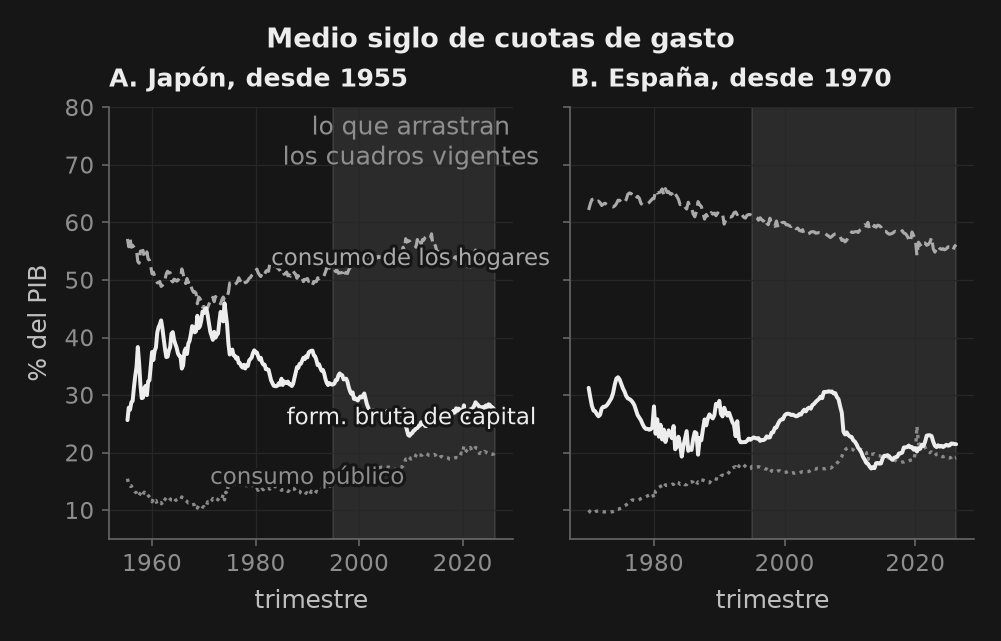

In [21]:
# El tamaño lo pone el perfil: 6.4 x 4.0 in en el cuaderno, la ranura en la lámina.
fig, axes = _nbstyle.figura(1, 2, sharey=True, figsize=plt.rcParams["figure.figsize"])
for ax, code, titulo in zip(axes, ("JPN", "ESP"),
                            ("A. Japón, desde 1955", "B. España, desde 1970")):
    s = largo.loc[code]
    sh = pd.DataFrame({k: 100.0 * s[k] / s["gdp"] for k in CUOTAS})
    estilo = {"cons_hh": (cols[2], (0, (4, 2)), 1.5),
              "cons_gov": (cols[3], (0, (1, 1.4)), 1.6),
              "capform": (cols[0], "-", 1.9)}
    for key, label in CUOTAS.items():
        col, ls, lw = estilo[key]
        ax.plot(sh.index, sh[key], color=col, lw=lw, ls=ls, label=label)
    ax.axvspan(pd.Timestamp("1995-01-01"), sh.index.max(), color=_nbstyle.RECESION, zorder=0)
    ax.set_title(titulo)
    ax.set_xlabel("trimestre")
    # Una marca cada 20 años: a 12 pt en medio panel, una por década se solapa.
    anos = [y for y in range(1960, 2021, 20) if sh.index.min().year <= y <= sh.index.max().year]
    ax.set_xticks(pd.to_datetime([f"{y}-01-01" for y in anos]), [str(y) for y in anos])
    # Hasta 80 para que la nota del tramo sombreado no caiga sobre ninguna línea.
    ax.set_ylim(5, 80)
axes[0].set_ylabel("% del PIB")
# La nota va una sola vez: el tramo sombreado es el mismo en los dos paneles.
axes[0].annotate("lo que arrastran\nlos cuadros vigentes",
                 xy=(pd.Timestamp("2010-01-01"), 79),
                 color=_nbstyle.NOTA, ha="center", va="top")
fig.suptitle("Medio siglo de cuotas de gasto")
# Los tres nombres se escriben una sola vez, en el panel de la izquierda: los
# dos paneles llevan las mismas series con el mismo trazo, y en el de España
# "form. bruta de capital" y "consumo público" caen uno al lado del otro.
_nbstyle.etiquetar(axes[0],
                   nombres={"formación bruta de capital": "form. bruta de capital"})
plt.show()


#### Y lo que no puede transportar: una edición antigua es otro instrumento

Todo lo anterior es una afirmación sobre **niveles y cuotas**, y eso es deliberado. La tentación, con cincuenta años extra de datos trimestrales, es calcular segundos momentos sobre ellos — volatilidades, correlaciones, persistencia, todo el aparato de la medición del ciclo económico. El archivo no lo sostiene, y la demostración es lo bastante corta como para hacerla aquí.

Tómense quince años que dos ediciones distintas del archivo cubran a la vez, y compárense. No dos países, ni dos métodos: **los mismos trimestres de la misma economía, leídos desde dos añadas.** El desacuerdo es tremendamente desigual entre las dos cosas que uno podría querer de la serie. Sobre la *tendencia* las ediciones están cerca: difieren en unas décimas de punto porcentual al año en crecimiento acumulado. Sobre los *movimientos trimestre a trimestre* apenas coinciden — las tasas de crecimiento de la edición antigua son alrededor de dos tercios de volátiles, y los movimientos trimestrales de las dos añadas correlacionan en torno a un medio, que para dos mediciones de una misma economía es una cosa notable que tener que informar.

Esa asimetría tiene causa. Las revisiones se acumulan en el nivel despacio y de forma suave, así que una senda de niveles es algo robusto que leer de una añada antigua. Los *movimientos* trimestrales son lo primero que una oficina estadística mejora y lo último que acierta, así que los segundos momentos de una edición antigua son una propiedad de la edición tanto como de la economía. Una añada archivada es un testigo fiable de adónde fue una economía y poco fiable de lo accidentado que fue el viaje — lo que autoriza las tendencias y cuotas de arriba, y prohíbe calcular volatilidades, correlaciones o persistencia sobre la historia empalmada.

In [22]:
# Este archivo se lee tres veces en la lección —aquí, en §4.1 y en §4.4— y son
# 1,25 millones de filas, así que se lee una vez y se recuerda. El gzip no es
# lo que cuesta: `pd.read_csv` descomprime los 3,8 MB en 0,2 s. Lo que cuesta
# son las fechas. `pd.PeriodIndex(col.astype(str), freq="Q")` analiza 1,25
# millones de cadenas de una en una y tarda 3 s por llamada, y la columna solo
# tiene 318 trimestres distintos: analizar los DISTINTOS y devolverlos a su
# sitio tarda 20 ms y da las mismas marcas de tiempo. Trescientas cadenas
# leídas cuatro mil veces cada una son casi un minuto en una tableta.
_ARCHIVOS = {}


def archivo(ruta):
    """El archivo congelado en `ruta`: leído una vez, fechado una vez, guardado."""
    clave = str(ruta)
    if clave not in _ARCHIVOS:
        s = pd.read_csv(ruta, dtype={"edition": str})
        donde, trimestres = pd.factorize(s["date"])
        _ARCHIVOS[clave] = pd.DataFrame({
            "code": s["code"], "variable": s["variable"],
            "date": pd.PeriodIndex(trimestres.astype(str),
                                   freq="Q").to_timestamp()[donde],
            "edition": s["edition"], "value": pd.to_numeric(s["value"])})
    return _ARCHIVOS[clave]


_arch = archivo(DATA / "oecd_stes_vintages_gdp.csv.gz")


def edicion(code, ed):
    d = _arch[(_arch["code"] == code) & (_arch["edition"] == ed)]
    return d.set_index("date")["value"].sort_index()


print("Los mismos trimestres de la misma economía, leídos desde dos ediciones:\n")
for code, vieja, nueva, lo, hi in (("ESP", "199907", "200505", "1980", "1994"),
                                   ("JPN", "199907", "201112", "1980", "1993")):
    # sort=True es el default actual de concat sobre índices de fechas; pandas 4 lo cambia.
    j = pd.concat([edicion(code, vieja).rename("vieja"),
                   edicion(code, nueva).rename("nueva")],
                  axis=1, sort=True).dropna().loc[f"{lo}-01-01":f"{hi}-12-31"]
    g_vieja = 100.0 * np.log(j["vieja"]).diff().dropna()
    g_nueva = 100.0 * np.log(j["nueva"]).diff().dropna()
    cum_vieja = 100.0 * float(np.log(j["vieja"].iloc[-1] / j["vieja"].iloc[0]))
    cum_nueva = 100.0 * float(np.log(j["nueva"].iloc[-1] / j["nueva"].iloc[0]))
    print(f"  {code} {lo}-{hi}, {len(g_vieja)} trimestres, ediciones {vieja} vs {nueva}")
    _anios = int(hi) - int(lo) + 1
    print(f"    crecimiento acumulado    {cum_vieja:6.2f}%  vs {cum_nueva:6.2f}%   "
          f"-> {abs(cum_vieja-cum_nueva):.2f} pp de diferencia en {_anios} años "
          f"({abs(cum_vieja-cum_nueva)/_anios:.2f} pp al año)")
    print(f"    sd del crecimiento trim. {g_vieja.std():6.3f}%  vs {g_nueva.std():6.3f}%   "
          f"-> la edición nueva es {g_nueva.std()/g_vieja.std():.2f} veces más volátil")
    print(f"    correlación de las tasas de crecimiento trimestral: {g_vieja.corr(g_nueva):+.3f}\n")
    assert abs(cum_vieja - cum_nueva) < 7.0
    assert g_nueva.std() > 1.3 * g_vieja.std()

Los mismos trimestres de la misma economía, leídos desde dos ediciones:

  ESP 1980-1994, 59 trimestres, ediciones 199907 vs 200505
    crecimiento acumulado     35.10%  vs  34.60%   -> 0.49 pp de diferencia en 15 años (0.03 pp al año)
    sd del crecimiento trim.  0.539%  vs  0.952%   -> la edición nueva es 1.76 veces más volátil
    correlación de las tasas de crecimiento trimestral: +0.477

  JPN 1980-1993, 55 trimestres, ediciones 199907 vs 201112
    crecimiento acumulado     44.97%  vs  50.88%   -> 5.91 pp de diferencia en 14 años (0.42 pp al año)
    sd del crecimiento trim.  0.666%  vs  1.043%   -> la edición nueva es 1.57 veces más volátil
    correlación de las tasas de crecimiento trimestral: +0.645



## 2. Para qué sirven los tres productos

Las cuentas ya están construidas. De aquí en adelante el panel se usa en vez de construirse, y las cuatro subsecciones siguientes son cuatro respuestas distintas a «cuál de los tres productos pide esta pregunta».

- **§2.1 — las participaciones.** Una pregunta *nominal*: la identidad cierra exacta a precios corrientes, así que $C/Y$ e $I/Y$ son números puros que no necesitan conversión de moneda.
- **§2.2 — los precios relativos.** Una pregunta de *deflactores*: los cocientes de deflactores son los precios relativos que le importan a la macroeconomía, y no existen en ningún otro producto. Es también donde hay que elegir el denominador, y el consumo neto de duraderos es el que pide la teoría.
- **§2.3 — qué contamina el tipo de cambio.** Una pregunta sobre cuál de los dos primeros sobrevive al contacto con $E$, y cuál no.
- **§2.4 — los duraderos como capital.** Una pregunta que necesita los tres, sobre un corte más fino de las mismas cuentas.

### 2.1 La identidad y las participaciones del gasto que implica

A precios corrientes la identidad es un hecho contable, no una aproximación: lo que no cuadra es la **discrepancia estadística** publicada, y la imprimimos en vez de esconderla.

**Ojo con el concepto.** El $C$ de la identidad es el consumo de los *hogares* (sector institucional `S1M` = hogares + ISFLSH), entre 36% y 69% del PIB. La contabilidad nacional también publica el *consumo final total* (`S1`), que incluye al gobierno y ronda el 75% del PIB — otro objeto, que el panel guarda en una columna aparte, `cons_gov`.

In [23]:
shares = pd.DataFrame({
    "C_hh/Y": 100 * panel["cons_hh"] / panel["gdp"],
    "G/Y":    100 * panel["cons_gov"] / panel["gdp"],
    "I/Y":    100 * panel["inv"] / panel["gdp"],
    "NX/Y":   100 * (panel["exports"] - panel["imports"]) / panel["gdp"],
    # Y - (C + G + formación bruta de capital + X - M): la discrepancia estadística
    "disc/Y": 100 * (panel["gdp"] - panel["cons_hh"] - panel["cons_gov"]
                     - panel["capform"] - panel["exports"] + panel["imports"]) / panel["gdp"],
})
tab = (shares.groupby(level="code").mean().round(1)
             .dropna(subset=["C_hh/Y"]).sort_values("C_hh/Y"))
print(f"Participaciones medias del gasto desde 1995 (nominal, % del PIB), {len(tab)} países:")
print(tab.to_string())

faltan = sorted(set(panel.index.get_level_values("code")) - set(tab.index))
if faltan:
    print(f"\nSin desglose publicado del consumo de los hogares: {', '.join(faltan)}")
print(f"C_hh/Y: mediana {tab['C_hh/Y'].median():.1f}%, "
      f"de {tab.index[0]} con {tab['C_hh/Y'].iloc[0]:.1f}% "
      f"a {tab.index[-1]} con {tab['C_hh/Y'].iloc[-1]:.1f}%.")
print("El fondo de esa lista es una advertencia sobre el *denominador*, no sobre "
      "hogares ahorradores: Luxemburgo e Irlanda contabilizan en el PIB beneficios\n"
      "de multinacionales y propiedad intelectual que nunca llegan a un hogar "
      "residente, y Arabia Saudí y Noruega hacen lo propio con las rentas del\n"
      "petróleo. Para esas economías el denominador sensato es el INB, no el PIB.")

# El consumo de los hogares se agrupa en torno al 55% del PIB; el consumo final
# total (hogares + gobierno) superaría el 80% -- otro concepto.
assert 48.0 < tab["C_hh/Y"].median() < 62.0
# La identidad cierra: lo que sobra es la discrepancia estadística.
assert tab["disc/Y"].abs().max() < 3.0

Participaciones medias del gasto desde 1995 (nominal, % del PIB), 48 países:
      C_hh/Y   G/Y   I/Y  NX/Y  disc/Y
code                                  
LUX     36.3  16.3  18.8  28.1    -0.0
SAU     37.6  22.2  24.4  12.9     0.1
IRL     39.7  15.1  25.1  19.4    -0.0
NOR     43.7  21.2  22.9  11.2    -0.0
NLD     46.4  23.8  20.7   8.8     0.0
SWE     47.0  25.6  22.7   4.4     0.0
DNK     47.4  24.7  21.2   6.1     0.0
CZE     48.8  19.9  27.9   2.6     0.0
FIN     50.9  22.8  22.8   3.0    -0.1
KOR     51.4  13.7  30.9   2.7     0.0
RUS     51.8  18.0  20.9   8.2    -0.3
BEL     51.8  22.8  22.8   1.8    -0.0
HUN     52.2  21.0  23.4   1.5    -0.0
ISR     52.3  23.3  23.8  -0.3     0.0
AUT     52.6  20.1  24.1   2.3    -0.0
ISL     52.7  24.8  21.9   0.4    -0.0
CHE     53.1  11.7  26.6   7.6    -0.0
EST     53.5  19.4  27.8  -1.9     0.4
SVN     53.9  19.2  23.0   2.5     0.0
JPN     54.0  18.3  27.5   0.2     0.0
FRA     54.3  23.7  21.4   0.2    -0.0
DEU     54.5  19.9  20.6  

### 2.2 Para qué sirven los deflactores: los precios relativos

Los deflactores no son solo un artefacto para llegar a magnitudes reales. Los cocientes de deflactores *son* los precios relativos que le importan a la macroeconomía:
- **Precio relativo de la inversión** $P_I/P_C$ — bienes de capital en unidades del bien de consumo. Este es el objeto de Greenwood, Hercowitz y Krusell (1997): su inverso, $q_t = P_C/P_I$, *es* el cambio técnico específico a la inversión.
- **Términos de intercambio** $P_X/P_M$ — el shock externo dominante para los exportadores de materias primas (Mendoza 1995; Kose 2002), que se mueve en direcciones opuestas para quien exporta cobre y para quien lo transforma.

**Dos advertencias, una sobre el numerador y otra sobre el denominador, y las dos importan.**

*Denominador:* deflacta por $P_C$, no por $P_Y$. El deflactor del PIB es un promedio que **contiene al propio $P_I$**, así que $P_I/P_Y$ encoge justo el movimiento que quieres medir; y en un exportador de materias primas $P_Y$ contiene además los precios de exportación, de modo que $P_I/P_Y$ mezcla en silencio los términos de intercambio. Las dos medidas difieren en 10-20 pp precisamente en esos países.

*Denominador, otra vez:* $P_C$ es también un promedio, y una de las cosas que hay dentro es **el precio de los bienes de consumo duradero** — coches, ordenadores, lavadoras: manufacturas cuyos precios caen por la misma razón por la que cae el del equipo. Dejarlos en el denominador de un cociente construido para medir el cambio técnico específico a la inversión compensa parte del hecho contra sí mismo. El bien de consumo del modelo es el flujo **no duradero**, que es por lo que Greenwood, Hercowitz y Krusell deflactan por no duraderos y servicios, y por lo que la reclasificación de §2.4, $C^{*} = C - C_d$, corresponde también al denominador de aquí y no solo a la tabla de volatilidades de allí. `durability=True` ya trajo el desglose; la celda de abajo lo convierte en un par (nominal, deflactor) más.

*Numerador:* la FBCF total **no es un solo bien**. Junta *maquinaria, equipo y TIC* —manufacturados, transables, y los activos que Gordon (1990) y GHK midieron de verdad— con *edificación y obra civil*, que se vierte en el sitio con mano de obra y cemento locales y casi no se comercia. Los dos llevan treinta años moviéndose en direcciones opuestas, así que el agregado $P_I$ promedia hasta desaparecer el hecho que debería mostrar. `qna_panel(..., assets=True)` desglosa la FBCF por activo para poder mirar cada uno.

In [24]:
XDUR = ["cons_semidur", "cons_nondur", "cons_serv"]     # C* = C - C_d


def cons_sin_duraderos(g):
    """Consumo de los hogares neto de duraderos, como par (nominal, deflactor).

    No hay ninguna línea C* publicada que copiar, así que se construye como §1
    construyó todos los demás deflactores: se suman los componentes a precios
    corrientes, se suman sus volúmenes y el deflactor implícito es 100 por el
    cociente. Restar los duraderos --en lugar de quedarse con "no duraderos"--
    es lo que hace que C* signifique lo mismo en los 37 países: Estados Unidos
    y Chile clasifican el consumo de los hogares en tres cubos, no en cuatro,
    de modo que no publican semiduraderos.
    """
    keep = [k for k in XDUR if k in g and not g[k].isna().all()]
    if not keep:
        return None
    nom = g[keep].dropna()
    vol = pd.concat([100.0 * g[k] / g[k + "_defl"] for k in keep],
                    axis=1, sort=True).dropna()
    idx = nom.index.intersection(vol.index)
    if len(idx) < 8:
        return None
    n, v = nom.loc[idx].sum(axis=1), vol.loc[idx].sum(axis=1)
    return pd.DataFrame({"cons_xdur": n, "cons_xdur_defl": 100.0 * n / v})


_xdur = {c: cons_sin_duraderos(panel.loc[c])
         for c in panel.index.get_level_values("code").unique()}
panel = panel.join(pd.concat({c: d for c, d in _xdur.items() if d is not None},
                             names=["code", "date"]))
print(f"C* = C - C_d construido para "
      f"{int(panel['cons_xdur_defl'].notna().groupby(level='code').any().sum())} "
      f"de los {panel.index.get_level_values('code').nunique()} países "
      f"(el resto no publica el desglose por durabilidad).")
assert {"cons_xdur", "cons_xdur_defl"}.issubset(panel.columns)


def cambio_acum(num, den, sobre=None):
    """Cambio % acumulado del cociente de deflactores num/den, por país.

    `sobre` restringe cada país a los trimestres en que esa columna también
    existe. Eso es lo que hace comparables dos denominadores: el desglose por
    durabilidad empieza más tarde que el deflactor del consumo agregado en
    varios países, y una década extra de P_C no es evidencia sobre P_C*.
    """
    out = {}
    for c in panel.index.get_level_values("code").unique():
        if num not in panel.columns:
            continue
        g = panel.loc[c]
        s = (g[num] / g[den]).dropna()
        if sobre is not None:
            s = s.reindex(g[sobre].dropna().index).dropna()
        if len(s) > 1:
            out[c] = 100.0 * (s.iloc[-1] / s.iloc[0] - 1.0)
    return pd.Series(out, dtype=float)


rel = pd.DataFrame({
    "P_I/P_C":  cambio_acum("inv_defl", "cons_hh_defl"),
    "P_eq/P_C": cambio_acum("inv_equip_defl", "cons_hh_defl"),
    "P_st/P_C": cambio_acum("inv_struct_defl", "cons_hh_defl"),
    "P_I/P_Y":  cambio_acum("inv_defl", "gdp_defl"),
    "P_X/P_M":  cambio_acum("exports_defl", "imports_defl"),
}).round(1).dropna(how="all").sort_values("P_eq/P_C")
print("Cambio acumulado desde la primera observación (%):")
print(rel.to_string())

ambos = rel.dropna(subset=["P_eq/P_C", "P_st/P_C"])
print(f"\nMedianas en los {len(ambos)} países con ambos activos — "
      f"equipo {ambos['P_eq/P_C'].median():+.0f}%, "
      f"construcción {ambos['P_st/P_C'].median():+.0f}%, "
      f"FBCF total {ambos['P_I/P_C'].median():+.0f}%.")
print(f"El equipo se abarató en términos relativos en {(rel['P_eq/P_C'] < 0).sum()} de "
      f"{rel['P_eq/P_C'].notna().sum()} países; la construcción en "
      f"{(rel['P_st/P_C'] < 0).sum()} de {rel['P_st/P_C'].notna().sum()}.")

brecha = (rel["P_I/P_Y"] - rel["P_I/P_C"]).abs().nlargest(3)
print("Donde más importa el denominador (P_I/P_C vs P_I/P_Y):",
      ", ".join(f"{c} {rel.loc[c, 'P_I/P_C']:+.0f} vs {rel.loc[c, 'P_I/P_Y']:+.0f}"
                for c in brecha.index))

# El hecho de GHK es un hecho sobre el *equipo*: mucho más nítido en el activo
# transable que en el agregado, y se invierte en el no transable.
assert ambos["P_eq/P_C"].median() < ambos["P_I/P_C"].median() < ambos["P_st/P_C"].median()
assert (rel["P_eq/P_C"].dropna() < 0).mean() > 0.85
# Los términos de intercambio del exportador de cobre mejoraron frente a los del
# importador que lo transforma: el shock que Mendoza (1995) pone en el centro de
# los ciclos de las economías emergentes.
assert rel.loc["CHL", "P_X/P_M"] > rel.loc["JPN", "P_X/P_M"]

C* = C - C_d construido para 37 de los 49 países (el resto no publica el desglose por durabilidad).
Cambio acumulado desde la primera observación (%):
     P_I/P_C  P_eq/P_C  P_st/P_C  P_I/P_Y  P_X/P_M
LTU    -41.2     -80.1       1.2    -50.4     39.8
EST    -43.5     -63.7     -24.6    -56.5     47.8
CZE    -29.6     -61.6      26.4    -29.7     13.1
AUS    -11.0     -60.8      24.5    -22.5     92.4
POL    -37.3     -57.6     -26.8    -34.7      2.0
USA    -15.1     -54.1      75.5    -17.7     17.3
PRT      1.2     -51.9      20.1     -7.9     17.1
CHL    -21.7     -51.2       3.5    -39.9    120.9
HRV     -9.7     -50.2      35.3    -18.2     20.8
HUN      2.1     -44.4      75.2    -15.4      2.3
ARG    -12.3     -43.7       NaN    -12.7     29.1
ITA    -17.4     -42.7       8.4    -16.9      2.5
ISR     12.4     -42.6      53.0      0.7     15.0
SVN      2.6     -42.5      72.1     -2.6     -0.2
NLD     -7.8     -41.2      13.0     -7.7      2.7
CAN     23.0     -40.6      57.5 

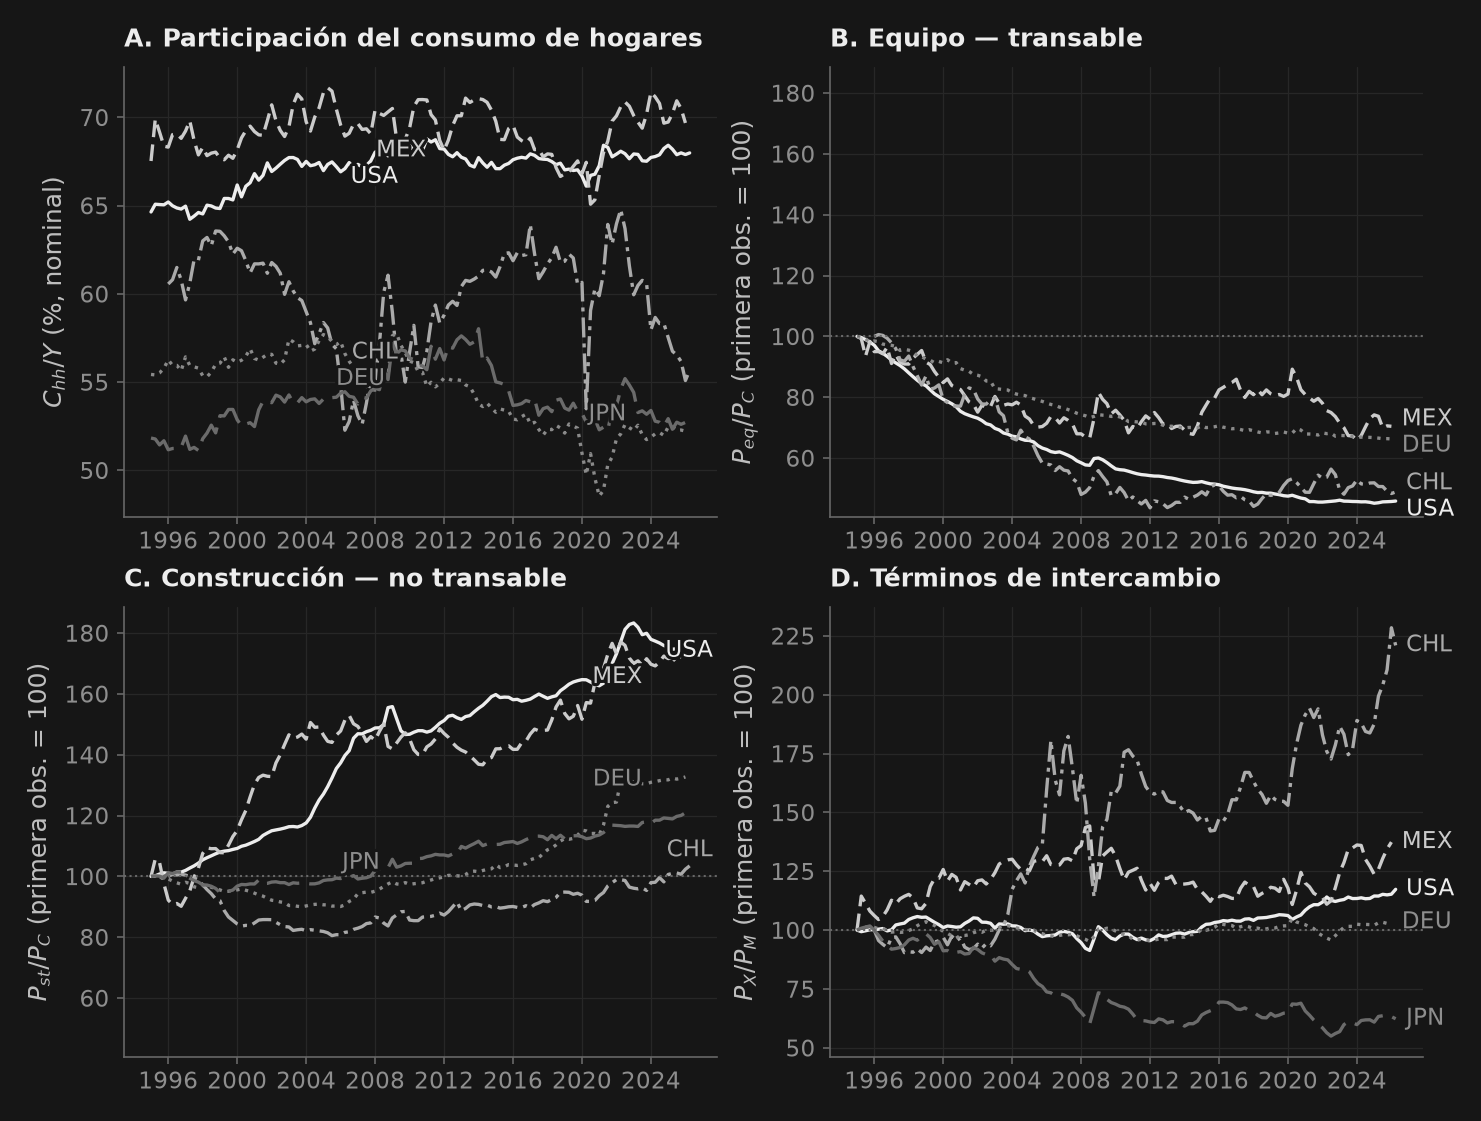

In [25]:
cols = _nbstyle.palette(5)                  # el más destacado primero
lss = _nbstyle.styles(5)
MUESTRA = ["USA", "MEX", "CHL", "DEU", "JPN"]

fig, axes = _nbstyle.figura(2, 2)
(axA, axB), (axC, axD) = axes
for k, c in enumerate(MUESTRA):
    g = panel.loc[c]
    kw = dict(color=cols[k], ls=lss[k], lw=1.6, label=c)
    axA.plot(g.index, 100 * g["cons_hh"] / g["gdp"], **kw)
    for ax, num, den in ((axB, "inv_equip_defl", "cons_hh_defl"),
                         (axC, "inv_struct_defl", "cons_hh_defl"),
                         (axD, "exports_defl", "imports_defl")):
        ratio = (g[num] / g[den]).dropna() if num in g else pd.Series(dtype=float)
        if len(ratio) > 1:
            ax.plot(ratio.index, 100 * ratio / ratio.iloc[0], **kw)

axA.set_title("A. Participación del consumo de hogares")
axA.set_ylabel("$C_{hh}/Y$ (%, nominal)")
axB.set_title("B. Equipo — transable")
axB.set_ylabel("$P_{eq}/P_C$ (primera obs. = 100)")
axC.set_title("C. Construcción — no transable")
axC.set_ylabel("$P_{st}/P_C$ (primera obs. = 100)")
axD.set_title("D. Términos de intercambio")
axD.set_ylabel("$P_X/P_M$ (primera obs. = 100)")
for ax in (axB, axC, axD):
    ax.axhline(100, color=_nbstyle.SPINE, ls=":", lw=1.0)
# misma escala en B y C: la divergencia es justamente el punto
lo = min(axB.get_ylim()[0], axC.get_ylim()[0])
hi = max(axB.get_ylim()[1], axC.get_ylim()[1])
axB.set_ylim(lo, hi); axC.set_ylim(lo, hi)
# Los países se nombran junto a su línea: dentro en la columna izquierda,
# tras el último punto en la derecha.
for ax in (axA, axC):
    _nbstyle.etiquetar(ax)
for ax in (axB, axD):
    _nbstyle.etiquetar(ax, donde="fin")
plt.show()


#### ¿Consumo de *qué*? El denominador, y un numerador más

Dos cambios sobre el mismo cociente, y los dos apuntan en la misma dirección.

1. **El denominador.** Cambiar $P_C$ por $P_{C^{*}}$ — consumo de los hogares neto de duraderos. Todo lo que hacía de $P_I/P_Y$ el cociente equivocado se aplica aquí en miniatura: un índice que contiene el precio que quieres medir no puede medirlo.
2. **Un numerador más.** Añadir $P_{cd}$, el precio de los propios duraderos. La §2.4 argumentará desde la *volatilidad* que un coche es capital del hogar; si eso es cierto, su **precio** debería comportarse como el precio del capital. Es la misma afirmación hecha por el lado de los precios, y se puede contrastar antes de filtrar nada.

Los dos cocientes se calculan **sobre los mismos trimestres** — `cambio_acum(..., sobre="cons_xdur_defl")` recalcula $P_{eq}/P_C$ exactamente en la ventana en que existe $P_{C^{*}}$ —, de modo que lo que cambia entre las dos columnas es el concepto y no la muestra.

In [26]:
SOBRE = "cons_xdur_defl"
relc = pd.DataFrame({
    "P_eq/P_C":  cambio_acum("inv_equip_defl", "cons_hh_defl", sobre=SOBRE),
    "P_eq/P_C*": cambio_acum("inv_equip_defl", SOBRE),
    "P_cd/P_C":  cambio_acum("cons_dur_defl", "cons_hh_defl", sobre=SOBRE),
    "P_cd/P_C*": cambio_acum("cons_dur_defl", SOBRE),
    "P_st/P_C*": cambio_acum("inv_struct_defl", SOBRE),
    "P_I/P_C*":  cambio_acum("inv_defl", SOBRE),
}).round(1).dropna(subset=["P_cd/P_C*"]).sort_values("P_cd/P_C*")
print("Cambio acumulado sobre la ventana en que existe C* (%):")
print(relc.to_string())

eq = relc.dropna(subset=["P_eq/P_C", "P_eq/P_C*"])
print(f"\nDenominador, {len(eq)} países: la caída mediana del equipo pasa de "
      f"{eq['P_eq/P_C'].median():+.0f}% frente al consumo total a "
      f"{eq['P_eq/P_C*'].median():+.0f}% frente al consumo neto de duraderos, "
      f"y se profundiza en {(eq['P_eq/P_C*'] < eq['P_eq/P_C']).sum()} de {len(eq)} "
      f"países — en todos ellos.")
cd = relc.dropna(subset=["P_cd/P_C*"])
print(f"Numerador, {len(cd)} países: los propios duraderos cayeron una mediana de "
      f"{cd['P_cd/P_C*'].median():+.0f}% frente a C*, y cayeron en "
      f"{(cd['P_cd/P_C*'] < 0).sum()} de {len(cd)} — un barrido más limpio que el "
      f"del propio equipo.")
b = relc.dropna(subset=["P_eq/P_C*", "P_cd/P_C*"])
print(f"Donde existen ambos ({len(b)}), el precio del capital del hogar cayó al "
      f"menos tanto como el del equipo empresarial en "
      f"{int((b['P_cd/P_C*'] <= b['P_eq/P_C*']).sum())} de ellos "
      f"(correlación entre países {b['P_eq/P_C*'].corr(b['P_cd/P_C*']):+.2f}).")

# Los duraderos están en el denominador de P_eq/P_C y lo empujan hacia cero:
# sacarlos no puede hacer la caída más pequeña, y en este panel nunca lo hace.
assert (eq["P_eq/P_C*"] <= eq["P_eq/P_C"]).all()
# El orden de GHK sobrevive al mejor denominador, país por país.
o = relc.dropna(subset=["P_eq/P_C*", "P_I/P_C*", "P_st/P_C*"])
assert ((o["P_eq/P_C*"] < o["P_I/P_C*"]) & (o["P_I/P_C*"] < o["P_st/P_C*"])).all()
# El precio del capital del hogar cae, y no es una historia de países ricos.
assert (cd["P_cd/P_C*"] < 0).all()
assert cd["P_cd/P_C*"].median() < eq["P_eq/P_C*"].median()

Cambio acumulado sobre la ventana en que existe C* (%):
     P_eq/P_C  P_eq/P_C*  P_cd/P_C  P_cd/P_C*  P_st/P_C*  P_I/P_C*
LTU     -80.1      -83.2     -71.7      -76.2      -14.8     -50.5
HUN     -44.4      -53.1     -71.5      -76.0       47.9     -13.8
LVA     -31.2      -41.8     -70.5      -75.0      -16.3     -21.1
CZE     -61.6      -67.3     -70.7      -75.0        7.7     -40.0
SWE     -29.2      -37.1     -70.9      -74.2       36.7       0.3
IRL     -34.9      -44.3     -66.4      -71.3       56.1      11.6
JPN       NaN        NaN     -62.4      -65.6       10.5      -7.2
SVK     -40.0      -41.6     -64.4      -65.4       -6.5     -27.0
NZL       NaN        NaN     -58.0      -65.2       15.3     -22.0
KOR     -35.3      -42.1     -60.0      -64.3        NaN     -12.9
SVN     -42.5      -48.3     -59.5      -63.6       54.9      -7.6
ISR     -42.6      -49.6     -57.4      -62.6       34.3      -1.3
EST     -63.7      -67.4     -56.8      -61.2      -32.4     -49.3
FIN   

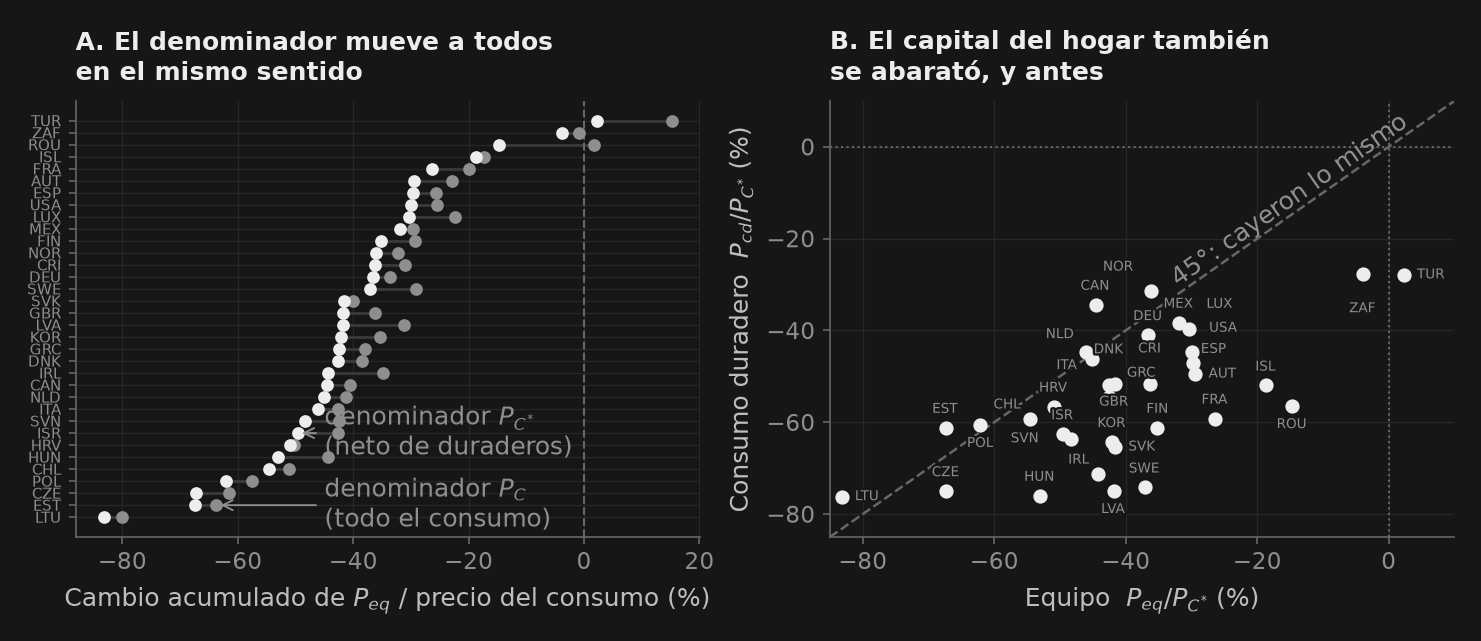

In [27]:
from matplotlib.patheffects import withStroke
from matplotlib.transforms import Bbox


def anotar_codigos(ax, xs, ys, codigos, *, fontsize=6.5, paso=3.5):
    """Cada código, junto a su punto, en la menos estorbosa de las dieciséis
    posiciones que rodean al marcador: con el mismo desplazamiento para todos
    se pisan entre sí en cuanto la nube se aprieta. Las nubes de §2.4, §4.3
    y §5.1 vuelven a llamarla."""
    fig = ax.figure
    fig.canvas.draw()                    # posiciones y transformaciones, ya finales
    ren = fig.canvas.get_renderer()
    marco = ax.patch.get_window_extent()
    pts = [ax.transData.transform((float(u), float(v))) for u, v in zip(xs, ys)]
    # Ocupan sitio los propios marcadores y los rótulos ya escritos; pisar
    # texto cuesta el triple que pisar un punto, y salirse del eje, mucho más.
    ocupado = [Bbox.from_bounds(px - 6, py - 6, 12, 12) for px, py in pts]
    ocupado += [t.get_window_extent(ren) for t in ax.texts]
    n_pts = len(pts)
    vueltas = [(f, dx * f, dy * f, ha, va) for f in (1.0, 2.4)
               for dx, dy, ha, va in ((paso, paso, "left", "bottom"),
                                      (-paso, paso, "right", "bottom"),
                                      (paso, -paso, "left", "top"),
                                      (-paso, -paso, "right", "top"),
                                      (0, 1.6 * paso, "center", "bottom"),
                                      (0, -1.6 * paso, "center", "top"),
                                      (1.8 * paso, 0, "left", "center"),
                                      (-1.8 * paso, 0, "right", "center"))]
    puestos = []
    for (u, v), etq in zip(zip(xs, ys), codigos):
        mejor = caja = puntaje = None
        for f, dx, dy, ha, va in vueltas:
            t = ax.annotate(str(etq), xy=(float(u), float(v)), xytext=(dx, dy),
                            textcoords="offset points", ha=ha, va=va,
                            fontsize=fontsize, color=_nbstyle.NOTA,
                            path_effects=[withStroke(linewidth=2.2,
                                                     foreground=_nbstyle.FONDO)])
            bb = t.get_window_extent(ren).expanded(1.35, 1.6)
            dentro = (marco.containsx(bb.x0) and marco.containsx(bb.x1)
                      and marco.containsy(bb.y0) and marco.containsy(bb.y1))
            p = (0.0 if dentro else 2000.0) + 30.0 * (f - 1.0)
            for j, caja_j in enumerate(ocupado):
                corte = Bbox.intersection(bb, caja_j)
                if corte is not None:
                    p += (1.0 if j < n_pts else 3.0) * corte.width * corte.height
            if puntaje is None or p < puntaje:
                if mejor is not None:
                    mejor.remove()
                mejor, caja, puntaje = t, bb, p
            else:
                t.remove()
            if puntaje == 0.0:
                break
        ocupado.append(caja)
        puestos.append(mejor)
    return puestos


fig, (axL, axR) = _nbstyle.figura(1, 2)

d = eq.sort_values("P_eq/P_C*")
y = np.arange(len(d))
axL.hlines(y, d["P_eq/P_C"], d["P_eq/P_C*"], color=_nbstyle.gris("0.75"), lw=1.4, zorder=1)
axL.scatter(d["P_eq/P_C"], y, s=26, color=_nbstyle.NOTA, zorder=3)
axL.scatter(d["P_eq/P_C*"], y, s=26, color=_nbstyle.TINTA, zorder=3)
axL.axvline(0, color=_nbstyle.SPINE, ls="--", lw=1.0)
axL.set_yticks(y); axL.set_yticklabels(d.index, fontsize=7)
axL.set_xlabel("Cambio acumulado de $P_{eq}$ / precio del consumo (%)")
axL.set_title("A. El denominador mueve a todos\n"
              "en el mismo sentido")
# Los dos marcadores se nombran en dos filas del fondo, donde queda sitio a la
# derecha: el texto arranca a media escala y la guía vuelve a su marcador.
for fila, col_, texto in ((1, "P_eq/P_C", "denominador $P_C$\n(todo el consumo)"),
                          (7, "P_eq/P_C*", "denominador $P_{C^{*}}$\n(neto de duraderos)")):
    axL.annotate(texto, xy=(float(d[col_].iloc[fila]), fila), xytext=(-45.0, fila),
                 textcoords="data", ha="left", va="center", color=_nbstyle.NOTA,
                 arrowprops=_nbstyle.FLECHA)

axR.scatter(b["P_eq/P_C*"], b["P_cd/P_C*"], s=34, color=_nbstyle.TINTA, zorder=3)
lim = [min(b.min().min(), -85), 10]
axR.plot(lim, lim, color=_nbstyle.SPINE, ls="--", lw=1.2)
axR.axhline(0, color=_nbstyle.SPINE, ls=":", lw=1.0); axR.axvline(0, color=_nbstyle.SPINE, ls=":", lw=1.0)
axR.set_xlim(lim); axR.set_ylim(lim)
axR.annotate("45°: cayeron lo mismo", xy=(-14, -14), rotation=45, transform_rotates_text=True,
             rotation_mode="anchor", ha="center", va="bottom", color=_nbstyle.NOTA)
axR.set_xlabel("Equipo  $P_{eq}/P_{C^{*}}$ (%)")
axR.set_ylabel("Consumo duradero  $P_{cd}/P_{C^{*}}$ (%)")
axR.set_title("B. El capital del hogar también\n"
              "se abarató, y antes")
# Los códigos, al final: el panel ya tiene su tamaño definitivo cuando se
# busca sitio para cada uno.
anotar_codigos(axR, b["P_eq/P_C*"], b["P_cd/P_C*"], b.index)

plt.show()


**Interpretación de los paneles.** El panel A es un resultado de medición: la dirección no es un hallazgo empírico sino aritmética —los duraderos están dentro de $P_C$ y su precio cae, así que sacarlos solo puede agrandar la caída del numerador— y lo que aportan los datos es el *tamaño*: una mediana de 4,6 pp por país, hasta 16 pp en Rumanía, que mueve la mediana del panel de $-35\%$ a $-42\%$. Ni es un error de redondeo ni es el titular; el resumen honesto es que el hecho de GHK es robusto a la elección de denominador y está algo subestimado por el habitual.

El panel B es un resultado económico. Nada implica u obliga a que el precio de las lavadoras siga al de las máquinas herramienta: son bienes distintos, vendidos en mercados distintos a compradores distintos. Lo siguen igualmente — y los bienes que los hogares compran como capital se abarataron *más deprisa* que los que compran las empresas en la mayor parte del panel. El cambio técnico específico a la inversión, dicho de otro modo, no es un hecho del sector empresarial: alcanza al stock de capital del propio hogar, que es exactamente la lectura bajo la cual la reclasificación de §2.4 deja de ser una convención contable y pasa a ser una afirmación sobre la tecnología. La única cautela es de composición: `cons_dur` es un cubo COICOP cuyo contenido (coches, muebles, electrónica) difiere entre países y se desplaza dentro de cada uno, así que el *orden* entre países del panel B es más blando que el signo común.


### 2.3 Una advertencia antes de seguir: contaminación por tipo de cambio

Los objetos que acabamos de construir reaccionan de forma muy distinta al tipo de cambio nominal $E$ (moneda nacional por dólar). Conviene separarlos *antes* de usar cualquiera de ellos como evidencia.

**Las participaciones de §2.1 son inmunes.** Dividen un agregado a precios corrientes entre otro *en la misma moneda nacional*, así que nunca hay conversión: el $C/Y$ de México es el mismo número con el peso a 10 o a 20 por dólar. Esa inmunidad es la razón principal para guardar el panel en moneda local nominal en lugar de convertirlo primero a una moneda común: en un panel en moneda común, la serie de cada país se movería con su propio tipo bilateral.

**Los precios relativos de §2.2 no lo son.** Un deflactor de importaciones en moneda local es, en primera aproximación, un precio mundial por el tipo de cambio, $P_M \approx E \cdot P_M^{*}$. Tres consecuencias, y medimos las tres:
1. **Traspaso (*pass-through*).** $\Delta \log P_M$ se mueve con $\Delta \log E$, mecánicamente, sin que se esté midiendo nada económico.
2. **Los términos de intercambio sobreviven en buena medida.** $P_X/P_M \approx (E P_X^{*}) / (E P_M^{*}) = P_X^{*}/P_M^{*}$: un $E$ común se cancela en el cociente. La correlación que queda no es contaminación sino causalidad en sentido contrario: en un exportador de cobre o petróleo, un auge de materias primas mejora los términos de intercambio *y* aprecia la moneda.
3. **El precio relativo de la inversión no sobrevive — y el desglose por activo de §2.2 convierte esa afirmación en una prueba.** Si el canal es el contenido importado, el tipo de cambio debe cargar sobre el **equipo** (manufacturado, importado) y *no* sobre la **construcción** (vertida en el sitio): mismo país, mismo trimestre, mismo deflactor de consumo en el denominador. Eso es un placebo, y o funciona o no funciona.

**Vínculo macroeconómico: Colapsos de términos de intercambio y paradas repentinas (*Sudden Stops*).**  
En las economías abiertas emergentes, los movimientos en los precios relativos y en el tipo de cambio no son mero ruido estadístico: constituyen el núcleo de las crisis macroeconómicas. Cuando una economía emergente sufre un choque adverso en sus términos de intercambio o un congelamiento del crédito internacional (*Sudden Stop*, Calvo 1998; Mendoza 2010), el tipo de cambio nominal se deprecia violentamente. Como los bienes de capital son mayoritariamente importados ($P_I \approx E \cdot P_I^*$), esta depreciación dispara el precio relativo de la inversión respecto al consumo ($P_I/P_C$). Las empresas domésticas sufren un colapso en su capacidad de endeudamiento justo cuando el costo de reposición del capital se dispara. Combinado con pasivos denominados en moneda extranjera («pecado original»), este canal de balance fuerza una contracción dramática de la absorción y de la inversión que desborda con creces lo predicho por los modelos de ciclo económico cerrado.

**Y ojo con la extrapolación.** Estos son comovimientos trimestrales. El coeficiente de corto plazo no se integra hasta una descomposición de niveles: aplicado a la depreciación acumulada de Turquía ($+652$ puntos log) "explicaría" $+100$ pp de un precio relativo que en realidad se movió $+15$ pp. Los tipos de cambio reales revierten a la media; los coeficientes de traspaso nominal no.


In [28]:
from puremacro.fetch import fetch_xrate_monthly

fx = fetch_xrate_monthly(PAISES, start_period="1995") if VIVO else pd.DataFrame()
if fx.empty and readable(DATA / "oecd_fx_lcu_usd_q.csv", "file"):
    print("Tipos de cambio: foto congelada del curso."
          if not VIVO else
          "Sin tipos de cambio en vivo — usamos la foto congelada del curso.")
    e_q = (pd.read_csv(DATA / "oecd_fx_lcu_usd_q.csv", parse_dates=["date"])
             .set_index(["code", "date"])["e"])
else:
    fx["date"] = pd.to_datetime(fx["date"]).dt.to_period("Q").dt.to_timestamp(how="start")
    e_q = fx.groupby(["code", "date"])["value"].mean().rename("e")

# ¿Qué países comparten moneda (o se anclan a una)? En vez de mantener a mano
# una lista de la zona euro —cuya membresía cambió siete veces en esta muestra—
# la leemos de los datos: un país cuyo tipo frente al dólar se mueve uno a uno
# con el de Alemania no está flotando por cuenta propia. Esto captura la zona
# euro *y* el ancla de la corona danesa, y deja correctamente del lado flotante
# a los que entraron tarde (Eslovaquia, los bálticos) en una muestra en la que
# tuvieron moneda propia casi todo el tiempo.
_eur = np.log(e_q.loc["DEU"]).diff()


def se_mueve_con_el_euro(code, umbral=0.95):
    d = pd.concat([np.log(e_q.loc[code]).diff().rename("x"),
                   _eur.rename("r")], axis=1, join="inner", sort=True).dropna()
    return len(d) >= 40 and d["x"].corr(d["r"]) > umbral


def corr_con_fx(d, num, den="pc"):
    """corr(D log(num/den), D log E) sobre la muestra común sin faltantes."""
    sub = d[["e", num, den]].dropna()
    return (sub[num] - sub[den]).corr(sub["e"]) if len(sub) >= 40 else np.nan


from puremacro.regress import ols, add_constant


filas, anclados_duro = [], []
for c in sorted(set(e_q.index.get_level_values("code"))
                & set(panel.index.get_level_values("code"))):
    g = panel.loc[c]
    d = pd.DataFrame({
        "e":  np.log(e_q.loc[c]),
        "pm": np.log(g["imports_defl"]),
        "px": np.log(g["exports_defl"]),
        "pc": np.log(g["cons_hh_defl"]),
        "pi": np.log(g["inv_defl"]),
        "pe": np.log(g["inv_equip_defl"]),
        "ps": np.log(g["inv_struct_defl"]),
    }).diff()
    base = d[["e", "pm"]].dropna()
    if len(base) < 40:
        continue
    if 100 * base["e"].std() < 0.5:
        # Un ancla dura (Arabia Saudí) no tiene variación cambiaria sobre la
        # cual regresar: la correlación es ruido y la pendiente divide por ~0.
        anclados_duro.append(c)
        continue
    filas.append({
        "code": c, "n": len(base), "sd(dE)%": 100 * base["e"].std(),
        "corr(dPm,dE)":     base["pm"].corr(base["e"]),
        "beta(dPm,dE)":     float(ols(base["pm"], add_constant(base["e"]), cov_type="HC1").params.iloc[1]),
        "corr(dTI,dE)":     corr_con_fx(d, "px", "pm"),
        "corr(dPi/Pc,dE)":  corr_con_fx(d, "pi"),
        "corr(dPeq/Pc,dE)": corr_con_fx(d, "pe"),
        "corr(dPst/Pc,dE)": corr_con_fx(d, "ps"),
        "euro": se_mueve_con_el_euro(c),
    })
fxc = pd.DataFrame(filas).set_index("code").sort_values("corr(dPeq/Pc,dE)", ascending=False)
print("Cambios logarítmicos trimestrales frente al tipo de cambio nominal (moneda local por USD):")
print(fxc.drop(columns="euro").round(2).to_string())
if anclados_duro:
    print(f"\nExcluidos por no tener tipo de cambio del que hablar (ancla dura al "
          f"dólar): {', '.join(anclados_duro)}")

placebo = fxc.dropna(subset=["corr(dPeq/Pc,dE)", "corr(dPst/Pc,dE)"])
propia = fxc[~fxc["euro"]]
print(f"\nTraspaso a P_M, correlación mediana con dE — moneda propia: "
      f"{propia['corr(dPm,dE)'].median():+.2f} ({len(propia)} países) | euro o "
      f"anclados a él: {fxc[fxc['euro']]['corr(dPm,dE)'].median():+.2f} "
      f"({int(fxc['euro'].sum())}). La segunda cifra es baja porque el tipo frente "
      f"al dólar no es aquel en que se factura la mayor parte de su comercio.")
print(f"Términos de intercambio: {fxc['corr(dTI,dE)'].median():+.2f} (mediana sobre "
      f"{len(fxc)}) — el tipo de cambio se cancela en el cociente.")
print(f"Placebo ({len(placebo)} países) — equipo: "
      f"{placebo['corr(dPeq/Pc,dE)'].median():+.2f} | construcción: "
      f"{placebo['corr(dPst/Pc,dE)'].median():+.2f} | FBCF total: "
      f"{placebo['corr(dPi/Pc,dE)'].median():+.2f}")
print(f"El equipo carga más que la construcción en "
      f"{(placebo['corr(dPeq/Pc,dE)'] > placebo['corr(dPst/Pc,dE)']).sum()} de {len(placebo)} países.")

# 1. El tipo de cambio se traspasa a los precios de importación allí donde es la
#    moneda propia del país la que se mueve.
assert propia["corr(dPm,dE)"].median() > 0.4
# 2. Se cancela en buena medida en los términos de intercambio, cociente de dos
#    deflactores en moneda local.
assert abs(fxc["corr(dTI,dE)"].median()) < 0.25
# 3. El placebo se sostiene: carga sobre el bien de capital transable, no sobre el otro.
assert placebo["corr(dPeq/Pc,dE)"].median() > placebo["corr(dPst/Pc,dE)"].median() + 0.15
assert (placebo["corr(dPeq/Pc,dE)"] > placebo["corr(dPst/Pc,dE)"]).mean() > 0.8

Tipos de cambio: foto congelada del curso.
Cambios logarítmicos trimestrales frente al tipo de cambio nominal (moneda local por USD):
        n  sd(dE)%  corr(dPm,dE)  beta(dPm,dE)  corr(dTI,dE)  corr(dPi/Pc,dE)  corr(dPeq/Pc,dE)  corr(dPst/Pc,dE)
code                                                                                                             
CAN   124     3.13          0.76          0.46         -0.58             0.46              0.86             -0.16
CHL   121     4.67          0.76          0.73         -0.42             0.55              0.78             -0.13
MEX   124     4.64          0.83          0.66         -0.67             0.54              0.77             -0.08
KOR   124     5.54          0.73          0.74         -0.07             0.46              0.67               NaN
AUS   124     4.77          0.81          0.46         -0.12             0.32              0.62              0.01
CRI   125     2.42          0.51          0.85          0.00        


Regresión de traspaso cambiario OLS (HC1) para MEX:
OLS regression (HC1, z inference)
  n = 124, df_resid = 122, R^2 = 0.6910, adj R^2 = 0.6884
  llf = 306.1123, AIC = -608.2246, BIC = -602.5841
                coef     std err        z    P>|t|      [0.025      0.975]
const         0.0076      0.0019    4.011    0.000      0.0039      0.0114
e             0.6628      0.0358   18.516    0.000      0.5927      0.7330

Regresión de traspaso cambiario OLS (HC1) para DEU:
OLS regression (HC1, z inference)
  n = 124, df_resid = 122, R^2 = 0.0641, adj R^2 = 0.0564
  llf = 349.8211, AIC = -695.6421, BIC = -690.0015
                coef     std err        z    P>|t|      [0.025      0.975]
const         0.0023      0.0013    1.764    0.078     -0.0003      0.0048
e             0.0982      0.0437    2.250    0.024      0.0126      0.1838


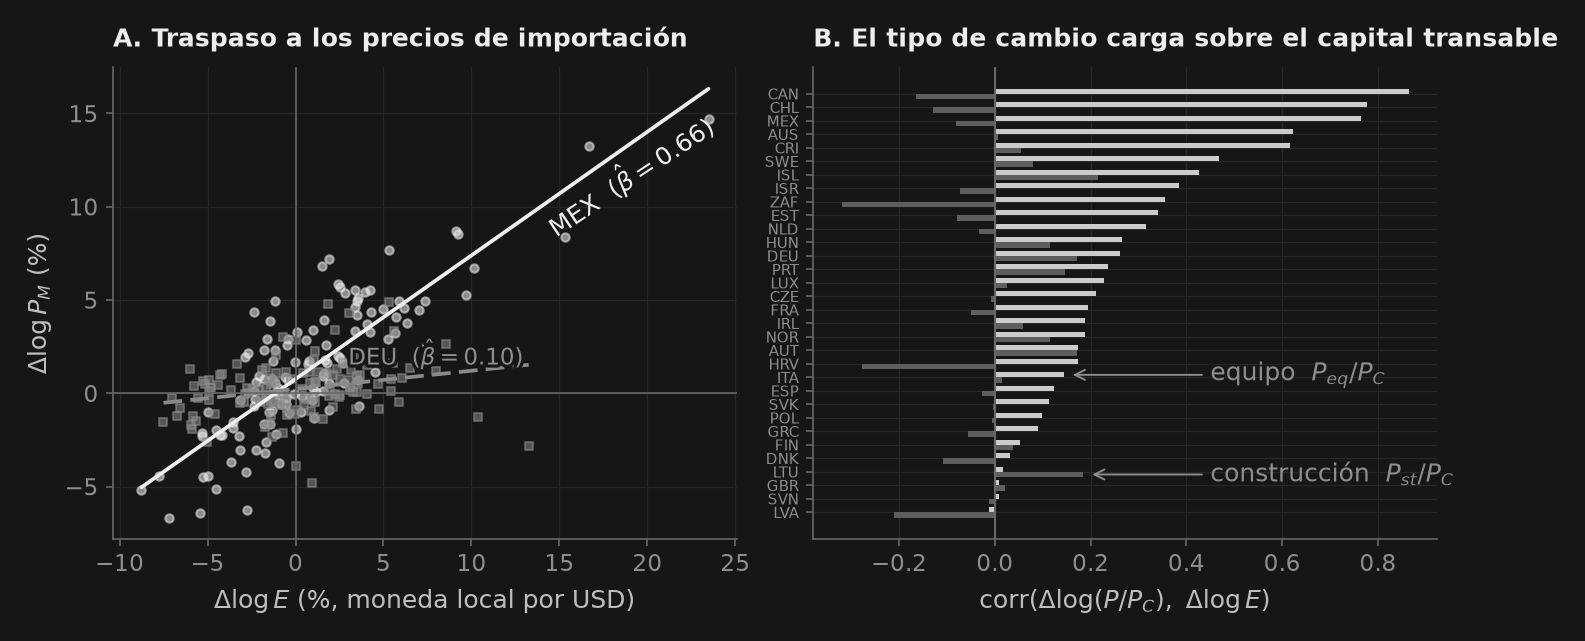

In [29]:
fig, (ax1, ax2) = _nbstyle.figura(1, 2)

# Panel A: traspaso a los precios de importación, un flotador vs un socio del euro
rectas, pendientes = [], {}
for k, c in enumerate(("MEX", "DEU")):
    g = panel.loc[c]
    d = pd.DataFrame({"e": np.log(e_q.loc[c]),
                      "pm": np.log(g["imports_defl"])}).dropna().diff().dropna()
    res_fx = ols(d["pm"], add_constant(d["e"]), cov_type="HC1")
    print(f"\nRegresión de traspaso cambiario OLS (HC1) para {c}:")
    print(res_fx.summary())
    a, b = float(res_fx.params.iloc[0]), float(res_fx.params.iloc[1])
    ax1.scatter(100 * d["e"], 100 * d["pm"], s=16, alpha=0.55, color=cols[k * 3],
                marker=("o", "s")[k])
    gx = np.linspace(100 * d["e"].min(), 100 * d["e"].max(), 50)
    rectas += ax1.plot(gx, 100 * a + b * gx, color=cols[k * 3], lw=1.8, ls=lss[k],
                       label=f"{c}  ($\\hat\\beta = {b:.2f}$)")
    pendientes[c] = b
ax1.axhline(0, color=_nbstyle.SPINE, lw=0.8); ax1.axvline(0, color=_nbstyle.SPINE, lw=0.8)
ax1.set_xlabel("$\\Delta \\log E$ (%, moneda local por USD)")
ax1.set_ylabel("$\\Delta \\log P_M$ (%)")
ax1.set_title("A. Traspaso a los precios de importación")

# Panel B: el placebo — bien de capital transable vs no transable
orden = placebo.sort_values("corr(dPeq/Pc,dE)")
y = np.arange(len(orden))
h = 0.38
EQ, ST = "corr(dPeq/Pc,dE)", "corr(dPst/Pc,dE)"
ax2.barh(y + h / 2, orden[EQ], height=h, color=_nbstyle.BARRA_COLORES[0])
ax2.barh(y - h / 2, orden[ST], height=h, color=_nbstyle.BARRA_COLORES[2])
ax2.set_yticks(y)
ax2.set_yticklabels(orden.index, fontsize=7)
ax2.axvline(0, color=_nbstyle.SPINE, lw=1.0)
ax2.set_xlabel("$\\mathrm{corr}(\\Delta \\log (P/P_C),\\ \\Delta \\log E)$")
ax2.set_title("B. El tipo de cambio carga sobre el capital transable")
# Cada barra se nombra con una guía desde una fila baja, donde a la derecha
# no hay barras largas: la construcción más larga y el equipo más largo que
# aún deja sitio.
f_st = orden.index.get_loc(orden[ST].where(orden[EQ] < 0.3).idxmax())
f_eq = orden.index.get_loc(orden[EQ].where(orden[EQ] < 0.15).idxmax())
x_txt = 0.45
ax2.annotate("equipo  $P_{eq}/P_C$", xy=(float(orden[EQ].iloc[f_eq]) + 0.01, f_eq + h / 2),
             xytext=(x_txt, f_eq + h / 2), textcoords="data", ha="left", va="center",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax2.annotate("construcción  $P_{st}/P_C$", xy=(float(orden[ST].iloc[f_st]) + 0.01, f_st - h / 2),
             xytext=(x_txt, f_st - h / 2), textcoords="data", ha="left", va="center",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)

# La recta de MEX lleva su nombre debajo y girado como ella, en el tramo donde
# la nube ya se acabó: al final de la recta el rótulo se salía del eje y
# quedaba flotando entre los dos paneles. La de DEU, casi plana, lo lleva
# encima de su tramo medio.
x_mex = 18.5
ax1.annotate(rectas[0].get_label(),
             xy=(x_mex, float(np.interp(x_mex, rectas[0].get_xdata(), rectas[0].get_ydata()))),
             xytext=(0, -5), textcoords="offset points",
             rotation=np.degrees(np.arctan(pendientes["MEX"])), transform_rotates_text=True,
             rotation_mode="anchor", ha="center", va="top", color=cols[0])
_nbstyle.etiquetar(ax1, artistas=rectas[1:], donde=8.0)
plt.show()


### 2.4 Bienes de Consumo Duradero: ¿Consumo o Inversión?

En el Sistema de Cuentas Nacionales, la compra de un coche, un sofá o una lavadora se anota íntegra como **consumo ($C$)** en el trimestre en que ocurre.

La teoría neoclásica (Cooley y Prescott 1995; Gomme y Rupert 2007) dice que ese no es su lugar. Un bien duradero es un **bien de capital del hogar ($K_d$)** que se compra una vez y se consume durante años: la compra es discreta, aplazable, financiada con crédito y prospectiva — una decisión de inversión con etiqueta de consumo. Por eso el trabajo de ciclos económicos suele recortar las cuentas como
$$ C^{*} = C - C_d \quad(\text{no duraderos} + \text{servicios}), \qquad I^{*} = I_{\text{fija}} + C_d .$$

La §2.2 ya puso una prueba sobre la mesa, por el lado de los precios: $P_{cd}/P_{C^{*}}$ cayó en los 37 países y más que el equipo empresarial en 28 de 34, así que los duraderos no son solo *análogos* al capital: se abaratan como se abaratan los bienes de capital. Lo que sigue es el lado de las cantidades de la misma afirmación — y es el que mueve los hechos estilizados.

El mismo panel responde a esto, porque `qna_panel(..., durability=True)` trae el consumo de los hogares desglosado por durabilidad del flujo `DF_QNA_EXPENDITURE_DURABILITY` de la OCDE — duradero, semiduradero, no duradero y servicios, cada uno con su deflactor. La §2.2 ya usó tres de esas cuatro líneas, para construir el $C^{*}$ del denominador de sus precios relativos.

Cuatro cosas que conviene tener claras, todas visibles en el código de abajo:
- El desglose se publica para el sector institucional **`S14`** (hogares) mientras que el `cons_hh` de cabecera es **`S1M`** (hogares + ISFLSH), así que los componentes suman entre 95% y 106% de él. Por eso construimos el total de consumo *a partir de los componentes*, para que numerador y denominador compartan sector.
- **Estados Unidos y Chile no publican categoría de semiduraderos** (su clasificación tiene tres cubetas, no cuatro); el código suma lo que exista.
- Algunos países publican el desglose **sin desestacionalizar** aunque sus agregados sí lo estén. En vez de fiarnos de una bandera por país, contrastamos cada serie (`residual_seasonality_F`) y solo aplicamos STL a las que fallan: una serie sin desestacionalizar inflaría todas las volatilidades de abajo.
- **Contra qué se compara.** La pregunta es si el duradero del hogar se mueve como un bien de capital, y el bien de capital con el que hay que compararlo es el **equipo** — maquinaria, transporte y TIC —, no la FBCF total. La FBCF total es en torno a la mitad viviendas y obra civil: activos que se construyen sobre el terreno, tardan trimestres en levantarse y se ajustan despacio, de modo que el agregado promedia el comparador correcto con uno que no lo es y sale artificialmente suave. Es exactamente el desglose por activo que §2.2 usó por el lado de los precios (`inv_equip` frente a `inv_struct`), ahora por el lado de las cantidades, y hace la comparación entre dos objetos del mismo tamaño y la misma naturaleza. El precio se paga en cobertura: no todas las economías que publican durabilidad publican la FBCF por activo, y el panel B nombra a las que faltan.

In [30]:
from puremacro.sa import deseasonalize_x13, residual_seasonality_F

DURABILIDAD = ["cons_dur", "cons_semidur", "cons_nondur", "cons_serv"]
MUESTRA_T = ("1995", "2019-10-01")   # pre-COVID: 2020 solo dominaría todo momento HP


def real(g, col):
    """Volumen implícito en el panel: 100 x precios corrientes / deflactor."""
    if col not in g or g[col].isna().all():
        return None
    s = (100.0 * g[col] / g[col + "_defl"]).dropna()
    return s if len(s) else None


def desestacionalizar_si_hace_falta(s):
    """Ajusta solo una serie que aún falla un contraste F de estacionalidad.

    `qna_panel(sa="x13")` ya ajustó lo que la OCDE publica en bruto; esto es la
    comprobación de cinturón y tirantes sobre el resultado, y sobre cualquier
    cosa que la fuente haya dejado estacional. Misma escalera de motores:
    binario X-13 y, si no, X-11 en Python puro.
    """
    if s is None or len(s) < 24:
        return s, False
    _, pval, _, _ = residual_seasonality_F(np.log(s), freq="Q")
    if pval >= 0.01:
        return s, False
    d = pd.DataFrame({"date": s.index, "v": np.log(s.values), "grp": "x"})
    adj = deseasonalize_x13(d, "v", by="grp", date_col="date", freq="Q")
    return pd.Series(np.exp(adj.values), index=s.index, name=s.name), True


filas = []
for c in sorted(panel.index.get_level_values("code").unique()):
    g = panel.loc[c].loc[MUESTRA_T[0]:MUESTRA_T[1]]
    comps, stl = {}, False
    for k in DURABILIDAD:
        s, hecho = desestacionalizar_si_hace_falta(real(g, k))
        if s is not None:
            comps[k], stl = s, stl or hecho
    # Bulgaria y Portugal publican la línea de duraderos y nada más, así que
    # C* = C - C_d sería idénticamente cero para ellos.
    if "cons_dur" not in comps or len(comps) < 2:
        continue
    # Los volúmenes encadenados no son exactamente aditivos; el residuo aquí
    # está muy por debajo del 1% y no mueve los segundos momentos.
    C = pd.concat([v.rename(k) for k, v in comps.items()], axis=1, sort=True).dropna()
    # El equipo empresarial entra con el mismo trato que las cuatro líneas de
    # durabilidad —contraste F y, si falla, X-13—, porque es el activo con el
    # que se compara el duradero del hogar y no puede llegar sobre otra base.
    i_eq, hecho_eq = desestacionalizar_si_hace_falta(real(g, "inv_equip"))
    stl = stl or hecho_eq
    df = pd.concat([real(g, "gdp").rename("y"), real(g, "inv").rename("i"),
                    C.sum(axis=1).rename("c_tot"), C["cons_dur"].rename("c_dur")],
                   axis=1, sort=True).dropna()
    if len(df) < 48:
        continue
    df["c_nd"] = df["c_tot"] - df["c_dur"]      # C* = C - C_d
    df["i_adj"] = df["i"] + df["c_dur"]         # I* = I_fija + C_d
    cyc = {k: hp_filter(100.0 * np.log(df[k]))[0]
           for k in ("y", "i", "c_tot", "c_dur", "c_nd", "i_adj")}
    sy = np.std(cyc["y"], ddof=1)
    nom = g[list(comps)].dropna()
    fila = {
        "code": c, "desde": df.index.min().year, "n": len(df), "STL": stl,
        "sig_c/sig_y":  np.std(cyc["c_tot"], ddof=1) / sy,
        "sig_c*/sig_y": np.std(cyc["c_nd"], ddof=1) / sy,
        "sig_cd/sig_y": np.std(cyc["c_dur"], ddof=1) / sy,
        "sig_i/sig_y":  np.std(cyc["i"], ddof=1) / sy,
        "sig_i*/sig_y": np.std(cyc["i_adj"], ddof=1) / sy,
        "C_d/C (%)": float((g["cons_dur"] / nom.sum(axis=1)).mean() * 100),
    }
    # El equipo tiene su propia muestra: no todo el que publica durabilidad
    # publica la FBCF por activo, y donde la publica puede empezar en otro
    # trimestre. Su cociente se calcula sobre los trimestres en que existen
    # equipo Y producto, no sobre los del bloque de durabilidad, para que el
    # denominador sea el del mismo periodo que el numerador.
    if i_eq is not None:
        eq = pd.concat([df["y"], i_eq.rename("i_eq")], axis=1, sort=True).dropna()
        if len(eq) >= 48:
            c_eq, _ = hp_filter(100.0 * np.log(eq["i_eq"]))
            c_ye, _ = hp_filter(100.0 * np.log(eq["y"]))
            fila["sig_ieq/sig_y"] = (np.std(c_eq, ddof=1)
                                     / np.std(c_ye, ddof=1))
            fila["n_eq"] = len(eq)
    filas.append(fila)
dur = pd.DataFrame(filas).set_index("code").sort_values("sig_c/sig_y", ascending=False)
print(f"Duraderos como consumo vs. como inversión, filtro HP, {MUESTRA_T[0]}-2019, "
      f"{len(dur)} países:")
print(dur.round(2).to_string())

med = dur[["sig_c/sig_y", "sig_c*/sig_y", "sig_cd/sig_y", "sig_i/sig_y",
           "sig_i*/sig_y", "sig_ieq/sig_y"]].median()
print(f"\nMedianas — el consumo pasa de {med['sig_c/sig_y']:.2f} a {med['sig_c*/sig_y']:.2f} "
      f"al sacarle los duraderos; los duraderos mismos van en {med['sig_cd/sig_y']:.2f}, "
      f"tan volátiles como la inversión fija ({med['sig_i/sig_y']:.2f}).")
# La FBCF total no es el comparador adecuado y su mediana lo enseña: la mitad
# de ella son viviendas y construcción, que se mueven despacio, así que el
# agregado promedia el activo comparable con otro que no lo es. El equipo
# —maquinaria, transporte y TIC, el mismo activo transable de §2.2— es el
# comparador del duradero del hogar, y va casi 60% por encima de la FBCF.
eq = dur.dropna(subset=["sig_ieq/sig_y"])
print(f"El comparador que importa no es la FBCF sino el EQUIPO, el activo del "
      f"que el duradero del hogar es\nel análogo: mediana "
      f"{eq['sig_ieq/sig_y'].median():.2f} frente a "
      f"{eq['sig_i/sig_y'].median():.2f} de la FBCF total, en las {len(eq)} "
      f"economías que publican\nel desglose por activo "
      f"(faltan {', '.join(sorted(set(dur.index) - set(eq.index)))}). En esa "
      f"escala el duradero queda en {eq['sig_cd/sig_y'].median():.2f}: "
      f"{eq['sig_cd/sig_y'].median() / eq['sig_ieq/sig_y'].median():.2f} veces "
      f"el equipo\ny {eq['sig_cd/sig_y'].median() / eq['sig_c*/sig_y'].median():.1f} "
      f"veces el consumo del que se le saca. Está mucho más cerca del capital "
      f"que del consumo,\ny por debajo del equipo en "
      f"{int((eq['sig_cd/sig_y'] < eq['sig_ieq/sig_y']).sum())} de {len(eq)} "
      f"países.")
cruzan = dur[(dur["sig_c/sig_y"] > 1.0) & (dur["sig_c*/sig_y"] < 1.0)]
print(f"Países cuyo σ(c)/σ(y) cruza por debajo de 1.0 al reclasificar: "
      f"{', '.join(cruzan.index) if len(cruzan) else 'ninguno'}")
suben = dur[dur["sig_c*/sig_y"] > dur["sig_c/sig_y"]]
print(f"Países donde va al revés: {', '.join(suben.index)} (ver ejercicio 15).")

# Los duraderos se mueven como capital, no como consumo...
assert (dur["sig_cd/sig_y"] > 1.5).mean() > 0.9
# ...así que sacarlos de C reduce la volatilidad medida del consumo casi en todas partes.
assert (dur["sig_c*/sig_y"] < dur["sig_c/sig_y"]).mean() > 0.85
assert med["sig_cd/sig_y"] > med["sig_i/sig_y"] * 0.8
# El equipo es el activo volátil que la FBCF total diluye, y el duradero se
# queda por debajo de él: la analogía con el capital es de orden de magnitud,
# no de identidad.
assert med["sig_ieq/sig_y"] > med["sig_i/sig_y"]
assert len(eq) >= 25

Duraderos como consumo vs. como inversión, filtro HP, 1995-2019, 35 países:
      desde    n    STL  sig_c/sig_y  sig_c*/sig_y  sig_cd/sig_y  sig_i/sig_y  sig_i*/sig_y  C_d/C (%)  sig_ieq/sig_y   n_eq
code                                                                                                                        
HRV    1995  100  False         1.81          1.85          2.44         3.47          3.15       6.36           6.46  100.0
ROU    1995  100  False         1.55          1.56          1.91         3.94          3.65       5.64           3.95  100.0
KOR    1995  100   True         1.28          1.16          4.63         2.48          2.54       9.70           5.43  100.0
CHL    1996   96  False         1.20          0.95          5.55         3.30          3.43       8.69           6.05   96.0
NZL    1995  100  False         1.15          1.09          2.53         4.85          4.00      17.20            NaN    NaN
ESP    1995  100  False         1.15          1.0

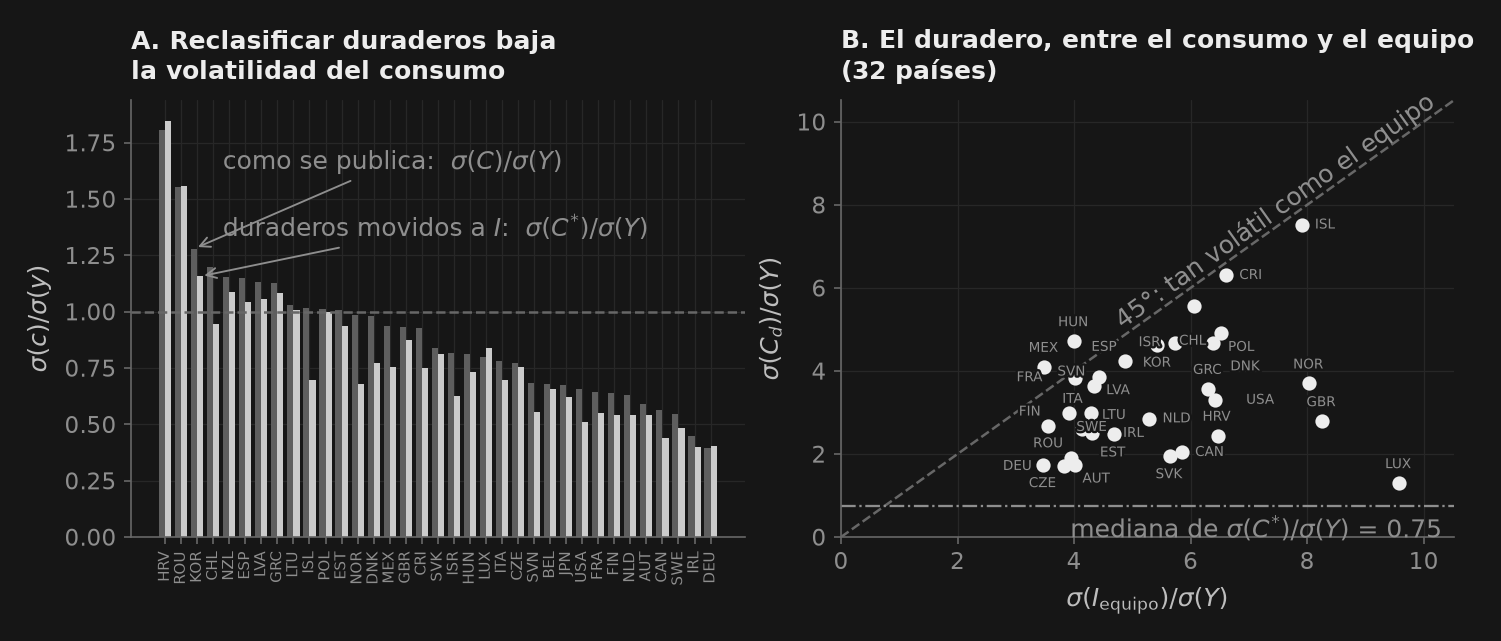

In [31]:
fig, (ax1, ax2) = _nbstyle.figura(1, 2)

x = np.arange(len(dur))
w = 0.38
ax1.bar(x - w / 2, dur["sig_c/sig_y"], w, color=_nbstyle.BARRA_COLORES[2])
ax1.bar(x + w / 2, dur["sig_c*/sig_y"], w, color=_nbstyle.BARRA_COLORES[0])
ax1.axhline(1.0, color=_nbstyle.SPINE, ls="--", lw=1.2)
ax1.set_xticks(x); ax1.set_xticklabels(dur.index, rotation=90, fontsize=7)
ax1.set_ylabel("$\\sigma(c)/\\sigma(y)$")
ax1.set_title("A. Reclasificar duraderos baja\n"
              "la volatilidad del consumo")
# Las dos barras se nombran sobre el tercer país; a la derecha las barras son
# más bajas y los nombres caben encima.
i0, tope = 2, float(dur["sig_c/sig_y"].max())
ax1.annotate("como se publica:  $\\sigma(C)/\\sigma(Y)$",
             xy=(i0 - w / 2, float(dur["sig_c/sig_y"].iloc[i0])),
             xytext=(i0 + 1.6, 0.92 * tope), textcoords="data", ha="left", va="center",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax1.annotate("duraderos movidos a $I$:  $\\sigma(C^{*})/\\sigma(Y)$",
             xy=(i0 + w / 2, float(dur["sig_c*/sig_y"].iloc[i0])),
             xytext=(i0 + 1.6, 0.76 * tope), textcoords="data", ha="left", va="center",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)

# El eje horizontal es el EQUIPO, no la FBCF total: comparar el bien de capital
# del hogar contra un agregado que es mitad vivienda y obra civil mide sobre
# todo la composición del denominador. `eq` es la submuestra con desglose por
# activo, que la celda anterior nombró.
ax2.scatter(eq["sig_ieq/sig_y"], eq["sig_cd/sig_y"], s=34, color=_nbstyle.TINTA, zorder=3)
lim = [0, max(eq["sig_ieq/sig_y"].max(), eq["sig_cd/sig_y"].max()) * 1.1]
ax2.plot(lim, lim, color=_nbstyle.SPINE, ls="--", lw=1.2)
mediana = float(eq["sig_c*/sig_y"].median())
ax2.axhline(mediana, color=_nbstyle.NOTA, ls="-.", lw=1.1)
ax2.set_xlim(lim); ax2.set_ylim(lim)
ax2.annotate("45°: tan volátil como el equipo", xy=(0.72 * lim[1], 0.72 * lim[1]),
             rotation=45, transform_rotates_text=True, rotation_mode="anchor",
             ha="center", va="bottom", color=_nbstyle.NOTA)
ax2.annotate(f"mediana de $\\sigma(C^{{*}})/\\sigma(Y)$ = {mediana:.2f}",
             xy=(0.98 * lim[1], mediana), xytext=(0, -4), textcoords="offset points",
             ha="right", va="top", color=_nbstyle.NOTA)
ax2.set_xlabel("$\\sigma(I_{\\mathrm{equipo}})/\\sigma(Y)$")
ax2.set_ylabel("$\\sigma(C_d)/\\sigma(Y)$")
ax2.set_title(f"B. El duradero, entre el consumo y el equipo\n"
              f"({len(eq)} países)")
# Los códigos, al final y con la colocación de §2.2: en el racimo central se
# pisaban unos a otros.
anotar_codigos(ax2, eq["sig_ieq/sig_y"], eq["sig_cd/sig_y"], eq.index)

plt.show()


## 3. Ratio Capital-Producto ($K/Y$) y Participación del Trabajo

Uno de los "Hechos de Kaldor" (1957) establece que el **ratio capital-producto ($K/Y$)** y la **participación del trabajo** en la renta nacional (Labor Share) permanecen relativamente constantes a lo largo del tiempo.

Con la tecnología Cobb–Douglas del curso, $Y_t = A_t K_{t-1}^{\alpha} L_t^{1-\alpha}$, la participación del **capital** es $\alpha$ y la del **trabajo** es $1-\alpha$.
Típicamente entre las economías avanzadas:
- $K/Y \approx 3$ (en términos anuales)
- Participación del Trabajo $1-\alpha \approx 0.60 - 0.65$ (equivalentemente $\alpha \approx 0.35 - 0.40$)

Los dos hechos se comprueban de manera muy distinta. El primero necesita un acervo de capital, que las cuentas trimestrales no publican y que hay que ir a buscar fuera. El segundo se puede calcular con lo que ya está en el panel — y precisamente por eso conviene mirarlo despacio, porque el número que sale de la fórmula obvia **no es** el parámetro de la función de producción.

### 3.1 El acervo de capital: lo que EU-KLEMS puede dar

`puremacro` incluye módulos específicos como `puremacro.klems` y `puremacro.labor_share` para estudiar estas dinámicas en profundidad.

> **Nota de medición.** EU-KLEMS solo expone el acervo de capital en *equipo* (`k_equip` = maquinaria + transporte + TIC), no el acervo total, así que la celda de abajo imprime `K_equipo/VA` (del orden de 0.5-1) y **no** es comparable con el $K/Y \approx 3$ de Kaldor, que se refiere al capital total.

In [32]:
try:
    from puremacro.klems import load_klems_panel
    from puremacro.labor_share import gollin_adjusted_ls
    
    # Intentamos cargar los datos locales de EU-KLEMS si existen en 'data/raw/euklems'
    # Esta base de datos provee las variables: comp_total, va, k_equip, entre otras.
    df_klems = load_klems_panel(codes=["USA", "ESP", "DEU"])
    
    if df_klems.empty:
        raise ValueError("No se encontraron los datos locales de EU-KLEMS.")

    # OJO: `k_equip` es SOLO capital en equipo (maquinaria + transporte + TIC),
    # no el acervo total; su cociente sobre el valor añadido ronda 0.5-1, así que
    # NO es comparable con el $K/Y \approx 3$ de Kaldor. Lo etiquetamos como tal.
    df_klems["K_equip_VA"] = df_klems["k_equip"] / df_klems["va"]

    # Labor Share tradicional = Compensación Total / Valor Añadido
    df_klems["labor_share_raw"] = df_klems["comp_total"] / df_klems["va"]

    print("Datos promedio extraídos de EU-KLEMS (2010+):")
    recent = df_klems[df_klems["year"] >= 2010]
    resumen = recent.groupby("code")[["K_equip_VA", "labor_share_raw"]].mean().round(2)
    print(resumen)
    # Guardias de cordura: la participación del trabajo SIN ajuste Gollin cae
    # holgadamente en 0.40-0.80, y el equipo sobre valor añadido en 0.2-1.5.
    assert 0.40 < resumen["labor_share_raw"].min() and resumen["labor_share_raw"].max() < 0.80
    assert 0.2 < resumen["K_equip_VA"].min() and resumen["K_equip_VA"].max() < 1.5

except (ImportError, OSError, ValueError, KeyError) as e:
    print(f"Modo offline activo o datos no encontrados: {e}")
    # Simulación offline de los hechos de Kaldor (aquí K/Y sí es el acervo TOTAL)
    paises = ['USA', 'UK', 'JPN', 'DEU', 'FRA']
    k_y_ratio = [3.1, 2.9, 3.5, 3.2, 3.3]
    labor_share = [0.63, 0.64, 0.59, 0.62, 0.61]
    df_kaldor = pd.DataFrame({'K/Y': k_y_ratio, 'Labor Share': labor_share}, index=paises)
    print("\nHechos de Kaldor en Muestra Transversal (Valores Representativos):")
    print(df_kaldor)
    assert 2.0 < df_kaldor['K/Y'].mean() < 4.5
    assert 0.50 < df_kaldor['Labor Share'].mean() < 0.75

Modo offline activo o datos no encontrados: No se encontraron los datos locales de EU-KLEMS.

Hechos de Kaldor en Muestra Transversal (Valores Representativos):
     K/Y  Labor Share
USA  3.1         0.63
UK   2.9         0.64
JPN  3.5         0.59
DEU  3.2         0.62
FRA  3.3         0.61


### 3.2 La participación del trabajo: tres números para un solo parámetro

La §1.9 dejó una advertencia sin resolver: la participación del trabajo *sin ajustar* —remuneración de asalariados sobre el producto— iba del 26,8% de México al 57,3% de Suiza sobre 39 países. Sobre las 32 economías que además publican el bloque laboral, y medida contra el valor añadido en vez del PIB, va del 28% de México al 59% de Alemania: 31 puntos, demasiados para ser dispersión de un parámetro tecnológico. La razón es de contabilidad y no de tecnología: **la renta laboral de quien no es asalariado no está en `comp_emp`**. La de un tendero, un taxista o un albañil por cuenta propia se contabiliza dentro de `surplus_mixed` (B2A3G, «excedente de explotación *y renta mixta*»), que las cuentas no desglosan, y ahí es indistinguible del rendimiento de su capital. Un país con mucho trabajo por cuenta propia mide una participación del trabajo baja aunque su tecnología sea idéntica a la de su vecino.

**La corrección clásica es Gollin (2002).** De sus tres ajustes, el segundo es el que `puremacro.labor_share.gollin_adjusted_ls` implementa: imputar a cada trabajador por cuenta propia el salario medio de un asalariado. Con $D1$ la remuneración de asalariados, $N$ el empleo total y $N_e$ los asalariados,

$$ \underbrace{LS^{\text{bruta}}}_{D1/VA} \;\longrightarrow\; LS^{\text{Gollin}} \;=\; \frac{D1 + \frac{D1}{N_e}\,(N - N_e)}{VA} \;=\; LS^{\text{bruta}}\cdot\frac{N}{N_e}. $$

El ajuste es el mismo cociente $N/N_e$ que §5.1 usará como margen laboral, y **el panel de §1 ya lo trae**: `emp` y `emp_employees` son dos de las seis columnas del bloque laboral, así que la corrección de Gollin no necesita ninguna base de datos nueva. Se calcula sobre `va_total` —valor añadido a precios básicos— y no sobre el PIB, porque los impuestos netos sobre los productos no son renta de ningún factor; por eso los niveles de abajo no son los de §1.9: sobre otra muestra y contra otro denominador, la mediana sube de 47,2% a 52,8%, y esos cinco puntos y medio son el peso de esos impuestos.

**Pero el conjunto que se queda fuera de la nómina es más grande que el de los autónomos.** Un asalariado informal —sin contrato registrado, sin cotización, pagado en efectivo— tampoco aparece en ninguna nómina que una empresa declare. Que su salario esté o no dentro de $D1$ depende enteramente del *ajuste de exhaustividad* que haga cada oficina estadística, que es una **estimación** del sector no observado y no una medición. La §4.3 construirá exactamente ese conjunto para el corte transversal y lo llamará el **margen desprotegido**: con $s$ la proporción de cuenta propia y $f_{\text{ees}}$ la tasa de informalidad *dentro* de los asalariados,

$$ U \;=\; \underbrace{s}_{\text{cuenta propia}} + \underbrace{(1-s)\,f_{\text{ees}}}_{\text{asalariados informales}}, \qquad LS^{\text{expuesto}} \;=\; \frac{D1}{VA}\cdot\frac{1}{1-U} . $$

$U$ es una unión, no una suma: quien trabaja por cuenta propia de manera informal se cuenta una sola vez. Y $LS^{\text{expuesto}}$ es el mismo ejercicio de Gollin con el grupo grande — imputar a todo el margen el salario medio del **asalariado formal**, que es el único cuyo salario sabemos que está en $D1$.

**Por qué la tasa tiene que ser trimestral.** Una corrección constante no puede cambiar una tendencia: multiplica la serie por un número y la mueve entera. Una corrección que se mueve, sí. La informalidad mexicana cayó y la rusa subió durante estas muestras, así que parte de lo que la participación del trabajo *bruta* registra como redistribución entre factores es en realidad **formalización**: gente cuya renta laboral cambió de casilla contable sin que cambiara la tecnología ni el poder de negociación. La ILOSTAT publica el mismo indicador `EMP_NIFL_RT` con dimensión `FREQ = Q` para 52 economías, con el desglose por situación en el empleo que la unión necesita, y esa es la serie que se descarga aquí. Llega **sin desestacionalizar**, como toda la encuesta de fuerza de trabajo, mientras que el bloque laboral del panel está ajustado, así que pasa por el mismo contraste $F$ y el mismo X-13 de §2.4 antes de tocar nada.

**Cuántos países.** El cruce es exigente: hace falta el enfoque de la renta (`comp_emp`), el bloque laboral (`emp`, `emp_employees`, `emp_selfemp`) *y* la informalidad trimestral. La corrección de Gollin sale en unos treinta países; la de informalidad, en los pocos que publican las tres cosas — que son, no por casualidad, aquellos en los que la corrección importa. La celda los cuenta y los nombra en vez de darlos por supuestos.

In [33]:
from puremacro.fetch import sdmx_get
from puremacro.labor_share import gollin_adjusted_ls

# Valor añadido a precios básicos, no PIB: los impuestos netos sobre los
# productos no son renta de ningún factor, y el reparto entre trabajo y capital
# se define sobre lo que sí lo es.
BASE_LS = "va_total"


def de_la_fuente(archivo, bajar, que):
    """La fuente en vivo; si no contesta, la instantánea congelada del curso.

    Con ``VIVO`` apagado —lo normal— ni siquiera se intenta la descarga: la
    lección promete que la corrida por omisión no toca la red, y cada fuente de
    este tipo es otra petición por corrida. Descargar «por si acaso» además
    hace que el archivo congelado dependa de si había red: el promedio en vivo
    y el de la instantánea difieren en el último bit.

    Vive aquí porque §3.2 es lo primero que la necesita; §4.3 la reutiliza para
    sus otras tres fuentes.
    """
    ruta = DATA / archivo
    if not VIVO and readable(ruta, "file"):
        return pd.read_csv(ruta), "instantánea del curso (MAV_QNA_VIVO=1 para descargar)"
    try:
        d = bajar()
        if len(d):
            return d, "descarga en vivo"
        motivo = "respuesta vacía"
    except Exception as exc:                    # red caída, WAF, tablet sin http
        motivo = type(exc).__name__
    if readable(ruta, "file"):
        return pd.read_csv(ruta), f"instantánea del curso ({motivo})"
    raise RuntimeError(
        f"Sin {que}: la descarga falló ({motivo}) y no hay instantánea en "
        f"{ruta}. Copia la carpeta data_curso/ junto al cuaderno, o vuelve "
        f"a correr con conexión.")


def bajar_informalidad_trimestral():
    """ILOSTAT vía SDMX: informalidad por situación en el empleo, TRIMESTRAL.

    El mismo indicador que usará §4.3 —`EMP_NIFL_RT` desglosado por `STE`— con
    la dimensión de frecuencia en `Q` en vez de `A`. Lo publican 52 economías,
    muchas menos que las 146 de la serie anual, y a cambio da lo único que una
    corrección de la participación del trabajo puede usar: una tasa que se
    mueve dentro de la muestra.
    """
    raw = sdmx_get(provider="ilostat", dataflow="ILO,DF_EMP_NIFL_SEX_STE_RT,1.0",
                   key=".Q.EMP_NIFL_RT.SEX_T.")
    d = (raw.rename(columns={"REF_AREA": "code", "TIME_PERIOD": "quarter",
                             "STE": "status", "OBS_VALUE": "informal_rate"})
            [["code", "quarter", "status", "informal_rate"]].dropna())
    d = d[d["status"].isin(["STE_AGGREGATE_EES", "STE_AGGREGATE_SLF",
                            "STE_AGGREGATE_TOTAL"])].copy()
    d["status"] = d["status"].str.replace("STE_AGGREGATE_", "", regex=False)
    return d.sort_values(["code", "quarter", "status"]).reset_index(drop=True)


ilo_q, origen_ilo_q = de_la_fuente("ilo_informalidad_trimestral.csv",
                                   bajar_informalidad_trimestral,
                                   "informalidad trimestral")
infq = (ilo_q.assign(date=pd.PeriodIndex(
            ilo_q["quarter"].astype(str).str.replace("-", "", regex=False),
            freq="Q").to_timestamp())
             .pivot_table(index=["code", "date"], columns="status",
                          values="informal_rate")
             .sort_index())

# --- Las dos primeras participaciones: ninguna fuente externa hace falta ---
ls_bruta = 100.0 * panel["comp_emp"] / panel[BASE_LS]
# `gollin_adjusted_ls` recibe el esquema del paquete y devuelve la
# participación ya recortada a 1. Es la misma cuenta que
# ls_bruta * emp / emp_employees, hecha por la biblioteca para que la fórmula
# viva en un solo sitio y no en cuatro cuadernos.
ls_gollin = 100.0 * gollin_adjusted_ls(pd.DataFrame({
    "compensation_employees": panel["comp_emp"],
    "value_added":            panel[BASE_LS],
    "mixed_income":           panel["surplus_mixed"],
    "employment_employees":   panel["emp_employees"],
    "employment_self":        panel["emp_selfemp"]}))["ls_gollin"]
cuenta_propia = 100.0 * panel["emp_selfemp"] / panel["emp"]

# --- La tercera: la que necesita la informalidad, país por país ---
# El requisito es duro y por eso se comprueba en vez de suponerse: enfoque de
# la renta, bloque laboral e informalidad trimestral sobre los MISMOS
# trimestres. La tasa de la OIT llega sin desestacionalizar y el bloque laboral
# del panel está ajustado, así que pasa por el contraste F de §2.4 antes de
# entrar en ninguna cuenta.
MIN_TRIM_LS = 24
banda, sa_hecho = {}, []
for c in sorted(set(panel.index.get_level_values("code"))
                & set(infq.index.get_level_values("code"))):
    f_ees, hecho = desestacionalizar_si_hace_falta(infq.loc[c, "EES"].dropna())
    if f_ees is None or not len(f_ees):
        continue
    j = pd.concat([ls_bruta.loc[c].rename("bruta"),
                   ls_gollin.loc[c].rename("gollin"),
                   cuenta_propia.loc[c].rename("s"),
                   f_ees.rename("f_ees")], axis=1, sort=True).dropna()
    if len(j) < MIN_TRIM_LS:
        continue
    if hecho:
        sa_hecho.append(c)
    j["U"] = j["s"] + (100.0 - j["s"]) * j["f_ees"] / 100.0
    j["expuesto"] = j["bruta"] / (1.0 - j["U"] / 100.0)
    # theta: el salario relativo del margen expuesto con el que la corrección
    # de la unión y la de Gollin serían la MISMA corrección. Traduce un
    # supuesto contable en un supuesto sobre salarios, que es discutible.
    j["theta"] = (j["gollin"] - j["bruta"]) / (j["expuesto"] - j["bruta"])
    banda[c] = j

print(f"Informalidad trimestral: {origen_ilo_q}.")
print(f"  {infq.index.get_level_values('code').nunique()} economías la publican "
      f"por situación en el empleo; {len(banda)} de ellas tienen también "
      f"enfoque de la renta y bloque\n  laboral en el panel de §1: "
      f"{', '.join(banda)}.")
if sa_hecho:
    print(f"  Desestacionalizadas aquí, porque su tasa publicada falla el "
          f"contraste F: {', '.join(sa_hecho)}.")

# --- El corte transversal: bruta frente a Gollin, media de 2015 en adelante ---
_reciente = panel.index.get_level_values("date").year >= 2015
ls = pd.DataFrame({"bruta": ls_bruta[_reciente], "gollin": ls_gollin[_reciente],
                   "cuenta_propia": cuenta_propia[_reciente]}
                  ).groupby(level="code").mean().dropna().sort_values("bruta")
ls["correccion"] = ls["gollin"] - ls["bruta"]
puestos = (ls["gollin"].rank() - ls["bruta"].rank())
quien = puestos.abs().idxmax()

print(f"\nParticipación del trabajo sobre el valor añadido, media 2015+, "
      f"{len(ls)} países:")
print(ls.round(1).to_string())
print(f"\nMediana {ls['bruta'].median():.1f}% sin ajustar -> "
      f"{ls['gollin'].median():.1f}% con Gollin. La corrección es casi "
      f"proporcional al trabajo por cuenta propia\n(correlación "
      f"{ls['correccion'].corr(ls['cuenta_propia']):+.2f}), y por eso **no** "
      f"comprime la dispersión, que es lo que suele esperarse de ella: la "
      f"desviación típica entre\npaíses se queda donde estaba "
      f"({ls['bruta'].std():.2f} -> {ls['gollin'].std():.2f} puntos) y el "
      f"recorrido incluso se abre "
      f"({ls['bruta'].max() - ls['bruta'].min():.0f} -> "
      f"{ls['gollin'].max() - ls['gollin'].min():.0f}). Lo que\ncambia es el "
      f"orden — la correlación de rangos es "
      f"{ls['bruta'].rank().corr(ls['gollin'].rank()):.2f} y {quien} se mueve "
      f"{int(abs(puestos[quien]))} puestos.")
print(f"México deja de ser el último: pasa de "
      f"{ls.loc['MEX', 'bruta']:.1f}% —el mínimo del panel— a "
      f"{ls.loc['MEX', 'gollin']:.1f}%, y el nuevo mínimo es "
      f"{ls['gollin'].idxmin()} con {ls['gollin'].min():.1f}%.\nQue el fondo "
      f"de la lista sea Irlanda es el mismo artefacto de §1.9 leído desde el "
      f"otro lado: su problema\nestá en el DENOMINADOR —los beneficios "
      f"multinacionales inflan el valor añadido sin pasar por nómina— y "
      f"ningún\najuste por el lado del empleo lo toca.")

# --- La banda, país por país, y lo que compra que la tasa sea trimestral ---
def tendencia(y):
    """Pendiente de MCO en puntos porcentuales por década."""
    return float(np.polyfit(np.arange(len(y)) / 4.0,
                            np.asarray(y, dtype=float), 1)[0] * 10.0)


band = pd.DataFrame([{
    "code": c, "n": len(j),
    "desde": str(j.index.min().to_period("Q")),
    "hasta": str(j.index.max().to_period("Q")),
    "bruta": j["bruta"].mean(), "gollin": j["gollin"].mean(),
    "expuesto": j["expuesto"].mean(), "cuenta_propia": j["s"].mean(),
    "U": j["U"].mean(), "theta": j["theta"].mean(),
    "d_bruta": tendencia(j["bruta"]), "d_gollin": tendencia(j["gollin"]),
    "d_expuesto": tendencia(j["expuesto"]), "d_U": tendencia(j["U"]),
} for c, j in banda.items()]).set_index("code")

_th = ", ".join(f"{c} {v:.2f}" for c, v in band["theta"].items())
print(f"\nLas tres participaciones, y sus tendencias en pp por década, sobre "
      f"los trimestres en que existen las tres:")
print(band.round(2).to_string())
print(f"\n**La banda es más ancha que el corte transversal entero.** México va "
      f"de {band.loc['MEX', 'bruta']:.0f}% a {band.loc['MEX', 'expuesto']:.0f}% "
      f"según a quién se le\nimpute qué: "
      f"{band.loc['MEX', 'expuesto'] - band.loc['MEX', 'bruta']:.0f} puntos, "
      f"más que los {ls['bruta'].max() - ls['bruta'].min():.0f} que separan al "
      f"primero del último de la tabla de arriba. La\nparticipación del trabajo "
      f"de una economía con informalidad alta no se mide: se supone.")
print(f"\nEl extremo superior es un TECHO, no una estimación — imputar a todo "
      f"el margen el salario del\nasalariado formal supone que un vendedor "
      f"ambulante gana lo que un empleado con contrato. Lo útil\nes leerlo al "
      f"revés: theta es el salario relativo con el que Gollin y la unión serían "
      f"la misma\ncorrección, y sale en {_th} — el ajuste clásico equivale a "
      f"suponer que el margen\nexpuesto gana en torno a "
      f"{100 * band['theta'].median():.0f} centavos por cada peso del "
      f"asalariado formal.")
print(f"\nY esto es lo que compra que la tasa sea TRIMESTRAL: una corrección "
      f"constante multiplica la serie\npor un número y no puede cambiar una "
      f"tendencia. La informalidad mexicana cae "
      f"{-band.loc['MEX', 'd_U']:.1f} pp por década, así\nque de los "
      f"{band.loc['MEX', 'd_bruta']:+.1f} pp por década que sube la "
      f"participación bruta la versión corregida solo confirma "
      f"{band.loc['MEX', 'd_expuesto']:+.1f};\nel resto es formalización — "
      f"renta laboral que cambia de casilla contable sin que cambie la "
      f"tecnología.")
_sube = band.index[band["d_U"] > 0]
if len(_sube):
    c = _sube[0]
    print(f"Donde el margen crece el efecto va al revés, que es la "
          f"comprobación de que no es mecánico: en {c}\nla unión sube "
          f"{band.loc[c, 'd_U']:+.1f} pp por década y la caída de la "
          f"participación pasa de {band.loc[c, 'd_bruta']:.1f} a "
          f"{band.loc[c, 'd_expuesto']:.1f} pp.")

# La corrección va en el sentido que dice la contabilidad y es monótona: el
# margen expuesto contiene a la cuenta propia, así que nunca corrige menos.
assert (ls["gollin"] > ls["bruta"]).all()
assert ls["correccion"].corr(ls["cuenta_propia"]) > 0.8
assert (band["expuesto"] > band["gollin"]).all()
assert (band["gollin"] > band["bruta"]).all()
assert (band["U"] > band["cuenta_propia"]).all()
# theta cae dentro de (0, 1): el ajuste clásico es siempre MENOS corrección que
# imputar el salario formal a todo el margen, y siempre más que ninguna.
assert (band["theta"] > 0).all() and (band["theta"] < 1).all()
# El mínimo sin ajustar es México y deja de serlo con Gollin: el ajuste cambia
# el titular de §1.9, no solo el nivel.
assert ls["bruta"].idxmin() == "MEX" and ls["gollin"].idxmin() != "MEX"
assert len(band) >= 3 and len(ls) >= 28

Informalidad trimestral: instantánea del curso (MAV_QNA_VIVO=1 para descargar).
  52 economías la publican por situación en el empleo; 3 de ellas tienen también enfoque de la renta y bloque
  laboral en el panel de §1: MEX, RUS, ZAF.
  Desestacionalizadas aquí, porque su tasa publicada falla el contraste F: RUS.

Participación del trabajo sobre el valor añadido, media 2015+, 32 países:
      bruta  gollin  cuenta_propia  correccion
code                                          
MEX    28.5    41.6           31.5        13.1
IRL    30.2    35.5           14.7         5.2
GRC    41.9    57.9           27.6        16.0
ROU    42.2    55.0           23.2        12.7
ITA    44.2    58.4           24.3        14.2
POL    44.6    55.8           20.0        11.2
SVK    46.4    53.9           13.9         7.5
CZE    47.4    55.4           14.3         7.9
NOR    47.8    50.1            4.7         2.4
HUN    49.7    54.0            7.9         4.3
BGR    50.3    67.0           24.9        16.7


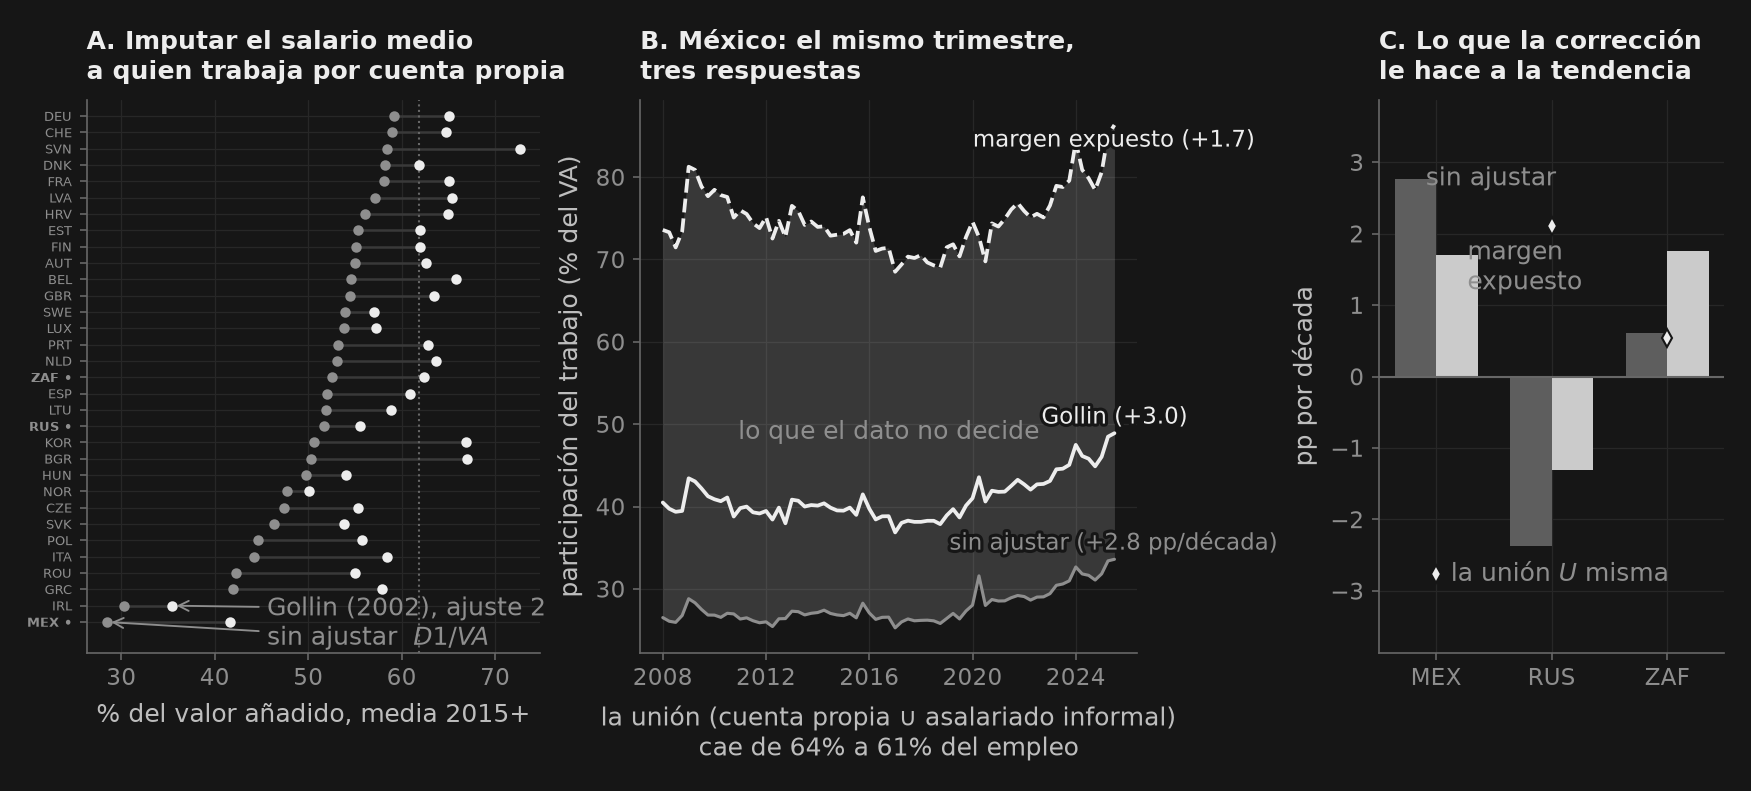

In [34]:
# 36 filas de mancuernas en A: ninguna talla de TAMANO da la altura, así que se
# fija a mano (el ancho de "3", más alto).
fig, (axA, axB, axC) = _nbstyle.figura(1, 3, figsize=(11.4, 5.0),
                                       gridspec_kw={"width_ratios": [1.05, 1.15, 0.8]})

# A. La corrección de Gollin, país por país. Mancuernas y no barras: lo que hay
# que ver es el DESPLAZAMIENTO, y su longitud es la proporción de cuenta propia.
o = ls.sort_values("bruta")
y = np.arange(len(o))
for i, (_, r) in enumerate(o.iterrows()):
    axA.plot([r["bruta"], r["gollin"]], [i, i], color=_nbstyle.gris("0.75"), lw=1.2, ls="-", zorder=1)
axA.scatter(o["bruta"], y, s=16, color=_nbstyle.NOTA, zorder=3)
axA.scatter(o["gollin"], y, s=16, color=_nbstyle.TINTA, zorder=3)
axA.set_yticks(y)
axA.set_yticklabels([c + (" •" if c in band.index else "") for c in o.index],
                    fontsize=6.0)
for i, c in enumerate(o.index):
    if c in band.index:
        axA.get_yticklabels()[i].set_fontweight("bold")
axA.set_ylim(-1.9, len(o))
axA.axvline(o["gollin"].median(), color=_nbstyle.SPINE, ls=":", lw=1.0)
axA.set_xlabel("% del valor añadido, media 2015+")
axA.set_title("A. Imputar el salario medio\na quien trabaja por cuenta propia")
# Los dos marcadores se nombran en las dos filas más bajas, donde queda sitio a la derecha.
x_txt = float(o["gollin"].iloc[:2].max()) + 4.0
axA.annotate("Gollin (2002), ajuste 2", xy=(float(o["gollin"].iloc[1]), 1),
             xytext=(x_txt, 0.8), textcoords="data", ha="left", va="center",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
axA.annotate("sin ajustar  $D1/VA$", xy=(float(o["bruta"].iloc[0]), 0),
             xytext=(x_txt, -1.0), textcoords="data", ha="left", va="center",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)

# B. La misma pregunta con la tasa trimestral: México, trimestre a trimestre.
# La banda gris es todo lo que el dato no decide.
j = banda["MEX"]
axB.fill_between(j.index, j["bruta"], j["expuesto"], color=_nbstyle.BANDA, lw=0)
axB.plot(j.index, j["bruta"], color=_nbstyle.NOTA, lw=1.5, ls="-",
         label=f"sin ajustar ({band.loc['MEX', 'd_bruta']:+.1f} pp/década)")
axB.plot(j.index, j["gollin"], color=_nbstyle.TINTA, lw=1.8, ls="-",
         label=f"Gollin ({band.loc['MEX', 'd_gollin']:+.1f})")
axB.plot(j.index, j["expuesto"], color=cols[0], lw=1.8, ls="--",
         label=f"margen expuesto ({band.loc['MEX', 'd_expuesto']:+.1f})")
medio = len(j) // 2
axB.annotate("lo que el dato no decide",
             xy=(j.index[medio], float((j["bruta"].iloc[medio] + j["expuesto"].iloc[medio]) / 2)),
             ha="center", va="center", color=_nbstyle.NOTA)
# Una marca cada cuatro años: el panel es estrecho para tantos trimestres.
marcas_b = [t for t in j.index if t.year % 4 == 0 and t.quarter == 1]
axB.set_xticks(marcas_b); axB.set_xticklabels([str(t.year) for t in marcas_b])
axB.set_ylabel("participación del trabajo (% del VA)")
axB.set_title("B. México: el mismo trimestre,\ntres respuestas")
axB.set_xlabel(f"la unión (cuenta propia $\\cup$ asalariado informal)\ncae de "
               f"{j['U'].iloc[0]:.0f}% a {j['U'].iloc[-1]:.0f}% del empleo")

# C. Por qué la tasa tiene que ser trimestral: la corrección mueve la
# TENDENCIA, y solo puede hacerlo si se mueve ella.
w, xb = 0.36, np.arange(len(band))
axC.bar(xb - w / 2, band["d_bruta"], w, color=_nbstyle.BARRA_COLORES[2])
axC.bar(xb + w / 2, band["d_expuesto"], w, color=_nbstyle.BARRA_COLORES[0])
axC.plot(xb, band["d_U"], marker="d", color=_nbstyle.TINTA, mec=_nbstyle.FONDO, linestyle="", ms=6)
axC.axhline(0, color=_nbstyle.SPINE, lw=1.0)
axC.set_xticks(xb); axC.set_xticklabels(band.index)
axC.set_ylabel("pp por década")
axC.set_title("C. Lo que la corrección\nle hace a la tendencia")
axC.margins(y=0.2)
# Las tres marcas se nombran en el primer país, cada una a la derecha de la
# suya: las tres alturas son distintas, así que los nombres no se pisan.
for dx, dy, texto, v in ((-w / 2, 0, "sin ajustar", float(band["d_bruta"].iloc[0])),
                         (w / 2, -6, "margen\nexpuesto", float(band["d_expuesto"].iloc[0]))):
    axC.annotate(texto, xy=(xb[0] + dx, v), xytext=(5, dy), textcoords="offset points",
                 ha="left", va="center", color=_nbstyle.NOTA)
axC.annotate("la unión $U$ misma", xy=(xb[0], float(band["d_U"].iloc[0])), xytext=(7, 0),
             textcoords="offset points", ha="left", va="center", color=_nbstyle.NOTA)

_nbstyle.etiquetar(axB)
plt.show()


## 4. Contabilidad Nacional en Tiempo Real: Revisiones, Vintages y Metodología del SCN

Las decisiones de política macroeconómica y los hechos estilizados dependen crucialmente del *vintage* de la contabilidad nacional.
Analizamos dos dimensiones fundamentales:
1. **Sección 4.1**: El **contraste de Mankiw–Shapiro (1986)** de *news* vs. *noise* sobre el dato preliminar y el final — el par de regresiones $r_t = \alpha + \beta y^p_t + \varepsilon_t$ (news) y $r_t = \alpha + \beta y^f_t + \varepsilon_t$ (noise) — sobre las 42 áreas de referencia del archivo de revisiones de la OCDE, primero sobre el PIB y después sobre cada una de las nueve medidas que trae el archivo.
2. **Sección 4.2**: El impacto de los **vintages y cambios metodológicos del SCN** sobre los segundos momentos, específicamente la **volatilidad relativa del consumo $\sigma(c)/\sigma(y)$**.


### 4.1 El Contraste de Mankiw–Shapiro (1986)

Sea $y^p_t$ el dato preliminar, $y^f_t$ el dato final, y $r_t = y^f_t - y^p_t$ la revisión.

**Mankiw y Shapiro (1986)** postulan dos hipótesis polares y —esta es la parte que suele omitirse— cada una implica su **propia** condición de ortogonalidad, así que el contraste es un **par** de regresiones sobre la misma variable dependiente:

| | el modelo | la regresión | bajo ella |
|---|---|---|---|
| **News** | $y^p_t = \mathbb{E}[y^f_t \mid \Omega_t]$: el preliminar es un pronóstico eficiente | $r_t = \alpha + \beta\, y^p_t + \varepsilon_t$ | $\beta = 0$, porque un error de pronóstico es ortogonal al pronóstico |
| **Noise** | $y^p_t = y^f_t + \eta_t$: el preliminar es la verdad más error de medición | $r_t = \alpha + \beta\, y^f_t + \varepsilon_t$ | $\beta = 0$, porque $r_t = -\eta_t$ es ortogonal a la verdad |

Una no es la hipótesis nula de la otra. Estimar solo la primera —que es lo que hace un «contraste de la hipótesis de news» de una línea— deja sin distinguir **noise** ($\beta_p < 0$, $\beta_f = 0$) de **ninguna de las dos** ($\beta_p < 0$ *y* $\beta_f \neq 0$), y el segundo caso es el común: revisiones que son en parte error de medición y en parte información genuinamente nueva. `puremacro` estima ambas y emite el veredicto en cuatro categorías — `news`, `noise`, `indeterminate` (no se rechaza ninguna: la muestra no alcanza para separarlas) y `neither` (se rechazan las dos).

Bajo noise, $-\hat{\beta}_p$ estima $\mathrm{Var}(\eta)/\mathrm{Var}(y^p)$ —la fracción de la varianza del preliminar que es error de medición— y la política en tiempo real debería usar el **estimador de contracción (*shrinkage*)**
$$ \tilde{y}^p_t = \hat{\alpha} + (1 + \hat{\beta}_p)\, y^p_t. $$

**Dos hechos sobre las tasas de crecimiento, antes de estimar nada.** Primero, la regresión debe correrse sobre **crecimiento**, nunca sobre niveles: una revisión de un nivel $I(1)$ regresada sobre ese nivel es una regresión espuria, y $\hat{\beta}$ saldrá maravillosamente significativo por razones que no tienen nada que ver con ninguna de las dos hipótesis. Segundo, correrla sobre crecimiento es además lo que hace utilizable el archivo. Cada edición está sobre el año de referencia de precios y la versión de las cuentas vigentes cuando se publicó, así que **los niveles no son comparables entre ediciones**: las ediciones mexicanas de 2008-07 a 2009-11 registran el mismo trimestre en un valor unas $4.5$ veces el que le dan las ediciones de uno y otro lado. Un reescalamiento de una edición entera por cualquier constante $k$ se cancela en las tasas de crecimiento de esa edición, porque $\log(k x_t) - \log(k x_{t-1})$ no depende de $k$; la transformación que legitima la regresión es la misma que hace desaparecer los cambios de base.

#### El panel: todo el archivo que hay

El contraste casi siempre se corre sobre un país, y casi siempre sobre Estados Unidos, cuyo conjunto de datos en tiempo real mantiene la Fed de Filadelfia desde 1996. Es un sitio razonable por donde empezar y un mal sitio donde parar. «Las revisiones del PIB son ruido» es una afirmación sobre cómo funciona una oficina estadística, y una oficina es una observación: si describe la medición en general o a la Oficina de Análisis Económico en particular no puede zanjarse desde dentro de Estados Unidos. Puede zanjarse haciéndole la misma pregunta a cada oficina que guarde un archivo.

`puremacro.fetch.vintage_panel` sustituye todo el aparato con una sola llamada. Lee el **archivo de revisiones de las Estadísticas Económicas de Corto Plazo de la OCDE** (`DSD_STES_REVISIONS`), el archivo de vintages entre países más amplio que existe sin credenciales: **42 áreas de referencia, ediciones mensuales desde febrero de 1999**. Devuelve un `VintagePanel`, que trae las operaciones que todo el mundo reconstruye a mano — `coverage()`, el triángulo de revisiones `triangle()`, `as_of()` (cómo se veía el conjunto entero un día dado), `revisions()` y `news_or_noise()`.

> **Qué significa aquí una fecha de vintage.** La `EDITION` del archivo es el mes de la **instantánea de la OCDE** de la serie nacional, no la fecha en que la publicó la oficina estadística: la OCDE ingiere con rezago, así que una edición puede seguir cargando la cifra del mes anterior. Sirve para ordenar ediciones y medir revisiones, y no sirve para usar la fecha como fecha de evento — para fechas de publicación nacionales genuinas `vintage_panel` también trae los proveedores del Bundesbank (DE), la ONS (RU) y StatCan (CA), un país cada uno. `VINTAGE_SEMANTICS` lo documenta para cada proveedor, y `vintage_panel` avisa si el panel termina mezclándolos.

In [35]:
from puremacro.fetch import vintage_panel
from puremacro.vintages import mankiw_shapiro
from puremacro.fetch.realtime import (VintagePanel, VINTAGE_SEMANTICS,
                                      seasonal_signature,
                                      drop_unadjusted_editions,
                                      SEASONAL_F_MIN, SEASONAL_RANGE_MIN,
                                      SEASONAL_MIN_OBS, SEASONAL_WINDOW)
from puremacro.fetch.realtime.oecd_stes import OECD_STES_COUNTRIES

# EA20 es la zona euro, no un país: se conserva en el panel (sus revisiones
# tienen interés propio) y se excluye de todo conteo y toda mediana entre
# países más abajo, por el mismo principio de §1.1.
AGREGADOS = {"EA20"}
VINTAGE_SNAPSHOT = DATA / "oecd_stes_vintages_gdp.csv.gz"


def vintages_de_instantanea(ruta):
    """Reconstruye el VintagePanel desde el archivo congelado del curso.

    El archivo guarda las cuatro columnas que llevan información —área,
    trimestre de referencia, edición, valor— y aquí se reponen las cuatro que
    son constantes para él. Comprimido: 1.25 millones de filas son 23 MB en
    CSV plano y 3.8 MB así, y `pd.read_csv` descomprime por la extensión sin
    ningún paquete extra, lo que importa en una tableta. Quien lo leyó fue
    `archivo`, en §1.8: esto es el segundo uso de un análisis, no un segundo
    análisis.
    """
    s = archivo(ruta)
    return VintagePanel(df=pd.DataFrame({
        "country": s["code"],
        "variable": s["variable"],
        "date": s["date"],
        "vintage": pd.to_datetime(s["edition"], format="%Y%m"),
        "value": s["value"],
        # Las tres columnas que el panel exige y nadie agrupa son constantes o
        # casi: una cadena, otra cadena, y 42 identificadores. Guardadas como
        # `object` son 1,25 millones de punteros cada una —220 MB de las 386
        # que ocupa el panel— y como `category` son un diccionario de dos o
        # cuarenta y dos entradas más un vector de códigos. El archivo pasa de
        # 386 a 170 MB, y hay dos de estos vivos a la vez en §4.1: en un
        # escritorio es una comodidad y en una tableta es la diferencia entre
        # correr y paginar. `country` y `variable` se quedan en `object` a
        # propósito, porque puremacro agrupa por ellas y un agrupador
        # categórico arrastra categorías vacías.
        "provider": pd.Categorical(["oecd_stes"] * len(s)),
        "series_id": pd.Categorical(s["code"].map(
            {c: f"{c}.Q.B1GQ_Q..." for c in s["code"].unique()})),
        "units": pd.Categorical(["level"] * len(s)),
    }), metadata={"source": str(ruta)})


rev, rev_fuente = None, ""
if VIVO:
    try:
        # drop_unadjusted=False a propósito: desde 1.8.0 vintage_panel filtra
        # solo las ediciones en bruto, y esta sección existe para MOSTRAR ese
        # filtro. Queremos el archivo tal como llega y lo filtramos abajo, a la
        # vista. Cualquier otro uso debería quedarse con el valor por omisión.
        rev = vintage_panel(list(OECD_STES_COUNTRIES), series="gdp_real",
                            freq="Q", drop_unadjusted=False)
        rev_fuente = "descarga en vivo"
        if rev.is_empty():
            rev = None
    except Exception as exc:                    # límite de tasa, WAF, tableta sin http
        print(f"Falló la descarga de vintages ({type(exc).__name__}); "
              f"se usa la instantánea.")
        rev = None
if rev is None:
    if not readable(VINTAGE_SNAPSHOT, "file"):
        raise RuntimeError(
            f"Sin panel en tiempo real: no hay instantánea en {VINTAGE_SNAPSHOT} "
            f"ni descarga. Copia la carpeta data_curso/ del curso junto a este "
            f"cuaderno, o vuelve a correr con MAV_QNA_VIVO=1 y conexión.")
    rev = vintages_de_instantanea(VINTAGE_SNAPSHOT)
    rev_fuente = "instantánea del curso (MAV_QNA_VIVO=1 para descargar)"

# El mismo tratamiento para la ruta en vivo, que llega con las columnas en
# `object`, y para que el resto de §4 no dependa de por dónde vino el panel.
for _col in ("provider", "series_id", "units"):
    if rev.df[_col].dtype == object:
        rev.df[_col] = rev.df[_col].astype("category")

# El archivo crudo ya cumplió aquí: §4.2 lo vuelve a pedir y `archivo` lo
# relee del disco en 0,35 s. Soltarlo ahora quita 225 MB durante justo el
# tramo en que §4.1 tiene DOS paneles de vintages vivos a la vez.
_ARCHIVOS.clear()

cov = rev.coverage()
print(f"Panel del PIB en tiempo real [{rev_fuente}]")
print(f"  {len(rev.countries)} áreas de referencia x {len(rev):,} observaciones "
      f"(trimestre de referencia x edición)")
print(f"  ediciones de {cov['first_vintage'].min():%Y-%m} a "
      f"{cov['last_vintage'].max():%Y-%m}, mediana "
      f"{int(cov['n_vintages'].median())} por área; los periodos de referencia "
      f"llegan hasta {cov['first_date'].min():%Y}")
print(f"  fecha de vintage: {VINTAGE_SEMANTICS['oecd_stes']}")
print("\nLas cinco áreas con el archivo más corto — las que menos pueden "
      "permitirse un contraste de revisiones:")
print(cov.nsmallest(5, "n_vintages")[
    ["country", "n_vintages", "n_periods", "first_vintage"]].to_string(index=False))

Panel del PIB en tiempo real [instantánea del curso (MAV_QNA_VIVO=1 para descargar)]
  42 áreas de referencia x 1,249,388 observaciones (trimestre de referencia x edición)
  ediciones de 1999-02 a 2026-08, mediana 329 por área; los periodos de referencia llegan hasta 1947
  fecha de vintage: Month of the OECD's snapshot of the national series (EDITION = YYYYMM), not the national statistical office's release date. The OECD ingests with a lag, so an edition can still carry the previous month's published figure. Fine for ordering editions and measuring revisions; not a release date.

Las cinco áreas con el archivo más corto — las que menos pueden permitirse un contraste de revisiones:
country  n_vintages  n_periods first_vintage
   EA20          41        126    2023-04-01
    CRI          66        142    2021-03-01
    COL          76         85    2020-05-01
    LTU          98        126    2018-07-01
    LVA         122        125    2016-07-01


#### La trampa: no todas las ediciones están desestacionalizadas

Estímese el contraste sobre el panel tal como llega y Suecia devuelve $\hat{\beta}_p = -0.96$ con una desviación típica de las revisiones de **5.1 pp trimestrales**; Turquía, $\hat{\beta}_p = -0.96$ y **10.9 pp**. Tomados al pie de la letra dicen que prácticamente *toda* la varianza de los preliminares sueco y turco es error de medición: un hallazgo espectacular, y falso.

El *dataflow* `DSD_STES_REVISIONS` tiene seis dimensiones y ninguna de ellas es el ajuste estacional. Carga lo que la OCDE ingirió en su momento, y para doce áreas las ediciones tempranas son la serie **sin desestacionalizar**. Las primeras publicaciones suecas dicen que la economía creció $15.8\%$ en 2000T4, $15.9\%$ en 2001T4 y $16.1\%$ en 2002T4; la edición de hoy pone esos mismos tres trimestres en $+0.13$, $+0.39$ y $+0.07$. Lo que la regresión llamaría revisión es un factor estacional.

No es un defecto de `vintage_panel` —está reportando fielmente lo que el archivo contiene— y no es detectable desde los metadatos, porque el archivo no lo registra. Sí es detectable desde los **datos**, y el cribado de abajo es deliberadamente tosco y deliberadamente visible. Para cada (área, edición) tomamos el crecimiento logarítmico trimestral de esa misma edición y le hacemos dos preguntas a las cuatro medias trimestrales:

1. ¿El patrón trimestral está ahí estadísticamente? — el estadístico $F$ de las variables ficticias trimestrales, que vale $\approx 1$ bajo desestacionalización.
2. ¿Es *grande*? — el rango entre la media trimestral más alta y la más baja, en puntos porcentuales de crecimiento trimestral.

Ambos se calculan **dentro** de cada edición, así que un cambio de base se cancela, y ambos sobre 1995–2019, así que la pandemia no se hace pasar por estacionalidad. Una edición se declara sin desestacionalizar cuando $F > 10$ **y** el rango es de al menos $4.25$ pp. El panel B de la figura siguiente es la justificación: las dos nubes están separadas por más de un orden de magnitud en los dos ejes, y el umbral cae en el hueco vacío entre ellas, no en un valor crítico convencional. La única decisión de criterio es Islandia, cuyas ediciones desestacionalizadas conservan una estacionalidad residual de $\approx 4$ pp —la mayor de todas las áreas— y quedan justo dentro del límite.

#### Encontrarlas es una cosa; qué hacer con ellas es otra

La reacción inmediata es **tirarlas**, y es la que esta lección tuvo durante varias versiones. Es defendible y tiene un problema serio que el conteo de filas esconde.

`revisions()` empareja cada trimestre de referencia con la **primera edición que lo contiene**. Quitar las ediciones tempranas de Suecia no borra los trimestres 2000T4–2006T4: los deja emparejados con la primera edición sueca que sobrevive, que es la de febrero de 2007. Para veinticinco trimestres suecos —y otros tantos mexicanos y turcos— el «dato preliminar» de la regresión pasa a ser una cifra que la oficina llevaba hasta seis años publicando y revisando. El contraste sigue corriendo, sigue teniendo 109 observaciones, y una cuarta parte de ellas ya no es lo que la teoría llama $y^p_t$. Además, en las áreas donde no sobrevive ninguna edición temprana, sí se pierden trimestres: cincuenta y tres pares en total.

Y hay una objeción de fondo: tirar deja un panel que **sigue mezclando dos procedimientos**. Los primeros años de cada área los desestacionalizó su oficina estadística con un método y un calendario; los años tempranos que se tiran, nadie. El archivo resultante no es homogéneo, es solo homogéneo *en promedio*.

La alternativa que este cuaderno usa desde aquí es **desestacionalizar todas las ediciones con un mismo filtro** — las 11.503, no las 501 marcadas. La razón para pasarlo también por las diez mil que ya venían ajustadas no es que lo necesiten: es que aplicárselo a unas y no a otras es exactamente la mezcla que se quiere evitar. El contraste se estima área por área, así que lo que tiene que ser homogéneo es cada área consigo misma: que $y^p_t$ e $y^f_t$ salgan del mismo procedimiento.

**El filtro y sus tres propiedades.** Es el reverso del cribado: a cada edición se le restan sus propias cuatro medias trimestrales de crecimiento, centradas. (1) **No mira hacia adelante** — la edición de mayo de 2001 se ajusta con lo que se sabía en mayo de 2001, que es la condición que hace legítimo cualquier ejercicio en tiempo real. (2) **Es invariante a los cambios de base**, por la misma razón que la regresión va sobre crecimiento. (3) **Es un no-operativo donde la oficina ya hizo el trabajo**: a las treinta áreas limpias les quita décimas de punto y les mueve el coeficiente una mediana de 0,006, lo que la tercera celda comprueba una por una.

Lo que el filtro **no** hace es perseguir estacionalidad móvil, efectos de calendario ni atípicos, que es de lo que X-13 se ocupa. Por eso la celda siguiente lo contrasta contra X-13 sobre la edición más estacional de cada área afectada, y por eso la comprobación se hace sobre la observación que el contraste realmente usa —el crecimiento del último trimestre de cada edición— y no sobre la serie entera. Esa celda es la única del cuaderno cuyos números dependen de la máquina: `deseasonalize_x13` usa el binario X-13 donde está instalado y el X-11/ARIMA en Python puro donde no —en una tableta, por ejemplo—, y los dos motores no dan el mismo ajuste. La tabla lo dice en su encabezado. Lo que no cambia es la conclusión: el filtro de ficticias queda cerca del ajuste completo, y los dos quedan lejísimos de no ajustar.

In [36]:
# El cribado vive en puremacro, no aquí: T01_A §6 necesita exactamente el
# mismo para la brecha del producto en tiempo real, y un filtro numérico
# mantenido en dos cuadernos y dos idiomas son cuatro copias que se van a
# desincronizar. `seasonal_signature` puntúa cada edición y
# `drop_unadjusted_editions` aplica el tratamiento antiguo —tirarlas—, que
# aquí se conserva solo para medir lo que habría costado. El tratamiento
# nuevo, en cambio, vive en el cuaderno y a la vista, porque la decisión que
# encapsula es justo lo que enseña la sección.
def desestacionalizar_ediciones(p, firma=None, ventana=SEASONAL_WINDOW,
                                min_obs=SEASONAL_MIN_OBS, con_recibo=True):
    """Un mismo filtro estacional sobre TODAS las ediciones del archivo.

    El filtro es el reverso exacto del cribado: `seasonal_signature` detecta
    una edición sin desestacionalizar comparando las cuatro medias trimestrales
    del crecimiento logarítmico *de esa misma edición*, y esto les resta esas
    cuatro medias. Sobre el nivel equivale a dividir por un factor estacional
    multiplicativo, porque la suma acumulada de cuatro medias centradas es
    periódica con periodo cuatro; sobre el crecimiento —que es lo que la
    regresión de Mankiw–Shapiro usa— equivale a un ajuste por variables
    ficticias trimestrales.

    Tres propiedades que lo hacen admisible en un archivo en tiempo real:

    1. **No mira hacia adelante.** Cada edición se ajusta con los trimestres
       que esa edición contenía, y ninguno posterior. La edición de mayo de
       2001 se desestacionaliza con lo que se sabía en mayo de 2001.
    2. **Es invariante a los cambios de base.** Multiplicar una edición entera
       por una constante no cambia su crecimiento logarítmico, así que tampoco
       sus medias trimestrales ni el factor que se le resta.
    3. **Es un no-operativo donde la oficina ya hizo el trabajo.** Las
       ediciones ya ajustadas conservan una estacionalidad residual de décimas
       de punto; restarla las mueve en el cuarto decimal.

    Es deliberadamente tosco —no persigue estacionalidad móvil, ni efectos de
    calendario, ni atípicos, que es lo que X-13 sí hace— y deliberadamente
    barato: once mil ediciones en un par de segundos, sin binarios externos,
    en una tableta. La celda siguiente lo contrasta contra X-13 donde más se
    juega.

    Devuelve ``(VintagePanel, recibo)``; el recibo dice, área por área, cuánta
    estacionalidad tenía la peor edición antes y después. Cuesta una segunda
    pasada de puntuación, así que el barrido de componentes de más abajo —que
    lee ocho archivos más y quiere el panel, no el recibo— pide
    ``con_recibo=False`` y recibe ``(VintagePanel, None)``.
    """
    lo, hi = pd.Timestamp(ventana[0]), pd.Timestamp(ventana[1])
    piezas, cortas = [], 0
    for (pais, var), sub in p.df.groupby(["country", "variable"], sort=True):
        piv = (sub.pivot_table(index="date", columns="vintage", values="value")
                  .sort_index())
        lg = np.log(piv)
        g = lg.diff()
        q = pd.Index(g.index.quarter)
        dentro = (g.index >= lo) & (g.index < hi)
        qd = q[dentro]
        m = g[dentro].groupby(qd).mean().reindex([1, 2, 3, 4])
        n_q = g[dentro].groupby(qd).count().reindex([1, 2, 3, 4]).fillna(0)
        # Las poquísimas ediciones que no llegan a min_obs dentro de la ventana
        # —las primerísimas, que terminan en 1998— se estiman sobre su muestra
        # entera, que para ellas es toda anterior a la pandemia de todos modos.
        corta = n_q.sum() < min_obs
        if corta.any():
            entera = g.groupby(q).mean().reindex([1, 2, 3, 4])
            mask = corta.to_numpy()
            m.loc[:, mask] = entera.loc[:, mask]
            cortas += int(corta.sum())
        m = m.fillna(0.0)
        m = m - m.mean(axis=0)      # centrado: se quita el perfil, no la media
        factor = m.cumsum()          # periódico por construcción: factor[4] = 0
        clave = pd.MultiIndex.from_arrays(
            [sub["date"].dt.quarter, sub["vintage"]])
        piezas.append(sub.assign(
            value=sub["value"].to_numpy()
            * np.exp(-factor.stack().reindex(clave).to_numpy())))
    salida = pd.concat(piezas, ignore_index=True)
    ajustado = VintagePanel(df=salida,
                            metadata={**p.metadata,
                                      "seasonal": "quarterly dummies within edition",
                                      "short_editions": cortas})
    if not con_recibo:
        return ajustado, None
    # `firma` se recibe hecha porque la celda ya la calculó para el cribado:
    # puntuar once mil ediciones dos veces es un cuarto de segundo en un
    # escritorio y bastante más en una tableta, y son exactamente los mismos
    # números.
    antes = seasonal_signature(p) if firma is None else firma
    despues = seasonal_signature(ajustado)
    recibo = pd.concat(
        [antes.groupby("country")["seasonal_range"].max().rename("rango_antes"),
         despues.groupby("country")["seasonal_range"].max().rename("rango_después"),
         antes.groupby("country")["unadjusted"].sum().rename("marcadas")],
        axis=1)
    return ajustado, recibo

# El cribado, primero: quién está sin ajustar y con cuánta fuerza.
F_MIN, RANGO_MIN = SEASONAL_F_MIN, SEASONAL_RANGE_MIN
firma = seasonal_signature(rev)

# Y el tratamiento: UN SOLO filtro sobre las 11.503 ediciones, no un filtro
# sobre unas y la oficina estadística sobre otras. `drop_unadjusted_editions`
# —la alternativa, y lo que hacían las versiones anteriores de esta lección—
# se conserva para medir lo que habría costado, que es el asunto de dos celdas
# más abajo.
rev_sa, recibo = desestacionalizar_ediciones(rev, firma=firma)
# Las áreas afectadas salen del propio cribado, así que tirar solo hay que
# hacerlo sobre ellas: `drop_unadjusted_editions` sobre el archivo entero
# devuelve la misma tabla y deja de paso una segunda copia de 1,25 millones de
# filas en la memoria de una tableta.
AFECTADAS = sorted(firma.loc[firma["unadjusted"], "country"].unique())
rev_drop, fuera = drop_unadjusted_editions(rev.filter(countries=AFECTADAS))

print(f"Ediciones que cargan una serie sin desestacionalizar: "
      f"{int(firma['unadjusted'].sum())} de {len(firma):,} evaluadas, en "
      f"{len(fuera)} de {len(rev.countries)} áreas.")
print(fuera.assign(first=fuera["first"].dt.strftime("%Y-%m"),
                   last=fuera["last"].dt.strftime("%Y-%m"),
                   median_range=fuera["median_range"].round(1))
      .to_string())

print(f"\nEl filtro pasa por las {len(rev.df):,} filas del archivo entero y no "
      f"tira ninguna. Estacionalidad máxima\npor área, antes y después "
      f"(rango entre el trimestre más fuerte y el más débil, pp de "
      f"crecimiento):")
_r = recibo.sort_values("rango_antes", ascending=False)
print(_r.head(14).round(3).to_string())
print(f"  ... y {len(_r) - 14} áreas más, todas por debajo de "
      f"{_r['rango_antes'].iloc[14]:.2f} pp antes del filtro.")
print(f"\nQue la columna de la derecha sea cero **no demuestra nada**: el "
      f"filtro resta exactamente las medias\ntrimestrales que el cribado mide, "
      f"así que anularlas es su definición, no un resultado. La "
      f"comprobación\nde verdad es externa y son las dos celdas siguientes — "
      f"contra X-13, y contra la edición de hoy de la\npropia oficina "
      f"estadística, que es la que produjo el $y^f_t$ del contraste.")
print(f"\nDonde la oficina ya había hecho el trabajo el filtro es un "
      f"no-operativo: en las "
      f"{int((recibo['marcadas'] == 0).sum())} áreas sin ninguna\nedición "
      f"marcada la estacionalidad que se les quita es de "
      f"{recibo.loc[recibo['marcadas'] == 0, 'rango_antes'].median():.2f} pp "
      f"medianos —décimas de punto de crecimiento\ntrimestral—, y §4.1 "
      f"comprueba más abajo que sus coeficientes no se mueven.")

# Guardias: el cribado tiene que separar, no raspar; y el filtro tiene que
# dejar el archivo entero en pie, no solo lo que le sobra.
assert firma["unadjusted"].sum() > 0
assert float(firma.loc[firma["unadjusted"], "seasonal_range"].min()) >= RANGO_MIN
assert len(rev_sa.countries) == len(rev.countries)
assert len(rev_sa.df) == len(rev.df)
assert float(recibo["rango_después"].max()) < 1e-6
assert set(fuera.index) == set(AFECTADAS)

Ediciones que cargan una serie sin desestacionalizar: 501 de 11,434 evaluadas, en 12 de 42 áreas.
         editions    first     last  median_range
country                                          
AUT            48  1999-04  2003-10          13.2
CZE            38  1999-05  2003-09          12.6
HUN            24  2003-04  2005-06          13.3
IRL             4  2004-07  2004-10           5.9
ISL            30  2003-04  2005-09          13.8
LUX             8  2006-06  2007-01           7.9
MEX            72  2000-10  2006-09           9.8
POL            53  2002-09  2007-01          22.5
PRT            16  1999-05  2000-08           4.5
SVK            56  2001-02  2005-09          12.4
SWE            76  2000-10  2007-01          27.5
TUR            76  2000-10  2007-01          60.0

El filtro pasa por las 1,249,388 filas del archivo entero y no tira ninguna. Estacionalidad máxima
por área, antes y después (rango entre el trimestre más fuerte y el más débil, pp de crecimiento):
   

In [37]:
# La comprobación externa del filtro: X-13 sobre la peor edición de cada una de
# las áreas afectadas. X-13 hace lo que las ficticias trimestrales no —
# estacionalidad móvil, efectos de calendario, atípicos—, así que si los dos
# coinciden sobre la observación que le importa al contraste, el filtro barato
# sirve. Doce corridas y no once mil: el binario X-13 tarda ~0,1 s cada una en
# un escritorio y bastante más en una tableta, y no hay ninguna razón para
# pagarlo once mil veces cuando doce contestan la pregunta.
from puremacro.sa import x13_available

# El motor importa aquí y solo aquí. `deseasonalize_x13` usa el binario X-13 si
# está instalado y el X-11/ARIMA propio en Python puro si no —que es lo que
# corre en una tableta—, y los dos no dan el mismo ajuste. Esta tabla, la única
# del cuaderno que compara un ajuste contra otro, cambia por tanto en la
# segunda cifra según la máquina; el veredicto que sostiene, no.
MOTOR = "binario X-13" if x13_available() else "X-11/ARIMA en Python puro"

peor = (firma[firma["unadjusted"]]
        .sort_values("seasonal_range", ascending=False)
        .drop_duplicates("country").set_index("country"))

filas = []
for c in AFECTADAS:
    ed = peor.loc[c, "vintage"]
    def _serie(p):
        d = p.df
        s = d[(d["country"] == c) & (d["vintage"] == ed)]
        return s.set_index("date")["value"].sort_index()
    bruta, nuestra = _serie(rev), _serie(rev_sa)
    if len(bruta) < 24:
        continue
    d13 = pd.DataFrame({"date": bruta.index, "v": np.log(bruta.to_numpy()),
                        "grp": "x"})
    x13 = np.exp(np.asarray(deseasonalize_x13(d13, "v", by="grp",
                                              date_col="date", freq="Q")))
    g = lambda v: 100.0 * np.diff(np.log(np.asarray(v)))
    gb, gn, gx = g(bruta), g(nuestra), g(x13)
    filas.append({"área": c, "edición": f"{ed:%Y-%m}", "trim.": len(gb),
                  "último bruto": gb[-1], "último ficticias": gn[-1],
                  "último X-13": gx[-1],
                  "|dif| mediana": float(np.median(np.abs(gn - gx))),
                  "corr": float(np.corrcoef(gn, gx)[0, 1])})
x13_vs = pd.DataFrame(filas).set_index("área")

print(f"El filtro barato contra X-13 ({MOTOR}), sobre la edición más "
      f"estacional de cada área afectada.\n«Último» es el crecimiento del "
      f"trimestre más reciente de esa edición — el $y^p_t$ del contraste:")
print(x13_vs.round(2).to_string())
_d = (x13_vs["último ficticias"] - x13_vs["último X-13"]).abs()
_b = (x13_vs["último bruto"] - x13_vs["último X-13"]).abs()
print(f"\nSobre la observación que el contraste usa, los dos filtros difieren "
      f"en una mediana de {_d.median():.2f} pp\n(peor caso {_d.max():.2f}, "
      f"{_d.idxmax()}), mientras que la serie sin desestacionalizar se separa "
      f"de X-13 en {_b.median():.1f} pp\nmedianos y hasta "
      f"{_b.max():.0f}. Elegir entre los dos ajustes importa "
      f"{_b.median() / _d.median():.0f} veces menos que elegir entre ajustar\ny "
      f"no ajustar, y eso es todo lo que este contraste necesita que sea "
      f"cierto.")
print(f"Sobre la serie entera se separan más —correlación mediana "
      f"{x13_vs['corr'].median():.2f}—, y es lo esperable: X-13 persigue "
      f"estacionalidad\nmóvil y atípicos que unas ficticias fijas no pueden "
      f"seguir. Quien necesite el nivel de un trimestre\nconcreto de una "
      f"edición concreta debe usar X-13; quien necesite el contraste, no.")

# Los dos ajustes coinciden donde importa y los dos se separan del bruto.
assert (_d < _b).all()
assert _d.median() < 1.0

El filtro barato contra X-13 (binario X-13), sobre la edición más estacional de cada área afectada.
«Último» es el crecimiento del trimestre más reciente de esa edición — el $y^p_t$ del contraste:
      edición  trim.  último bruto  último ficticias  último X-13  |dif| mediana  corr
área                                                                                  
IRL   2004-07     28         -1.75              0.65         0.98           0.35  0.98
ISL   2004-06     27          4.09              1.29         1.12           0.40  0.94
LUX   2006-09     44         -1.44              1.02         1.00           0.39  0.92
MEX   2000-12     81          2.65              2.21         1.32           0.96  0.74
POL   2005-05     39         10.08              1.73        -0.09           0.45  0.92
PRT   1999-05     35          2.38              0.24         0.40           0.38  0.77
SVK   2005-09     61          9.54              1.55         1.20           0.81  0.79
SWE   2000-10     29

In [38]:
# El contraste, sobre todas las áreas. `news_or_noise_panel` estima LAS DOS
# regresiones por área e informa de los países que no puede estimar en vez de
# descartarlos.
#
# Errores de Newey-West y no de White: las revisiones de referencia anuales
# llegan en un calendario fijo y meten autocorrelación en r_t, que los errores
# estándar de MCO leerían como precisión. `hac_lags="auto"` es la regla
# floor(4(n/100)^(2/9)), cuatro rezagos con n = 109.
#
# Un área cada vez, y las cuarenta y dos recortadas de una sola pasada. Toda
# llamada que nombra un país tiene que encontrar sus filas, y encontrarlas en un
# marco de 1,2 millones de filas significa comparar 1,2 millones de cadenas —24
# ms, pagados varias veces por área—. Un `groupby` corta las cuarenta y dos en
# 0,06 s y deja todo lo que viene después trabajando sobre ~30.000 filas; ir
# área por área con `filter` cuesta tres segundos, que en una tableta son
# quince. Es el mismo contraste sobre las mismas filas: `news_or_noise_panel`
# estima un (área, variable) cada vez, así que con el panel de un área devuelve
# la fila de esa área, y las cuarenta y dos se apilan en el orden en que las
# habría producido —`groupby(sort=True)` da el mismo orden que `.countries`—.
#
# La pata del sesgo —¿es cero la revisión MEDIA?— es el tercer diagnóstico de
# Mankiw y Shapiro y el único para el que `news_or_noise_panel` no trae valor
# p, así que hace falta también el objeto de resultado de cada área. Pedir las
# dos cosas por separado —`news_or_noise_panel` y `news_or_noise`— construye
# DOS VECES el triángulo de revisiones del área, y el triángulo es el 98% del
# coste: 1,6 s de los 1,7 que tardan las cuarenta y dos. Construirlo una vez y
# estimar sobre él da los dos objetos por el precio de uno. `_fila` copia el
# esquema de `news_or_noise_panel` y el assert del final lo contrasta contra la
# biblioteca sobre un área, para que la abreviatura no pueda desviarse en
# silencio. Solo hay una rebanada viva a la vez: guardar las cuarenta y dos
# sería una segunda copia del panel, y en una tableta la memoria es más escasa
# que el tiempo.
MIN_OBS_MS = 12


def _fila(code, r):
    return {"country": code, "variable": "gdp_real", "n_obs": r.n_obs,
            "mean_revision": r.mean_revision, "std_revision": r.std_revision,
            "beta_on_preliminary": r.beta_on_preliminary,
            "se_beta_on_preliminary": r.se_beta_on_preliminary,
            "p_beta_on_preliminary": r.p_beta_on_preliminary,
            "beta_on_final": r.beta_on_final,
            "se_beta_on_final": r.se_beta_on_final,
            "p_beta_on_final": r.p_beta_on_final,
            "noise_share": r.noise_share, "verdict": r.verdict,
            "ok": True, "note": ""}


_filas, _res = [], {}
for c, _g in rev_sa.df.groupby("country", sort=True):
    una = VintagePanel(df=_g, metadata=rev_sa.metadata)
    _fr = una.revisions(c)
    if len(_fr) < MIN_OBS_MS:      # la biblioteca los informa, no los descarta
        _filas.append({"country": c, "variable": "gdp_real", "n_obs": len(_fr),
                       "ok": False, "note": f"solo {len(_fr)} pares de revisión"})
        continue
    _res[c] = mankiw_shapiro(_fr["preliminary"], _fr["final"], hac_lags="auto",
                             transform="log_diff_pct")
    _filas.append(_fila(c, _res[c]))

ms = pd.DataFrame(_filas)

# La abreviatura da exactamente lo que da la biblioteca. Se comprueba sobre un
# área —una llamada más, no cuarenta y dos— y sobre todas las columnas que esta
# sección usa.
_c0 = ms["country"].iloc[0]
_ref = (VintagePanel(df=rev_sa.df[rev_sa.df["country"] == _c0],
                     metadata=rev_sa.metadata)
        .news_or_noise_panel(hac_lags="auto", min_obs=MIN_OBS_MS).iloc[0])
for _k in ("n_obs", "mean_revision", "std_revision", "beta_on_preliminary",
           "se_beta_on_preliminary", "p_beta_on_preliminary", "beta_on_final",
           "p_beta_on_final", "verdict", "ok"):
    _a, _b = ms.loc[0, _k], _ref[_k]
    assert _a == _b or abs(float(_a) - float(_b)) < 1e-12, (_k, _a, _b)
ms["es_agregado"] = ms["country"].isin(AGREGADOS)
ms["p_sesgo"] = ms["country"].map({c: r.p_mean_revision for c, r in _res.items()})

print(ms.loc[~ms["es_agregado"],
             ["country", "n_obs", "mean_revision", "p_sesgo", "std_revision",
              "beta_on_preliminary", "se_beta_on_preliminary",
              "p_beta_on_preliminary", "beta_on_final", "p_beta_on_final",
              "verdict"]].round(3).to_string(index=False))

ok = ms[ms["ok"] & ~ms["es_agregado"]]
n_neg = int((ok["beta_on_preliminary"] < 0).sum())
n_signeg = int(((ok["beta_on_preliminary"] < 0)
                & (ok["p_beta_on_preliminary"] < 0.05)).sum())
n_sigpos = int(((ok["beta_on_preliminary"] > 0)
                & (ok["p_beta_on_preliminary"] < 0.05)).sum())
print(f"\nEstimado para {int(ms['ok'].sum())} de {len(ms)} áreas "
      f"({len(ok)} países más {int(ms['es_agregado'].sum())} agregado); "
      f"muestra mediana de {int(ok['n_obs'].median())} trimestres.")
print(f"  beta sobre el preliminar: mediana {ok['beta_on_preliminary'].median():+.3f}, "
      f"negativo en {n_neg}/{len(ok)}, significativamente negativo en {n_signeg}, "
      f"significativamente positivo en {n_sigpos}.")
print(f"  revisión media: positiva en {int((ok['mean_revision'] > 0).sum())}/{len(ok)} "
      f"países, mediana {ok['mean_revision'].median():+.3f} pp por trimestre "
      f"({4 * ok['mean_revision'].median():+.2f} pp al año), significativamente "
      f"distinta de cero en {int((ok['p_sesgo'] < 0.05).sum())}.")
print("  veredictos: " + ", ".join(f"{k} {v}" for k, v
                                   in ms["verdict"].value_counts().items()))

# La dirección es el hallazgo, y es de un solo lado: los coeficientes
# significativamente negativos superan a los positivos en más de un orden de
# magnitud, y los positivos no pasan de lo que 41 contrastes al 5% producen
# por azar. (Con el archivo tratando de tirar las ediciones marcadas en vez de
# ajustarlas, el recuento de positivos era exactamente cero; el que aparece
# ahora es Portugal con p = 0.045, y §4.1 lo nombra en vez de esconderlo.)
assert n_sigpos <= 0.05 * len(ok) + 1
assert n_signeg > 8 * max(n_sigpos, 1)
assert n_neg > len(ok) / 2
assert float(ms.loc[ms["country"] == "USA", "beta_on_preliminary"].iloc[0]) < 0

country  n_obs  mean_revision  p_sesgo  std_revision  beta_on_preliminary  se_beta_on_preliminary  p_beta_on_preliminary  beta_on_final  p_beta_on_final       verdict
    AUS    108          0.087    0.002         0.322               -0.058                   0.037                  0.119          0.044            0.298 indeterminate
    AUT    109          0.066    0.215         0.797               -0.033                   0.086                  0.703          0.151            0.005          news
    BEL    109          0.137    0.003         0.404               -0.065                   0.026                  0.013         -0.010            0.825         noise
    BRA     86          0.130    0.015         0.609               -0.047                   0.029                  0.103          0.075            0.257 indeterminate
    CAN    109          0.051    0.056         0.344               -0.072                   0.015                  0.000         -0.030            0.562         nois

In [39]:
# Lo que costaba la alternativa. Tirar las ediciones marcadas —lo que hacían
# las versiones anteriores de esta lección— deja un archivo que sigue mezclando
# dos cosas, y de dos maneras, solo una de las cuales se ve en el conteo de
# filas:
#
#   1. Se pierden trimestres enteros allí donde el área no conserva ninguna
#      edición temprana.
#   2. Y donde sí conserva una posterior, el «preliminar» de ese trimestre deja
#      de ser una primera publicación y pasa a ser la estimación que la oficina
#      tenía AÑOS más tarde. La regresión lo sigue llamando y^p_t y el conteo
#      de observaciones no avisa.
#
# La celda recorre el archivo UNA vez. Cada área necesita aquí cuatro cosas
# —dos regresiones, dos triángulos de revisiones y dos mapas de primera
# edición—, y pedírselas al marco completo, como hacía la primera versión de
# esta celda, son cuatro barridos de 1,25 millones de filas por área: quince
# segundos en un escritorio y más de un minuto en una tableta. Cortado de
# antemano con un `groupby`, lo mismo cuesta dos segundos.
ms_i = ms.set_index("country")
_cortes_drop = {c: g for c, g in rev_drop.df.groupby("country", sort=False)}


def _primera_edicion(g):
    """Edición más temprana que contiene cada trimestre de referencia."""
    return g[g["value"].notna()].groupby("date")["vintage"].min()


filas, beta_otras, n_otras = [], {}, {}
for c, g in rev.df.groupby("country", sort=True):
    # Un triángulo por (área, tratamiento) y no dos: `news_or_noise_panel`
    # construiría el suyo y `revisions` otro igual, y el triángulo es casi todo
    # el coste. Es la misma abreviatura que la celda del contraste, ya
    # contrastada allí contra la biblioteca.
    p_bruto = VintagePanel(df=g, metadata=rev.metadata)
    par_a = p_bruto.revisions(c)
    r_bruto = mankiw_shapiro(par_a["preliminary"], par_a["final"],
                             hac_lags="auto", transform="log_diff_pct")
    if c not in AFECTADAS:
        # Las treinta que la oficina ya había ajustado: solo hace falta su beta
        # sobre el archivo en bruto, para enseñar que pasarles el filtro por
        # encima no les hizo nada.
        beta_otras[c] = float(r_bruto.beta_on_preliminary)
        n_otras[c] = int(r_bruto.n_obs)
        continue
    p_drop = VintagePanel(df=_cortes_drop[c], metadata=rev.metadata)
    par_d = p_drop.revisions(c)
    r_drop = mankiw_shapiro(par_d["preliminary"], par_d["final"],
                            hac_lags="auto", transform="log_diff_pct")
    comun = par_a.index.intersection(par_d.index)
    tardio = ((par_a.loc[comun, "preliminary"]
               - par_d.loc[comun, "preliminary"]).abs() > 1e-9)
    rez = ((_primera_edicion(_cortes_drop[c]) - _primera_edicion(g)).dt.days
           / 365.25).reindex(comun[tardio])
    filas.append({
        "área": c,
        "n tirando": int(r_drop.n_obs),
        "n ajustando": int(ms_i.loc[c, "n_obs"]),
        "prelim. tardío": int(tardio.sum()),
        "rezago (años)": float(rez.median()) if len(rez) else 0.0,
        "sd rev. bruto": float(r_bruto.std_revision),
        "sd rev. ajust.": float(ms_i.loc[c, "std_revision"]),
        "beta bruto": float(r_bruto.beta_on_preliminary),
        "beta tirando": float(r_drop.beta_on_preliminary),
        "beta ajustando": float(ms_i.loc[c, "beta_on_preliminary"]),
    })
tres = pd.DataFrame(filas).set_index("área")
tres["trim. perdidos"] = tres["n ajustando"] - tres["n tirando"]

print("Las tres maneras de tratar el archivo, sobre las doce áreas que lo "
      "necesitan:")
print(tres[["n tirando", "n ajustando", "trim. perdidos", "prelim. tardío",
            "rezago (años)", "sd rev. bruto", "sd rev. ajust.", "beta bruto",
            "beta tirando", "beta ajustando"]].round(2).to_string())

perdidos, tardios = int(tres["trim. perdidos"].sum()), int(tres["prelim. tardío"].sum())
con_tardio = tres.index[tres["prelim. tardío"] > 0]
detalle = ", ".join(f"{c} {int(tres.loc[c, 'prelim. tardío'])}" for c in con_tardio)
d_ajuste = (tres["beta ajustando"] - tres["beta tirando"]).abs()
d_bruto = (tres["beta bruto"] - tres["beta ajustando"]).abs()
print(f"\nTirar cuesta {perdidos} pares (área, trimestre) y —esto es lo que no "
      f"aparece en ningún conteo de filas—\nconvierte el preliminar de otros "
      f"{tardios} en una estimación posterior: {detalle}, con rezagos\nmedianos "
      f"de hasta {tres['rezago (años)'].max():.1f} años. Un contraste de "
      f"revisiones cuyo «dato preliminar» lleva tres años\npublicado no mide lo "
      f"que dice medir.")
print(f"\nLos coeficientes, en cambio, casi no distinguen entre tirar y "
      f"ajustar: la diferencia mediana es\n{d_ajuste.median():.3f} y la mayor "
      f"{d_ajuste.max():.2f} ({d_ajuste.idxmax()}), frente a los "
      f"{d_bruto.median():.2f} medianos que separan a cualquiera de\nlas dos "
      f"del archivo en bruto. Las dos correcciones coinciden en el "
      f"diagnóstico; se diferencian en lo\nque dejan en pie.")

# Y las treinta áreas que la oficina ya había ajustado: el filtro pasa por
# encima de ellas y hay que enseñar que no les hizo nada, porque aplicarlo a
# TODO el archivo es justo lo que evita que el panel mezcle procedimientos.
OTRAS = sorted(beta_otras)
d_otras = (ms_i.loc[OTRAS, "beta_on_preliminary"]
           - pd.Series(beta_otras)).abs()
igual_n = bool((ms_i.loc[OTRAS, "n_obs"] == pd.Series(n_otras)).all())
print(f"\nEn las otras {len(OTRAS)} áreas el filtro es inofensivo: el "
      f"coeficiente se mueve una mediana de {d_otras.median():.3f}\ny como "
      f"mucho {d_otras.max():.3f} ({d_otras.idxmax()}), y el número de "
      f"observaciones {'no cambia en ninguna' if igual_n else 'cambia en alguna'}. "
      f"Ese es el sentido\nde aplicarlo a todo el archivo en vez de solo a las "
      f"doce: el panel deja de mezclar dos procedimientos\nsin que cueste nada "
      f"donde no hacía falta.")

# Ajustar domina a tirar en cobertura y empata en diagnóstico.
assert perdidos > 0 and tardios > 0
assert (tres["trim. perdidos"] >= 0).all()
assert d_ajuste.median() < 0.15
assert d_otras.max() < 0.10 and igual_n
assert tres["sd rev. ajust."].median() < tres["sd rev. bruto"].median()

# El archivo en bruto y su versión recortada ya dijeron todo lo que tenían que
# decir; lo que sigue solo lee `rev_sa`. Son dos marcos de cientos de MB, y en
# una tableta la memoria es más escasa que el tiempo.
del _cortes_drop, rev, rev_drop

Las tres maneras de tratar el archivo, sobre las doce áreas que lo necesitan:
      n tirando  n ajustando  trim. perdidos  prelim. tardío  rezago (años)  sd rev. bruto  sd rev. ajust.  beta bruto  beta tirando  beta ajustando
área                                                                                                                                                
AUT         109          109               0              15           1.34           1.72            0.80       -0.45         -0.02           -0.03
CZE         109          109               0              12           1.62           1.73            0.73       -0.61         -0.19           -0.16
HUN          92           93               1               6           0.91           1.47            0.67       -0.27          0.00           -0.01
IRL          94           94               0               2           0.21           3.32            3.21       -0.13         -0.13           -0.01
ISL          79           92

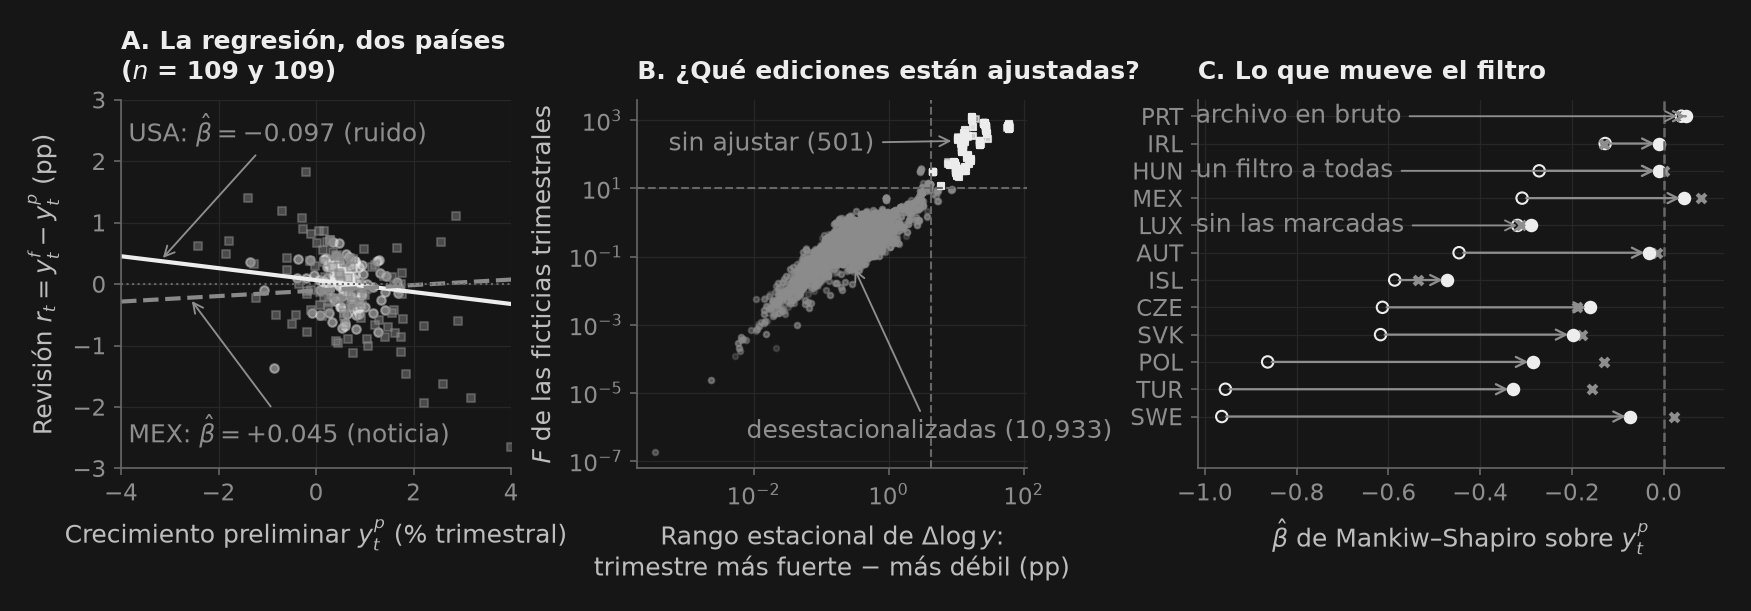

In [40]:
_VEREDICTO = {"noise": "ruido", "news": "noticia", "indeterminate": "indeterminado",
              "neither": "ninguno de los dos"}
# C lleva los nombres junto a sus marcadores y necesita el ancho; A y B son
# nubes de puntos y lo ceden sin perder nada.
fig, (axA, axB, axC) = _nbstyle.figura(1, 3,
                                       gridspec_kw={"width_ratios": [1.0, 1.0, 1.35]})

# A. la regresión en sí, para los dos países que este curso no deja de comparar
n_obs, rectas_A = {}, []
for code, col, mk, ls in (("USA", _nbstyle.UNIVERSAL_COLORS[0], "o", "-"), ("MEX", cols[3], "s", "--")):
    fr = rev_sa.revisions(code)
    r = _res[code]
    n_obs[code] = r.n_obs
    axA.scatter(fr["preliminary"], fr["revision"], s=17, alpha=0.45,
                color=col, marker=mk)
    gx = np.linspace(-4, 4, 50)
    rectas_A += axA.plot(gx, r.alpha_on_preliminary + r.beta_on_preliminary * gx,
                         color=col, lw=2.0, ls=ls,
                         label=f"{code}: $\\hat{{\\beta}}={r.beta_on_preliminary:+.3f}$ "
                               f"({_VEREDICTO[r.verdict]})")
axA.axhline(0, color=_nbstyle.SPINE, ls=":", lw=1.0)
axA.set_xlim(-4, 4); axA.set_ylim(-3.0, 3.0)
axA.set_xlabel("Crecimiento preliminar $y^p_t$ (% trimestral)")
axA.set_ylabel("Revisión $r_t = y^f_t - y^p_t$ (pp)")
axA.set_title("A. La regresión, dos países\n($n$ = " + " y ".join(str(v) for v in n_obs.values()) + ")")

# B. el filtro, y por qué sus umbrales están donde están
ajustadas, sin_ajustar = firma[~firma["unadjusted"]], firma[firma["unadjusted"]]
axB.scatter(ajustadas["seasonal_range"], ajustadas["F"], s=7, alpha=0.25, color=_nbstyle.NOTA)
axB.scatter(sin_ajustar["seasonal_range"], sin_ajustar["F"], s=9, alpha=0.6, color=cols[0],
            marker="s")
axB.axhline(F_MIN, color=_nbstyle.SPINE, ls="--", lw=1.0)
axB.axvline(RANGO_MIN, color=_nbstyle.SPINE, ls="--", lw=1.0)
axB.set_xscale("log"); axB.set_yscale("log")
axB.set_xlabel("Rango estacional de $\\Delta\\log y$:\ntrimestre más fuerte $-$ más débil (pp)")
axB.set_ylabel("$F$ de las ficticias trimestrales")
axB.set_title("B. ¿Qué ediciones están ajustadas?")
# Cada nube se nombra desde el espacio libre: arriba a la izquierda las marcadas,
# abajo a la derecha las demás.
axB.annotate(f"sin ajustar ({len(sin_ajustar)})",
             xy=(float(sin_ajustar["seasonal_range"].quantile(0.1)), float(sin_ajustar["F"].median())),
             xytext=(0.08, 0.88), textcoords="axes fraction", ha="left", va="center",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
axB.annotate(f"desestacionalizadas ({len(ajustadas):,})",
             xy=(float(ajustadas["seasonal_range"].median()), float(ajustadas["F"].quantile(0.1))),
             xytext=(0.28, 0.10), textcoords="axes fraction", ha="left", va="center",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)

# C. lo que mueve el filtro, y lo poco que separa a los dos tratamientos
mv = tres.sort_values("beta bruto").reset_index()
yv = np.arange(len(mv))
for i in yv:
    axC.annotate("", xy=(mv.loc[i, "beta ajustando"], i),
                 xytext=(mv.loc[i, "beta bruto"], i),
                 arrowprops=dict(arrowstyle="->", color=_nbstyle.NOTA, lw=1.1))
axC.scatter(mv["beta bruto"], yv, s=30, facecolors="none", edgecolors=cols[0])
axC.scatter(mv["beta tirando"], yv, s=18, color=_nbstyle.NOTA, marker="x")
axC.scatter(mv["beta ajustando"], yv, s=30, color=_nbstyle.TINTA)
axC.axvline(0, color=_nbstyle.SPINE, ls="--", lw=1.2)
axC.set_yticks(yv); axC.set_yticklabels(mv["área"])
axC.set_ylim(-1.9, len(mv) - 0.4)
axC.set_xlabel("$\\hat{\\beta}$ de Mankiw–Shapiro sobre $y^p_t$")
axC.set_title("C. Lo que mueve el filtro")
# Los tres marcadores se nombran en filas altas y alternas, a la izquierda,
# donde no hay puntos: en una sola fila los tres nombres se pisan.
for _yfila, _col, _txt in ((len(mv) - 1, "beta bruto", "archivo en bruto"),
                           (len(mv) - 3, "beta ajustando", "un filtro a todas"),
                           (len(mv) - 5, "beta tirando", "sin las marcadas")):
    axC.annotate(_txt, xy=(float(mv.loc[_yfila, _col]), _yfila), xytext=(-1.02, _yfila),
                 textcoords="data", ha="left", va="center", color=_nbstyle.NOTA,
                 arrowprops=_nbstyle.FLECHA)

# Los dos nombres van al hueco vacío de arriba y de abajo, con una guía hasta
# su recta: en medio de la nube la recta blanca tachaba a uno y la línea del
# cero al otro.
for _recta, _y_txt, _x_guia in zip(rectas_A, (2.5, -2.4), (-3.2, -2.6)):
    axA.annotate(_recta.get_label(),
                 xy=(_x_guia, float(np.interp(_x_guia, _recta.get_xdata(),
                                              _recta.get_ydata()))),
                 xytext=(-3.85, _y_txt), textcoords="data", ha="left", va="center",
                 color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
plt.show()


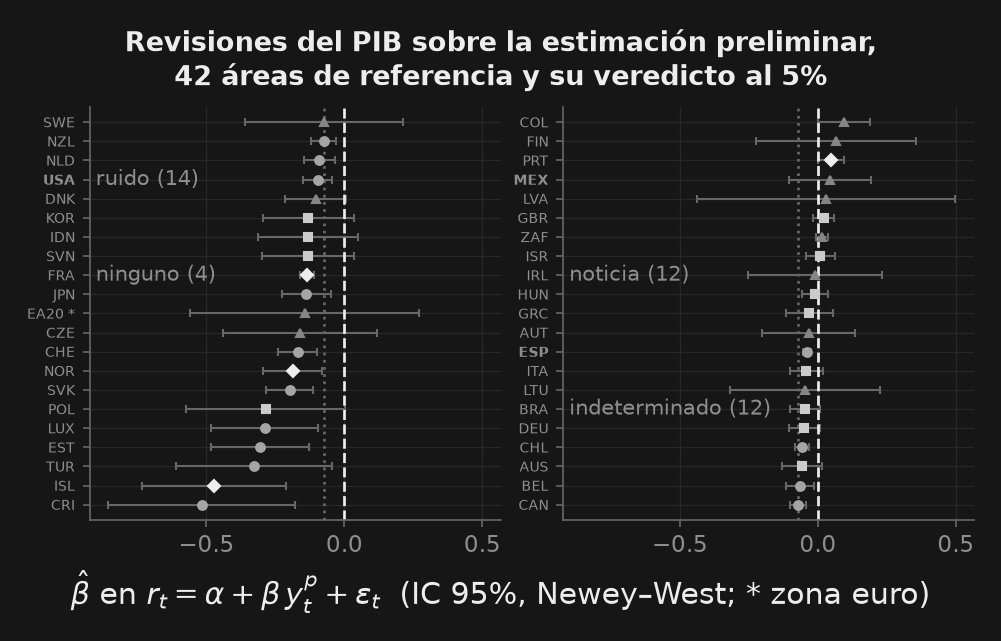

In [41]:
_MARCA = {"noise": ("o", _nbstyle.UNIVERSAL_COLORS[1]), "news": ("^", _nbstyle.UNIVERSAL_COLORS[4]),
          "indeterminate": ("s", _nbstyle.UNIVERSAL_COLORS[3]), "neither": ("D", _nbstyle.UNIVERSAL_COLORS[0])}
_NOMBRE = {"noise": "ruido", "news": "noticia", "indeterminate": "indeterminado",
           "neither": "ninguno"}
bosque = ms[ms["ok"]].sort_values("beta_on_preliminary").reset_index(drop=True)
bosque["lo"] = bosque["beta_on_preliminary"] - 1.96 * bosque["se_beta_on_preliminary"]
bosque["hi"] = bosque["beta_on_preliminary"] + 1.96 * bosque["se_beta_on_preliminary"]

# 42 filas en una columna no caben ni en el cuaderno ni en la ranura: van en dos
# columnas de 21, de la beta más negativa a la más positiva.
FILAS = 21
fig, axes = _nbstyle.figura(1, 2, sharex=True, figsize=plt.rcParams["figure.figsize"])
holgura = 0.05 * (bosque["hi"].max() - bosque["lo"].min())
mediana = float(bosque["beta_on_preliminary"].median())
for j, ax in enumerate(axes):
    tramo = bosque.iloc[j * FILAS:(j + 1) * FILAS]
    yf = np.arange(len(tramo))
    for veredicto, (mk, col) in _MARCA.items():
        m = (tramo["verdict"] == veredicto).to_numpy()
        if not m.any():
            continue
        ax.errorbar(tramo.loc[m.nonzero()[0] + j * FILAS, "beta_on_preliminary"], yf[m],
                    xerr=1.96 * tramo.loc[m.nonzero()[0] + j * FILAS, "se_beta_on_preliminary"],
                    fmt=mk, color=col, ecolor=_nbstyle.SPINE, elinewidth=1.0, capsize=1.8,
                    ms=4.2, lw=0)
    ax.axvline(0, color=_nbstyle.TINTA, ls="--", lw=1.3)
    ax.axvline(mediana, color=_nbstyle.SPINE, ls=":", lw=1.3)
    ax.set_yticks(yf)
    ax.set_yticklabels([c + (" *" if c in AGREGADOS else "")
                        for c in tramo["country"]], fontsize=6.5)
    for i, c in enumerate(tramo["country"]):
        if c in ("USA", "MEX", "ESP"):
            ax.get_yticklabels()[i].set_fontweight("bold")
    ax.set_ylim(-0.8, FILAS - 0.2)
    ax.set_xlim(bosque["lo"].min() - holgura, bosque["hi"].max() + holgura)

# Cada veredicto se nombra a la altura de su fila central, pegado al margen
# izquierdo: ahí queda sitio, y las cuatro filas centrales no se estorban.
for veredicto, (mk, col) in _MARCA.items():
    filas = np.flatnonzero((bosque["verdict"] == veredicto).to_numpy())
    if not len(filas):
        continue
    i0 = int(filas[len(filas) // 2])
    axes[i0 // FILAS].annotate(f"{_NOMBRE[veredicto]} ({len(filas)})",
                               xy=(0.015, i0 % FILAS),
                               xycoords=("axes fraction", "data"),
                               ha="left", va="center", color=_nbstyle.NOTA,
                               fontsize="small")
fig.supxlabel("$\\hat{\\beta}$ en $r_t = \\alpha + \\beta\\, y^p_t + "
              "\\varepsilon_t$  (IC 95%, Newey–West; * zona euro)")
fig.suptitle(f"Revisiones del PIB sobre la estimación preliminar,\n"
             f"{len(bosque)} áreas de referencia y su veredicto al 5%")
plt.show()


#### Cómo leer el corte transversal

**El signo es un hecho; el veredicto en general no lo es.** $\hat{\beta}_p$ es negativo en 33 de 41 países y significativamente negativo en 17 — y significativamente *positivo* en **uno**, Portugal, con $p = 0.045$: exactamente lo que 41 contrastes al 5% producen por azar, y menos de los dos que cabría esperar. Ese es el resultado de Mankiw–Shapiro sobreviviendo a multiplicar por veinte el número de países a los que se le pregunta, y lo que lo hace convincente es justamente que sea de un solo lado: si los coeficientes negativos fueran ruido muestral alrededor de cero, esperaríamos aproximadamente tantos positivos significativos, y hay diecisiete contra uno. Lo que *no* sobrevive es la dicotomía limpia. Solo 14 áreas vuelven como `noise` y 12 como `news`; **12 son `indeterminate`** —no se rechaza ninguna hipótesis, lo que con 108 trimestres significa que los datos no las separan, no que ambas sean ciertas— y **4 son `neither`**, donde las dos regresiones rechazan y la revisión es demostrablemente en parte error de medición y en parte información nueva. El resumen honesto de la pregunta de la literatura es que las revisiones de la mayoría de los países son una mezcla, y que los casos polares son la excepción.

**Estados Unidos es el caso de manual y no es representativo de nada.** $\hat{\beta}_p = -0.097$ ($p < 0.001$), $\hat{\beta}_f = -0.012$ ($p = 0.88$): el veredicto `noise` más limpio del panel, y casi exactamente lo que da la misma regresión sobre el conjunto de datos en tiempo real de la propia Fed de Filadelfia, que comprueba la celda de abajo — dos archivos construidos por instituciones distintas sobre principios distintos, coincidiendo hasta la centésima. España ($-0.040$), Canadá ($-0.072$) y los Países Bajos ($-0.091$) lo acompañan. Pero fuera de ese grupo el veredicto se disuelve: solo 17 de los 41 coeficientes son significativamente negativos al 5%, y salvo el positivo de Portugal los demás tienen un intervalo de confianza que cruza el cero. La mediana del panel, $-0.072$, dice dónde está el centro, no lo que rechaza cada país. Y los coeficientes más grandes —Costa Rica $-0.52$, Islandia $-0.47$, Estonia $-0.31$, Luxemburgo $-0.29$— pertenecen a economías pequeñas y volátiles con archivos cortos, donde la estimación la mueven un puñado de trimestres.

**México es donde el filtro se gana su sitio.** Leído del archivo tal como llega, el coeficiente de México es $-0.31$ — el triple de la cifra estadounidense, holgadamente dentro de `noise`, y una invitación abierta a explicar la brecha por la imputación del sector informal y el calendario de las encuestas. Esa explicación está disponible, es plausible, y es sobre un número que no está ahí. La OCDE cargó la serie sin desestacionalizar del INEGI de 2000-10 a 2006-09, y una vez desestacionalizadas esas 72 ediciones el coeficiente es $+0.045$ con $p = 0.56$: indistinguible de cero y, si acaso, del lado de *news*. La historia institucional se le habría ajustado a un factor estacional. Esa es la lección general de §4 llegando a la misma sección que la enseña, y la razón de que el filtro esté en el cuaderno y no en un script de preprocesamiento que nadie lee.

**El sesgo que nadie contrasta.** El tercer diagnóstico de Mankiw y Shapiro es el más simple: ¿es cero la revisión *media*? Es positiva en 37 de 41 países, con una mediana de $+0.075$ pp trimestrales —unos $+0.30$ pp al año— y significativamente distinta de cero en 16. Las primeras estimaciones del PIB no solo son ruidosas: son **sistemáticamente bajas**, y por una magnitud comparable a aquello sobre lo que discuten los macroeconomistas. Quien lee una primera publicación de $+0.3\%$ está mirando, según la historia del país mediano, un $+0.4\%$.

**Lo que costaba tirar y lo que compra ajustar.** El tratamiento cambia el diagnóstico de las doce áreas afectadas de manera casi idéntica: la desviación típica mediana de sus revisiones cae de $2.21$ pp a $0.98$ pp, y seis coeficientes se mueven más de $0.4$ respecto del archivo en bruto — Suecia $0.89$, Turquía $0.63$, Polonia $0.57$, Chequia $0.45$, Austria y Eslovaquia $0.42$. Tirar las ediciones marcadas habría producido coeficientes a una mediana de $0.03$ de estos. La diferencia entre los dos tratamientos no está en el coeficiente: está en que tirar cuesta **53 pares (área, trimestre)** y, sobre todo, convierte el «preliminar» de otros **110** en una estimación que la oficina llevaba hasta seis años publicando — 25 trimestres de México, 25 de Suecia, 25 de Turquía, 15 de Austria, 12 de Chequia, 6 de Hungría y 2 de Irlanda. Y en las treinta áreas que la oficina ya había desestacionalizado, pasarles el mismo filtro por encima mueve su coeficiente una mediana de $0.006$ y como mucho $0.055$ (Grecia), sin perder una sola observación: el precio de tener un archivo homogéneo es esencialmente cero. Una tabla entre países construida sin nada de esto habría puesto a Suecia, Turquía y Polonia en el extremo «ruido» del panel e invitado exactamente al tipo de explicación institucional que pide el ejercicio 11.

#### Un país, dos archivos

Estados Unidos es la única economía donde este contraste puede correrse dos veces sobre material independiente. El archivo de la OCDE es una instantánea mensual de lo que la OCDE había ingerido; el **Real-Time Data Set de la Fed de Filadelfia** es una construcción aparte, ensamblada a partir de los vintages que publicó la propia Oficina de Análisis Económico, en su propio calendario de publicación, y que se remonta a 1965. Otra institución, otra definición de vintage, otra muestra por un factor de tres.

Si el coeficiente es una propiedad de cómo mide el producto la BEA, los dos archivos deberían coincidir. Si es una propiedad de cómo se ensambló uno de los archivos, no deberían.

In [42]:
_phil = pd.read_csv(DATA / "philfed_routputMvQd.csv")
_vints = [c for c in _phil.columns if c.startswith("ROUTPUT")]
_p, _f = [], []
for i in range(1, len(_phil)):
    ahora, antes = _phil.iloc[i][_vints], _phil.iloc[i - 1][_vints]
    vivos = ((~ahora.isna()) & (~antes.isna())
             & (ahora != "NA") & (antes != "NA"))
    if not vivos.any():
        continue
    primera, ultima = vivos.idxmax(), _vints[-1]
    try:
        a, b = float(ahora[primera]), float(antes[primera])
        c, d = float(ahora[ultima]), float(antes[ultima])
    except (TypeError, ValueError):
        continue
    if b > 0 and d > 0:
        _p.append(100.0 * np.log(a / b))
        _f.append(100.0 * np.log(c / d))

phil = mankiw_shapiro(pd.Series(_p), pd.Series(_f), hac_lags="auto")
oecd_us = _res["USA"]
print("La misma regresión, el mismo país, dos archivos independientes:\n")
print(f"  {'':22s}{'n':>6s}{'beta_p':>10s}{'ee':>8s}{'p':>9s}{'veredicto':>16s}")
for nombre, r in (("Revisiones STES OCDE", oecd_us),
                  ("RTDS Fed de Filadelfia", phil)):
    print(f"  {nombre:22s}{r.n_obs:6d}{r.beta_on_preliminary:+10.3f}"
          f"{r.se_beta_on_preliminary:8.3f}{r.p_beta_on_preliminary:9.4f}"
          f"{r.verdict:>16s}")
print(f"\nDifieren en {abs(phil.beta_on_preliminary - oecd_us.beta_on_preliminary):.3f} "
      f"— menos que cualquiera de los dos errores estándar — sobre muestras de "
      f"{oecd_us.n_obs} y {phil.n_obs} trimestres que\nsolo se solapan en parte y "
      f"fueron ensambladas por instituciones distintas a partir de vintages distintos.\n"
      f"El coeficiente de Estados Unidos es un hecho sobre la BEA, no sobre un archivo.")

assert phil.verdict == oecd_us.verdict == "noise"
assert abs(phil.beta_on_preliminary - oecd_us.beta_on_preliminary) < 0.05

La misma regresión, el mismo país, dos archivos independientes:

                             n    beta_p      ee        p       veredicto
  Revisiones STES OCDE     109    -0.097   0.027   0.0005           noise
  RTDS Fed de Filadelfia   316    -0.115   0.028   0.0001           noise

Difieren en 0.017 — menos que cualquiera de los dos errores estándar — sobre muestras de 109 y 316 trimestres que
solo se solapan en parte y fueron ensambladas por instituciones distintas a partir de vintages distintos.
El coeficiente de Estados Unidos es un hecho sobre la BEA, no sobre un archivo.


#### Para qué más sirve el panel

El triángulo de revisiones es el objeto que hay debajo de todo esto, y vale la pena mirarlo una vez de frente: las filas son trimestres de referencia, las columnas son ediciones, y recorrer una fila es ver cómo se reescribe la historia de un trimestre. La celda de abajo imprime la esquina del triángulo estadounidense que cubre la recesión de 2008–09, en las tasas de crecimiento que el contraste usa realmente.

In [43]:
tri = rev_sa.triangle("USA", transform="log_diff_pct")
# La primera edición que pudo contener 2008T4, y luego 3, 6, 18 y 78 meses
# después, y la de hoy. Elegidas por edición disponible más cercana y no por
# fechas fijas, para que un archivo actualizado siga cayendo en algo sensato.
_quiero = [pd.Timestamp("2009-02-01") + pd.DateOffset(months=m)
           for m in (0, 3, 6, 18, 78)]
_sel = sorted({min(tri.columns, key=lambda c: abs(c - w)) for w in _quiero}
              | {tri.columns.max()})
esquina = tri.loc["2008-04-01":"2009-07-01", _sel]
print("PIB real de EUA, % trimestral, según cada edición (última columna = hoy):")
print(esquina.round(2).to_string())
q4 = rev_sa.revisions("USA").loc["2008-10-01"]
print(f"\n2008T4 se publicó primero como {q4['preliminary']:+.2f}% y hoy está en "
      f"{q4['final']:+.2f}% — una revisión de {q4['revision']:+.2f} pp, "
      f"{abs(q4['revision']) / _res['USA'].std_revision:.1f} veces la desviación "
      f"típica de las revisiones estadounidenses y "
      f"{abs(q4['revision']) / abs(q4['preliminary']):.1f} veces la cifra que se "
      f"anunció. La profundidad del peor trimestre de la Gran Recesión no se "
      f"conocía en tiempo real, y la fila de arriba la muestra todavía "
      f"moviéndose en 2015.")

PIB real de EUA, % trimestral, según cada edición (última columna = hoy):
vintage     2009-02-01  2009-05-01  2009-08-01  2010-08-01  2015-08-01  2026-08-01
date                                                                              
2008-04-01        0.51        0.46        0.23        0.03        0.32        0.48
2008-07-01       -0.18       -0.23       -0.71       -1.00       -0.53       -0.55
2008-10-01       -0.85       -1.52       -1.41       -1.81       -2.18       -2.22
2009-01-01         NaN       -1.36       -1.46       -1.09       -1.14       -1.00
2009-04-01         NaN         NaN       -0.39       -0.30       -0.31       -0.29
2009-07-01         NaN         NaN         NaN        0.42        0.28        0.32

2008T4 se publicó primero como -0.85% y hoy está en -2.22% — una revisión de -1.36 pp, 3.6 veces la desviación típica de las revisiones estadounidenses y 1.6 veces la cifra que se anunció. La profundidad del peor trimestre de la Gran Recesión no se conocía en t

#### Todos los componentes, no solo el titular

Todo lo anterior contrasta **una serie**. `DSD_STES_REVISIONS` trae **nueve**: las dos caras del PIB con su deflactor en medio, cinco componentes del gasto y el empleo. A las otras ocho no se les ha hecho nunca este contraste entre países, y hay dos razones para hacérselo.

La primera es que el PIB es un **agregado**, y un agregado de errores de medición imperfectamente correlacionados es más silencioso que los errores que agrega. Si $y = \sum_i s_i x_i$ y cada $x_i$ carga su propio ruido $\eta_i$, la varianza del ruido del agregado es $\sum_i s_i^2 \sigma_i^2 + \sum_{i \neq j} s_i s_j \sigma_{ij}$: las ponderaciones entran **al cuadrado** y, con errores incorrelacionados, los términos cruzados desaparecen. «Las revisiones del PIB son ruido» es, por tanto, la versión **más suave** disponible de la afirmación: se contrasta sobre el único objeto de las cuentas al que el promedio protege.

La segunda es que nada en macroeconomía se calibra solo con el PIB. $\sigma(c)/\sigma(y)$ —el hecho estilizado que §4.2 está a punto de desarmar— necesita el consumo. La volatilidad de la inversión con la que se juzga a los modelos RBC necesita la FBCF. Los multiplicadores fiscales necesitan el consumo público. Las §2.2 y §2.4 de este cuaderno están construidas sobre los deflactores y sobre el desglose de duraderos. Todos ellos son componentes, y de las propiedades de sus revisiones sencillamente no se sabe nada.

Así que: el mismo contraste, el mismo cribado, el mismo filtro, sobre los nueve. Un archivo cada vez, y cada uno liberado antes de leer el siguiente — juntos son ocho millones de filas, y aquí nada necesita tener dos vivos a la vez.

In [44]:
# Las nueve medidas que trae el archivo de revisiones, con el archivo congelado
# y las unidades publicadas de cada una. La del PIB es la de §4.1, ya usada
# arriba; las otras ocho se bajaron igual y el mismo día, y están recortadas a
# los trimestres de referencia desde 1994T4.
#
# El recorte no es un atajo. `revisions()` descarta todo trimestre terminado
# antes de la primera edición del archivo —eso es `require_observable_first`, y
# sin él un trimestre de 1975 quedaría emparejado con un «preliminar» publicado
# en 1999— y la ventana estacional abre en 1995T1, así que nada de lo de abajo
# puede ver un trimestre anterior a 1994T4. Comprobado contra la descarga sin
# recortar: no se mueve ni un coeficiente, y el cribado marca las mismas
# ediciones. Lo que compra es un tercio menos de disco y un tercio menos de
# pico, que en una tableta es la restricción que manda y no una comodidad.
STES_COMPONENTES = {
    "gdp_real":     ("PIB, volumen",         "level",
                     "oecd_stes_vintages_gdp.csv.gz"),
    "gdp_nom":      ("PIB, precios corr.",   "level",
                     "oecd_stes_comp_gdp_nom.csv.gz"),
    "deflator":     ("Deflactor del PIB",    "index",
                     "oecd_stes_comp_deflator.csv.gz"),
    "con_real":     ("Consumo de hogares",   "level",
                     "oecd_stes_comp_con_real.csv.gz"),
    "govcon_real":  ("Consumo público",      "level",
                     "oecd_stes_comp_govcon_real.csv.gz"),
    "gfcf_real":    ("Inversión fija",       "level",
                     "oecd_stes_comp_gfcf_real.csv.gz"),
    "exports_real": ("Exportaciones",        "level",
                     "oecd_stes_comp_exports_real.csv.gz"),
    "imports_real": ("Importaciones",        "level",
                     "oecd_stes_comp_imports_real.csv.gz"),
    "employment":   ("Empleo",               "level",
                     "oecd_stes_comp_employment.csv.gz"),
}
#: Los componentes del gasto propiamente dichos, los que suman el PIB. Las dos
#: caras del PIB, su deflactor y el empleo están en el barrido por derecho
#: propio y harían circular la pregunta de «¿se cancelan los errores?».
GASTO = ("con_real", "govcon_real", "gfcf_real", "exports_real",
         "imports_real")


def panel_componente(variable):
    """El archivo de una medida como `VintagePanel`, listo para el mismo filtro.

    Devuelve ``(panel, n_enmascarados)``. Dos detalles que solo aparecen fuera
    del PIB.

    **Un cero no es un nivel.** Unas pocas ediciones rellenan el arranque de la
    serie con un ``0`` literal —una edición de diciembre de 2014 del consumo de
    los hogares británico lo hace durante ocho trimestres— y ``log(0)`` es
    ``-inf``, que envenenaría las cuatro medias trimestrales de esa edición y,
    a través de ellas, todos los trimestres que el filtro toca dentro de ella.
    Aquí se enmascaran a faltante *antes* de que nada tome un logaritmo, y se
    cuentan, para que el enmascaramiento se vea en vez de quedar tácito. El
    archivo del PIB no tiene ninguno, y por eso §4.1 nunca tuvo que decirlo.

    **Las unidades deciden la transformación.** Ocho de las nueve son niveles y
    una, el deflactor, es un índice. `UNITS_TRANSFORM` manda las dos a
    `log_diff_pct`, así que el deflactor entra en la regresión como tasa de
    inflación —que es el objeto correcto, y conviene declararlo en vez de
    heredarlo por descuido.
    """
    _etiqueta, unidades, nombre = STES_COMPONENTES[variable]
    s = archivo(DATA / nombre)
    v = s["value"]
    return VintagePanel(df=pd.DataFrame({
        "country": s["code"], "variable": variable, "date": s["date"],
        "vintage": pd.to_datetime(s["edition"], format="%Y%m"),
        "value": v.where(v > 0),
        "provider": pd.Categorical(["oecd_stes"] * len(s)),
        "series_id": pd.Categorical(s["code"]),
        "units": pd.Categorical([unidades] * len(s)),
    })), int((v <= 0).sum())


_filas_c, revisiones, _cobertura = [], {}, []
for _v in STES_COMPONENTES:
    _p, _malos = panel_componente(_v)
    _firma = seasonal_signature(_p)
    _sa, _ = desestacionalizar_ediciones(_p, con_recibo=False)
    _cobertura.append({"componente": STES_COMPONENTES[_v][0],
                       "áreas": _sa.df["country"].nunique(),
                       "ediciones": len(_firma),
                       "marcadas": int(_firma["unadjusted"].sum()),
                       "ceros enmascarados": _malos})
    del _p, _firma
    for _c, _g in _sa.df.groupby("country", sort=True):
        _fr = VintagePanel(df=_g, metadata=_sa.metadata).revisions(_c)
        if len(_fr) < MIN_OBS_MS:
            _filas_c.append({"variable": _v, "country": _c, "n_obs": len(_fr),
                             "ok": False, "note": f"solo {len(_fr)} pares"})
            continue
        _r = mankiw_shapiro(_fr["preliminary"], _fr["final"], hac_lags="auto",
                            transform="log_diff_pct")
        # El mismo esquema que `ms` de arriba, más las dos columnas que esta
        # parte necesita: el p-valor del sesgo y la dispersión del propio y^p
        # —porque beta_p es un COCIENTE de varianzas, y un coeficiente pequeño
        # sobre una serie desbocada no es un error pequeño.
        _filas_c.append({**_fila(_c, _r), "variable": _v,
                         "p_bias": _r.p_mean_revision,
                         "sd_prelim": float(np.std(_fr["preliminary"], ddof=1))})
        revisiones[(_v, _c)] = _fr["revision"]
    del _sa
    # `archivo` memoiza por ruta: una ayuda cuando un marco se lee dos veces y
    # una fuga cuando se leen nueve una vez.
    _ARCHIVOS.clear()

comp_ms = pd.DataFrame(_filas_c)
comp_ms["is_aggregate"] = comp_ms["country"].isin(AGREGADOS)
ETQ = {v: t[0] for v, t in STES_COMPONENTES.items()}

print("El archivo de revisiones, medida por medida. El cribado es el mismo, y "
      "hay que correrlo\nde nuevo para cada una: el archivo pasó a series "
      "desestacionalizadas a su propio ritmo\npara cada medida por separado.\n")
print(pd.DataFrame(_cobertura).set_index("componente").to_string())

okc = comp_ms[comp_ms["ok"] & ~comp_ms["is_aggregate"]].copy()
okc["neg"] = okc["beta_on_preliminary"] < 0
okc["signeg"] = okc["neg"] & (okc["p_beta_on_preliminary"] < 0.05)
okc["sigpos"] = ~okc["neg"] & (okc["p_beta_on_preliminary"] < 0.05)
okc["sigsesgo"] = okc["p_bias"] < 0.05
_g = okc.groupby("variable", sort=False)
resumen = pd.DataFrame({
    "áreas": _g.size(),
    "n": _g["n_obs"].median(),
    "sd(y^p)": _g["sd_prelim"].median(),
    "sd(r)": _g["std_revision"].median(),
    "beta_p": _g["beta_on_preliminary"].median(),
    "<0": _g["neg"].sum(),
    "sig-": _g["signeg"].sum(),
    "sig+": _g["sigpos"].sum(),
    "sesgo": _g["mean_revision"].median(),
    "sesgo sig.": _g["sigsesgo"].sum(),
}).rename(index=ETQ)
print(f"\nEl par de Mankiw–Shapiro sobre cada una: {len(okc)} regresiones "
      f"(componente, área), solo países.\n«sd(y^p)» es la dispersión de la "
      f"propia tasa preliminar; «sesgo» es la revisión media, en pp por\n"
      f"trimestre.\n")
print(resumen.round(3).to_string())
print("\nVeredictos al 5%:")
print(pd.crosstab(okc["variable"].map(ETQ), okc["verdict"]).to_string())

# El PIB no es solo uno más de estos: es el más benigno de todos.
assert float(resumen.loc[ETQ["gdp_real"], "beta_p"]) > float(
    resumen.drop(index=ETQ["gdp_real"])["beta_p"].max())

El archivo de revisiones, medida por medida. El cribado es el mismo, y hay que correrlo
de nuevo para cada una: el archivo pasó a series desestacionalizadas a su propio ritmo
para cada medida por separado.

                    áreas  ediciones  marcadas  ceros enmascarados
componente                                                        
PIB, volumen           42      11434       501                   0
PIB, precios corr.     42      11500       668                   0
Deflactor del PIB      39      10563       162                   0
Consumo de hogares     42      11334       649                   8
Consumo público        42      11333       569                   0
Inversión fija         41      11089       470                   0
Exportaciones          42      11342       454                   0
Importaciones          42      11343       512                   0
Empleo                 31       6744       104                   0

El par de Mankiw–Shapiro sobre cada una: 347 regresione

In [45]:
# El argumento de la agregación, puesto a responder. Dos hechos, y el segundo
# es el que convierte al primero de curiosidad en mecanismo.
beta_c = okc.pivot(index="country", columns="variable",
                   values="beta_on_preliminary")
sd_c = okc.pivot(index="country", columns="variable", values="std_revision")
OTROS_C = [v for v in STES_COMPONENTES if v != "gdp_real"]

print("¿Se revisa el PIB menos que las cosas de las que está hecho? Área por "
      "área, y en las dos\nescalas que importan: cuán grande es la revisión, y "
      "cuánta varianza de la primera\npublicación le carga el contraste al "
      "error de medición:\n")
print(pd.DataFrame({
    "sd(r) menor para el PIB": [
        f"{int((sd_c['gdp_real'] < sd_c[v]).sum())}/"
        f"{int(sd_c[v].notna().sum())}" for v in OTROS_C],
    "|beta_p| menor para el PIB": [
        f"{int((beta_c['gdp_real'].abs() < beta_c[v].abs()).sum())}/"
        f"{int(beta_c[v].notna().sum())}" for v in OTROS_C],
    "sd(r) mediana": [float(sd_c[v].median()) for v in OTROS_C],
    "beta_p mediana": [float(beta_c[v].median()) for v in OTROS_C],
}, index=[ETQ[v] for v in OTROS_C]).round(3).to_string())
print(f"\nEl PIB mismo: sd(r) mediana "
      f"{float(sd_c['gdp_real'].median()):.3f} pp, beta_p mediana "
      f"{float(beta_c['gdp_real'].median()):+.3f}.")
print(f"\nEl empleo es la excepción de la primera columna y el argumento de "
      f"la segunda. Su revisión es MENOR\nque la del PIB en "
      f"{int((sd_c['employment'] < sd_c['gdp_real']).sum())} de "
      f"{int(sd_c['employment'].notna().sum())} áreas — "
      f"{float(sd_c['employment'].median()):.3f} pp frente a "
      f"{float(sd_c['gdp_real'].median()):.3f} — y aun así su coeficiente es "
      f"peor,\n{float(beta_c['employment'].median()):+.3f} frente a "
      f"{float(beta_c['gdp_real'].median()):+.3f}, porque el empleo apenas se "
      f"mueve: sd(y^p) de "
      f"{float(okc.loc[okc['variable'] == 'employment', 'sd_prelim'].median()):.3f} "
      f"pp contra\n"
      f"{float(okc.loc[okc['variable'] == 'gdp_real', 'sd_prelim'].median()):.3f} "
      f"del PIB. Un error pequeño sobre una serie plácida sigue siendo casi "
      f"toda su varianza. Tampoco es\nun componente del gasto —viene de la "
      f"encuesta de fuerza de trabajo y de los registros de nóminas, no\nde "
      f"las cuentas—, así que queda fuera del argumento del promedio, que es "
      f"justo por lo que se comporta\ndistinto.")

# Y la razón. Si los errores de los componentes se movieran juntos, el agregado
# heredaría todo su ruido en vez de promediarlo; así que el mecanismo es
# comprobable: por pares, área por área, sobre los trimestres que comparten.
_pares = []
for _c in sorted(set(okc["country"])):
    _hay = {v: revisiones[(v, _c)] for v in GASTO if (v, _c) in revisiones}
    _claves = sorted(_hay)
    for _i, _a in enumerate(_claves):
        for _b in _claves[_i + 1:]:
            _j = pd.concat({"a": _hay[_a], "b": _hay[_b]}, axis=1,
                           sort=True).dropna()
            if len(_j) >= 40:
                _pares.append({"par": f"{_a} | {_b}",
                               "corr": float(_j["a"].corr(_j["b"]))})
pares = pd.DataFrame(_pares)
_sinxm = pares[pares["par"] != "exports_real | imports_real"]
print(f"\nCorrelación entre las revisiones de dos componentes del gasto, sobre "
      f"{len(pares)} muestras (área, par):\n  mediana "
      f"{pares['corr'].median():+.3f} — {_sinxm['corr'].median():+.3f} una vez "
      f"apartado el único par correlacionado de abajo — y |corr| por\n  debajo "
      f"de 0.3 en {(_sinxm['corr'].abs() < 0.3).mean():.0%} del resto. Casi "
      f"ortogonales, que es exactamente la condición bajo la cual el\n  "
      f"agregado es más silencioso que sus partes, y la razón de que el "
      f"resultado estrella de la\n  literatura sea el más débil que se le "
      f"puede pedir a las cuentas.")
print("\n  por par (mediana entre áreas):")
_porpar = pares.groupby("par")["corr"].median().sort_values()
print(_porpar.rename(index=lambda k: " | ".join(ETQ[v] for v in k.split(" | ")))
      .round(3).to_string())

# Un par sí se mueve junto, y es aquel en el que eso AYUDA. Las exportaciones
# netas entran en el PIB como s_X x - s_M m, con signos opuestos, así que una
# covarianza positiva entre sus dos errores de medición se RESTA de la varianza
# del agregado en vez de sumarse. Los datos de aduanas llegan tarde para las
# dos patas a la vez; la contabilidad cancela después casi todo lo que cuesta.
_xm = float(_porpar.get("exports_real | imports_real", float("nan")))
print(f"\n  La excepción son exportaciones contra importaciones, en {_xm:+.3f} "
      f"— y es el par en el que la correlación\n  ayuda en vez de perjudicar: "
      f"las exportaciones netas entran en el PIB como $s_X x - s_M m$, así que "
      f"esa\n  covarianza se resta y no se suma. Las declaraciones de aduanas "
      f"tardías mueven las dos patas a la\n  vez y la identidad cancela casi "
      f"todo.")

# El PIB es el más silencioso de las cosas de las que ESTÁ hecho; el empleo,
# del que no está hecho, lo es aún más en niveles y peor como cociente.
for _v in GASTO:
    assert (sd_c["gdp_real"] < sd_c[_v]).mean() > 0.75, _v
assert (sd_c["employment"] < sd_c["gdp_real"]).sum() > 0.8 * int(
    sd_c["employment"].notna().sum())
assert abs(pares["corr"].median()) < 0.15
assert _xm == max(_porpar)      # y es la mayor de las diez

¿Se revisa el PIB menos que las cosas de las que está hecho? Área por área, y en las dos
escalas que importan: cuán grande es la revisión, y cuánta varianza de la primera
publicación le carga el contraste al error de medición:

                   sd(r) menor para el PIB |beta_p| menor para el PIB  sd(r) mediana  beta_p mediana
PIB, precios corr.                   37/41                      24/41          0.906          -0.125
Deflactor del PIB                    20/38                      29/38          0.766          -0.319
Consumo de hogares                   33/41                      26/41          0.915          -0.120
Consumo público                      36/41                      38/41          1.508          -0.624
Inversión fija                       40/40                      33/40          2.415          -0.263
Exportaciones                        41/41                      25/41          2.177          -0.111
Importaciones                        41/41                      2

In [46]:
# ¿Volumen o precio: qué lado de la cifra nominal se reescribe?
#
# Dentro de una edición B1GQ_V ~ B1GQ_Q x B1GQ_D, así que en crecimiento
# logarítmico la revisión nominal se parte en una revisión de volumen y una de
# precio,
#
#     r_V = r_Q + r_D,   Var(r_V) = Var(r_Q) + Var(r_D) + 2 Cov(r_Q, r_D),
#
# y la covarianza es el término interesante. La intuición de manual dice que la
# oficina mide bien el total nominal —registros de IVA y de nóminas— y luego
# discute cómo repartirlo, lo que haría la covarianza fuertemente negativa y de
# la cifra nominal la ESTABLE. La identidad no es exacta en este archivo (tres
# medidas, cada una publicada redondeada y sobre su propia base), así que la
# celda mide primero el residual y lo informa en vez de darlo por bueno.
_desc = []
for _c in sorted(set(okc["country"])):
    if not all((v, _c) in revisiones
               for v in ("gdp_real", "deflator", "gdp_nom")):
        continue
    _q = pd.concat({v: revisiones[(v, _c)]
                    for v in ("gdp_real", "deflator", "gdp_nom")},
                   axis=1, sort=True).dropna()
    if len(_q) < 40:
        continue
    _vq, _vd = _q["gdp_real"].var(ddof=1), _q["deflator"].var(ddof=1)
    _cv = float(_q[["gdp_real", "deflator"]].cov().iloc[0, 1])
    _tot = _vq + _vd + 2 * _cv
    _desc.append({
        "área": _c, "n": len(_q),
        "sd r_V": _q["gdp_nom"].std(ddof=1),
        "sd r_Q": _q["gdp_real"].std(ddof=1),
        "sd r_D": _q["deflator"].std(ddof=1),
        "residual": float((_q["gdp_nom"] - _q["gdp_real"]
                           - _q["deflator"]).std(ddof=1)),
        "corr(r_Q,r_D)": float(_q["gdp_real"].corr(_q["deflator"])),
        "volumen": _vq / _tot, "precio": _vd / _tot, "2cov": 2 * _cv / _tot})
vp_todas = pd.DataFrame(_desc).set_index("área")
vp_todas["resid rel."] = vp_todas["residual"] / vp_todas["sd r_V"]
# Donde el residual es un cuarto de la revisión nominal o más, las tres series
# no son tres vistas de un mismo número y el reparto no se puede leer. Las que
# fallan se nombran en vez de tirarlas en silencio: Grecia es el extremo, con
# sus tres medidas sobre bases que discrepan un 16% dentro de una misma
# edición. El resto de la celda usa las áreas donde la identidad se sostiene.
MAL_ID = 0.25
vp = vp_todas[vp_todas["resid rel."] < MAL_ID].drop(columns="resid rel.")
_fuera_id = vp_todas[vp_todas["resid rel."] >= MAL_ID]

print(f"La revisión nominal partida en volumen y precio, para las "
      f"{len(vp_todas)} áreas que publican las tres\n(las doce de mayor "
      f"revisión nominal):\n")
print(vp_todas.sort_values("sd r_V", ascending=False).head(12)
      .round(3).to_string())
print(f"\nPrimero, ¿se sostiene la identidad? r_V - r_Q - r_D tiene una "
      f"desviación típica de {vp_todas['residual'].median():.3f} pp\nfrente a "
      f"una revisión nominal de {vp_todas['sd r_V'].median():.3f} pp — el "
      f"{vp_todas['resid rel.'].median():.0%} de ella en la mediana, que es "
      f"redondeo. NO se sostiene\nen {len(_fuera_id)} áreas ("
      + ", ".join(f"{c} {vp_todas.loc[c, 'resid rel.']:.0%}"
                  for c in _fuera_id.index) +
      f"), cuyas tres medidas no son\ntres vistas de un mismo número; se "
      f"nombran aquí y quedan fuera del reparto de abajo.")
print(f"\nLas revisiones de volumen y de precio SÍ están correlacionadas "
      f"negativamente, en "
      f"{int((vp['corr(r_Q,r_D)'] < 0).sum())} de {len(vp)} áreas,\nmediana "
      f"{vp['corr(r_Q,r_D)'].median():+.3f}: la oficina sí mueve el deflactor "
      f"contra el volumen. Pero solo un poco. Var(r_V) se\nparte en volumen "
      f"{vp['volumen'].median():.2f}, precio {vp['precio'].median():.2f} y dos "
      f"veces la covarianza {vp['2cov'].median():+.2f} en la mediana — una\n"
      f"compensación de un quinto, no el reparto de un total conocido. Y la "
      f"cifra nominal acaba\nrevisada MÁS que el volumen en "
      f"{int((vp['sd r_V'] > vp['sd r_Q']).sum())} de {len(vp)} áreas, no "
      f"menos. Sea lo que sea lo que la oficina sabe\nprimero, no es el PIB "
      f"nominal.")

assert (vp_todas["residual"] / vp_todas["sd r_V"]).median() < 0.25
assert (vp["corr(r_Q,r_D)"] < 0).mean() > 0.6

La revisión nominal partida en volumen y precio, para las 34 áreas que publican las tres
(las doce de mayor revisión nominal):

        n  sd r_V  sd r_Q  sd r_D  residual  corr(r_Q,r_D)  volumen  precio   2cov  resid rel.
área                                                                                          
TUR   108   3.393   1.987   2.774     0.321          0.009    0.336   0.655  0.009       0.094
IRL    93   3.233   3.228   2.052     1.501         -0.239    0.909   0.367 -0.276       0.464
ISL    92   2.852   2.671   2.120     0.380         -0.326    0.898   0.566 -0.464       0.133
GRC    88   2.131   1.262   0.925     1.879         -0.399    1.050   0.564 -0.615       0.882
LUX    79   1.940   1.421   1.455     0.296         -0.119    0.554   0.580 -0.135       0.152
NOR   108   1.610   0.729   1.553     0.018         -0.154    0.205   0.929 -0.135       0.011
EST    60   1.379   0.931   0.923     0.935         -0.137    0.585   0.574 -0.159       0.678
HUN    92   1.285

In [47]:
# Nueve medidas por cuarenta y tantas áreas son muchísimos contrastes, y hasta
# aquí §4.1 ha argumentado solo desde la unilateralidad: diecisiete negativos
# significativos contra uno positivo. Sobre esta rejilla el argumento se puede
# hacer como es debido. Benjamini y Hochberg (1995) controlan la proporción
# esperada de descubrimientos FALSOS entre los rechazos, que es la cantidad
# relevante cuando la pregunta es «¿cuántos de estos son reales?» y no «¿es
# real el coeficiente de este país en concreto?». Seis líneas de numpy: ningún
# paquete extra, y de todas formas en una tableta no habría ninguno.
def rechaza_bh(p, q=0.05):
    """Escalón de Benjamini–Hochberg. True donde se rechaza la nula a FDR q."""
    p = np.asarray(p, dtype=float)
    orden = np.argsort(p)
    m = len(p)
    debajo = p[orden] <= q * np.arange(1, m + 1) / m
    fuera = np.zeros(m, dtype=bool)
    if debajo.any():
        fuera[orden[:int(np.nonzero(debajo)[0].max()) + 1]] = True
    return fuera


rejilla = okc.dropna(subset=["p_beta_on_preliminary"]).copy()
rejilla["bh"] = rechaza_bh(rejilla["p_beta_on_preliminary"])
sobreviven = rejilla[rejilla["bh"]]
print(f"{len(rejilla)} regresiones de news, una por (componente, área).")
print(f"  p < 0.05 sin ajustar: "
      f"{int((rejilla['p_beta_on_preliminary'] < 0.05).sum())}, frente a las "
      f"{0.05 * len(rejilla):.0f} que produciría la nula sola.")
print(f"  sobreviven a Benjamini–Hochberg con FDR del 5%: {len(sobreviven)} — "
      f"{int((sobreviven['beta_on_preliminary'] < 0).sum())} negativas, "
      f"{int((sobreviven['beta_on_preliminary'] > 0).sum())} positivas.")
print("  por componente: " + ", ".join(
    f"{ETQ[v]} {n}/{int((rejilla['variable'] == v).sum())}"
    for v, n in sobreviven.groupby("variable").size().items()))
print(f"\nDe esas {len(sobreviven)} se esperan falsas a lo sumo "
      f"{0.05 * len(sobreviven):.0f}. Sea lo que sea lo que está mal en la "
      f"primera\npublicación de las cuentas nacionales, no está confinado a "
      f"una economía, ni al PIB, ni es\nun artefacto de comparaciones "
      f"múltiples.")

assert len(sobreviven) > 100
assert int((sobreviven["beta_on_preliminary"] < 0).sum()) > 20 * max(
    int((sobreviven["beta_on_preliminary"] > 0).sum()), 1)

347 regresiones de news, una por (componente, área).
  p < 0.05 sin ajustar: 196, frente a las 17 que produciría la nula sola.
  sobreviven a Benjamini–Hochberg con FDR del 5%: 176 — 174 negativas, 2 positivas.
  por componente: Consumo de hogares 20/41, Deflactor del PIB 26/38, Empleo 9/23, Exportaciones 15/41, PIB, precios corr. 20/41, PIB, volumen 17/41, Inversión fija 24/40, Consumo público 31/41, Importaciones 14/41

De esas 176 se esperan falsas a lo sumo 9. Sea lo que sea lo que está mal en la primera
publicación de las cuentas nacionales, no está confinado a una economía, ni al PIB, ni es
un artefacto de comparaciones múltiples.


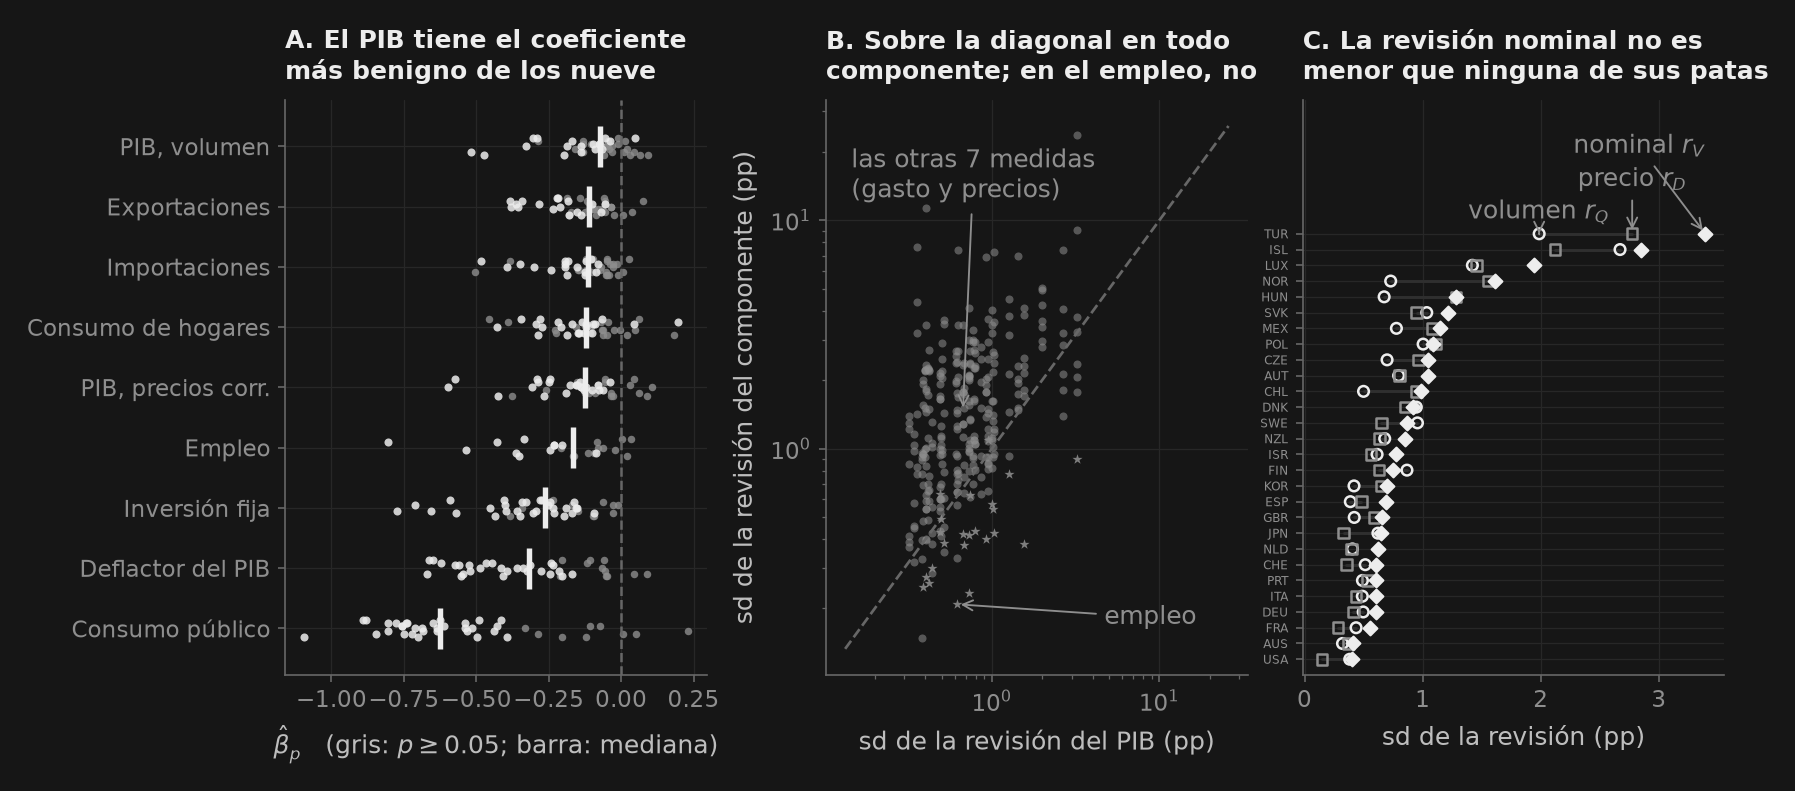

In [48]:
# 33 filas de mancuernas en C: ninguna talla de TAMANO da la altura, así que se
# fija a mano (el ancho de "3", más alto).
fig, (axA, axB, axC) = _nbstyle.figura(1, 3, figsize=(11.4, 5.0))
_orden = (okc.groupby("variable")["beta_on_preliminary"].median()
          .sort_values().index.tolist())

# A. todos los coeficientes (componente, área), componente a componente
for _i, _v in enumerate(_orden):
    _d = okc[okc["variable"] == _v]
    _jit = (np.arange(len(_d)) % 7 - 3) / 22.0
    _sg = (_d["p_beta_on_preliminary"] < 0.05).to_numpy()
    _bp = _d["beta_on_preliminary"].to_numpy()
    axA.scatter(_bp[~_sg], _i + _jit[~_sg], s=13, color=_nbstyle.NOTA, alpha=.8, lw=0)
    axA.scatter(_bp[_sg], _i + _jit[_sg], s=15, color=cols[0], alpha=.85, lw=0)
    axA.plot([np.median(_bp)] * 2, [_i - 0.34, _i + 0.34], color=_nbstyle.TINTA,
             lw=2.6, ls="-", solid_capstyle="butt")
axA.axvline(0, color=_nbstyle.SPINE, ls="--", lw=1.2)
axA.set_yticks(range(len(_orden)))
axA.set_yticklabels([ETQ[v] for v in _orden])
axA.set_xlabel("$\\hat{\\beta}_p$   (gris: $p \\geq 0.05$; barra: mediana)")
axA.set_title("A. El PIB tiene el coeficiente\nmás benigno de los nueve")

# B. la misma afirmación sin coeficientes: cuán grandes son las revisiones. El
# empleo lleva estrella y nombre; las otras medidas comparten marcador, porque
# lo que hay que ver es que todas quedan sobre la diagonal.
for _v in [v for v in _orden if v != "gdp_real"]:
    _j = sd_c[["gdp_real", _v]].dropna()
    _emp = _v == "employment"
    axB.scatter(_j["gdp_real"], _j[_v], s=26 if _emp else 15,
                alpha=0.9 if _emp else 0.55, marker="*" if _emp else "o", lw=0,
                color=cols[3] if _emp else _nbstyle.NOTA, zorder=3 if _emp else 2)
_hi = float(np.nanmax(sd_c.to_numpy())) * 1.1
_lo = float(np.nanmin(sd_c.to_numpy())) * 0.9
axB.plot([_lo, _hi], [_lo, _hi], color=_nbstyle.SPINE, ls="--", lw=1.3)
axB.set_xscale("log"); axB.set_yscale("log")
axB.set_xlabel("sd de la revisión del PIB (pp)")
axB.set_ylabel("sd de la revisión del componente (pp)")
axB.set_title("B. Sobre la diagonal en todo\ncomponente; en el empleo, no")
_e = sd_c[["gdp_real", "employment"]].dropna()
_k = _e["employment"].idxmin()
axB.annotate("empleo", xy=(float(_e.loc[_k, "gdp_real"]), float(_e.loc[_k, "employment"])),
             xytext=(0.66, 0.10), textcoords="axes fraction", ha="left", va="center",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
_otras = sd_c[[v for v in _orden if v not in ("gdp_real", "employment")]].stack()
_x_otras = sd_c["gdp_real"].reindex(_otras.index.get_level_values(0))
axB.annotate(f"las otras {len(_orden) - 2} medidas\n(gasto y precios)",
             xy=(float(_x_otras.median()), float(_otras.median())),
             xytext=(0.06, 0.92), textcoords="axes fraction", ha="left", va="top",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)

# C. la cifra nominal frente a las dos patas de las que está hecha. Si la
# oficina supiera primero el total nominal y solo discutiera el reparto, el
# punto relleno quedaría a la IZQUIERDA de los dos huecos en todas las filas.
# Queda a la derecha.
_s = vp.sort_values("sd r_V")
_y = np.arange(len(_s))
for _i, (_a, _r) in enumerate(_s.iterrows()):
    axC.plot([min(_r["sd r_Q"], _r["sd r_D"]), max(_r["sd r_Q"], _r["sd r_D"])],
             [_i, _i], color=_nbstyle.gris("0.82"), lw=1.4, ls="-", zorder=1)
axC.scatter(_s["sd r_Q"], _y, s=26, facecolors="none", edgecolors=cols[0], lw=1.2, zorder=2)
axC.scatter(_s["sd r_D"], _y, s=26, facecolors="none", edgecolors=_nbstyle.NOTA,
            lw=1.2, marker="s", zorder=2)
axC.scatter(_s["sd r_V"], _y, s=22, color=_nbstyle.TINTA, marker="D", zorder=3)
axC.set_yticks(_y); axC.set_yticklabels(_s.index, fontsize=5.8)
axC.set_ylim(-1, len(_s) + 7.5)
axC.set_xlabel("sd de la revisión (pp)")
axC.set_title("C. La revisión nominal no es\nmenor que ninguna de sus patas")
# Los tres marcadores se nombran sobre la fila más alta, la más separada, cada
# nombre en su propio renglón: en uno solo los tres se pisan.
_alta = _s.iloc[-1]
for _dy, _ha, _col, _txt in ((4, "center", "sd r_Q", "volumen $r_Q$"),
                             (20, "center", "sd r_D", "precio $r_D$"),
                             (36, "right", "sd r_V", "nominal $r_V$")):
    axC.annotate(_txt, xy=(float(_alta[_col]), len(_s) - 1), xytext=(0, _dy),
                 textcoords="offset points", ha=_ha, va="bottom", color=_nbstyle.NOTA,
                 arrowprops=_nbstyle.FLECHA)
plt.show()


#### Lectura del barrido de componentes

**El PIB es el más silencioso de aquello de lo que está hecho, y eso es un hecho sobre el promedio y no sobre el cuidado.** La mediana de $\hat{\beta}_p$ es $-0.072$ para el PIB en volumen —la más benigna de las nueve— frente a $-0.62$ del consumo público, $-0.32$ del deflactor, $-0.26$ de la inversión fija, $-0.17$ del empleo, $-0.13$ del PIB nominal, $-0.12$ del consumo de los hogares y $-0.11$ de cada pata del comercio. En la escala que no necesita ningún coeficiente, el orden entre los componentes del gasto es todavía más nítido: la revisión del PIB es menor que la de la inversión fija en **40 de 40** áreas, que la de las exportaciones en **41 de 41**, que la de las importaciones en **41 de 41**, que la del consumo público en 36 de 41, que la del PIB nominal en 37 de 41 y que la del consumo de los hogares en 33 de 41. El panel B es ese hecho. Así que los veinte años de literatura que contrastaron el agregado y encontraron un error de medición moderado estaban contrastando la afirmación *más suave* que admiten las cuentas.

**Y el mecanismo es comprobable, no retórico.** Un promedio es más silencioso que sus partes solo si los errores de las partes no se mueven juntos, y no lo hacen: la correlación mediana entre las revisiones de dos componentes del gasto es $+0.035$ sobre 366 muestras (área, par), $+0.019$ una vez apartado el único par correlacionado, y el 90% del resto cae dentro de $\pm 0.3$. La excepción son las exportaciones contra las importaciones, y es el par en el que la correlación *ayuda*: las exportaciones netas entran en el PIB como $s_X x - s_M m$, así que una covarianza positiva entre dos series aduaneras que llegan tarde se resta de la varianza del agregado en vez de sumarse. Las cuentas están protegidas dos veces, y ninguna de las dos protecciones está disponible para quien necesita un componente por separado.

**El consumo público es el extremo, y su veredicto es lo interesante.** $\hat{\beta}_p = -0.62$ en la mediana, significativamente negativo en **32 de 41** áreas, con una desviación típica de la revisión de $1.51$ pp frente a una serie preliminar cuya desviación típica es $1.46$ — la revisión es tan grande como lo revisado. Diecinueve de 41 áreas salen **`neither`**: se rechazan las dos nulas, así que la primera estimación no es ni una previsión eficiente ni la verdad más ruido. Eso es exactamente el aspecto de una *extrapolación*. El $G$ trimestral se construye con el presupuesto aprobado, informes de ejecución de caja e indicadores de nómina pública, y se sustituye después por la liquidación auditada de las administraciones públicas, que es anual — la primera cifra es una proyección que luego se cambia por una medición, y el cambio carga error y noticia a la vez. Quien identifique un multiplicador fiscal con innovaciones de $G$ en tiempo real está regresando sobre una serie cuya innovación es, en la mediana, más medición que política.

**Lo que se reescribe es el deflactor, no el volumen.** $\hat{\beta}_p = -0.32$ frente al $-0.072$ del PIB en volumen, significativo en 27 de 38 áreas, y 18 de 38 veredictos son `neither` — la mayor proporción de todas las medidas. La intuición de manual dice lo contrario: la oficina conoce pronto el producto nominal, por los registros de IVA y de nóminas, y solo discute después cómo repartirlo entre cantidad y precio. Esa historia hace una predicción, y el archivo la rechaza. Las revisiones de volumen y de precio *sí* están correlacionadas negativamente —en 29 de 34 áreas, mediana $-0.17$, así que algo de compensación deliberada hay— pero $\mathrm{Var}(r_V)$ se parte en volumen $0.61$, precio $0.60$ y dos veces la covarianza $-0.19$ en la mediana. Un quinto de compensación no es el reparto de un total conocido, y la consecuencia se ve directamente: **el PIB nominal se revisa más que el real en 30 de 34 áreas**, no menos. El panel C es la misma afirmación sin descomposición de varianzas: el rombo relleno queda a la derecha de los dos marcadores huecos.

**El empleo es la excepción, y es la que enseña por qué $\hat{\beta}_p$ hay que leerlo junto a una desviación típica.** Su revisión es *menor* que la del PIB en 21 de 23 áreas —$0.42$ pp frente a $0.67$— y su coeficiente es, aun así, peor: $-0.165$ contra $-0.072$. La razón es el denominador: el crecimiento del empleo tiene una desviación típica de $0.73$ pp frente a $1.76$ del PIB, así que un error absoluto pequeño sigue siendo casi toda la varianza de lo publicado. Es además la única medida del barrido que no es un componente del gasto —viene de la encuesta de fuerza de trabajo y de los registros de nóminas, no de las cuentas—, de modo que el argumento del promedio no la cubre, que es justo por lo que se comporta distinto. Once de las 42 áreas, Estados Unidos y Japón entre ellas, no publican ningún vintage de empleo.

**El sesgo también es peor en los componentes.** La revisión media mediana es de $+0.20$ pp por trimestre en importaciones, $+0.19$ en inversión fija y $+0.15$ en exportaciones, frente a $+0.075$ del PIB — tres cuartos de punto porcentual al año sobre la primera estimación de la inversión y del comercio, siempre en la misma dirección. La primera publicación de un auge de inversión lo subestima de manera sistemática.

**Nada de esto es un artefacto de comparaciones múltiples.** Sobre las 347 regresiones, el recuento sin ajustar de $p<0.05$ es 196 frente a las 17 que produciría la nula sola, y tras Benjamini–Hochberg con una tasa de falsos descubrimientos del 5% sobreviven 176 —174 negativas y 2 positivas—, de las que se esperan falsas a lo sumo 9. La unilateralidad que §4.1 argumentó para el PIB se sostiene en todas las cuentas.

**Lo que esto le cuesta al resto del curso.** §4.2, en la diapositiva siguiente, pregunta cuánto mueve la *edición* a $\sigma(c)/\sigma(y)$ manteniendo la muestra fija. Ahora está claro que sus dos ingredientes son más ruidosos en la primera publicación que el agregado —el consumo en 33 de 41 áreas—, así que parte de lo que encontrará es esto. No todo, y el ejercicio 22(d) es sobre la diferencia. Lo mismo vale para el desglose de duraderos de §2.4, para la volatilidad de la inversión con la que se calibran los modelos RBC y para todos los segundos momentos de §2: se calculan sobre componentes, y en los componentes es donde vive el error de medición.

### 4.2 Vintages, Metodología del SCN y la Volatilidad Relativa $\sigma(c)/\sigma(y)$

En macroeconomía internacional (Aguiar y Gopinath 2007; Mendoza 1991), un hecho estilizado canónico postula que las economías emergentes tienen $\sigma(c)/\sigma(y) > 1$ (exceso de volatilidad del consumo), mientras que las avanzadas exhiben suavizamiento con $\sigma(c)/\sigma(y) < 1$.

**¿Qué tan frágil es este hecho estilizado ante los vintages y las revisiones del Sistema de Cuentas Nacionales (SCN)?**

La manera de averiguarlo es mantener la *muestra* completamente quieta —los mismos 100 trimestres, 1995T1 a 2019T4— y recalcular $\sigma(c)/\sigma(y)$ en cada edición mensual de las cuentas que los contenga. Todo lo que se mueva es entonces la oficina estadística reescribiendo esos trimestres, y nada más. El archivo de §4.1 trae la pata del consumo para las **42 áreas**, y 36 de ellas tienen al menos una edición que cubre la ventana entera, así que la pregunta que antes se le hacía solo a México se convierte en un corte transversal: la respuesta es que el vintage mueve el cociente en una mediana de $0.040$ y hasta en $0.32$, pero cambia el *veredicto* —¿es el consumo más volátil que el producto?— solo en dos de las 36. Que es el hallazgo más útil, porque localiza la fragilidad exactamente donde vive: no en los países cuyo cociente se mueve mucho, sino en los países cuyo cociente se mueve *a través del uno*.

Cuatro canales institucionales modifican $\sigma(c)/\sigma(y)$:
1. **Capitalización de intangibles e I+D (SCN 2008 / NIPA 2013)**: Reclasificar I+D y software de consumo intermedio a inversión fija ($I$) eleva mecánicamente $\sigma(y)$ sin alterar $C$ privado, reduciendo $\sigma(c)/\sigma(y)$.
2. **Revisiones escalonadas (México Oct-2023 vs Ene-2024)**: Los institutos de estadística suelen actualizar el consumo meses antes que el PIB. En Oct-2023, $\sigma(c)/\sigma(y)$ saltó a $1.051$ (¡haciendo cierto el hecho estilizado durante 90 días!), pero al publicarse la revisión del PIB en Ene-2024, cayó de vuelta a $0.959$.
3. **Base fija de Laspeyres vs. Encadenamiento anual**: En base fija (como México, base 2018), los precios del año base envejecen y distorsionan las varianzas agregadas lejos del año base.
4. **Perímetro del consumo**: Consumo de hogares ($S1M$, $\sim 65\%$ del PIB) vs. Consumo final total ($S1$, incluyendo gasto de gobierno, $\sim 80\%$ del PIB). El consumo público apaga la volatilidad, bajando el ratio de $0.96$ a $0.85$.
- Es posible imputar partes del consumo y la inversión del gobierno al consumo de los hogares. En gran medida las inversiones de los gobierno que construyen infraestructura como hospitales o compran equipos producen servicios de consumo directo a los hogares

In [49]:
# La pata del consumo del mismo archivo: P3_S1M_Q, consumo final de los
# hogares, para las 42 áreas de referencia — el mismísimo fichero sobre el que
# el barrido de componentes de §4.1 acaba de correr el contraste de news/noise,
# leído aquí por segunda vez para otra pregunta. En el curso hay UN archivo de
# consumo y las dos secciones lo usan, porque dos descargas de la misma serie
# es como un proyecto acaba con dos versiones de los mismos números.
INSTANTANEA_CONS = DATA / "oecd_stes_comp_con_real.csv.gz"
VENTANA_FIJA = ("1995-01-01", "2019-10-01")     # 100 trimestres, fijos
N_FIJO = 100


def vintages_largo(ruta, variable):
    s = archivo(ruta)                   # §1.8: una lectura y un análisis de fechas
    return pd.DataFrame({
        "code": s["code"],
        "variable": variable,
        "date": s["date"],
        "edition": pd.to_datetime(s["edition"], format="%Y%m"),
        "value": s["value"]})


if not readable(INSTANTANEA_CONS, "file"):
    raise RuntimeError(
        f"No hay vintages de consumo en {INSTANTANEA_CONS}. Viaja en la carpeta "
        f"data_curso/ del curso, junto al archivo del PIB de §4.1.")
def _en_ventana(d):
    """La ventana fija, aplicada ANTES de cruzar los dos archivos.

    Recortar después de cruzar obliga a cruzar 318 trimestres para quedarse con
    100 y a repetir el recorte dentro de cada uno de los ~2.000 grupos. Hacerlo
    antes deja el cruce en un tercio y el bucle sin máscaras.
    """
    return d[(d["date"] >= VENTANA_FIJA[0]) & (d["date"] <= VENTANA_FIJA[1])]


par = (_en_ventana(vintages_largo(VINTAGE_SNAPSHOT, "gdp_real"))
       .merge(_en_ventana(vintages_largo(INSTANTANEA_CONS, "con_real")),
              on=["code", "date", "edition"], suffixes=("_y", "_c"))
       .dropna(subset=["value_y", "value_c"])
       .sort_values(["code", "edition", "date"]))

# El filtro HP sobre una muestra de longitud fija es un OPERADOR LINEAL fijo:
# el ciclo es C x con una C de 100x100 que solo depende de 100 y de lambda, no
# de los datos. Aquí hay que aplicarlo ~3.800 veces sobre la misma longitud, así
# que se construye una vez —columna j = ciclo del j-ésimo vector de la base— y
# después cada serie es un producto matriz-vector. La comprobación de abajo es
# lo que lo hace legítimo: si `hp_filter` dejara de ser lineal, o cambiara de
# lambda, el assert lo dice en vez de devolver números plausibles.
_C_HP = np.column_stack([hp_filter(np.eye(N_FIJO)[:, j])[0] for j in range(N_FIJO)])

# Un sigma(c)/sigma(y) por (área, edición), siempre sobre los MISMOS 100
# trimestres. Mantener fija la ventana es todo el diseño: cualquier movimiento
# que quede es la oficina estadística reescribiendo esos trimestres, no la
# muestra cambiando.
filas = []
for (code, ed), g in par.groupby(["code", "edition"], sort=False):
    if len(g) != N_FIJO:
        continue
    cy = _C_HP @ (100.0 * np.log(g["value_y"].to_numpy()))
    cc = _C_HP @ (100.0 * np.log(g["value_c"].to_numpy()))
    sy, sc = float(np.std(cy, ddof=1)), float(np.std(cc, ddof=1))
    filas.append({"code": code, "edition": ed,
                  "sigma_y": sy, "sigma_c": sc, "ratio": sc / sy})
vint_ratio = pd.DataFrame(filas)

# El operador reproduce `hp_filter` exactamente, no aproximadamente.
_g0 = next(g for _, g in par.groupby(["code", "edition"], sort=False)
           if len(g) == N_FIJO)
_x0 = 100.0 * np.log(_g0["value_y"].to_numpy())
assert float(np.abs(_C_HP @ _x0 - hp_filter(_x0)[0]).max()) < 1e-9

por_area = vint_ratio.groupby("code").agg(
    ediciones=("ratio", "size"), min=("ratio", "min"), max=("ratio", "max"),
    mediana=("ratio", "median"))
por_area["rango"] = por_area["max"] - por_area["min"]
por_area["cambia el veredicto"] = (por_area["min"] < 1.0) & (por_area["max"] > 1.0)

print(f"sigma(c)/sigma(y) sobre una ventana FIJA 1995T1-2019T4, recalculado en "
      f"cada edición\nque la contiene: {len(vint_ratio):,} estimaciones en "
      f"{vint_ratio['code'].nunique()} áreas, "
      f"{int(por_area['ediciones'].median())} ediciones cada una.\n")
print(por_area.sort_values("rango", ascending=False).round(3).to_string())

cambian = por_area.index[por_area["cambia el veredicto"]]
print(f"\nEl hecho estilizado —¿es el consumo más volátil que el producto?— "
      f"cambia de RESPUESTA\nsegún la fecha de descarga en {len(cambian)} de "
      f"{len(por_area)} áreas: {', '.join(cambian)}.")
print(f"  rango mediano dentro de cada área {por_area['rango'].median():.3f}; "
      f"el mayor {por_area['rango'].max():.3f} ({por_area['rango'].idxmax()}), "
      f"el menor {por_area['rango'].min():.3f} ({por_area['rango'].idxmin()}).")
print(f"  México va de {por_area.loc['MEX', 'min']:.3f} a "
      f"{por_area.loc['MEX', 'max']:.3f} — el episodio de oct-2023 a ene-2024 de "
      f"arriba.")

# Riesgo de vintage y cercanía al umbral son cosas distintas, y el veredicto
# solo cambia donde coinciden: el cociente de Luxemburgo se mueve seis veces más
# que el mexicano y nunca cruza nada, porque vive en 0.79.
_lejos = por_area[(~por_area["cambia el veredicto"]) & (por_area["rango"] > 0.1)]
print(f"\n  No es lo mismo que fragilidad: {len(_lejos)} áreas se mueven más de "
      f"0.10 entre ediciones\n  sin cambiar nunca de lado "
      f"({', '.join(f'{c} ~{por_area.loc[c, chr(109)+chr(101)+chr(100)+chr(105)+chr(97)+chr(110)+chr(97)]:.2f}' for c in _lejos.index)}).\n"
      f"  Un hecho es frágil donde el movimiento y el umbral se encuentran.")

assert len(por_area) > 20
assert por_area["cambia el veredicto"].any()
assert (por_area["ediciones"] > 30).all()

# Los archivos ya han hecho su trabajo. Los dos marcos largos y su cruce son
# unos cuantos cientos de MB que nada de lo que sigue lee, y conviene soltarlos
# para que lo que viene los reutilice en vez de pedir más. Reejecutar esta
# celda los reconstruye: `archivo` vuelve a leer del disco cuando su caché está
# vacía.
del par, _C_HP, _g0, _x0
_ARCHIVOS.clear()

sigma(c)/sigma(y) sobre una ventana FIJA 1995T1-2019T4, recalculado en cada edición
que la contiene: 2,681 estimaciones en 36 áreas, 78 ediciones cada una.

      ediciones    min    max  mediana  rango  cambia el veredicto
code                                                              
LUX          77  0.474  0.790    0.786  0.316                False
POL          78  1.074  1.248    1.235  0.174                False
ISL          78  1.295  1.442    1.403  0.147                False
GBR          78  0.833  0.971    0.924  0.138                False
NOR          79  0.938  1.075    0.975  0.137                 True
GRC          78  1.080  1.212    1.098  0.132                False
IRL          78  0.503  0.611    0.573  0.109                False
AUT          71  0.561  0.654    0.617  0.093                False
MEX          75  0.959  1.051    0.965  0.093                 True
AUS          78  1.354  1.443    1.429  0.089                False
CHE          77  0.362  0.445    0.368 

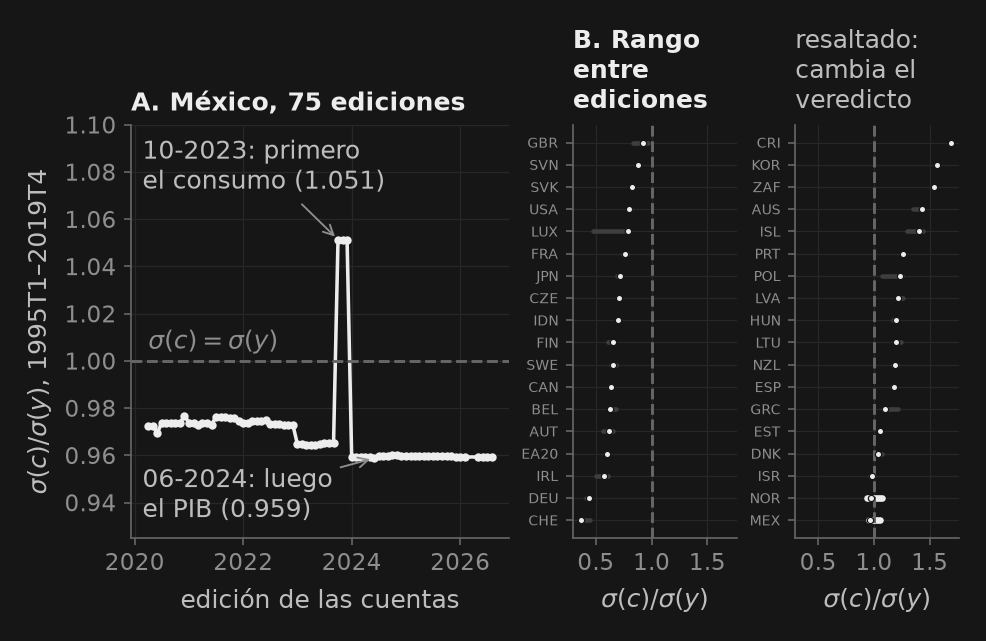

In [50]:
# Tres paneles: la serie de México y, a su derecha, las 36 áreas en dos columnas
# (en una sola no caben ni en el cuaderno ni en la ranura).
fig, (ax1, axb1, axb2) = _nbstyle.figura(
    1, 3, figsize=plt.rcParams["figure.figsize"],
    gridspec_kw={"width_ratios": [2.3, 1, 1]})

mex = vint_ratio[vint_ratio["code"] == "MEX"].sort_values("edition")
ax1.plot(mex["edition"], mex["ratio"], color=_nbstyle.TINTA, lw=1.7, ls="-", marker="o", ms=3.0)
ax1.axhline(1.0, color=_nbstyle.SPINE, ls="--", lw=1.4)
# Aire arriba y abajo: las dos notas caben enteras fuera de la serie.
ax1.set_ylim(0.925, 1.100)
_anos = list(range(2020, 2027, 2))
ax1.set_xticks(pd.to_datetime([f"{y}-01-01" for y in _anos]), [str(y) for y in _anos])
ax1.annotate("$\\sigma(c)=\\sigma(y)$", xy=(mex["edition"].min(), 1.0), xytext=(0, 3),
             textcoords="offset points", ha="left", va="bottom", color=_nbstyle.NOTA)
_alto = mex.loc[mex["ratio"].idxmax()]
_luego = mex[mex["edition"] > _alto["edition"]]
ax1.annotate(f"{_alto['edition']:%m-%Y}: primero\nel consumo (${_alto['ratio']:.3f}$)",
             xy=(_alto["edition"], _alto["ratio"]), xytext=(0.03, 0.97),
             textcoords="axes fraction", ha="left", va="top", color=_nbstyle.TEXTO,
             arrowprops=_nbstyle.FLECHA)
if len(_luego):
    _despues = _luego.iloc[(_luego["ratio"] - _luego["ratio"].min()).abs().argmin()]
    ax1.annotate(f"{_despues['edition']:%m-%Y}: luego\nel PIB (${_despues['ratio']:.3f}$)",
                 xy=(_despues["edition"], _despues["ratio"]), xytext=(0.03, 0.03),
                 textcoords="axes fraction", ha="left", va="bottom", color=_nbstyle.TEXTO,
                 arrowprops=_nbstyle.FLECHA)
ax1.set_ylabel("$\\sigma(c)/\\sigma(y)$, 1995T1–2019T4")
ax1.set_xlabel("edición de las cuentas")
# Los rótulos de panel van como anotaciones en fracción de ejes y no como
# títulos: la lámina suelta los títulos, y con ellos se irían la única mención
# de México y la única clave de la barra resaltada.
ax1.annotate(f"A. México, {len(mex)} ediciones", xy=(0.0, 1.02),
             xycoords="axes fraction", ha="left", va="bottom",
             fontweight="bold", color=_nbstyle.TINTA)

o = por_area.sort_values("mediana")
FILAS = -(-len(o) // 2)
_ancho = float(o["max"].max() - o["min"].min())
for j, ax in enumerate((axb1, axb2)):
    tramo = o.iloc[j * FILAS:(j + 1) * FILAS]
    for i, (code, r) in enumerate(tramo.iterrows()):
        ax.plot([r["min"], r["max"]], [i, i],
                color=cols[0] if r["cambia el veredicto"] else _nbstyle.gris("0.72"),
                lw=3.2 if r["cambia el veredicto"] else 2.2, ls="-", solid_capstyle="round",
                zorder=2)
    ax.scatter(tramo["mediana"], np.arange(len(tramo)), s=9, color=_nbstyle.TINTA,
               edgecolors=_nbstyle.FONDO, linewidths=0.6, zorder=3)
    ax.axvline(1.0, color=_nbstyle.SPINE, ls="--", lw=1.4)
    ax.set_yticks(np.arange(len(tramo)))
    ax.set_yticklabels(tramo.index, fontsize=6.5)
    ax.set_ylim(-0.8, FILAS - 0.2)
    ax.set_xlim(float(o["min"].min()) - 0.05 * _ancho, float(o["max"].max()) + 0.05 * _ancho)
    ax.set_xlabel("$\\sigma(c)/\\sigma(y)$")
# El rótulo de B y su clave van uno sobre cada columna: en una sola no caben
# (cada columna mide poco más de una pulgada y el texto la desbordaría).
axb1.annotate("B. Rango\nentre\nediciones", xy=(0.0, 1.02), xycoords="axes fraction",
              ha="left", va="bottom", fontweight="bold", color=_nbstyle.TINTA)
axb2.annotate("resaltado:\ncambia el\nveredicto", xy=(0.0, 1.02),
              xycoords="axes fraction", ha="left", va="bottom",
              color=_nbstyle.TEXTO)
plt.show()


### 4.3 Determinantes Estructurales: Apertura Comercial, el Margen Laboral Desprotegido y Profundidad Financiera

¿Qué características estructurales explican las diferencias sistemáticas en $\sigma(c)/\sigma(y)$ entre países?

La macroeconomía de economía abierta postula tres mecanismos empíricos:
1. **Apertura comercial ($(X+M)/Y$)**: las economías abiertas acceden a mercados internacionales de bienes y capitales para diversificar choques domésticos ($\mathrm{Corr} < 0$), aunque una alta concentración exportadora en materias primas las expone a severa volatilidad en los términos de intercambio.
2. **Empleo fuera de una relación laboral asalariada protegida**: sin seguro de desempleo ni acceso al crédito formal. Con restricciones de liquidez (*hand-to-mouth*), el consumo de estos hogares se desploma al unísono con su ingreso durante una recesión, elevando $\sigma(c)/\sigma(y)$ ($\mathrm{Corr} > 0$).
3. **Profundidad financiera (crédito privado / PIB)**: un sistema financiero desarrollado permite a los hogares endeudarse y refinanciarse durante una contracción, suavizando intertemporalmente el consumo ($\mathrm{Corr} < 0$).

**El debate teórico estructural: Choques a la tendencia vs. Fricciones financieras y paradas repentinas (*Sudden Stops*).**  
¿Por qué el consumo es tan volátil respecto al producto ($\sigma(c)/\sigma(y) \approx 1.0$ o superior) y por qué la balanza comercial es marcadamente contracíclica ($\mathrm{corr}(nx/y, y) < 0$) en economías emergentes, mientras que las economías avanzadas suavizan el consumo ($\sigma(c)/\sigma(y) < 1$) y exhiben balanzas comerciales procíclicas o acíclicas?

Dos paradigmas teóricos estructuran el análisis moderno de economías abiertas:
1. **La hipótesis de «El ciclo es la tendencia» (Aguiar y Gopinath 2007)**:  
   En las economías emergentes, las fluctuaciones del ciclo económico están dominadas por choques estocásticos permanentes a la tasa de crecimiento tendencial ($\Gamma_t = e^{g + z_t}$) antes que por choques transitorios y estacionarios alrededor de una tendencia determinista. Bajo la Hipótesis del Ingreso Permanente (HIP), cuando una economía emergente experimenta una aceleración tendencial, el ingreso permanente aumenta por *más* que el producto corriente. Anticipando un futuro de mayor riqueza, los hogares consumen agresivamente en el presente, expandiendo el consumo más que proporcionalmente con el producto ($\sigma(c)/\sigma(y) > 1$). Para financiar este auge de absorción, la economía recurre al endeudamiento externo, generando profundos déficits comerciales durante las expansiones. Cuando el crecimiento tendencial se desploma, el ingreso permanente cae drásticamente, el consumo se contrae violentamente y la balanza comercial gira abruptamente hacia el superávit.
2. **Fricciones financieras, diferenciales de riesgo soberano y paradas repentinas (Neumeyer y Perri 2005; García-Cicco, Pancrazi y Uribe 2010)**:  
   Analizando series históricas de más de un siglo (Argentina y Canadá, 1900–2005), García-Cicco et al. (2010) demuestran que los choques de tendencia por sí solos no logran reproducir la persistencia empírica de la balanza comercial ni la dinámica de las tasas de interés reales. El mecanismo de transmisión primordial radica en las **fricciones de crédito, los requerimientos de capital de trabajo y las primas de riesgo país contracíclicas** ($R_t = R^* + s_t$).  
   En las economías emergentes, el diferencial soberano $s_t$ se dispara durante las recesiones. En una **parada repentina (*Sudden Stop*)** (Calvo 1998; Mendoza 2010), la liquidez internacional se congela y las restricciones de endeudamiento externo se vuelven vinculantes ($B_{t+1}^* \ge -\kappa Y_t$). Los agentes domésticos no pueden endeudarse para amortiguar el choque porque el crédito externo se clausura. Racionados financieramente, hogares y empresas se ven obligados a rematar activos, colapsar el consumo y comprimir de emergencia las importaciones. El superávit comercial resultante no es una decisión voluntaria de ahorro, sino el síntoma de una restricción financiera extrema. En cambio, los exportadores avanzados de materias primas (p. ej. Canadá) mantienen acceso a los mercados internacionales de crédito durante las recesiones, haciendo posible el suavizamiento del consumo y balanzas comerciales procíclicas.

**El segundo mecanismo es un solo mecanismo, y los datos le dan dos nombres.** La **tasa de empleo informal** de OIT cuenta a todo el que tiene un empleo informal —asalariados sin protección social *y* trabajadores por cuenta propia en unidades no registradas. La **tasa de trabajo por cuenta propia** de las cuentas cuenta a todo el que no es asalariado, esté o no registrado. Son dos conjuntos que se solapan, no dos variables: el vendedor ambulante no registrado está en los dos; el asalariado que cobra en negro, solo en el primero; el consultor constituido en sociedad, solo en el segundo.

Así que no pueden sumarse sin más: eso cuenta dos veces la intersección, en 28 puntos del empleo total en México y 13 en el Reino Unido. De lo que habla el mecanismo es de la **unión**: un hogar está expuesto si trabaja por cuenta propia *o* en empleo informal. La unión necesita la intersección, y la intersección es exactamente lo que la OIT publica al lado de la tasa titular —la misma tasa de informalidad, desglosada por **situación en el empleo**. Con $s$ la cuota de cuenta propia y $f_{\text{ees}}, f_{\text{slf}}$ las tasas de informalidad *dentro* de los asalariados y dentro de los que trabajan por cuenta propia,

$$\underbrace{F}_{\text{informal}} \;=\; \underbrace{s\,f_{\text{slf}}}_{\text{cuenta propia informal}} \;+\; \underbrace{(1-s)\,f_{\text{ees}}}_{\text{asalariado informal}}, \qquad\qquad \underbrace{U}_{\text{expuesto}} \;=\; \underbrace{s}_{\text{cuenta propia}} \;+\; \underbrace{(1-s)\,f_{\text{ees}}}_{\text{asalariado informal}} .$$

$U$ es la variable que predice el mecanismo, es una cuota genuina del empleo, y $U \le F + s$ con la diferencia siendo precisamente el doble cómputo. La primera identidad no hace falta para construir $U$: es el **control**: ensamblado a partir de dos bases de datos que nunca hablaron entre sí, $s\,f_{\text{slf}} + (1-s)f_{\text{ees}}$ tiene que reproducir la tasa de informalidad que publica la OIT, y donde no lo hace, las dos están contando poblaciones distintas.

**Ni un solo número de los gráficos de abajo está escrito aquí.** Proceden de cuatro bases de datos, y de dónde viene cada uno importa tanto como el mecanismo que ilustra:

| Variable | Fuente | Qué es, exactamente |
|---|---|---|
| $\sigma(c)/\sigma(y)$ | el `panel` de §1 | desviaciones estándar de los ciclos HP de $\log$ PIB y $\log$ consumo de hogares, **en volumen** |
| Apertura | el `panel` de §1 | $(X+M)/Y$ **a precios corrientes**, que §2.3 demostró que es inmune al tipo de cambio |
| Informalidad $F$ | **OIT**, `EMP_NIFL_RT` | tasa de empleo informal, ambos sexos, 15+, último año disponible |
| $f_{\text{ees}}$, $f_{\text{slf}}$ | **OIT**, misma tasa por `STE` | el mismo indicador desglosado por situación en el empleo —asalariados, cuenta propia |
| Cuenta propia $s$ | el `panel` de §1 | `emp_selfemp / emp`, el bloque de trabajo que §5 usa a fondo |
| Crédito privado | **Banco Mundial**, `FS.AST.PRVT.GD.ZS` | crédito interno al sector privado, % del PIB, media 1995–2019 |

**Por qué la unión y no ninguna de las dos mitades.** La tasa de la OIT es el *concepto* correcto y una *serie* mal comparada: cada oficina estadística nacional operativiza «informal» a su manera, y por eso el Reino Unido aparece con 19,8% frente al 3,8% de España —lo contrario de lo que cualquiera esperaría. El desglose por situación muestra de qué está hecho ese desacuerdo: los estadísticos británicos clasifican como informal al 98% del empleo por cuenta propia del país; los españoles, al 14%. El trabajo por cuenta propia, por su parte, se mide igual en todas partes y sale de las cuentas que acabamos de construir, pero no dice nada de los asalariados sin protección —que es casi todo lo que significa el margen en Rusia o Sudáfrica. La unión es la única de las tres que significa lo mismo en los 35 países *y* cubre las dos mitades del margen.

**La ventana es 1995T1–2019T4**, la misma que §4.2 y por la misma razón: 2020 introduce en $\sigma(c)$ el cierre administrativo de los servicios de contacto, que no es un ciclo económico y que golpeó a los países en proporción a su turismo más que a su estructura financiera.


In [51]:
import json

VENTANA = ("1995-01-01", "2019-10-01")   # la misma que §4.2, y por lo mismo


def hechos_del_panel(p):
    """σ(c)/σ(y), apertura y cuenta propia — los tres, del panel de §1."""
    filas = []
    for code, g in p.groupby(level="code"):
        g = g.droplevel("code").loc[VENTANA[0]:VENTANA[1]]
        vol = g[["gdp_real", "cons_hh_real"]].dropna()
        if len(vol) < 60:                      # menos de 15 años: no entra
            continue
        cy, _ = hp_filter(100.0 * np.log(vol["gdp_real"]))
        cc, _ = hp_filter(100.0 * np.log(vol["cons_hh_real"]))
        sy, sc = float(np.std(cy, ddof=1)), float(np.std(cc, ddof=1))
        com = g[["exports", "imports", "gdp"]].dropna()
        cp = ((g["emp_selfemp"] / g["emp"]).dropna()
              if {"emp", "emp_selfemp"}.issubset(g.columns) else pd.Series(dtype=float))
        filas.append({
            "code": code, "n_trim": len(vol), "sigma_y": sy, "sigma_c": sc,
            "ratio_c_y": sc / sy,
            "apertura": (100.0 * float(((com["exports"] + com["imports"])
                                        / com["gdp"]).mean()) if len(com) else np.nan),
            "cuenta_propia": 100.0 * float(cp.mean()) if len(cp) else np.nan})
    return pd.DataFrame(filas).set_index("code").sort_index()


def bajar_informalidad():
    """ILOSTAT vía SDMX: tasa de empleo informal, ambos sexos, 15+."""
    raw = sdmx_get(provider="ilostat", dataflow="ILO,DF_EMP_NIFL_SEX_AGE_RT,1.0",
                   key=".A.EMP_NIFL_RT.SEX_T.AGE_YTHADULT_YGE15")
    return (raw.rename(columns={"REF_AREA": "code", "TIME_PERIOD": "year",
                                "OBS_VALUE": "informal_rate"})
               [["code", "year", "informal_rate"]].dropna())


def bajar_informalidad_por_situacion():
    """ILOSTAT vía SDMX: la misma tasa, desglosada por situación en el empleo.

    `STE_AGGREGATE_EES` es la tasa de informalidad *entre los asalariados* y
    `STE_AGGREGATE_SLF` la tasa *entre quienes trabajan por cuenta propia* —
    los dos números que necesita la unión, y los dos que la tasa agregada
    promedia hasta hacerlos desaparecer.
    """
    raw = sdmx_get(provider="ilostat", dataflow="ILO,DF_EMP_NIFL_SEX_STE_RT,1.0",
                   key=".A.EMP_NIFL_RT.SEX_T.")
    d = (raw.rename(columns={"REF_AREA": "code", "TIME_PERIOD": "year",
                             "STE": "status", "OBS_VALUE": "informal_rate"})
            [["code", "year", "status", "informal_rate"]].dropna())
    d = d[d["status"].isin(["STE_AGGREGATE_EES", "STE_AGGREGATE_SLF",
                            "STE_AGGREGATE_TOTAL"])].copy()
    d["status"] = d["status"].str.replace("STE_AGGREGATE_", "", regex=False)
    return d.reset_index(drop=True)


def bajar_credito():
    """Banco Mundial (API pública, sin llave): crédito privado, % del PIB."""
    from puremacro._http import safe_get_bytes
    url = ("https://api.worldbank.org/v2/country/all/indicator/"
           "FS.AST.PRVT.GD.ZS?format=json&per_page=20000&date=1990:2025")
    filas = json.loads(safe_get_bytes(url, timeout=120).decode("utf-8"))[1]
    return pd.DataFrame([{"code": r["countryiso3code"], "year": int(r["date"]),
                          "credit_gdp": r["value"]} for r in filas
                         if r["value"] is not None
                         and len(r["countryiso3code"] or "") == 3])


# `de_la_fuente` —fuente en vivo o instantánea congelada, según VIVO— quedó
# definida en §3.2, que fue la primera sección que la necesitó. Estas tres
# fuentes son el segundo uso, no una segunda copia.

est = hechos_del_panel(panel)
ilo, origen_ilo = de_la_fuente("ilo_informalidad.csv", bajar_informalidad,
                               "informalidad")
ste, origen_ste = de_la_fuente("ilo_informalidad_por_situacion.csv",
                               bajar_informalidad_por_situacion,
                               "informalidad por situación en el empleo")
wb, origen_wb = de_la_fuente("wb_credito_privado.csv", bajar_credito,
                             "crédito privado")

# La informalidad se publica con huecos: tomamos el último año disponible desde
# 2010, no un promedio, porque un promedio sobre años distintos país a país no
# es comparable. El crédito sí se promedia, sobre la misma ventana del ciclo.
anio_ilo = pd.to_numeric(ilo["year"], errors="coerce")
est["informalidad"] = (ilo[anio_ilo.between(2010, 2030)].sort_values("year")
                          .groupby("code")["informal_rate"].last())
anio_wb = pd.to_numeric(wb["year"], errors="coerce")
est["credito"] = (wb[anio_wb.between(1995, 2019)]
                    .groupby("code")["credit_gdp"].mean())

# La unión, celda por celda. La OIT da la informalidad *dentro* de cada
# situación, así que multiplicar por la proporción que esa situación
# representa del empleo pone las dos mitades sobre una misma base —el empleo
# total— y nada se cuenta dos veces.
anio_ste = pd.to_numeric(ste["year"], errors="coerce")
f = (ste[anio_ste.between(2010, 2030)].sort_values("year")
        .groupby(["code", "status"])["informal_rate"].last().unstack())
est["cp_informal"] = est["cuenta_propia"] * f["SLF"] / 100.0        # la intersección
est["asal_informal"] = (100.0 - est["cuenta_propia"]) * f["EES"] / 100.0
est["desprotegido"] = est["cuenta_propia"] + est["asal_informal"]   # la unión U
est["informalidad_implicita"] = est["cp_informal"] + est["asal_informal"]

u = est.dropna(subset=["desprotegido"])
control = (u["informalidad_implicita"] - u["informalidad"]).abs()
print(f"Informalidad: {origen_ilo}. Por situación: {origen_ste}. "
      f"Crédito privado: {origen_wb}.")
print(f"\nLa unión, {len(u)} países. Reconstruir la tasa agregada de ILOSTAT a "
      f"partir de su propio desglose por situación y de la proporción de cuenta "
      f"propia de las cuentas nacionales falla por una mediana de "
      f"{control.median():.2f} pp (el peor, {control.idxmax()}, "
      f"{control.max():.1f} pp) — dos bases de datos, una población.")
print(f"Sumar las dos tasas en lugar de tomar su unión duplicaría a los "
      f"trabajadores por cuenta propia informales: una mediana de "
      f"{u['cp_informal'].median():.1f} pp del empleo, {u['cp_informal'].max():.1f} "
      f"pp en {u['cp_informal'].idxmax()} y {u.loc['GBR', 'cp_informal']:.1f} pp "
      f"en el Reino Unido.")
print(u[["informalidad", "cuenta_propia", "cp_informal", "asal_informal",
         "desprotegido"]].round(1).sort_values("desprotegido").to_string())

REGRESORES = {
    "apertura":      ("Apertura comercial $(X+M)/Y$, %", "OCDE QNA (§1)", "A"),
    "informalidad":  ("Tasa de empleo informal, %", "ILOSTAT", "B"),
    "credito":       ("Crédito privado / PIB, %", "Banco Mundial", "C"),
    "desprotegido":  ("Cuenta propia o asalariado informal, % del empleo",
                     "OCDE QNA + ILOSTAT", "D"),
}


def paquete_corr(d, x, y="ratio_c_y"):
    """Pearson, Spearman y el t de la correlación. Spearman porque Luxemburgo
    tiene 288% de apertura y no queremos que decida él solo la pendiente."""
    s = d[[y, x]].dropna()
    n = len(s)
    r = float(s[y].corr(s[x]))
    return {"variable": x, "n": n, "pearson": r,
            "spearman": float(s[y].rank().corr(s[x].rank())),
            "t": r * np.sqrt((n - 2) / max(1e-12, 1.0 - r ** 2))}


# La unión va al gráfico; sus dos mitades y las dos tasas publicadas se quedan
# en la tabla, porque la comparación entre ellas es la mitad de la lección.
# `misma` puntúa a todas sobre los 35 países en que todas existen: una variable
# medida sobre otro conjunto de países no es una hipótesis rival.
EXTRA = ["cuenta_propia", "cp_informal", "asal_informal"]
corr = pd.DataFrame([paquete_corr(est, x) for x in list(REGRESORES) + EXTRA]
                    ).set_index("variable")
misma = pd.DataFrame([paquete_corr(est.loc[u.index], x)
                      for x in list(REGRESORES) + EXTRA]).set_index("variable")

print(f"\nσ(c)/σ(y) sobre {VENTANA[0][:7]}–{VENTANA[1][:7]}, {len(est)} países: "
      f"mediana {est['ratio_c_y'].median():.2f}, "
      f"{int((est['ratio_c_y'] > 1).sum())} por encima de 1 "
      f"(mín. {est['ratio_c_y'].idxmin()} {est['ratio_c_y'].min():.2f}, "
      f"máx. {est['ratio_c_y'].idxmax()} {est['ratio_c_y'].max():.2f}).")
print(f"EE. UU. {est.loc['USA', 'ratio_c_y']:.2f} y México "
      f"{est.loc['MEX', 'ratio_c_y']:.3f} — el mismo {est.loc['MEX', 'ratio_c_y']:.3f} "
      f"de la edición de ene-2024 de §4.2, ahora calculado aquí.")
print("\nCorrelación con σ(c)/σ(y), variable por variable:")
print(corr.round(3).to_string())
print(f"\nY sobre los {len(u)} países que tienen todas:")
print(misma.round(3).to_string())
print(f"\nSobre su propia muestra la informalidad lee "
      f"r={corr.loc['informalidad', 'pearson']:+.2f} "
      f"(t={corr.loc['informalidad', 't']:+.1f}); sobre la muestra común, "
      f"r={misma.loc['informalidad', 'pearson']:+.2f} "
      f"(t={misma.loc['informalidad', 't']:+.1f}). Los seis países que se caen "
      f"—ARG, BRA, COL, IDN, IND, TUR— son los más informales del archivo y no "
      f"tienen línea de cuenta propia en las cuentas de la OCDE, así que casi "
      f"toda la diferencia entre las dos variables laborales es de muestra, no "
      f"de medición.")

# Los mecanismos citados salen con el signo que predicen; solo el margen
# laboral tiene un t que lo distinga de cero, y lo consigue medido como unión
# —mejor que cualquiera de sus mitades, sobre los mismos países.
assert corr.loc["apertura", "pearson"] < 0
assert corr.loc["credito", "pearson"] < 0
assert corr.loc["desprotegido", "pearson"] > 0
assert misma.loc["desprotegido", "pearson"] > misma.loc["cuenta_propia", "pearson"]
assert misma.loc["desprotegido", "pearson"] > misma.loc["informalidad", "pearson"]
# La unión contiene a las dos mitades y es menor que su suma: la diferencia es
# la duplicación, y nunca es negativa.
assert (u["desprotegido"]
        >= u[["cuenta_propia", "informalidad_implicita"]].max(axis=1) - 1e-9).all()
assert (u["desprotegido"]
        <= u["cuenta_propia"] + u["informalidad_implicita"] + 1e-9).all()
# Dos bases de datos, una población: la tasa reconstruida sigue a la publicada.
assert control.median() < 1.0
assert est["ratio_c_y"].notna().sum() >= 40

Informalidad: instantánea del curso (MAV_QNA_VIVO=1 para descargar). Por situación: instantánea del curso (MAV_QNA_VIVO=1 para descargar). Crédito privado: instantánea del curso (MAV_QNA_VIVO=1 para descargar).

La unión, 35 países. Reconstruir la tasa agregada de ILOSTAT a partir de su propio desglose por situación y de la proporción de cuenta propia de las cuentas nacionales falla por una mediana de 0.30 pp (el peor, HRV, 3.5 pp) — dos bases de datos, una población.
Sumar las dos tasas en lugar de tomar su unión duplicaría a los trabajadores por cuenta propia informales: una mediana de 2.2 pp del empleo, 28.0 pp en MEX y 13.5 pp en el Reino Unido.
      informalidad  cuenta_propia  cp_informal  asal_informal  desprotegido
code                                                                       
ISL            2.0            6.8          0.5            0.9           7.7
DNK            2.2            7.0          0.6            1.6           8.6
NOR            3.2            6.5     


Regresión de razón consumo-producto (HC1) con Apertura comercial $(X+M)/Y$, % (OCDE QNA (§1)):
OLS regression (HC1, z inference)
  n = 47, df_resid = 45, R^2 = 0.0433, adj R^2 = 0.0220
  llf = -19.2490, AIC = 42.4980, BIC = 46.1983
                coef     std err        z    P>|t|      [0.025      0.975]
const         1.1578      0.0774   14.950    0.000      1.0060      1.3096
apertura     -0.0017      0.0007   -2.235    0.025     -0.0031     -0.0002

Regresión de razón consumo-producto (HC1) con Tasa de empleo informal, % (ILOSTAT):
OLS regression (HC1, z inference)
  n = 41, df_resid = 39, R^2 = 0.0011, adj R^2 = -0.0245
  llf = -18.8373, AIC = 41.6745, BIC = 45.1017
                    coef     std err        z    P>|t|      [0.025      0.975]
const             1.0211      0.0838   12.178    0.000      0.8567      1.1854
informalidad      0.0006      0.0022    0.272    0.786     -0.0037      0.0048

Regresión de razón consumo-producto (HC1) con Crédito privado / PIB, % (Banco Mun

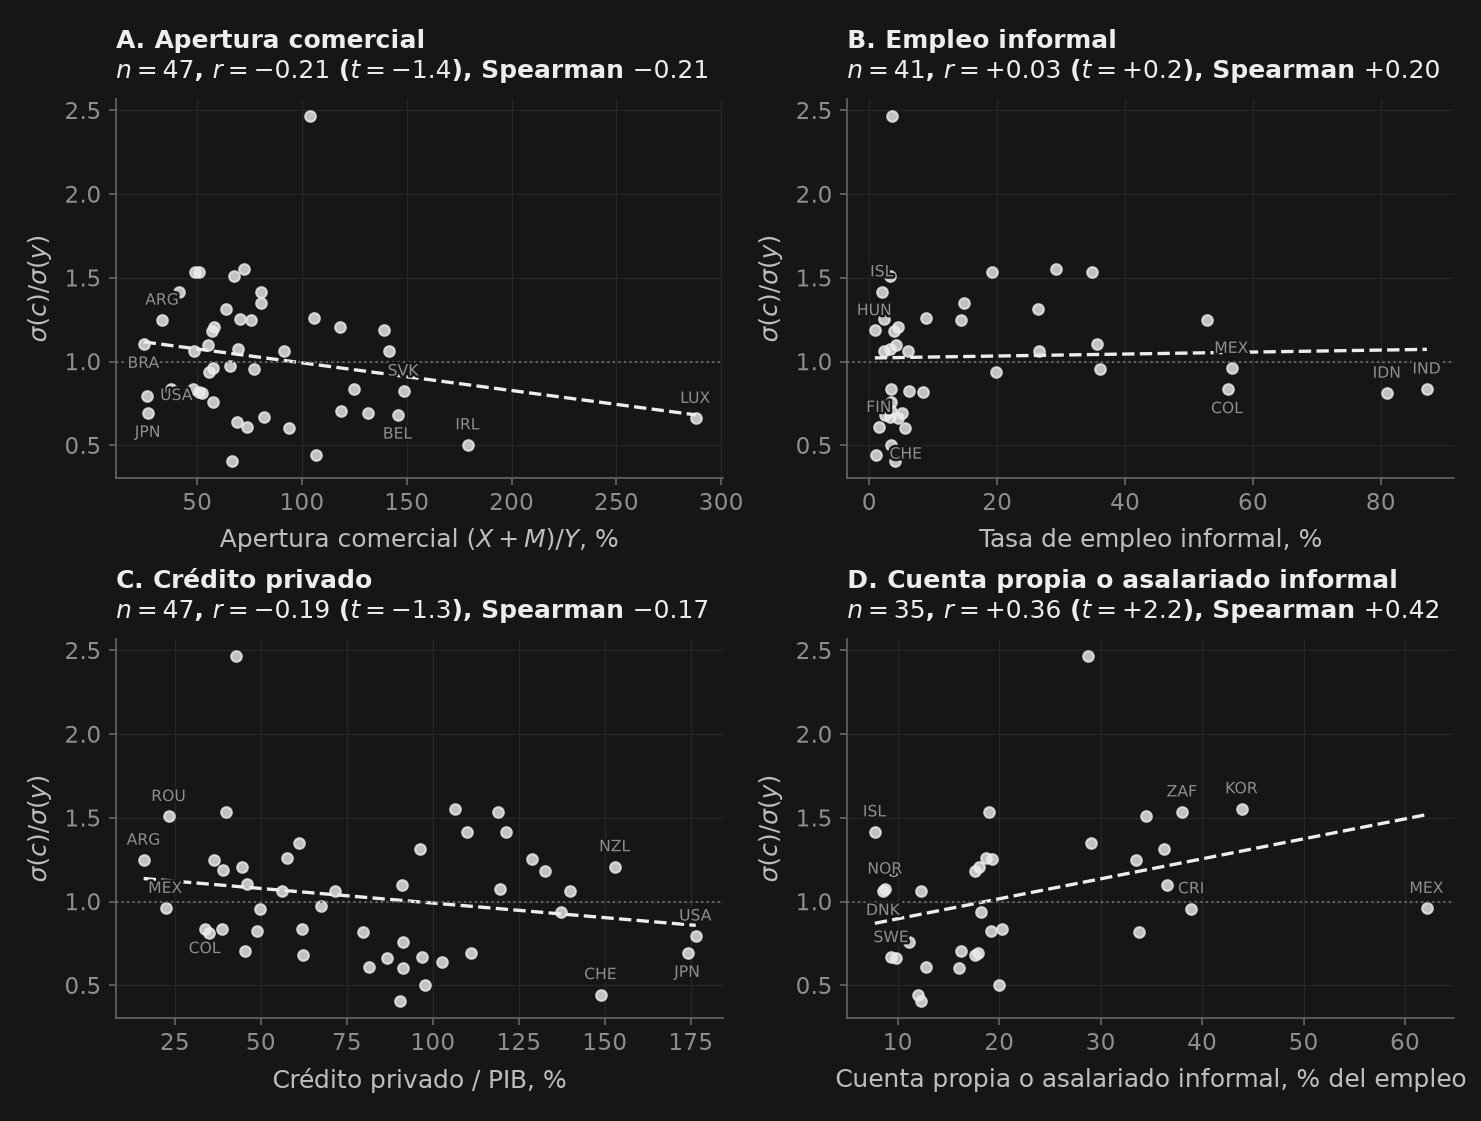

In [52]:
TITULOS = {"apertura": "Apertura comercial", "informalidad": "Empleo informal",
           "credito": "Crédito privado", "desprotegido": "Cuenta propia o asalariado informal"}
fig, axes = _nbstyle.figura(2, 2)
paneles = []
for ax, (x, (etiq, fuente, letra)) in zip(axes.ravel(), REGRESORES.items()):
    s = est[["ratio_c_y", x]].dropna()
    ax.scatter(s[x], s["ratio_c_y"], color=_nbstyle.TINTA, alpha=0.8, s=26)
    res_s = ols(s["ratio_c_y"], add_constant(s[x]), cov_type="HC1")
    print(f"\nRegresión de razón consumo-producto (HC1) con {etiq} ({fuente}):")
    print(res_s.summary())
    a, b = float(res_s.params.iloc[0]), float(res_s.params.iloc[1])
    gx = np.linspace(s[x].min(), s[x].max(), 50)
    ax.plot(gx, a + b * gx, color=_nbstyle.TINTA, lw=1.6, ls="--")
    ax.axhline(1.0, color=_nbstyle.SPINE, ls=":", lw=1.0)
    c = corr.loc[x]
    ax.set_title(f"{letra}. {TITULOS[x]}\n$n={int(c['n'])}$, $r={c['pearson']:+.2f}$ "
                 f"($t={c['t']:+.1f}$), Spearman ${c['spearman']:+.2f}$")
    ax.set_xlabel(etiq)
    ax.set_ylabel("$\\sigma(c)/\\sigma(y)$")
    orden = s[x].sort_values()
    paneles.append((ax, list(orden.index[:4]) + list(orden.index[-4:]), s, x))
# Los ocho extremos de cada panel, al final y con la colocación de §2.2: los
# cuatro paneles ya tienen su tamaño definitivo cuando se busca sitio.
for ax, sel, s, x in paneles:
    anotar_codigos(ax, s.loc[sel, x], s.loc[sel, "ratio_c_y"], sel, fontsize=7.5)
plt.show()


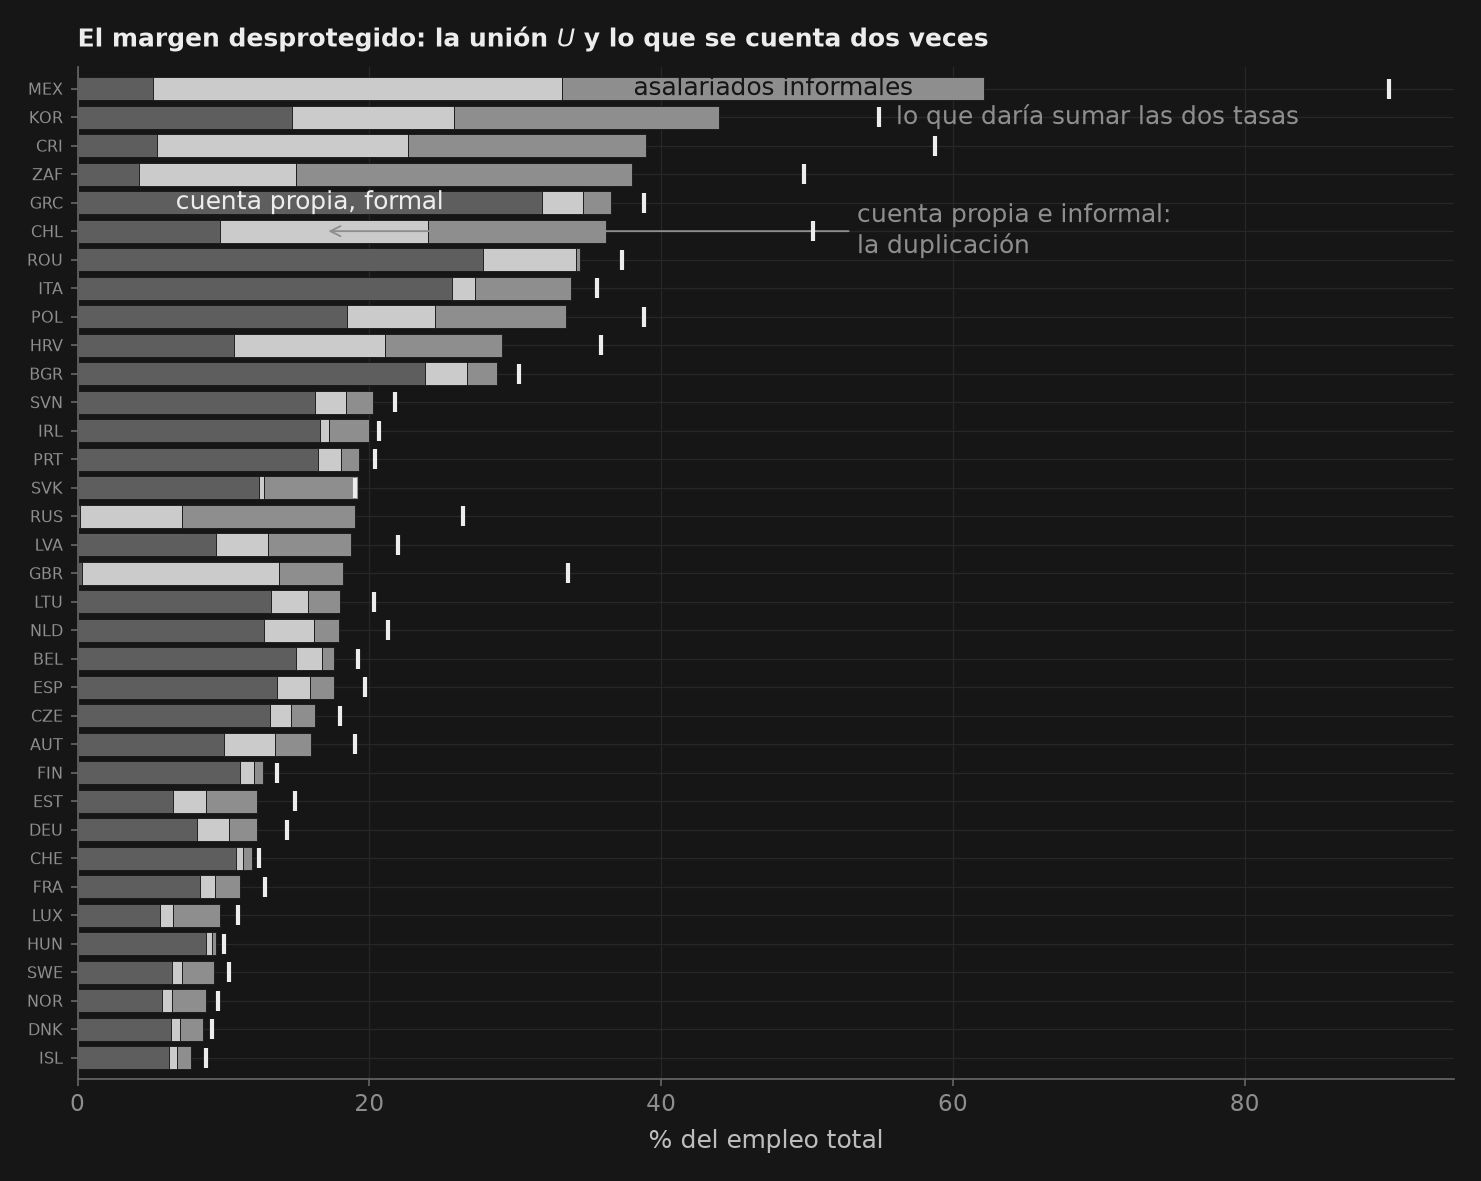

In [53]:
d = u.sort_values("desprotegido")
y = np.arange(len(d))
cp_formal = d["cuenta_propia"] - d["cp_informal"]

# 36 filas apiladas: ninguna talla de TAMANO da la altura, así que se fija a mano.
fig, ax = _nbstyle.figura(figsize=(9.6, 7.6))
ax.barh(y, cp_formal, color=_nbstyle.BARRA_COLORES[2], edgecolor=_nbstyle.FONDO, lw=0.4)
ax.barh(y, d["cp_informal"], left=cp_formal, color=_nbstyle.BARRA_COLORES[0],
        edgecolor=_nbstyle.FONDO, lw=0.4)
ax.barh(y, d["asal_informal"], left=d["cuenta_propia"], color=_nbstyle.BARRA_COLORES[1],
        edgecolor=_nbstyle.FONDO, lw=0.4)
ax.scatter(d["cuenta_propia"] + d["informalidad"], y, marker="|", s=90,
           color=_nbstyle.TINTA, zorder=4)
ax.set_yticks(y); ax.set_yticklabels(d.index, fontsize=7.5)
ax.set_xlabel("% del empleo total")
ax.set_title("El margen desprotegido: la unión $U$ y lo que se cuenta dos veces")
ax.margins(y=0.01)
# Cada nombre va donde su bloque es más ancho, y cada uno en una fila distinta:
# dentro del bloque si cabe, y si no, con una guía hacia el hueco de la derecha.
i_alta = len(d) - 1
r_alta = d.iloc[i_alta]
ax.text(float(r_alta["cuenta_propia"] + r_alta["asal_informal"] / 2), i_alta,
        "asalariados informales", ha="center", va="center", color=_nbstyle.FONDO)
i_formal = int(np.argmax(cp_formal.to_numpy()))
ax.text(float(cp_formal.iloc[i_formal]) / 2, i_formal, "cuenta propia, formal",
        ha="center", va="center", color=_nbstyle.TINTA)
# Cuatro filas más abajo: el bloque sigue siendo de los anchos y el hueco de
# la derecha ya no choca con el nombre de la marca.
i_dup = int(np.argmax(d["cp_informal"].to_numpy()[:len(d) - 4]))
r_dup = d.iloc[i_dup]
ax.annotate("cuenta propia e informal:\nla duplicación",
            xy=(float(cp_formal.iloc[i_dup] + r_dup["cp_informal"] / 2), i_dup),
            xytext=(float(r_dup["cuenta_propia"] + r_dup["informalidad"]) + 3.0, i_dup),
            textcoords="data", ha="left", va="center", color=_nbstyle.NOTA,
            arrowprops=_nbstyle.FLECHA)
i_marca = i_alta - 1
r_marca = d.iloc[i_marca]
ax.annotate("lo que daría sumar las dos tasas",
            xy=(float(r_marca["cuenta_propia"] + r_marca["informalidad"]), i_marca),
            xytext=(8, 0), textcoords="offset points", ha="left", va="center",
            color=_nbstyle.NOTA)
plt.show()


**Cómo leer esto sin exagerar.** Las cuatro nubes son correlaciones simples entre países, con $n$ entre 35 y 47 y sin ningún control: no identifican nada. Lo que sí hacen es fijar el orden de magnitud. La apertura y la profundidad financiera salen con el signo que predice la teoría y con un $|t|$ por debajo de 1,5 — indistinguibles de cero con esta muestra. El margen laboral es el único que pasa de $|t| = 2$, y lo consigue **como unión**: $r = +0{,}36$ frente a $+0{,}34$ del trabajo por cuenta propia solo y $+0{,}22$ de la informalidad sola, sobre los mismos 35 países. Es una mejora pequeña, y es la mejora que cabe esperar de reparar una definición y no de encontrar una variable nueva: la unión no es una mejor aproximación al mecanismo, *es* el mecanismo, y sus dos mitades son cada una una vista parcial de él.

**Qué resuelve la medida conjunta y qué no.** Resuelve la aritmética: informalidad y cuenta propia se solapan, el solapamiento es grande justo donde más importa (28 puntos del empleo mexicano, 13 del británico) y sumarlas no es una opción. También disciplina una tentación anterior. Leídas cada una sobre su propia muestra, la informalidad da $t = +0{,}2$ y el trabajo por cuenta propia $t = +2{,}0$, lo que invita a concluir que la medida armonizada le gana a la no armonizada. Con la muestra fija, la informalidad se va a $t = +1{,}3$: la mayor parte de aquel contraste eran los seis países con tasa de la OIT y sin línea de cuenta propia de la OCDE —ARG, BRA, COL, IDN, IND, TUR—, que son además las seis economías más informales del archivo. La comparabilidad sigue siendo un problema real, y el desglose por situación enseña exactamente dónde muerde (Gran Bretaña clasifica como informal al 98% de sus trabajadores por cuenta propia; España, al 14%), pero estaba haciendo menos trabajo del que sugería el contraste crudo.

**Tres cautelas que quedan.** La proporción de cuenta propia es un promedio 1995–2019 de las cuentas nacionales, mientras que las tasas de la OIT son un único año reciente, así que $U$ mezcla dos ediciones de una misma estructura — defendible para una variable que se mueve despacio, equivocado si el país reformó su mercado de trabajo en medio. Las dos fuentes cuentan además poblaciones distintas: el empleo de las cuentas es *interior* (§5) y el de la OIT es residente, que es parte de por qué la tasa reconstruida falla por 3,5 pp en Croacia y por 1,9 en el Reino Unido, los dos sitios donde $f_{\text{slf}}$ y $f_{\text{ees}}$ están más lejos y donde, por tanto, la composición más importa. Y Rumanía merece mirarse despacio: informalidad del 3,2% con trabajo por cuenta propia del 34,2%, de modo que su unión es casi toda cuenta propia *formal* — agricultura de subsistencia, registrada y desprotegida en todo sentido económicamente relevante, que ninguna estadística de informalidad va a recoger jamás.

### 4.4 Experimento Macroeconómico 2: Términos de Intercambio, Parada Repentina (Sudden Stop) y la Prueba de Estrés de la Balanza Comercial

**Motivación macroeconómica y pregunta de política.**  
Una predicción medular de los modelos canónicos de ciclo económico real (RBC) para economías pequeñas y abiertas es que los mercados internacionales de capital actúan como un amortiguador intertemporal: ante choques adversos transitorios de productividad o de términos de intercambio, los hogares toman crédito del exterior para mantener su senda de consumo, incurriendo en déficit comercial ($\mathrm{corr}(nx/y, y) > 0$), y el consumo se mantiene más suave que el producto ($\sigma(c)/\sigma(y) < 1$).

Sin embargo, en las economías emergentes (p. ej. México, Chile, Argentina), la evidencia empírica contradice frontalmente este paradigma:
1. **Exceso de volatilidad del consumo**: $\sigma(c)/\sigma(y) \approx 1.0$ (o superior).
2. **Contraciclicidad severa de la balanza comercial**: $\mathrm{corr}(nx/y, y) < 0$. Durante las crisis profundas, los déficits comerciales se transforman súbitamente en superávits de emergencia.

Como demuestran Neumeyer y Perri (2005) y García-Cicco, Pancrazi y Uribe (2010), esta divergencia obedece a **fricciones financieras y paradas repentinas (*Sudden Stops*)**. Cuando una economía emergente sufre un choque externo, la prima de riesgo soberano se dispara, el tipo de cambio real se deprecia y los inversionistas extranjeros frenan la refinanciación de la deuda. Sujeta a restricciones de crédito vinculantes, la economía no puede endeudarse: se ve forzada a comprimir drásticamente las importaciones y recortar el consumo, generando un superávit comercial forzoso. En contraste, las economías abiertas avanzadas con mercados financieros profundos (p. ej. Canadá, Noruega) mantienen intacto el acceso al crédito global durante las recesiones, preservando el suavizamiento del consumo y balanzas comerciales procíclicas.

**Tareas guiadas para el estudiante:**
1. **Extracción de datos**: Mediante `_datos.gasto()`, extrae el PIB real trimestral ($Y = \text{gdp}/\text{gdp\_defl}$), el consumo privado real ($C = \text{cons\_hh}/\text{cons\_hh\_defl}$) y la participación de las exportaciones netas ($NX/Y = (\text{exports} - \text{imports})/\text{gdp}$) para una economía emergente (**México, MEX**) y un exportador de materias primas avanzado (**Canadá, CAN**) en el periodo pre-COVID 1995T1–2019T4.
2. **Filtrado Hodrick-Prescott**: Calcula los componentes cíclicos de $\log(Y)$, $\log(C)$ y el ratio $NX/Y$ utilizando `hp_filter` con parámetro trimestral $\lambda = 1600$.
3. **Segundos momentos**: Calcula la volatilidad relativa del consumo $\sigma(c)/\sigma(y) = \mathrm{std}(\tilde{c})/\mathrm{std}(\tilde{y})$ y la ciclicidad de la balanza comercial $\mathrm{corr}(\widetilde{nx/y}, \tilde{y})$ para ambos países.
4. **Prueba de estrés de crisis**: Contrasta el desplazamiento de la balanza comercial ($\Delta (NX/Y)$) entre 2008T3 (pre-crisis) y 2009T4 (fondo de la Gran Recesión). Comprueba si México sufrió compresión por parada repentina mientras Canadá amortiguó el choque con crédito exterior.
5. **Verificación estructural**: Evalúa las aserciones automatizadas que confirman que $\sigma(c)/\sigma(y)_{\text{MEX}} > \sigma(c)/\sigma(y)_{\text{CAN}}$, $\mathrm{corr}(nx/y, y)_{\text{MEX}} < 0$ y $\mathrm{corr}(nx/y, y)_{\text{CAN}} > 0$.


In [54]:
# ==============================================================================
# Experimento Macroeconómico 2: Prueba de Estrés de Parada Repentina y Términos de Intercambio
# Comparación: Economía Emergente (México) vs. Economía Abierta Avanzada (Canadá)
# ==============================================================================
import numpy as np
import pandas as pd
from puremacro.data import hp_filter
import _datos

g = _datos.gasto()

def open_economy_cyclicality(code, start_date="1995-01-01", end_date="2019-12-31"):
    """
    Calcula la volatilidad relativa del consumo sigma(c)/sigma(y) y
    la ciclicidad de la balanza comercial corr(nx/y, y) para una economía abierta.
    """
    sub = g.xs(code)
    y_real = sub["gdp"] / sub["gdp_defl"]
    c_real = sub["cons_hh"] / sub["cons_hh_defl"]
    nx_ratio = (sub["exports"] - sub["imports"]) / sub["gdp"]

    # Filtrado Hodrick-Prescott (lambda = 1600 para frecuencia trimestral)
    y_cyc = hp_filter(100.0 * np.log(y_real.loc[start_date:end_date]), lamb=1600)[0]
    c_cyc = hp_filter(100.0 * np.log(c_real.loc[start_date:end_date]), lamb=1600)[0]
    nx_cyc = hp_filter(nx_ratio.loc[start_date:end_date], lamb=1600)[0]

    vol_ratio = float(c_cyc.std() / y_cyc.std())
    corr_nx_y = float(np.corrcoef(nx_cyc, y_cyc)[0, 1])

    return vol_ratio, corr_nx_y

def trade_balance_swing(code, t_pre="2008-07-01", t_trough="2009-10-01"):
    """Calcula la variación en puntos porcentuales del PIB de la balanza comercial durante la crisis."""
    sub = g.xs(code)
    nx_ratio = (sub["exports"] - sub["imports"]) / sub["gdp"]
    return float(100.0 * (nx_ratio.loc[t_trough] - nx_ratio.loc[t_pre]))

# 1. Cálculo de momentos cíclicos empíricos
mex_vol, mex_nx = open_economy_cyclicality("MEX")
can_vol, can_nx = open_economy_cyclicality("CAN")

print("=" * 72)
print(f"{'País':<10} | {'sigma(c)/sigma(y)':<18} | {'corr(nx/y, y)':<16} | {'Régimen'}")
print("-" * 72)
print(f"{'México':<10} | {mex_vol:<18.2f} | {mex_nx:<16.2f} | Emergente / Parada Repentina (NX Contracíclica)")
print(f"{'Canadá':<10} | {can_vol:<18.2f} | {can_nx:<16.2f} | Avanzada / Suavizamiento Consumo (NX Procíclica)")
print("=" * 72)

# 2. Prueba de estrés: Dinámica de parada repentina en la Gran Recesión 2008T3 a 2009T4
mex_swing = trade_balance_swing("MEX")
can_swing = trade_balance_swing("CAN")

print(f"\nDesplazamiento de la balanza comercial en la crisis 2008-2009 (2008T3 -> 2009T4):")
print(f"  México (MEX) Δ(NX/Y): {mex_swing:+.2f} pp del PIB (Superávit forzoso / compresión importaciones)")
print(f"  Canadá (CAN) Δ(NX/Y): {can_swing:+.2f} pp del PIB (Déficit externo / amortiguamiento con crédito)")

# 3. Verificación de aserciones estructurales
assert mex_vol > can_vol, f"Se esperaba vol MEX ({mex_vol:.2f}) > vol CAN ({can_vol:.2f})"
assert mex_nx < 0, f"Se esperaba balanza comercial de MEX contracíclica, se obtuvo {mex_nx:.2f}"
assert can_nx > 0, f"Se esperaba balanza comercial de CAN procíclica, se obtuvo {can_nx:.2f}"
print("\n✓ ¡Experimento Macroeconómico 2 superó todas las pruebas de verificación estructural!")

País       | sigma(c)/sigma(y)  | corr(nx/y, y)    | Régimen
------------------------------------------------------------------------
México     | 0.96               | -0.29            | Emergente / Parada Repentina (NX Contracíclica)
Canadá     | 0.64               | 0.55             | Avanzada / Suavizamiento Consumo (NX Procíclica)

Desplazamiento de la balanza comercial en la crisis 2008-2009 (2008T3 -> 2009T4):
  México (MEX) Δ(NX/Y): +1.43 pp del PIB (Superávit forzoso / compresión importaciones)
  Canadá (CAN) Δ(NX/Y): -3.76 pp del PIB (Déficit externo / amortiguamiento con crédito)

✓ ¡Experimento Macroeconómico 2 superó todas las pruebas de verificación estructural!


## 5. El mercado de trabajo dentro de las cuentas nacionales

Las mismas cuentas trimestrales miden el **insumo de trabajo**, y `qna_panel(..., labor=True)` lo trae en el mismo panel: ocupados y horas trabajadas, cada uno partido en asalariados y trabajo por cuenta propia, en concepto **interno** — empleo en unidades productivas residentes, que es el concepto sobre el que se mide el PIB, así que `gdp_real / hours` es productividad y no un cociente entre dos poblaciones distintas.

La cobertura vuelve a ser desigual, y con la misma forma que en §1.8: **Estados Unidos y Japón no publican nada** en este flujo, Australia publica cabezas sin horas y Canadá horas sin cabezas. Son 38 países con ocupados y 34 con horas, de los 49 del panel.

Dos secciones. **§5.1** usa el bloque tal cual: cuántas horas trabaja un ocupado, y cuál de los dos márgenes —cabezas u horas— absorbe una recesión. **§5.2** sale de las cuentas nacionales a las encuestas de vacantes para dibujar la **curva de Beveridge**, que es el otro hecho estilizado del mercado de trabajo y el que conecta con la función de emparejamiento de Diamond–Mortensen–Pissarides.

### 5.1 Cabezas y horas: los dos márgenes del insumo de trabajo

El insumo de trabajo se ajusta por dos márgenes, y la diferencia entre ellos es la diferencia entre despedir y mandar a casa antes:

$$H_t \;=\; \underbrace{N_t}_{\text{extensivo}} \times \underbrace{h_t}_{\text{intensivo}}$$

**Primero, el nivel.** Las horas por ocupado y semana van de 26 a 43 dentro de la OCDE — Alemania y Dinamarca abajo, México arriba. Un modelo calibrado con «una jornada» es un modelo calibrado para un país.

**Cuidado con la base temporal, y luego repárala.** Las cuentas garantizan que las horas son horas, no que todos las publiquen por trimestre: divididas entre el empleo y entre las trece semanas de un trimestre, Chile sale a 3.2 horas semanales y Costa Rica a 166. Nada en los metadatos lo dice; los números simplemente llegan. Apartar a los dos es la respuesta prudente y es la equivocada, porque el arreglo está **identificado, no elegido**: una base temporal equivocada solo puede ser una de cuatro razones de calendario, y exigir que la semana reparada caiga en una banda lo bastante ancha para contener a todos los demás países del panel elige exactamente una — y las dos semanas reparadas coinciden entonces entre sí en 41.4 horas, algo que el procedimiento no pudo haber arreglado. El criterio no es nuestro: `qna_panel(hours_rescale=True)` aplica exactamente ese desde **puremacro 1.5.0** al descargar, y la celda de abajo importa esas mismas constantes en vez de volver a teclearlas. La razón de que tengamos que correrlo es que la instantánea congelada del curso se tomó con 1.4.0, así que el archivo en disco sigue con las unidades crudas — y conviene decirlo con todas las letras, porque el arreglo honesto a largo plazo es volver a congelar el panel, no seguir reparándolo aguas abajo. Las horas reparadas son las que escribe §6, y `hours_factor` viaja con ellas para que la corrección se vea en el archivo. T01_A §1.2 la vuelve a derivar desde cero, con otra banda, como comprobación.

**Después, la recesión.** En 2008–2010 Alemania mantuvo el empleo plano y recortó $3{,}7\%$ de las horas (*Kurzarbeit*: todo el ajuste por el margen intensivo); España recortó $9{,}9\%$ del empleo y $9{,}8\%$ de las horas (todo por el extensivo). En 2020 casi toda Europa se comportó como la Alemania de 2009 —los ERTE y los *furlough* son, literalmente, ajuste por horas—, y la excepción es **México**, donde el empleo cayó $19\%$: sin esquema de suspensión temporal, y con la informalidad de §4.3, el margen que queda es el extensivo.

In [55]:
LABORALES = [c for c in QNA_LABOR if c in panel.columns]
lab_crudo = panel[LABORALES].dropna(how="all").copy()

# El criterio es el de la biblioteca, no el nuestro. `qna_panel(hours_rescale=True)`
# lo aplica al descargar desde 1.5.0 — pero la instantánea congelada del curso se
# tomó con 1.4.0, así que el archivo en disco sigue con las unidades crudas y la
# corrida sin red tiene que rehacerlo. Importar las constantes en vez de volver a
# teclearlas mantiene una sola definición: una mediana fuera de
# _HOURS_IMPLAUSIBLE es sospechosa, y un factor candidato solo se acepta si deja
# la mediana dentro de la banda más estrecha _HOURS_PLAUSIBLE.
from puremacro.fetch.oecd_qna_panel import (_HOURS_IMPLAUSIBLE,
                                            _HOURS_PLAUSIBLE,
                                            _HOURS_SCALES)

_hq = ((lab_crudo["hours"] * 1e3) / lab_crudo["emp"]).groupby(level="code").median()
base = []
for code, r in _hq.dropna().items():
    factor, motivo = 1.0, ""
    if not (_HOURS_IMPLAUSIBLE[0] <= r <= _HOURS_IMPLAUSIBLE[1]):
        for f, etiqueta in _HOURS_SCALES.items():
            if _HOURS_PLAUSIBLE[0] <= r * f <= _HOURS_PLAUSIBLE[1]:
                factor, motivo = f, etiqueta
                break
    base.append({"code": code, "horas_por_trimestre": r, "factor": factor,
                 "reparado": r * factor, "motivo": motivo,
                 "ok": factor == 1.0})
base = pd.DataFrame(base).set_index("code").sort_values("horas_por_trimestre")

lab = lab_crudo.copy()
# 1.0 donde hay horas y se dejaron como se publicaron — Canadá publica horas
# pero no cabezas, así que el cociente no se puede formar y no se comprueba
# nada, lo que es un factor de uno y no un dato faltante. En blanco solo donde
# no hay horas en absoluto, porque entonces no hay factor que registrar.
_f = lab.index.get_level_values("code").map(base["factor"]).astype(float)
_f = pd.Series(_f, index=lab.index).where(lab["hours"].isna(), _f.fillna(1.0))
for _col in ("hours", "hours_employees", "hours_selfemp"):
    if _col in lab.columns:
        lab[_col] = lab[_col] * _f
lab["hours_factor"] = _f

# Personas en miles, horas en millones (QNA_LABOR_UNITS), 13 semanas al trimestre.
# Los nombres van en inglés como el resto del panel: este marco se escribe a
# disco en §6 y lo leen los dos cuadernos, así que su esquema no puede depender
# de en qué idioma se corrió el último.
lab["hours_week"] = (lab["hours"] * 1e6) / (lab["emp"] * 1e3) / 13.0
lab["self_emp_share"] = 100.0 * lab["emp_selfemp"] / lab["emp"]

con_emp = int(lab["emp"].notna().groupby(level="code").any().sum())
con_horas = int(lab["hours"].notna().groupby(level="code").any().sum())
print(f"Bloque laboral: {con_emp} países con ocupados, {con_horas} con horas, "
      f"de los {panel.index.get_level_values('code').nunique()} del panel.")
print(f"Sin cabezas en este flujo: "
      f"{', '.join(sorted(set(panel.index.get_level_values('code').unique()) - set(lab['emp'].dropna().index.get_level_values('code').unique())))}.")

arreglados = base[~base["ok"]]
print(f"\nBase temporal: {int(base['ok'].sum())} de {len(base)} países publican "
      f"las horas por trimestre, como declaran. Un trimestre normal ronda las "
      f"430 horas\npor ocupado; algo fuera de {_HOURS_IMPLAUSIBLE[0]:.0f}-"
      f"{_HOURS_IMPLAUSIBLE[1]:.0f} no es un mercado de trabajo, es una unidad.")
if len(arreglados):
    print(f"  reparados, con el factor aceptado solo porque deja la mediana "
          f"dentro de {_HOURS_PLAUSIBLE[0]:.0f}-{_HOURS_PLAUSIBLE[1]:.0f}:")
    for code, r in arreglados.iterrows():
        print(f"    {code}: {r['horas_por_trimestre']:8.1f} h/trimestre x "
              f"{r['factor']:g} -> {r['reparado']:.0f}   "
              f"({r['motivo']} presentado como total trimestral)")
    # La comprobación que el procedimiento no pudo arreglar: dos errores sin
    # relación, dos factores distintos, y la misma jornada al final.
    assert float((arreglados["reparado"] / 13.0).max()
                 - (arreglados["reparado"] / 13.0).min()) < 1.0
assert (base.loc[base.index.isin(arreglados.index), "reparado"]
        .between(*_HOURS_PLAUSIBLE)).all()

horas = (lab.loc[lab.index.get_level_values("date").year == 2019, "hours_week"]
            .groupby(level="code").mean().dropna().sort_values())
print(f"\nHoras por ocupado y semana (media de 2019), tras el arreglo: "
      f"{len(horas)} países entre {horas.min():.1f} ({horas.idxmin()}) y "
      f"{horas.max():.1f} ({horas.idxmax()}).")


def margenes(code, y0, y1):
    """Caída máxima de cabezas y de horas desde el primer trimestre del tramo."""
    g = panel.loc[code]
    g = g[(g.index.year >= y0) & (g.index.year <= y1)]
    e, h = g["emp"].dropna(), g["hours"].dropna()
    if len(e) < 4 or len(h) < 4:
        return None
    return {"code": code,
            "empleo_%": 100.0 * (e.min() / e.iloc[0] - 1.0),
            "horas_%": 100.0 * (h.min() / h.iloc[0] - 1.0)}


PAISES_M = ["DEU", "AUT", "BEL", "NLD", "SWE", "FRA", "GBR", "ITA", "PRT",
            "GRC", "ESP", "IRL", "MEX"]
gfc = pd.DataFrame([r for r in (margenes(c, 2008, 2010) for c in PAISES_M)
                    if r]).set_index("code")
cov = pd.DataFrame([r for r in (margenes(c, 2020, 2020) for c in PAISES_M)
                    if r]).set_index("code")
for t in (gfc, cov):
    # Cuánto de la caída de horas NO se explica por la de cabezas.
    t["intensivo_pp"] = t["horas_%"] - t["empleo_%"]

print("\n2008Q1–2010Q4, caída máxima (%):")
print(gfc.round(1).to_string())
print("\n2020, caída máxima (%):")
print(cov.round(1).to_string())
print(f"\nEn 2008–2010 el margen intensivo aporta una mediana de "
      f"{gfc['intensivo_pp'].median():.1f} pp; en 2020, "
      f"{cov['intensivo_pp'].median():.1f} pp. México en 2020: empleo "
      f"{cov.loc['MEX', 'empleo_%']:.1f}%, horas {cov.loc['MEX', 'horas_%']:.1f}% "
      f"— la única economía del grupo donde manda el margen extensivo.")

assert gfc.loc["DEU", "empleo_%"] > gfc.loc["ESP", "empleo_%"]
assert cov["intensivo_pp"].median() < gfc["intensivo_pp"].median()

Bloque laboral: 38 países con ocupados, 34 con horas, de los 49 del panel.
Sin cabezas en este flujo: ARG, BRA, CAN, CHN, COL, IDN, IND, JPN, SAU, TUR, USA.

Base temporal: 31 de 33 países publican las horas por trimestre, como declaran. Un trimestre normal ronda las 430 horas
por ocupado; algo fuera de 150-1000 no es un mercado de trabajo, es una unidad.
  reparados, con el factor aceptado solo porque deja la mediana dentro de 250-700:
    CHL:     41.4 h/trimestre x 13 -> 538   (weekly presentado como total trimestral)
    CRI:   2155.2 h/trimestre x 0.25 -> 539   (annual rate presentado como total trimestral)

Horas por ocupado y semana (media de 2019), tras el arreglo: 33 países entre 26.4 (DNK) y 42.8 (MEX).

2008Q1–2010Q4, caída máxima (%):
      empleo_%  horas_%  intensivo_pp
code                                 
DEU        0.0     -3.7          -3.7
AUT       -0.6     -3.6          -3.0
BEL        0.0     -1.6          -1.6
NLD       -1.7     -3.2          -1.5
SWE       -2.7 

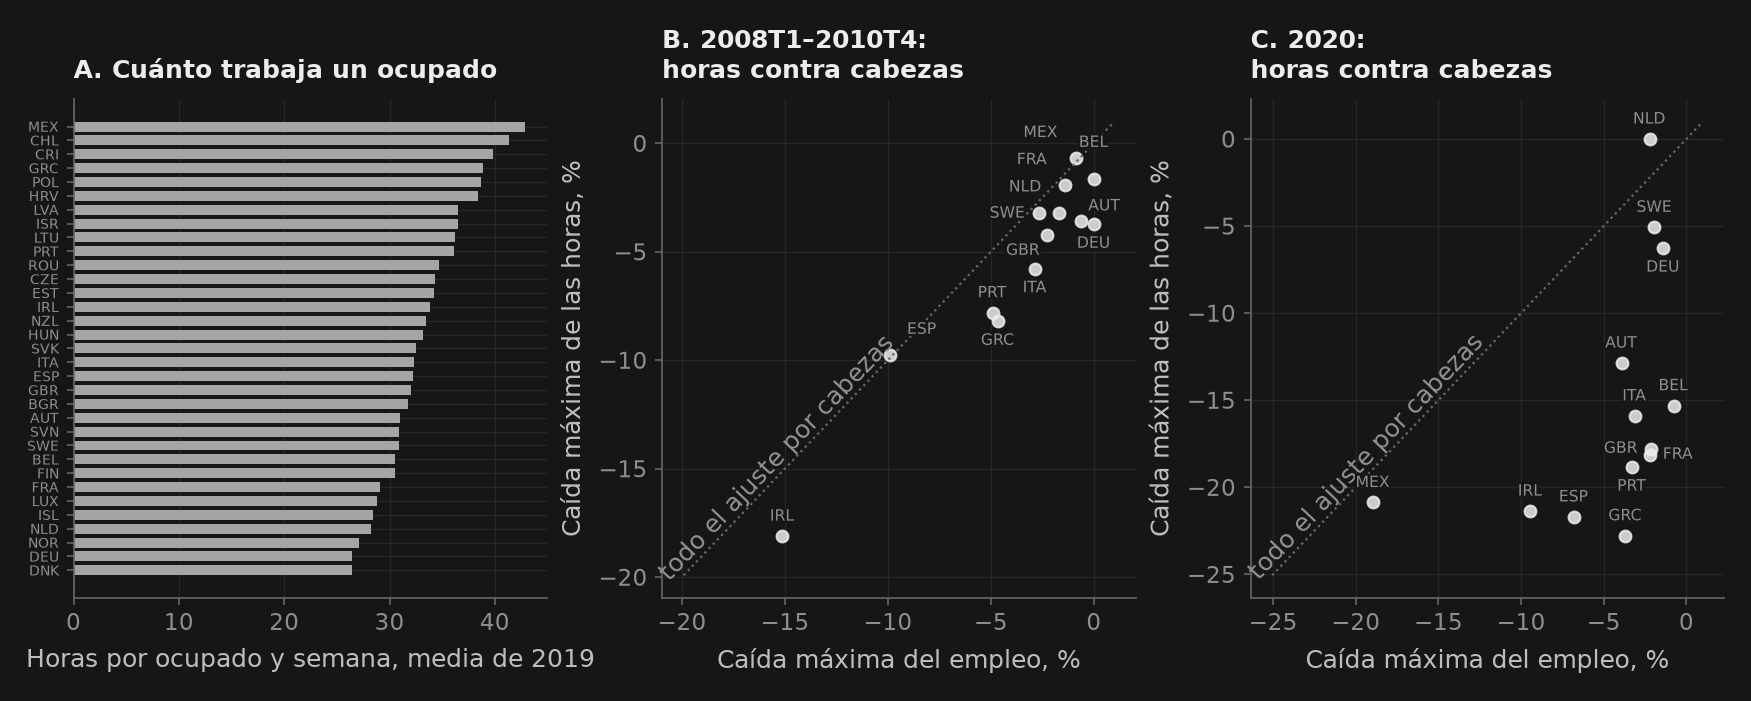

In [56]:
# 35 filas de barras en A: la talla "3" se queda baja, así que se fija a mano.
fig, axes = _nbstyle.figura(1, 3, figsize=(11.4, 4.4))

ax = axes[0]
ax.barh(np.arange(len(horas)), horas.to_numpy(), color=_nbstyle.tono(0.7), height=0.72)
ax.set_yticks(np.arange(len(horas)))
ax.set_yticklabels(horas.index, fontsize=6.5)
ax.set_xlabel("Horas por ocupado y semana, media de 2019")
ax.set_title("A. Cuánto trabaja un ocupado")
ax.set_xlim(0, max(45.0, float(horas.max()) * 1.05))

paneles = []
for ax, (t, titulo) in zip(axes[1:], ((gfc, "B. 2008T1–2010T4"), (cov, "C. 2020"))):
    ax.scatter(t["empleo_%"], t["horas_%"], color=_nbstyle.TINTA, s=32, alpha=0.85)
    lo = 1.1 * min(t["empleo_%"].min(), t["horas_%"].min())
    ax.plot([lo, 1], [lo, 1], color=_nbstyle.SPINE, ls=":", lw=1.1)
    ax.annotate("todo el ajuste por cabezas", xy=(lo * 0.75, lo * 0.75),
                color=_nbstyle.NOTA, rotation=45, transform_rotates_text=True,
                rotation_mode="anchor", ha="center", va="bottom")
    ax.set_xlabel("Caída máxima del empleo, %")
    ax.set_ylabel("Caída máxima de las horas, %")
    ax.set_title(f"{titulo}:\nhoras contra cabezas")
    paneles.append((ax, t))
# Los códigos, al final y con la colocación de §2.2: los tres paneles ya tienen
# su tamaño definitivo cuando se busca sitio para cada uno.
for ax, t in paneles:
    anotar_codigos(ax, t["empleo_%"], t["horas_%"], t.index, fontsize=7.5)
plt.show()


### 5.2 La curva de Beveridge

El desempleo y las vacantes se mueven en direcciones opuestas: cuando la economía se enfría hay más parados y menos puestos sin cubrir. Ese lugar geométrico —la **curva de Beveridge**— es el hecho estilizado que la teoría de búsqueda y emparejamiento existe para explicar.

Con una función de emparejamiento Cobb–Douglas $m = \mu\, u^{\alpha} v^{1-\alpha}$ y el estado estacionario $s(1-u) = m$,

$$\log v \;=\; \text{cte} + \tfrac{1}{1-\alpha}\big(\log s - \log \mu\big) \;-\; \tfrac{\alpha}{1-\alpha}\log u,$$

así que la **pendiente** $b$ de una regresión de $\log v$ sobre $\log u$ identifica $\alpha = b/(b-1)$, y un **desplazamiento hacia afuera** de la curva es —dentro del modelo— o bien más separaciones $s$, o bien menos eficiencia de emparejamiento $\mu$: más vacantes conviviendo con el mismo desempleo porque cuesta más juntarlas.

**De dónde salen $u$ y $v$.** Las cuentas nacionales no publican vacantes, así que aquí se juntan tres fuentes: la tasa de vacantes de **Eurostat** (`jvs_q_nace2`, `JVR`, secciones B–S, desestacionalizada) para 29 países europeos, **JOLTS** para Estados Unidos, y las tasas de paro de la **EPA europea** (`une_rt_m`) y de FRED (`UNRATE`).

**Una trampa de unidades, y es real:** Eurostat manda la tasa de paro como *fracción* ($0{,}052$) y la de vacantes en *porcentaje* ($2{,}9$). Mezclarlas sin mirar da una tensión $\theta = v/u$ de 41 en Austria en vez de $0{,}42$. Nada avisa; el número simplemente sale absurdo, y hay que notarlo.

**Y una advertencia de comparabilidad:** el $v$ de Eurostat es vacantes sobre puestos totales en las secciones B–S y el de JOLTS es aperturas sobre empleo más aperturas en el total no agrícola. **Los niveles no son comparables entre las dos fuentes**; la forma de cada curva y su desplazamiento en el tiempo, sí.

In [57]:
def bajar_beveridge():
    """u trimestral (EPA/FRED) y v trimestral (Eurostat JVS / JOLTS)."""
    from puremacro.fetch import (fetch_eurostat_lfs_panel,
                                 fetch_eurostat_vacancies, fetch_fred,
                                 fetch_jolts)

    jv = fetch_eurostat_vacancies(indicator="JVR", nace="B-S", s_adj="SA")
    u = fetch_eurostat_lfs_panel(sexes=("_T",))
    u = u[u["age"] == "Y_GE15"][["code", "date", "urate"]].copy()
    u["urate"] = 100.0 * u["urate"]        # Eurostat manda fracción, no %
    u["date"] = u["date"].dt.to_period("Q").dt.to_timestamp()
    eur = (jv.merge(u.groupby(["code", "date"], as_index=False)["urate"].mean(),
                    on=["code", "date"], how="inner")
             .rename(columns={"jvr": "vrate"}))
    eur["fuente"] = "eurostat"

    j = fetch_jolts(elements=("openings",), industries=("total",))[["date", "rate"]].copy()
    j["date"] = j["date"].dt.to_period("Q").dt.to_timestamp()
    fu = fetch_fred("UNRATE").rename("urate").to_frame().reset_index()
    fu.columns = ["date", "urate"]
    fu["date"] = pd.to_datetime(fu["date"]).dt.to_period("Q").dt.to_timestamp()
    us = (j.groupby("date", as_index=False)["rate"].mean()
           .rename(columns={"rate": "vrate"})
           .merge(fu.groupby("date", as_index=False)["urate"].mean(), on="date"))
    us["code"], us["fuente"] = "USA", "jolts+fred"
    return pd.concat([eur, us[eur.columns]], ignore_index=True)


bev, origen_bev = de_la_fuente("beveridge_uv.csv", bajar_beveridge,
                               "vacantes y desempleo")
bev["date"] = pd.to_datetime(bev["date"])
bev = (bev.dropna(subset=["urate", "vrate"]).query("urate > 0 and vrate > 0")
          .sort_values(["code", "date"]).reset_index(drop=True))
print(f"Vacantes y desempleo: {origen_bev}. {bev['code'].nunique()} países, "
      f"{bev['date'].min().to_period('Q')}–{bev['date'].max().to_period('Q')}, "
      f"{len(bev):,} trimestres-país.")


def ajuste_beveridge(g, corte="2020-01-01", vuelta="2021-01-01"):
    """log v = a + b log u antes de 2020; desplazamiento medio desde 2021."""
    pre, post = g[g["date"] < corte], g[g["date"] >= vuelta]
    if len(pre) < 12 or len(post) < 8:
        return None
    x, y = np.log(pre["urate"].to_numpy()), np.log(pre["vrate"].to_numpy())
    b, a = np.polyfit(x, y, 1)
    resid = np.log(post["vrate"].to_numpy()) - (a + b * np.log(post["urate"].to_numpy()))
    return {"b": float(b),
            # α sólo tiene sentido donde la pendiente es negativa; donde sale
            # positiva la nube no es una curva de Beveridge y decirlo con un NaN
            # es más honesto que imprimir un α de 6,6.
            "alpha": float(b / (b - 1.0)) if b < 0 else np.nan,
            "R2": float(np.corrcoef(x, y)[0, 1] ** 2),
            "desplaz": float(np.mean(resid)),
            "theta_pre": float((pre["vrate"] / pre["urate"]).mean()),
            "theta_post": float((post["vrate"] / post["urate"]).mean()),
            "a": float(a), "n": len(g)}


ajustes = {code: r for code, g in bev.groupby("code")
           if (r := ajuste_beveridge(g)) is not None}
bevfit = pd.DataFrame(ajustes).T
neg = bevfit[bevfit["b"] < 0]

print(f"\nAjuste log v = a + b log u antes de 2020, {len(bevfit)} países "
      f"(sin GBR: Eurostat deja de recibir sus datos en 2020Q3).")
print(f"  Pendiente mediana {bevfit['b'].median():+.2f}; negativa en "
      f"{int((bevfit['b'] < 0).sum())} de {len(bevfit)} — la curva baja.")
print(f"  α implícito de la función de emparejamiento: mediana "
      f"{neg['alpha'].median():.2f}, rango intercuartil "
      f"{neg['alpha'].quantile(.25):.2f}–{neg['alpha'].quantile(.75):.2f}. "
      f"Petrongolo–Pissarides (2001) sitúan la literatura en 0,5–0,7.")
print(f"  Desplazamiento tras 2021: mediana {bevfit['desplaz'].median():+.3f} "
      f"log-puntos, es decir "
      f"{100 * (np.exp(bevfit['desplaz'].median()) - 1):+.0f}% de vacantes al "
      f"mismo desempleo; hacia afuera en {int((bevfit['desplaz'] > 0).sum())} "
      f"de {len(bevfit)}.")
print(f"  Tensión θ = v/u: mediana {bevfit['theta_pre'].median():.2f} antes, "
      f"{bevfit['theta_post'].median():.2f} después.")
print("\n" + bevfit[["b", "alpha", "R2", "desplaz", "theta_pre", "theta_post"]]
      .sort_values("desplaz", ascending=False).round(3).to_string())

assert (bevfit["b"] < 0).mean() > 0.8          # la curva baja casi en todas partes
assert bevfit["theta_post"].median() > bevfit["theta_pre"].median()

Vacantes y desempleo: instantánea del curso (MAV_QNA_VIVO=1 para descargar). 30 países, 2000Q4–2026Q2, 1,928 trimestres-país.

Ajuste log v = a + b log u antes de 2020, 29 países (sin GBR: Eurostat deja de recibir sus datos en 2020Q3).
  Pendiente mediana -0.75; negativa en 27 de 29 — la curva baja.
  α implícito de la función de emparejamiento: mediana 0.44, rango intercuartil 0.38–0.54. Petrongolo–Pissarides (2001) sitúan la literatura en 0,5–0,7.
  Desplazamiento tras 2021: mediana +0.154 log-puntos, es decir +17% de vacantes al mismo desempleo; hacia afuera en 21 de 29.
  Tensión θ = v/u: mediana 0.18 antes, 0.34 después.

         b  alpha     R2  desplaz  theta_pre  theta_post
GRC  1.179    NaN  0.285    1.297      0.035       0.133
AUT -0.755  0.430  0.108    0.606      0.416       0.807
LUX  2.436    NaN  0.322    0.603      0.183       0.341
SWE -2.470  0.712  0.938    0.531      0.254       0.311
SVN -0.635  0.388  0.148    0.397      0.213       0.654
CHE -1.080  0.519  0.23

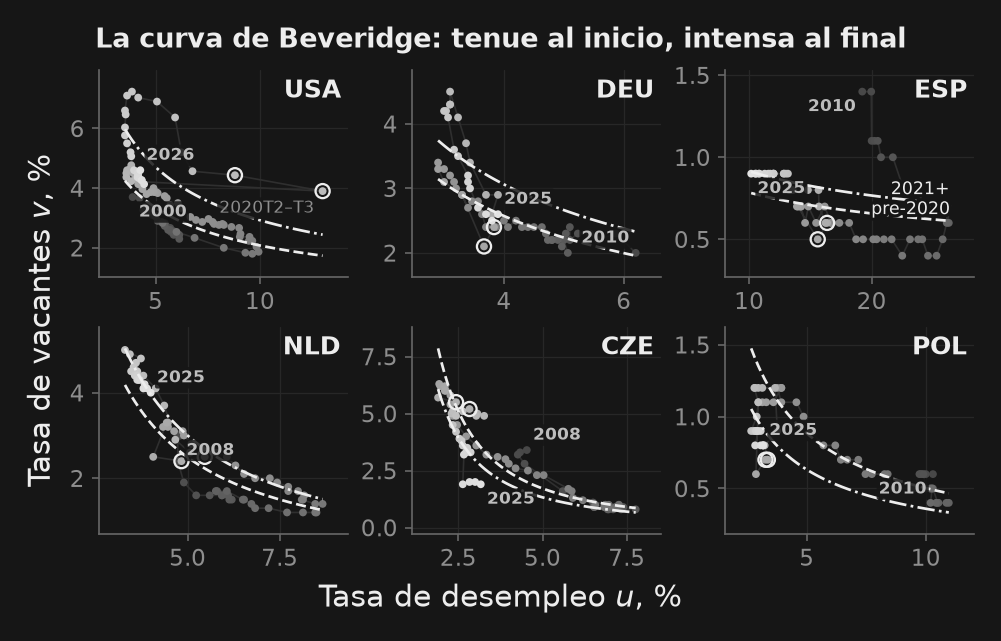

In [58]:
MUESTRA = ["USA", "DEU", "ESP", "NLD", "CZE", "POL"]
# Las cifras del ajuste ya están en la tabla de arriba: en el panel sobra el
# código del área, dentro, y los dos ajustes rotulados una sola vez.
_PLACA = dict(boxstyle="round,pad=0.12", facecolor=_nbstyle.FONDO, edgecolor="none",
              alpha=0.85)
fig, axes = _nbstyle.figura(2, 3, figsize=plt.rcParams["figure.figsize"])
for k, (ax, code) in enumerate(zip(axes.ravel(), MUESTRA)):
    g = bev[bev["code"] == code].sort_values("date").reset_index(drop=True)
    # Tenues los primeros trimestres, tinta plena los últimos: la nube se lee
    # como una trayectoria y no como una nube.
    ax.plot(g["urate"], g["vrate"], color=_nbstyle.gris("0.82"), lw=0.8, ls="-", zorder=1)
    ax.scatter(g["urate"], g["vrate"], c=np.linspace(0.22, 0.95, len(g)),
               cmap="mav_seq", vmin=0, vmax=1, s=14, zorder=2,
               edgecolor="none")
    covid = g[(g["date"] >= "2020-04-01") & (g["date"] <= "2020-07-01")]
    ax.scatter(covid["urate"], covid["vrate"], facecolor="none",
               edgecolor=_nbstyle.TINTA, s=46, lw=1.1, zorder=3)
    r = ajustes.get(code)
    if r:
        gx = np.linspace(g["urate"].min(), g["urate"].max(), 60)
        # los dos ajustes se nombran una sola vez, en el panel de ESP
        ax.plot(gx, np.exp(r["a"] + r["b"] * np.log(gx)), color=_nbstyle.TINTA, lw=1.3,
                ls="--", label="pre-2020" if k == 2 else None)
        ax.plot(gx, np.exp(r["a"] + r["desplaz"] + r["b"] * np.log(gx)),
                color=_nbstyle.TINTA, lw=1.3, ls="-.",
                label="2021+" if k == 2 else None)
    ax.margins(0.13)
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()

    def _hacia_dentro(x, y, d=4.0, arriba=None):
        """Desplazamiento del rótulo hacia el centro del panel."""
        fx, fy = (x - x0) / (x1 - x0), (y - y0) / (y1 - y0)
        dx, ha = (-d, "right") if fx > 0.5 else (d, "left")
        if arriba is None:
            arriba = fy <= 0.5
        # contra el borde no cabe: el rótulo se va al otro lado del punto
        arriba = True if fy < 0.12 else (False if fy > 0.88 else arriba)
        dy, va = (d, "bottom") if arriba else (-d, "top")
        return (dx, dy), ha, va

    if k == 0 and len(covid):
        xc, yc = float(covid["urate"].iloc[0]), float(covid["vrate"].iloc[0])
        # debajo del punto: a su altura el rótulo taparía el otro trimestre marcado
        off, ha, va = _hacia_dentro(xc, yc, arriba=False)
        ax.annotate("2020T2–T3", xy=(xc, yc), xytext=off, textcoords="offset points",
                    ha=ha, va=va, color=_nbstyle.NOTA, fontsize="x-small", bbox=_PLACA)
    # el punto más alto lleva su año encima y el más bajo debajo: en varios
    # paneles el principio y el final de la trayectoria caen casi a la misma altura
    _v0, _v1 = float(g["vrate"].iloc[0]), float(g["vrate"].iloc[-1])
    for pos, arriba in ((0, _v0 >= _v1), (-1, _v1 > _v0)):
        xp, yp = float(g["urate"].iloc[pos]), float(g["vrate"].iloc[pos])
        off, ha, va = _hacia_dentro(xp, yp, d=3.0, arriba=arriba)
        ax.annotate(str(g["date"].iloc[pos].year), xy=(xp, yp), xytext=off,
                    textcoords="offset points", ha=ha, va=va, fontsize="x-small",
                    color=_nbstyle.TEXTO, fontweight="bold", bbox=_PLACA)
    # El código del área va dentro: la esquina alta y derecha queda libre en una
    # curva decreciente, y así la lámina lo conserva aunque suelte los títulos.
    ax.annotate(code, xy=(0.97, 0.96), xycoords="axes fraction", ha="right", va="top",
                fontweight="bold", color=_nbstyle.TINTA)
fig.supxlabel("Tasa de desempleo $u$, %")
fig.supylabel("Tasa de vacantes $v$, %")
fig.suptitle("La curva de Beveridge: tenue al inicio, intensa al final")
_nbstyle.etiquetar(axes[0, 2], donde="fin", fuera=False, fontsize="x-small")
plt.show()


**Qué mirar en cada panel.** *Estados Unidos* traza el bucle de manual: en 2020Q2 salta a $u \approx 13\%$ con las vacantes apenas tocadas —un cierre administrativo, no una caída de demanda de trabajo— y vuelve por encima de la curva anterior, con $\theta$ pasando de $0{,}60$ a $1{,}34$: más puestos vacantes que parados, algo que no había ocurrido nunca en la serie de JOLTS. *Alemania* y *Países Bajos* hacen lo mismo en pequeño. *España* es el caso donde la curva casi no existe: $R^2 = 0{,}03$, porque su tasa de vacantes se mueve entre $0{,}4$ y $1{,}4$ mientras el paro va de $8$ a $26\%$ — todo el ajuste español ocurre en $u$, y $\theta$ pasa de $0{,}035$ a $0{,}07$, dos órdenes de magnitud por debajo de Chequia. *Chequia* y *Polonia* desplazan la curva hacia **adentro**, y son el recordatorio de que «la curva se movió hacia afuera» es un hecho de 21 países de 29, no una ley.

### 5.3 La rama que sobra y el país que falta

Todo el bloque laboral de arriba es el de la economía entera, y eso es una decisión y no un dato: el flujo `DF_QNA_BY_ACTIVITY_EMPDC` publica **todas las secciones CIIU** y `qna_panel` venía fijando `ACTIVITY=_T` y tirando las once restantes. `labor_activities=True` las pide, y hay exactamente dos que merece la pena tener aparte.

**Agricultura (A)**, porque casi todo su trabajo es por cuenta propia y buena parte de su producto anual es el clima. Y **administración pública, educación y sanidad (O–Q)**, por una razón contable y no económica: el SCN *define* el valor añadido de las administraciones públicas como remuneración más consumo de capital fijo, así que el crecimiento medido de su productividad es cercano a cero **por construcción y no por hallazgo** — y arrastra al agregado hacia abajo en una proporción que es el tamaño del sector y nada más. Restarle las dos a la economía entera es lo que convierte un $Y/H$ de todo el país en el del **sector de mercado**, que es exactamente el concepto sobre el que Estados Unidos publica su sector empresarial no agrícola. Las dos columnas llegan al archivo del §6 y T01_A §1.4 las usa para eso.

**Y ahora el país que falta, que son dos.** §5 lleva desde el principio diciendo que Estados Unidos y Japón no publican nada en este flujo, y conviene ser preciso sobre qué significa «nada»: con la clave abierta en las trece dimensiones y desde 1990, la OCDE devuelve **cero filas** para los dos. No es una rama ausente ni una muestra corta. Tampoco hay salida trimestral por rama para Estados Unidos. Así que no existe un denominador trimestral de contabilidad nacional para ninguno de los dos, y dividir su PIB entre un insumo de trabajo tomado de otro sitio es justo el desajuste que §1 pasó diez pasos evitando.

Las tablas **anuales** sí los tienen. `DSD_NAMAIN10@DF_TABLE3_EMPDC` publica horas trabajadas *por los asalariados* con las mismas doce agrupaciones CIIU —el total de la economía desde 1970 para Estados Unidos y 1980 para Japón, las ramas desde 1998 y 1994— y `DF_TABLE6` publica valor añadido por sección CIIU para ambos. `ana_by_activity` junta las dos en un panel anual, y ahí Estados Unidos y Japón se pueden medir con el mismo concepto que los demás. Es la única frecuencia en la que se puede, y decirlo así es más honesto que un panel trimestral con dos filas prestadas.

Dos mecánicas que conviene conocer antes de leer una cifra. La tabla de valor añadido publica **secciones** y no las agrupaciones que usa la de trabajo, así que `public` es O+P+Q sumadas. Y todo agregado sale **por resta desde `_T`, nunca por suma**, porque Japón no publica las secciones E, N, S, T ni U: sumar lo que se conserva deja a Japón fuera y restar lo que se quita lo mantiene dentro. Misma aritmética donde las dos funcionan, y sólo una de las dos contesta para todos los países. Los volúmenes no vienen encadenados: vienen a precios corrientes y a precios del año anterior —que sí son aditivos dentro de un año— y `chain_volume` los enlaza.

In [59]:
from puremacro.fetch import ana_by_activity, ana_meta, chain_volume, qna_labor

RAMAS = ["agri", "public"]

# Trimestral: las mismas seis series otra vez para A y para O-Q. Se pide con
# hours_rescale=False a propósito — el factor de la base temporal lo aplica
# este cuaderno unas celdas más arriba, y una sola definición del arreglo es
# lo que impide que el total quede reparado y sus ramas no.
_cols_ramas = [f"{s}_{r}" for r in RAMAS
               for s in ("emp", "emp_employees", "emp_selfemp",
                         "hours", "hours_employees", "hours_selfemp")]


def _bajar_ramas():
    largo = qna_labor(PAISES, start="1995", sa="x13", activities=True,
                      hours_rescale=False)
    if largo.empty:
        return pd.DataFrame()
    ancho = largo.pivot_table(index=["code", "date"], columns="variable",
                              values="value")
    return ancho[[c for c in _cols_ramas if c in ancho.columns]].reset_index()


ramas_q, fuente_ramas = de_la_fuente("oecd_qna_labor_ramas.csv", _bajar_ramas,
                                     "el bloque laboral por rama")
ramas_q = (ramas_q.assign(date=pd.to_datetime(ramas_q["date"]))
                  .set_index(["code", "date"]).sort_index())

# El mismo _f de §5.1, sobre las mismas columnas de horas. Si una rama llegara
# sin su total reparado el `hours - hours_agri` de T01_A daría un número que
# parece un número.
_fr = pd.Series(ramas_q.index.get_level_values("code").map(base["factor"]),
                index=ramas_q.index).astype(float).fillna(1.0)
for _col in [c for c in ramas_q.columns if c.startswith("hours")]:
    ramas_q[_col] = ramas_q[_col] * _fr
lab = lab.join(ramas_q, how="left")

_con_ramas = sorted({c for c in lab.index.get_level_values("code").unique()
                     if lab.loc[c, ["hours", "hours_agri", "hours_public"]]
                            .notna().all(axis=1).any()})
print(f"Trimestral, por rama ({fuente_ramas}): {len(_con_ramas)} países tienen "
      f"horas en el total, en A y en O-Q a la vez,\nque son los que admiten un "
      f"sector de mercado por resta. Ni EUA ni Japón, que no están en el flujo.")
_peso = (100.0 * (lab["hours_agri"] + lab["hours_public"]) / lab["hours"]
         ).groupby(level="code").median().dropna().sort_values()
print(f"  Lo que se quita pesa entre el {_peso.min():.0f}% de las horas "
      f"({_peso.idxmin()}) y el {_peso.max():.0f}% ({_peso.idxmax()}), "
      f"mediana {_peso.median():.0f}%.")

# La parte nunca puede superar al total. Ojo con el NaN: una comparación de
# pandas devuelve False —no NaN— cuando falta un lado, así que .dropna() sobre
# el booleano no quita nada y la guardia se dispararía con los países sin
# horas. Se compara donde hay las dos cosas, que es donde la afirmación existe.
_hay = lab[["hours", "hours_agri", "hours_public"]].notna().all(axis=1)
assert (lab.loc[_hay, "hours_agri"] <= lab.loc[_hay, "hours"]).all()
assert (lab.loc[_hay, "hours_public"] <= lab.loc[_hay, "hours"]).all()
assert (lab.loc[_hay, "hours_agri"] + lab.loc[_hay, "hours_public"]
        <= lab.loc[_hay, "hours"]).all()

Trimestral, por rama (instantánea del curso (MAV_QNA_VIVO=1 para descargar)): 34 países tienen horas en el total, en A y en O-Q a la vez,
que son los que admiten un sector de mercado por resta. Ni EUA ni Japón, que no están en el flujo.
  Lo que se quita pesa entre el 19% de las horas (LUX) y el 40% (ROU), mediana 29%.


In [60]:
# Anual: el mismo desglose, en la única frecuencia que cubre a EUA y a Japón.
# Son ~18 peticiones SDMX, así que sólo con VIVO encendido.
def _bajar_anual():
    p = ana_by_activity(PAISES, start="1970")
    if p.empty:
        return pd.DataFrame()
    salida = p.reset_index()
    salida.attrs["meta"] = p.attrs.get("meta", ())
    return salida


anual, fuente_anual = de_la_fuente("oecd_ana_actividad.csv", _bajar_anual,
                                   "el bloque anual por rama")
anual = anual.set_index(["code", "year"]).sort_index()

# La ficha del bloque anual se recalcula desde el propio marco en vez de
# viajar en attrs: attrs no sobrevive un ida y vuelta a CSV, y una ficha que
# existe en vivo y desaparece congelada es una ficha en la que no se puede
# confiar.
_NECESARIAS = (["va_total", "va_total_py"]
               + [f"va_{r}{t}" for r in RAMAS for t in ("", "_py")]
               + ["hours_employees"]
               + [f"hours_employees_{r}" for r in RAMAS])
_hay = anual[_NECESARIAS].notna().all(axis=1)
meta_anual = pd.DataFrame([
    {"code": code,
     "n_obs": len(g),
     "first": int(g.index.get_level_values("year").min()),
     "last": int(g.index.get_level_values("year").max()),
     # ¿publica horas de TODOS los ocupados por rama, o sólo de asalariados?
     "hours_by_activity": bool(
         g[["hours"] + [f"hours_{r}" for r in RAMAS]].notna().all(axis=1).any())
         if "hours" in g.columns else False,
     "market_n": int(_hay.loc[code].sum()),
     "market_first": (int(_hay.loc[code].index[_hay.loc[code]].min())
                      if _hay.loc[code].any() else None),
     "market_last": (int(_hay.loc[code].index[_hay.loc[code]].max())
                     if _hay.loc[code].any() else None)}
    for code, g in anual.groupby(level="code")])

_mkt = meta_anual[meta_anual["market_n"] >= 15]
print(f"Anual, por rama ({fuente_anual}): {len(_mkt)} países tienen a la vez "
      f"valor añadido y horas de asalariados\nen el total, en A y en O-Q "
      f"durante al menos quince años, que es la materia prima del sector de "
      f"mercado\nde T01_A §1.4 — él aplica además su propia ventana y se queda "
      f"con menos.")
for c in ("USA", "JPN"):
    if c in set(meta_anual["code"]):
        r = meta_anual.set_index("code").loc[c]
        print(f"  {c}: {int(r['market_n'])} años, {int(r['market_first'])}–"
              f"{int(r['market_last'])}; horas de todos los ocupados por rama: "
              f"{'sí' if r['hours_by_activity'] else 'no, sólo de asalariados'}.")
print(f"  Con horas de TODOS los ocupados por rama: "
      f"{int(meta_anual['hours_by_activity'].sum())} de {len(meta_anual)}. La "
      f"diferencia entre esos dos recuentos es\n  la razón de que T01_A §1.4 "
      f"mida con horas de asalariados y ponga número a lo que cuesta.")

assert {"USA", "JPN"}.issubset(set(_mkt["code"])), \
    "el bloque anual existe para traer a EUA y a Japón; si no están, no sirve"

Anual, por rama (instantánea del curso (MAV_QNA_VIVO=1 para descargar)): 34 países tienen a la vez valor añadido y horas de asalariados
en el total, en A y en O-Q durante al menos quince años, que es la materia prima del sector de mercado
de T01_A §1.4 — él aplica además su propia ventana y se queda con menos.
  USA: 26 años, 1998–2023; horas de todos los ocupados por rama: no, sólo de asalariados.
  JPN: 30 años, 1995–2024; horas de todos los ocupados por rama: no, sólo de asalariados.
  Con horas de TODOS los ocupados por rama: 37 de 46. La diferencia entre esos dos recuentos es
  la razón de que T01_A §1.4 mida con horas de asalariados y ponga número a lo que cuesta.


**Dónde acaban estos dos bloques.** Las columnas trimestrales por rama se pegan a `lab` aquí mismo, así que viajan dentro de `qna_mercado_laboral.csv` cuando §6 lo escriba — son parte del bloque laboral, no un bloque nuevo. El panel anual, en cambio, **no se reescribe**: su instantánea `oecd_ana_actividad.csv` ya es exactamente lo que necesita el cuaderno siguiente, y `notebooks/_datos.py` la lee con `actividad_anual()` y arma el sector de mercado con `sector_mercado()`. Copiar 1.700 filas de un archivo a otro con otro nombre sería crear la segunda versión de los mismos números que §6 existe para evitar.

## 6. Congelar los cuatro bloques

La lección termina donde empezó: con archivos. §1.10 comprobó que los tres productos son consistentes; aquí se escriben, y se escriben **por bloque, no por producto**, porque es así como los usan los cuadernos siguientes.

| Archivo | Qué lleva | Cobertura |
|---|---|---|
| `qna_gasto.csv` | $C$, $G$, $I$, $X$, $M$, PIB, el desglose de la FBCF por activo y el del consumo por durabilidad — **más un deflactor por cada uno** | 49 países |
| `qna_renta.csv` | remuneración de asalariados, excedente bruto y renta mixta, impuestos netos sobre producción e importaciones | 40 |
| `qna_produccion.csv` | valor añadido por rama CIIU Rev.4, impuestos netos sobre productos, discrepancia de encadenamiento, **con sus deflactores** | 43 |
| `qna_mercado_laboral.csv` | ocupados y horas, partidos en asalariados y cuenta propia; `hours_week`; `self_emp_share`; las tasas de paro y de vacantes de §5.2; y las mismas cabezas y horas otra vez para agricultura (`_agri`) y para administración pública, educación y sanidad (`_public`), de §5.3 | 42 en el archivo (cabezas: 38, horas: 34; u y v: 30) |

Tres decisiones, y las tres son la lección de §1 aplicada:

1. **Niveles y deflactores, sin volúmenes.** El volumen es $100\times$ nominal/deflactor, exacto hasta el último bit — §1.2 lo verifica en $10^{-16}$ —, así que guardarlo sería guardar la misma información dos veces y arriesgarse a que las tres copias dejen de cuadrar. El bloque de renta no lleva deflactores porque no existen: no hay «salarios a precios constantes» en las cuentas.
2. **Todo desestacionalizado**, con la procedencia anotada: `sa="x13"` tomó el ajuste oficial donde lo hay y aplicó X-13/X-11 aquí donde no (Brasil, China y Arabia Saudí en los agregados; México, Japón y Turquía entre otros en los desgloses; once países en el bloque laboral, de Australia a Sudáfrica). El archivo `qna_meta.csv` que viaja con ellos dice, país por país, quién ajustó qué.
3. **Tal como los publica la fuente**, cada país en su propio año de referencia de precios. Y con los nombres de columna en inglés, como el resto del panel: el archivo lo leen los dos cuadernos y `notebooks/_datos.py`, así que su esquema no puede depender del idioma de quien lo escribió. No se rebasa al escribir: `qna_rebase(gasto, 2015)` lo hace en una línea cuando el cuaderno siguiente lo necesite, y §1.5 ya demostró que eso no toca ninguna tasa de crecimiento.

In [61]:
# El bloque laboral se enriquece con lo derivado en §5.1 y con u y v de §5.2,
# que es lo que hace utilizable el archivo sin rehacer el trabajo de esta lección.
mercado_laboral = lab.join(
    bev.set_index(["code", "date"])[["urate", "vrate", "fuente"]]
       .rename(columns={"fuente": "uv_source"}), how="outer").sort_index()

# Las cinco columnas derivadas se redondean ANTES de escribir, y theta se
# calcula desde las ya redondeadas. No es cosmética: u y v salen de promediar
# meses, y el promedio de la descarga en vivo difiere del de la instantánea en
# el ÚLTIMO bit (4e-16). Sin esto el archivo congelado cambia de hash según si
# la corrida tuvo red, y el guardián de `figuras_curso.py --verificar-datos`
# —que compara sha256— salta sin que ningún número haya cambiado. Nueve
# decimales están tres órdenes por debajo de la precisión que publica la
# fuente (JOLTS y Eurostat dan una o dos cifras decimales).
_DERIVADAS = ["hours_week", "self_emp_share", "urate", "vrate"]
mercado_laboral[_DERIVADAS] = mercado_laboral[_DERIVADAS].round(9)
mercado_laboral["theta"] = (mercado_laboral["vrate"]
                            / mercado_laboral["urate"]).round(9)

BLOQUES = {
    "qna_gasto": [c for c in panel.columns
                  if c.split("_defl")[0] in
                  (list(QNA_COMPONENTS) + list(QNA_ASSETS) + list(QNA_DURABILITY))
                  and not c.endswith("_real")],
    "qna_renta": [c for c in panel.columns
                  if c.split("_defl")[0] in QNA_INCOME and not c.endswith("_real")],
    "qna_produccion": [c for c in panel.columns
                       if c.split("_defl")[0] in QNA_ACTIVITIES
                       and not c.endswith("_real")],
}
productos = {n: panel[cs].dropna(how="all") for n, cs in BLOQUES.items()}
productos["qna_mercado_laboral"] = mercado_laboral.dropna(how="all")

resumen = pd.DataFrame([
    {"archivo": f"{n}.csv", "series": f.shape[1],
     "países": f.index.get_level_values("code").nunique(),
     "trimestres": f.index.get_level_values("date").nunique(),
     "observaciones": int(f.select_dtypes("number").notna().to_numpy().sum())}
    for n, f in productos.items()])
print("Los cuatro bloques de contabilidad nacional trimestral, desestacionalizados:")
print(resumen.to_string(index=False))

escritos = []
try:
    for nombre, marco in productos.items():
        marco.to_csv(DATA / f"{nombre}.csv")
        escritos.append(f"{nombre}.csv")
    meta.to_csv(DATA / "qna_meta.csv", index=False)
    escritos.append("qna_meta.csv")
except OSError as exc:
    print(f"\nNo se escribió ({type(exc).__name__}): {DATA} no admite escritura "
          f"aquí. Los cuatro marcos están completos en memoria y nada de lo que "
          f"sigue necesita los archivos.")
else:
    print(f"\nEscritos en {DATA}/: {', '.join(escritos)}")

# Comprobación de ida y vuelta: lo que se leerá en el cuaderno siguiente es lo
# que hay aquí. Y el volumen que no guardamos se rehace desde los otros dos.
if escritos:
    releido = (pd.read_csv(DATA / "qna_gasto.csv", parse_dates=["date"])
                 .set_index(["code", "date"]).sort_index())
    pd.testing.assert_frame_equal(releido, productos["qna_gasto"],
                                  check_freq=False)
    rehecho = 100.0 * releido["gdp"] / releido["gdp_defl"]
    ambos = pd.concat([rehecho.rename("desde_el_archivo"),
                       panel["gdp_real"].rename("del_panel")], axis=1).dropna()
    print(f"Ida y vuelta verificada en {productos['qna_gasto'].shape[1]} series; "
          f"volumen del PIB rehecho desde el archivo en {len(ambos):,} "
          f"trimestres, peor error relativo "
          f"{float(((ambos['desde_el_archivo'] - ambos['del_panel']).abs() / ambos['del_panel']).max()):.1e}")
    assert np.allclose(ambos["desde_el_archivo"], ambos["del_panel"], rtol=1e-9)

assert set(productos) == {"qna_gasto", "qna_renta", "qna_produccion",
                          "qna_mercado_laboral"}

Los cuatro bloques de contabilidad nacional trimestral, desestacionalizados:
                archivo  series  países  trimestres  observaciones
          qna_gasto.csv      30      49         126         154160
          qna_renta.csv       6      40         126          26182
     qna_produccion.csv      32      43         126         146446
qna_mercado_laboral.csv      25      42         126          92274

Escritos en data_curso/bundle_2026A/: qna_gasto.csv, qna_renta.csv, qna_produccion.csv, qna_mercado_laboral.csv, qna_meta.csv
Ida y vuelta verificada en 30 series; volumen del PIB rehecho desde el archivo en 5,812 trimestres, peor error relativo 0.0e+00


## 7. Ejercicios
1. **Dos de tres.** La instantánea del curso trae niveles nominales y deflactores, pero no volúmenes, y §1.2 rehace los volúmenes en una línea. Escribe el álgebra que hace eso exacto. Después pregúntate si sirve cualquier par: si un archivo trajera volúmenes y deflactores, ¿podrías recuperar siempre los niveles nominales? (Pista: mira para qué componentes §1 se niega a construir un deflactor, y por qué.)
2. **Por qué la identidad tiene que ser nominal.** §1.6 encuentra la brecha a precios corrientes del país mediano en $0{,}013\%$ del PIB y la de volúmenes encadenados en $0{,}492\%$, con la brecha de volumen de EE. UU. 502 veces mayor quince años después de su año base que en él. (a) Explica, a partir de cómo se construye un índice encadenado, por qué la brecha de volumen tiene que ser cero en el año de referencia y crecer en *ambas* direcciones al alejarse. (b) Un colega propone arreglarlo cambiando la referencia del panel a la mitad de la muestra con `qna_rebase`. Muestra, usando el contraste de invariancia de §1.5, por qué eso no puede funcionar — y di con precisión qué *sí* cambia el cambio de referencia.
3. **Leer un residual.** En §1.7 Brasil tiene el mayor $|$residual$|$ medio del panel, $5{,}98$ pp, y sin embargo su brecha de identidad a precios corrientes tiene media $-0{,}001\%$ del PIB, desviación estándar $0{,}74\%$ y cambia de signo en la mitad de los trimestres consecutivos. (a) ¿Qué lo genera? (b) ¿Por qué una brecha que promedia cero en *niveles* produce igualmente un residual grande en una descomposición del *crecimiento*? (c) ¿Se reduciría el residual si reconstruyeras el panel con `sa="prefer"` en vez de `sa="x13"`? Predice y después compruébalo.
4. **Doble contabilización por construcción.** §1.8 encuentra que sumar las doce columnas `va_*` da 1,81 veces el valor añadido, mientras que sumar las diez de `QNA_VA_ADDITIVE` da 1,0001. (a) Nombra las dos columnas culpables y di qué duplica exactamente cada una. (b) La suma aditiva es 1,0001, no 1,0000 — una centésima de punto porcentual. ¿De dónde sale, si son cifras a precios corrientes y §1.6 estableció que la identidad a precios corrientes es exacta? (c) Construye el error verosímil: calcula la «participación de las manufacturas en la economía» como `va_mfg / suma(todas las va_*)` y como `va_mfg / va_total` para Alemania. ¿De qué tamaño es el error y en qué dirección?
5. **Tres mediciones, tres residuales.** §1.8 evalúa la identidad del país mediano en 0,013% del PIB por el lado del gasto, 0,001% por el de producción y 0,003% por el de renta. (a) ¿Por qué debería cerrar *mejor* el lado de la producción que el del gasto si las tres son identidades contables? (Pista: cuenta los componentes desestacionalizados de forma independiente en cada una.) (b) La identidad del gasto de México falla en 0,94% de media mientras que las de producción y renta cierran en cero. ¿Qué te dice ese patrón sobre dónde contabiliza el INEGI su discrepancia estadística, y hace eso que los componentes del gasto mexicanos sean más o menos fiables?
6. **El residual con nombre propio.** La identidad de renta de Estados Unidos falla hasta en 2,0% del PIB —la discrepancia PIB–RIB— mientras que las de España, Italia y Corea cierran en cero exacto. (a) ¿Mide EE. UU. peor que España? Argumenta ambos lados y di cuál crees y por qué. (b) Nalewaik (2010) sostiene que el RIB es el *mejor* indicador cíclico pese a parecer la serie más ruidosa. Esboza el argumento y di qué necesitarías del panel para contrastarlo. (c) §1.8 informa además de que el PIB del flujo de renta de Alemania difiere del PIB de su flujo de gasto en 1,77% — un fenómeno distinto de la brecha PIB–RIB. Explica la diferencia entre ambos y por qué `qna_identity` los informa en columnas separadas.
7. **Participaciones nominales vs. reales.** Con `panel`, calcula la participación del consumo de México de las dos formas: nominal, $\frac{P_C C}{P_Y Y}$ = `cons_hh / gdp`, y real, $\frac{C}{Y}$ = `(cons_hh / cons_hh_defl) / (gdp / gdp_defl)`. Grafícalas juntas. ¿En qué fecha coinciden y por qué? ¿Qué mide la brecha entre ambas conforme te alejas de esa fecha?
8. **¿Qué deflactor y qué bien de capital?** (a) Recalcula el precio relativo de la inversión de Chile y Turquía como $P_I/P_Y$ en vez de $P_I/P_C$: las respuestas difieren en ~18 y ~19 pp. ¿Qué hay dentro de $P_Y$ que no está en $P_C$, y por qué muerde más fuerte en un exportador de materias primas? (b) En los 35 países con ambos activos, $P_{eq}/P_C$ cayó una mediana de 38% mientras $P_{st}/P_C$ *subió* 24%, dejando al agregado en −4%. Si solo tuvieras la FBCF total, ¿qué habrías concluido sobre el cambio técnico específico a la inversión, y de qué tamaño sería el error? (c) Ahora el denominador otra vez: sacar de él los bienes de consumo duradero profundiza la caída del equipo en 34 de 34 países, en una mediana de 4,6 pp. Explica por qué esa *dirección* es aritmética y no un hallazgo — y di después qué sí lo es en la misma tabla, dado que $P_{cd}/P_{C^{*}}$ cayó en 37 de 37 países y más que el equipo en 28 de 34. ¿A qué te compromete ese segundo hecho que la evidencia de volatilidad de §2.4 no exige?
9. **Contaminación por tipo de cambio.** La sección 2.3 encuentra $\mathrm{corr}(\Delta\log(P_{eq}/P_C), \Delta\log E) = 0.80$ para México frente a $-0.09$ para su *construcción*, y $+0.31$ vs $-0.01$ en la mediana del panel. Explica por qué la columna de construcción es el placebo correcto: ¿qué mantiene fijo exactamente que una comparación entre países no mantiene? Después explica por qué el *mismo* ejercicio sobre $P_X/P_M$ devuelve aproximadamente cero para Corea pero $-0.67$ para México, y por qué solo uno de esos dos números es evidencia de un problema de medición.
10. **Contraer una primera publicación.** §4.1 estima $\hat{\alpha} = 0.065$, $\hat{\beta}_p = -0.097$ para Estados Unidos. (a) La BEA anuncia $y^p_t = -2.0\%$: ¿cuál es la estimación contraída $\tilde{y}^p_t = \hat{\alpha} + (1 + \hat{\beta}_p)y^p_t$, y en qué dirección se movió? (b) El coeficiente desestacionalizado de México es $\hat{\beta}_p = +0.045$ con $\hat{\alpha} = -0.105$. Aplica la misma fórmula al mismo $-2.0\%$ y explica por qué la respuesta se mueve al *otro* lado; luego di si de verdad la usarías, dado que $p = 0.56$. (c) La fórmula de contracción es la corrección de media condicional bajo el modelo de **noise**. ¿Qué se está suponiendo al aplicarla a un país cuyo veredicto es `news`, y qué cuesta si te equivocas?
11. **La premisa que era un artefacto.** Hasta esta edición de la lección, §4.1 informaba $\hat{\beta}_{\text{MEX}} = -0.30$ frente al $-0.11$ estadounidense y pedía explicar la brecha por informalidad y calendario de encuestas. §4.1 muestra ahora que esa brecha la producían las 72 ediciones de la OCDE (2000-10 a 2006-09) que cargaban la serie **sin desestacionalizar** del INEGI, y que el coeficiente sobre el archivo desestacionalizado es $+0.045$ ($p = 0.56$). (a) Supón que el dato preliminar es $y^p_t = \tilde{y}_t + s_{q(t)}$ con un estacional $s$ y el final es $y^f_t = \tilde{y}_t$. Deriva $\mathrm{plim}\,\hat{\beta}_p$ y muestra que tiende a $-1$ conforme crece $\mathrm{Var}(s)/\mathrm{Var}(\tilde{y})$; luego contrástalo con el $-0.963$ de Suecia y el $-0.955$ de Turquía en la tabla sin filtrar. (b) El filtro marca una edición solo cuando el patrón estacional es a la vez significativo ($F > 10$) **y** grande (rango $\ge 4.25$ pp). ¿Cuál de las dos condiciones hace el trabajo? Di qué saldría mal con cada una por separado. (c) Islandia no pasa el cribado en sus ediciones tempranas y está cerca de no pasarlo en las recientes. Inspecciona `firma[firma.country == "ISL"]` y decide si el umbral la clasifica bien; el cuaderno desestacionaliza todas las ediciones, así que la pregunta ya no es a cuáles cortar, sino si un filtro de ficticias trimestrales fijas basta para una serie cuya estacionalidad residual es la mayor del panel. (d) El cuaderno desestacionaliza todas las ediciones en vez de tirar las marcadas, y argumenta que tirar convierte el «preliminar» de 110 trimestres en una estimación de hasta seis años después. Escribe qué le pasa a $\mathrm{plim}\,\hat{\beta}_p$ cuando una fracción $\lambda$ de las observaciones tiene por $y^p_t$ una estimación ya revisada en lugar de la primera publicación, y di en qué dirección sesga el veredicto.
12. **Revisiones Escalonadas**: En octubre de 2023, ¿por qué el ratio $\sigma(c)/\sigma(y)$ de México superó transitoriamente el $1.0$? ¿Qué ocurrió en enero de 2024 al publicarse la revisión del PIB?
13. **Capitalización de Intangibles en el SCN 2008**: Explica por qué reclasificar I+D y software como Inversión ($I$) reduce mecánicamente el ratio $\sigma(c)/\sigma(y)$.
14. **Perímetro del Consumo**: ¿Por qué pasar del consumo privado de los hogares ($S1M$) al consumo final total ($S1$) hace caer el cociente $\sigma(c)/\sigma(y)$ de $0.96$ a $0.85$?
15. **Bienes Duraderos como Inversión**: Los duraderos son entre 1.3 y 7.5 veces más volátiles que el producto —mediana 3.1 sobre las 32 economías con desglose por activo, frente al 5.1 del equipo empresarial, que es el bien de capital con el que hay que compararlos— y sacarlos de $C$ reduce $\sigma(c)/\sigma(y)$ en 31 de los 35 países de §2.4 — Chile, Islandia, Polonia y Estonia cruzan el umbral: el "exceso de volatilidad del consumo" de una economía emergente puede ser una decisión de clasificación. Explica el mecanismo. Después explica **Alemania**, uno de los cuatro países donde el ratio *no* cae —Croacia, Rumanía y Luxemburgo son los otros, y Alemania el caso más limpio ($0.40 \to 0.41$)—: quitar un componente tres veces más volátil que el resto *subió* el ratio. Escribe $\sigma^2(c) = \omega^2\sigma^2(c^{*}) + (1-\omega)^2\sigma^2(c_d) + 2\omega(1-\omega)\rho\,\sigma(c^{*})\sigma(c_d)$ con $\omega = C^{*}/C$ y encuentra la condición sobre $\rho$ bajo la cual los duraderos *reducen* la volatilidad del consumo total. Por último, el panel B de §2.4 compara $\sigma(C_d)/\sigma(Y)$ contra el **equipo** y no contra la FBCF total, y el duradero queda por debajo de la diagonal en 30 de 32 países. ¿Debilita eso la analogía con el capital? Compara las dos referencias —el equipo por arriba, $\sigma(C^{*})/\sigma(Y) \approx 0{,}75$ por abajo— y argumenta en escala logarítmica, no en niveles; después di qué le haría al resultado que el equipo incluya material de transporte, cuyas compras son tan discretas y aplazables como las de un coche particular.
16. **Apertura comercial y el margen desprotegido**: contrasta los mecanismos teóricos por los que una mayor apertura comercial y un mayor margen laboral desprotegido influyen sobre $\sigma(c)/\sigma(y)$. Después mira lo que §4.3 encuentra. (a) La tasa de informalidad de ILOSTAT y la de cuenta propia de las cuentas nacionales no se pueden sumar. Di exactamente a qué trabajadores se contaría dos veces; escribe la unión $U$ en términos de $s$, $f_{\text{ees}}$ y $f_{\text{slf}}$; y demuestra que $\max(s, F) \le U \le s + F$ cuando $F$ es la tasa que reproduce la identidad. ¿Qué país hace más ancha la distancia entre esas cotas, y por qué ese? (b) Sobre sus propias muestras la informalidad da $t = +0{,}2$ y la cuenta propia $t = +2{,}0$; sobre los 35 países que tienen las dos, $+1{,}3$ y $+2{,}0$. ¿Qué países se caen, qué le hicieron al primer número y qué le cuesta eso a la afirmación de que la medida armonizada le gana a la no armonizada? (c) La tasa de informalidad reconstruida coincide con la publicada hasta una mediana de 0,30 pp, pero falla por 3,5 pp en Croacia y 1,9 pp en el Reino Unido — los dos países donde $f_{\text{slf}}$ y $f_{\text{ees}}$ están más lejos, y el Reino Unido es además el único cuyo $F$ publicado supera a su $U$. ¿Por qué la discrepancia tiene que concentrarse ahí, y de cuál de los dos insumos sospecharías primero?
17. **La ventana muestral no es un detalle**: §4.3 calcula $\sigma(c)/\sigma(y)$ sobre 1995Q1–2019Q4. Recalcúlalo incluyendo 2020–2025. La mediana del panel pasa de $0{,}97$ a $1{,}11$, los países por encima de 1 de 23 a 35, y Estados Unidos de $0{,}79$ a $1{,}05$, cruzando el umbral que separa «economía avanzada» de «economía emergente» en la taxonomía de Aguiar y Gopinath. (a) ¿Qué componente del consumo genera ese salto y por qué no es un ciclo económico? (b) ¿Justifica esto excluir 2020, o es exactamente el tipo de decisión discrecional de la que §4.2 se queja? Argumenta y decide.
18. **Los dos márgenes**: en 2008–2010 Alemania mantuvo el empleo plano y recortó $3{,}7\%$ de las horas; España recortó $9{,}9\%$ del empleo y $9{,}8\%$ de las horas. En 2020 la mediana del grupo europeo ajustó casi $13$ pp más por horas que por cabezas, y México ajustó por cabezas ($-19\%$ de empleo). (a) Escribe la productividad del trabajo como $Y/N$ y como $Y/H$ y explica por qué las dos series cuentan historias distintas de la recesión alemana de 2009. (b) ¿Cuál de las dos usarías para calibrar la elasticidad de Frisch, y cuál para medir el cambio técnico? (c) México no tuvo esquema de suspensión temporal. Conecta eso con la informalidad de §4.3 y con la proporción de trabajo por cuenta propia de la propia serie.
19. **De la pendiente al parámetro**: con $m = \mu\,u^{\alpha}v^{1-\alpha}$ y $s(1-u) = m$, deriva $\log v = \text{cte} - \frac{\alpha}{1-\alpha}\log u$ y comprueba que $\alpha = b/(b-1)$. (a) §5.2 obtiene una mediana de $\alpha \approx 0{,}44$ frente al $0{,}5$–$0{,}7$ de Petrongolo y Pissarides (2001). Nombra dos razones por las que una regresión de la nube $(u,v)$ **no** estima la función de emparejamiento, aunque la relación entre ambas sea la que acabas de derivar. (b) Grecia y Luxemburgo salen con pendiente *positiva*. ¿Qué le pasa a la identificación cuando $s$ y $\mu$ tienen tendencia dentro de la muestra?
20. **Un desplazamiento hacia adentro**: Chequia, Polonia y Rumanía desplazaron su curva de Beveridge hacia adentro después de 2021, mientras 21 de 29 países la desplazaron hacia afuera. Dentro del modelo, un desplazamiento hacia adentro es $\Delta\log\mu > \Delta\log s$. (a) ¿Qué historia económica cabe detrás de eso en esos tres países en particular? (b) La tensión $\theta = v/u$ de Chequia *subió* de $0{,}81$ a $1{,}41$ a la vez que su curva se movía hacia adentro. Explica cómo ambas cosas son compatibles, y qué distingue un movimiento **a lo largo de** la curva de un movimiento **de** la curva.
21. **Tres participaciones del trabajo, un parámetro.** §3.2 calcula, para México, $LS^{\text{bruta}} = 27{,}8\%$, $LS^{\text{Gollin}} = 41{,}1\%$ y $LS^{\text{expuesto}} = 74{,}9\%$ del valor añadido. (a) Escribe las tres como el mismo estimador $LS(\theta) = \frac{D1}{VA}\left[1 + \theta\,\frac{U}{1-U}\right]$ con $\theta$ el salario del margen expuesto relativo al del asalariado formal, e identifica qué $\theta$ corresponde a cada una. Comprueba que el $\theta$ implícito en el ajuste de Gollin sale en $0{,}28$–$0{,}33$ en los tres países del panel y explica por qué sale tan parecido cuando sus tasas de informalidad van del 19% al 63%. (b) El extremo superior supone que un vendedor ambulante gana lo que un asalariado con contrato. Busca una estimación de la brecha salarial formal–informal en México, sustitúyela como $\theta$ y reporta la participación que sale. ¿Cabe dentro del rango 0,60–0,65 que el curso llama típico? (c) La tendencia bruta de México es $+2{,}8$ pp por década y la del margen expuesto $+1{,}7$. Demuestra que una corrección **constante** no puede producir esa diferencia, y di qué le pasaría a la conclusión si se usara la tasa de informalidad ANUAL de §4.3 interpolada a trimestres. (d) Sudáfrica va en la dirección contraria — la corrección *amplifica* su tendencia, de $+0{,}6$ a $+1{,}8$. ¿Qué tiene que estar haciendo su margen expuesto para que eso ocurra, y lo hace?

22. **El agregado es el caso fácil.** El barrido de componentes de §4.1 pone la mediana de $\hat{\beta}_p$ en $-0.072$ para el PIB en volumen frente a $-0.62$ del consumo público, $-0.32$ del deflactor y $-0.26$ de la inversión fija; la revisión del PIB es menor que la de la inversión fija en 40 de 40 áreas y menor que la de las exportaciones en 41 de 41. (a) Escribe el crecimiento del PIB como $y = \sum_i s_i x_i$ con cada componente medido con error $\eta_i$, de modo que el error del agregado es $\eta = \sum_i s_i \eta_i$. Demuestra que con $\eta_i$ incorrelacionados la varianza del error del agregado no puede superar a la del mayor componente, y encuentra la condición bajo la cual *sí* puede — y observa después que las importaciones entran con $s_M < 0$, así que $\sum_i |s_i| > 1$ para todos los países del panel, y di en cuál de los dos regímenes nos coloca la correlación mediana por pares de $-0.011$ que se mide en la celda. (b) $-\hat{\beta}_p$ es un *cociente* de varianzas, así que un componente podría salir mal parado simplemente por ser plácido. Comprueba que no es lo que pasa: la sd$(y^p)$ del consumo público es $1.46$ pp frente a $1.76$ del PIB, pero su sd$(r)$ es $1.51$ frente a $0.67$. ¿Cuál de las dos comparaciones hace el trabajo, y por qué la celda imprime las dos? (c) El consumo público sale `neither` en 19 de 41 áreas, con una desviación típica de la revisión tan grande como la variación de la propia serie. Nombra el mecanismo de recolección que produce eso, y di qué le hace a un multiplicador fiscal identificado con innovaciones de $G$ medidas en tiempo real. (d) §4.2 está a punto de enseñar que $\sigma(c)/\sigma(y)$ se mueve con la edición, y el barrido dice que la primera publicación de $C$ es más ruidosa que la de $Y$ en 33 de 41 áreas. ¿Apuntan los dos hechos en la misma dirección? ¿Qué habría que suponer para que la sensibilidad al vintage de §4.2 fuera *enteramente* el error de primera publicación que se mide aquí?

## 8. Explora con IA
Prueba esto con el tutor sin conexión (o cualquier asistente de IA):
- "¿Por qué los bienes de consumo duradero deben tratarse como inversión y no como consumo en los modelos macroeconómicos?"
- "Explica cómo las revisiones escalonadas de contabilidad nacional pueden crear o destruir temporalmente el hecho estilizado de exceso de volatilidad del consumo."

In [62]:
print(tutor("Explica por qué los bienes de consumo duradero se comportan como inversión en 2 frases."))

[tutor sin conexión] No hay ningún motor de LLM local instalado en esta máquina. Instálalo con `pip install "puremacro[local-llm]"` junto con un modelo pequeño (por ejemplo vía Ollama o MLX), o usa las preguntas de exploración con IA de más abajo con el asistente que prefieras. El resto del cuaderno funciona igual sin el tutor.
(detalle del motor: LocalLLMUnavailable)


**Resumen.** Construimos las cuentas desde cero para los **49 países** que la OCDE publica —descubriendo la lista con `qna_countries()` en vez de escribirla— y salimos con los **tres productos** de una construcción de contabilidad nacional: niveles nominales, deflactores implícitos y medidas de volumen, ligados por $\text{nominal} = \text{real}\times\text{deflactor}/100$ con un error relativo máximo de $10^{-16}$ en todo el panel. Por el camino encontramos los catorce años de referencia de precios distintos que envía la fuente y pusimos a todos los países en uno solo con `qna_rebase`; establecimos que la identidad $Y = C+I+G+NX$ es un **hecho contable a precios corrientes** (mediana de $|$brecha media$|$ de 0,013% del PIB) y **simplemente falsa en volúmenes encadenados** (una brecha estadounidense 502 veces mayor a quince años de la base que en ella); separamos el vaivén trimestral que deja el ajuste estacional independiente de una discrepancia estadística genuina; y descompusimos el crecimiento real con ponderaciones del período anterior, el único cálculo que necesita los tres productos a la vez.

Después construimos los **otros dos enfoques del mismo PIB** — producción para 42 países, renta para 39, los tres para 35. Cada uno cierra con la precisión que corresponde a una identidad contable (mediana de $|$brecha media$|$ de 0,001% y 0,003% del PIB), pero solo si se esquivan tres trampas: dos de las doce columnas de valor añadido son partidas informativas que inflan el total hasta $1{,}81\times$ si se suman; cada flujo publica su **propio** PIB y discrepan hasta en 2,15%, así que cada identidad se evalúa dentro de su flujo; y un país que no publica un enfoque debe leer NaN, no una brecha ficticia. Lo que valen los residuales es la recompensa — la identidad de renta de Estados Unidos falla en $\pm2\%$ del PIB, y eso es la **discrepancia estadística PIB–RIB**, una literatura y no un error. El lado de la producción nos dio luego la estructura industrial (la participación de las manufacturas cayó en 31 de 36 países, y la de Irlanda subió nueve puntos por propiedad intelectual contabilizada en el país) y el de la renta la **participación del trabajo sin ajustar**, entre 27% y 57% — una dispersión que ordena a los países por trabajo por cuenta propia, no por tecnología, que es exactamente Gollin (2002).

Sobre ese panel separamos la FBCF en equipo transable (mediana $-38\%$ frente al consumo) y construcción no transable ($+24\%$), y usamos ese desglose como placebo para separar lo que el tipo de cambio contamina de lo que no; sacamos los bienes de consumo duradero del denominador para medir esos precios relativos frente al bien de consumo que nombra la teoría —lo que profundiza la caída del equipo en 34 de 34 países, hasta una mediana de $-42\%$— y pusimos además los duraderos en el *numerador*, donde su propio precio cae en 37 de 37 países y más deprisa que el del equipo en 28 de 34; recortamos el consumo de los hogares por durabilidad para mostrar que los duraderos se mueven como capital ($\sigma(C_d)/\sigma(Y)$ entre 1,3 y 7,5; sobre las 32 economías con desglose por activo, mediana 3,1 frente al 0,75 del consumo del que se les saca y al 5,1 del **equipo empresarial**, que es el activo con el que hay que compararlos y no la FBCF total, cuyo 3,2 mezcla el equipo con vivienda y obra civil) y que reclasificarlos empuja el exceso de volatilidad del consumo de Chile por debajo de uno; corregimos la **participación del trabajo** por cuenta propia (Gollin 2002: la mediana de 32 países pasa de 52,8% a 61,9% del valor añadido, y México deja de ser el último) y, donde ILOSTAT publica la informalidad **trimestral**, también por el margen expuesto — lo que abre una banda de 28% a 75% para México y se come cuatro décimas de cada punto que su participación bruta parece ganar por década, porque es formalización; estimamos las dos regresiones de **Mankiw–Shapiro (1986)** sobre vintages del PIB en tiempo real para las **42 áreas de referencia** del archivo de revisiones de la OCDE —desestacionalizando sus 11.503 ediciones con un mismo filtro, porque en 501 de ellas el archivo carga la serie en bruto y era eso lo que hacía parecer a México cuatro veces más ruidoso que Estados Unidos, y porque tirarlas habría convertido el «preliminar» de 110 trimestres en una estimación de hasta seis años después— y encontramos $\hat{\beta}_p < 0$ en 33 de 41 países, significativamente en 17 y significativamente positivo en 1, con primeras publicaciones sesgadas **a la baja** en una mediana de $+0.30$ pp al año — y después corrimos el mismo par sobre **cada una de las nueve medidas que trae el archivo**, donde el PIB resulta ser lo *más silencioso* de aquello de lo que está hecho: su revisión es menor que la de la inversión fija en 40 de 40 áreas y que la de las exportaciones en 41 de 41, la mediana de $\hat{\beta}_p$ del consumo público es $-0.62$ frente al $-0.072$ del PIB, y las revisiones de los componentes del gasto son casi ortogonales entre sí, que es el mecanismo: un promedio de errores imperfectamente correlacionados es más silencioso que los errores; auditamos cómo los **vintages y las revisiones metodológicas del SCN** alteran los segundos momentos ($\sigma(c)/\sigma(y)$); y contrastamos los hechos estilizados de Kaldor para $K/Y$.

Después preguntamos **qué explica que $\sigma(c)/\sigma(y)$ vaya de 0,41 en Alemania a 2,47 en Bulgaria**, y lo preguntamos con datos de cuatro bases —el propio panel, ILOSTAT, el Banco Mundial— en vez de con una tabla escrita a mano. La apertura y la profundidad financiera salen con el signo que predicen y con $|t|$ por debajo de 1,5. La única variable que pasa de $|t|=2$ es el **margen laboral desprotegido**, y para obtenerla no había que sumar la informalidad al trabajo por cuenta propia sino tomar su **unión**: las dos se solapan en los trabajadores por cuenta propia informales, 28 puntos del empleo en México y 13 en el Reino Unido, y el desglose de la misma tasa por situación en el empleo que publica ILOSTAT es lo que hace observable el solapamiento. Reconstruida con dos bases de datos que nunca se hablaron, la identidad $F = sf_{\text{slf}} + (1-s)f_{\text{ees}}$ reproduce la tasa publicada por ILOSTAT hasta una mediana de 0,30 pp. La lección de medición viene con la económica, y corta por los dos lados: la informalidad se mide distinto en Gran Bretaña que en España —el 98% de los británicos por cuenta propia se clasifican como informales frente al 14% de los españoles—, pero el $t=+0{,}2$ que la hacía parecer inservible eran sobre todo los seis países de alta informalidad para los que las cuentas de la OCDE no traen bloque laboral; sobre los mismos 35 países lee $+1{,}3$.

El último bloque de las cuentas es el **insumo de trabajo**: cabezas y horas, asalariados y cuenta propia, para 38 países. Con él separamos los dos márgenes de una recesión —Alemania 2009 recortó $3{,}7\%$ de horas con el empleo plano, España $9{,}9\%$ de empleo; en 2020 casi toda Europa se comportó como la Alemania de 2009 y México no pudo—, y salimos de las cuentas a las encuestas de vacantes para dibujar la **curva de Beveridge** de 29 países: pendiente negativa en 27 de ellos, un $\alpha$ de emparejamiento con mediana 0,44, y un desplazamiento hacia afuera tras 2021 de $+17\%$ de vacantes al mismo desempleo en 21 países — con Chequia y Polonia moviéndose al revés, por si alguien quería una ley.

Y terminamos escribiendo lo que sigue: **cuatro archivos trimestrales desestacionalizados** —gasto con sus deflactores, renta, producción y mercado laboral— con la ficha de procedencia al lado, que son el insumo de los cuadernos siguientes.